# Centralized Baseline for Industrial Anomaly Detection

## Dataset: MVTec AD Bottle Category

This notebook implements the first centralized baseline for the MSc thesis titled:

**Federated Self-Supervised Industrial Anomaly Detection under Domain Shift**

The purpose of this notebook is to validate the anomaly detection pipeline before introducing federated learning.

The workflow includes:

1. Loading the MVTec AD bottle category
2. Checking the folder structure
3. Counting training and test images
4. Visualizing normal and anomalous samples
5. Building a simple ResNet18 feature-memory baseline
6. Extracting features from normal training images
7. Calculating anomaly scores for test images
8. Evaluating performance using Image-level AUROC
9. Saving predictions and results

At this stage, all data is treated as centrally available. No federated learning, client splitting, or domain shift is applied.

## 1. Environment Setup

This section imports the Python libraries required for dataset inspection, image processing, feature extraction, anomaly scoring, evaluation, and result visualization.

The implementation uses PyTorch for deep learning, torchvision for the pretrained ResNet18 backbone, scikit-learn for AUROC calculation, and standard Python libraries for file handling and data analysis.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision
from torchvision import transforms, models

from sklearn.metrics import roc_auc_score

print("Python environment is ready.")
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())

Python environment is ready.
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
GPU available: True


## 2. Dataset Path and Folder Structure

The MVTec AD dataset is attached to this Kaggle notebook as an input dataset.

In this step, the notebook identifies the exact location of the dataset inside Kaggle and checks the available folders.

Only the bottle category will be used for the first centralized baseline.

In [2]:
input_root = Path("/kaggle/input")

print("Available input folders:")

for item in input_root.iterdir():
    print("-", item.name)

Available input folders:
- datasets


In [3]:
datasets_root = Path("/kaggle/input/datasets")

print("Folders inside /kaggle/input/datasets:")

for item in datasets_root.iterdir():
    print("-", item.name)

Folders inside /kaggle/input/datasets:
- thtuan


In [4]:
thtuan_root = Path("/kaggle/input/datasets/thtuan")

print("Folders inside /kaggle/input/datasets/thtuan:")

for item in thtuan_root.iterdir():
    print("-", item.name)

Folders inside /kaggle/input/datasets/thtuan:
- mvtecad-mvtec-anomaly-detection


In [5]:
####Step 13: Check inside the dataset folder

dataset_root = Path(
    "/kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection"
)

print("Folders inside the dataset root:")

for item in dataset_root.iterdir():
    print("-", item.name)

Folders inside the dataset root:
- mvtec_anomaly_detection


In [6]:
####Step 14: Check the categories inside MVTec AD

mvtec_root = dataset_root / "mvtec_anomaly_detection"

print("Available MVTec AD categories:")

for item in sorted(mvtec_root.iterdir()):
    if item.is_dir():
        print("-", item.name)

Available MVTec AD categories:
- bottle
- cable
- capsule
- carpet
- grid
- hazelnut
- leather
- metal_nut
- pill
- screw
- tile
- toothbrush
- transistor
- wood
- zipper


In [7]:
#### Step 15: Selecting only the bottle category

bottle_root = mvtec_root / "bottle"

print("Bottle category path:")
print(bottle_root)

print("\nFolders inside bottle category:")

for item in sorted(bottle_root.iterdir()):
    print("-", item.name)

Bottle category path:
/kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle

Folders inside bottle category:
- ground_truth
- license.txt
- readme.txt
- test
- train


In [8]:
#### Step 16: Check the train, test, and ground-truth subfolders

train_root = bottle_root / "train"
test_root = bottle_root / "test"
ground_truth_root = bottle_root / "ground_truth"

print("Train folders:")
for item in sorted(train_root.iterdir()):
    print("-", item.name)

print("\nTest folders:")
for item in sorted(test_root.iterdir()):
    print("-", item.name)

print("\nGround-truth folders:")
for item in sorted(ground_truth_root.iterdir()):
    print("-", item.name)

Train folders:
- good

Test folders:
- broken_large
- broken_small
- contamination
- good

Ground-truth folders:
- broken_large
- broken_small
- contamination


Step 17: Adding the dataset summary explanation:

## 3. Dataset Structure Verification

The bottle category follows the standard MVTec AD structure.

- The training folder contains only defect-free images under `train/good`.
- The test folder contains both normal images and anomalous images.
- The anomalous test categories are `broken_large`, `broken_small`, and `contamination`.
- The `ground_truth` folder contains pixel-level masks for anomalous test images.

For the first centralized baseline, only image-level labels will be used:

- `good` = 0
- all defect categories = 1

The ground-truth masks will be used later for anomaly localization and Pixel AUROC.

In [9]:
image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}

def count_images(folder_path):
    return sum(
        1
        for file_path in folder_path.rglob("*")
        if file_path.suffix.lower() in image_extensions
    )

print("Training images:")
print("good:", count_images(train_root / "good"))

print("\nTest images:")
for defect_type in sorted(test_root.iterdir()):
    if defect_type.is_dir():
        print(
            f"{defect_type.name}:",
            count_images(defect_type)
        )

print("\nGround-truth masks:")
for defect_type in sorted(ground_truth_root.iterdir()):
    if defect_type.is_dir():
        print(
            f"{defect_type.name}:",
            count_images(defect_type)
        )

Training images:
good: 209

Test images:
broken_large: 20
broken_small: 22
contamination: 21
good: 20

Ground-truth masks:
broken_large: 20
broken_small: 22
contamination: 21


Step 19: Add the dataset statistics explanation in Markdown
## 4. Dataset Statistics

The bottle category contains 209 normal training images.

The test set contains 83 images in total:

- 20 normal images
- 20 broken-large anomaly images
- 22 broken-small anomaly images
- 21 contamination anomaly images

Therefore, the test set contains 63 anomalous images and 20 normal images.

The ground-truth folder contains one segmentation mask for each anomalous test image, resulting in 63 masks in total.

These statistics confirm that the dataset is suitable for the first centralized anomaly detection baseline.

Step 20: Add a sample image visualization section
## 5. Sample Image Visualization

This section displays examples from the bottle category to visually confirm the difference between normal and anomalous samples.

One image will be shown from:

- normal training data
- normal test data
- broken-large anomalies
- broken-small anomalies
- contamination anomalies

This step is used only for dataset understanding and visual verification.

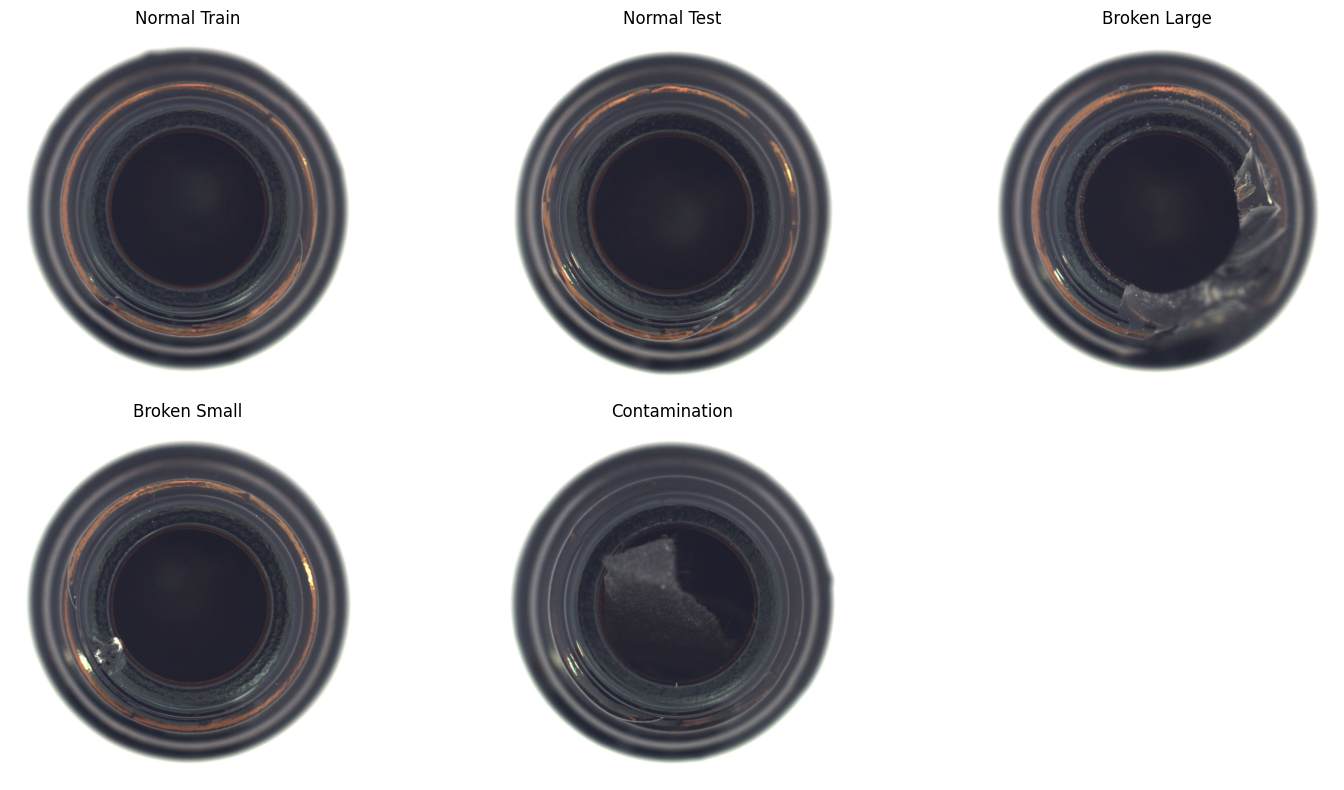

In [10]:
####Step 20: Add a sample image visualization section

def get_first_image(folder_path):
    image_files = [
        file_path
        for file_path in sorted(folder_path.iterdir())
        if file_path.suffix.lower() in image_extensions
    ]

    if not image_files:
        raise FileNotFoundError(
            f"No image files were found in: {folder_path}"
        )

    return image_files[0]


sample_paths = {
    "Normal Train": get_first_image(train_root / "good"),
    "Normal Test": get_first_image(test_root / "good"),
    "Broken Large": get_first_image(test_root / "broken_large"),
    "Broken Small": get_first_image(test_root / "broken_small"),
    "Contamination": get_first_image(test_root / "contamination"),
}

plt.figure(figsize=(15, 8))

for index, (title, image_path) in enumerate(sample_paths.items(), start=1):
    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, index)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

Step 22: Add the model baseline explanation in Markdown
## 6. Simple ResNet18 Feature-Memory Baseline

A pretrained ResNet18 model will be used as a frozen feature extractor.

The model will not be trained on defect labels. Instead, it will extract feature vectors from the normal training images.

These normal feature vectors will form a memory bank representing normal bottle appearance.

For each test image, the nearest distance to the normal feature memory will be calculated.

A higher distance indicates that the test image is more different from the normal training images and is therefore more likely to be anomalous.

This simple centralized baseline is implemented before the more advanced PatchCore method and before federated learning.

In [11]:
####Step 23: Define the image preprocessing

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image preprocessing pipeline is ready.")

Image preprocessing pipeline is ready.


In [12]:
#### Step 24: Load the pretrained ResNet18 model

device = torch.device("cpu")

weights = models.ResNet18_Weights.DEFAULT
resnet18 = models.resnet18(weights=weights)

# Remove the final classification layer
feature_extractor = torch.nn.Sequential(
    *list(resnet18.children())[:-1]
)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

for parameter in feature_extractor.parameters():
    parameter.requires_grad = False

print("Feature extractor is ready.")
print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s] 


Feature extractor is ready.
Device: cpu


In [13]:
####Step 25: Create a function to extract one feature vector

def extract_feature(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = image_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        feature = feature_extractor(image_tensor)

    feature = feature.squeeze().cpu().numpy()

    return feature


sample_feature = extract_feature(sample_paths["Normal Train"])

print("Feature vector shape:", sample_feature.shape)

Feature vector shape: (512,)


Step 26: Adding the feature memory explanation in Markdown

## 7. Normal Feature Memory Construction

The centralized baseline uses only normal training images to construct a reference memory of normal bottle appearance.

Each of the 209 normal training images is passed through the frozen ResNet18 feature extractor.

The output of each image is a 512-dimensional feature vector.

All normal training feature vectors are then stored in a feature memory bank.

This memory bank represents the normal visual characteristics of the bottle category and will later be used to calculate anomaly scores for the test images.

In [14]:
####Step 27: Extract features from all normal training images

train_image_paths = sorted(
    [
        file_path
        for file_path in (train_root / "good").iterdir()
        if file_path.suffix.lower() in image_extensions
    ]
)

normal_feature_memory = []

for image_path in train_image_paths:
    feature = extract_feature(image_path)
    normal_feature_memory.append(feature)

normal_feature_memory = np.vstack(normal_feature_memory)

print("Number of training images:", len(train_image_paths))
print("Feature memory shape:", normal_feature_memory.shape)

Number of training images: 209
Feature memory shape: (209, 512)


Step 28: Adding the anomaly scoring explanation below

## 8. Test Image Anomaly Scoring

Each test image is converted into a 512-dimensional feature vector using the same frozen ResNet18 feature extractor.

The anomaly score is calculated by comparing the test feature vector with all vectors in the normal feature memory.

The Euclidean distance to the nearest normal training feature is used as the anomaly score.

A small distance means that the test image is similar to the normal training data.

A large distance means that the test image is different from the normal training data and may contain an anomaly.

In [15]:
####Step 29: Create the test image list and labels

test_image_paths = []
test_labels = []
test_categories = []

for category_folder in sorted(test_root.iterdir()):
    if not category_folder.is_dir():
        continue

    category_name = category_folder.name
    label = 0 if category_name == "good" else 1

    for image_path in sorted(category_folder.iterdir()):
        if image_path.suffix.lower() in image_extensions:
            test_image_paths.append(image_path)
            test_labels.append(label)
            test_categories.append(category_name)

print("Number of test images:", len(test_image_paths))
print("Number of normal test images:", test_labels.count(0))
print("Number of anomalous test images:", test_labels.count(1))

Number of test images: 83
Number of normal test images: 20
Number of anomalous test images: 63


Step 30: Add the test feature extraction explanation

## 9. Test Feature Extraction

Each of the 83 test images is passed through the same frozen ResNet18 feature extractor.

The model produces one 512-dimensional feature vector for each test image.

These test feature vectors will be compared with the normal training feature memory.

The comparison will produce one anomaly score for every test image.

In [16]:
####Step 31: Extract features from all test images

test_features = []

for image_path in test_image_paths:
    feature = extract_feature(image_path)
    test_features.append(feature)

test_features = np.vstack(test_features)

print("Number of test feature vectors:", len(test_features))
print("Test feature matrix shape:", test_features.shape)

Number of test feature vectors: 83
Test feature matrix shape: (83, 512)


Step 32: Calculate anomaly scores

## 10. Anomaly Score Calculation

For each test image, the Euclidean distance between its feature vector and all normal training feature vectors is calculated.

The smallest distance is selected as the anomaly score.

This represents the distance to the nearest normal example.

A lower score indicates that the test image is similar to the normal training images.

A higher score indicates that the test image is more different from the normal training images and is more likely to contain an anomaly.

In [17]:
####Step 33: Compute the anomaly score for every test image

anomaly_scores = []

for test_feature in test_features:
    distances = np.linalg.norm(
        normal_feature_memory - test_feature,
        axis=1
    )

    nearest_distance = distances.min()
    anomaly_scores.append(nearest_distance)

anomaly_scores = np.array(anomaly_scores)

print("Number of anomaly scores:", len(anomaly_scores))
print("Minimum anomaly score:", anomaly_scores.min())
print("Maximum anomaly score:", anomaly_scores.max())

Number of anomaly scores: 83
Minimum anomaly score: 2.9261904
Maximum anomaly score: 13.336716


Step 34: Add the Image-level AUROC explanation

## 11. Image-Level AUROC Evaluation

Image-level AUROC is used as the main evaluation metric for the centralized baseline.

The metric compares the true image labels with the calculated anomaly scores.

The true labels are:

- 0 for normal test images
- 1 for anomalous test images

AUROC measures how well the anomaly scores rank anomalous images above normal images.

An AUROC value close to 1.0 indicates strong anomaly detection performance.

An AUROC value close to 0.5 indicates performance similar to random ranking.

In [18]:
####Step 35: Calculate Image-level AUROC

image_auroc = roc_auc_score(
    test_labels,
    anomaly_scores
)

print("Image-level AUROC:", image_auroc)
print("Image-level AUROC (%):", image_auroc * 100)

Image-level AUROC: 0.9936507936507936
Image-level AUROC (%): 99.36507936507935


Step 36: Adding the result interpretation

## 12. Centralized Baseline Result

The simple ResNet18 feature-memory baseline achieved an Image-level AUROC of:

**0.9937, equivalent to 99.37%.**

This result shows that the pretrained ResNet18 features provide a strong separation between normal and anomalous bottle images.

The centralized baseline therefore successfully validates the complete image-level anomaly detection pipeline:

- normal-only training data
- frozen feature extraction
- normal feature-memory construction
- nearest-neighbour anomaly scoring
- Image-level AUROC evaluation

This result will serve as the reference performance for later comparisons with local client models, FedAvg, FedProx, IID conditions, and Non-IID domain-shift conditions.

Although the performance is high, this method uses one global feature vector per image and does not yet provide patch-level anomaly localization. The next advanced centralized experiment will therefore extend the pipeline toward PatchCore-style patch features and anomaly maps.

## 12. Centralized Baseline Result

The simple ResNet18 feature-memory baseline achieved an Image-level AUROC of:

**0.9937, equivalent to 99.37%.**

This result shows that the pretrained ResNet18 features provide a strong separation between normal and anomalous bottle images.

The centralized baseline therefore successfully validates the complete image-level anomaly detection pipeline:

- normal-only training data
- frozen feature extraction
- normal feature-memory construction
- nearest-neighbour anomaly scoring
- Image-level AUROC evaluation

This result will serve as the reference performance for later comparisons with local client models, FedAvg, FedProx, IID conditions, and Non-IID domain-shift conditions.

Although the performance is high, this method uses one global feature vector per image and does not yet provide patch-level anomaly localization. The next advanced centralized experiment will therefore extend the pipeline toward PatchCore-style patch features and anomaly maps.

Step 37: Create a results table
## 13. Saving Test Predictions and Results

This section creates a structured results table containing:

- test image filename
- defect category
- true image label
- anomaly score

The table will be saved as a CSV file so that the results can later be used in the thesis report, comparison tables, plots, and federated-learning experiments.

In [19]:
####Step 37: Create a results table

results_df = pd.DataFrame({
    "image_name": [path.name for path in test_image_paths],
    "category": test_categories,
    "true_label": test_labels,
    "anomaly_score": anomaly_scores
})

results_df.head()

,image_name,category,true_label,anomaly_score
0,000.png,broken_large,1,9.034904
1,001.png,broken_large,1,8.811284
2,002.png,broken_large,1,11.884748
3,003.png,broken_large,1,13.263344
4,004.png,broken_large,1,7.023835


In [20]:
####Step 39: Save the predictions as a CSV file

results_csv_path = "/kaggle/working/mvtec_bottle_resnet18_predictions.csv"

results_df.to_csv(
    results_csv_path,
    index=False
)

print("Results saved to:")
print(results_csv_path)

Results saved to:
/kaggle/working/mvtec_bottle_resnet18_predictions.csv


####Step 40: Add the ROC curve section

## 14. ROC Curve Visualization

The Receiver Operating Characteristic curve shows the relationship between the true-positive rate and false-positive rate across different anomaly-score thresholds.

The area under this curve corresponds to the Image-level AUROC.

This visualization provides a clearer interpretation of the centralized baseline performance and can be included in the thesis results chapter.

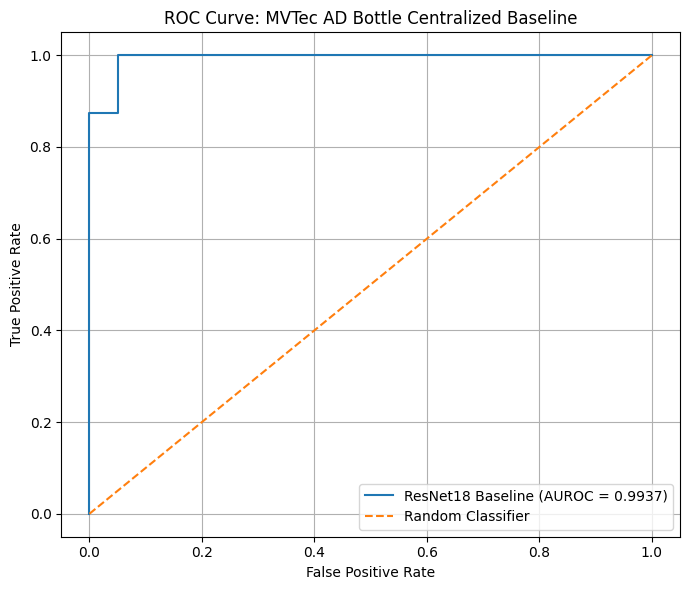

In [21]:
####Step 41: Plot the ROC curve

from sklearn.metrics import roc_curve

false_positive_rate, true_positive_rate, thresholds = roc_curve(
    test_labels,
    anomaly_scores
)

plt.figure(figsize=(7, 6))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"ResNet18 Baseline (AUROC = {image_auroc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: MVTec AD Bottle Centralized Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

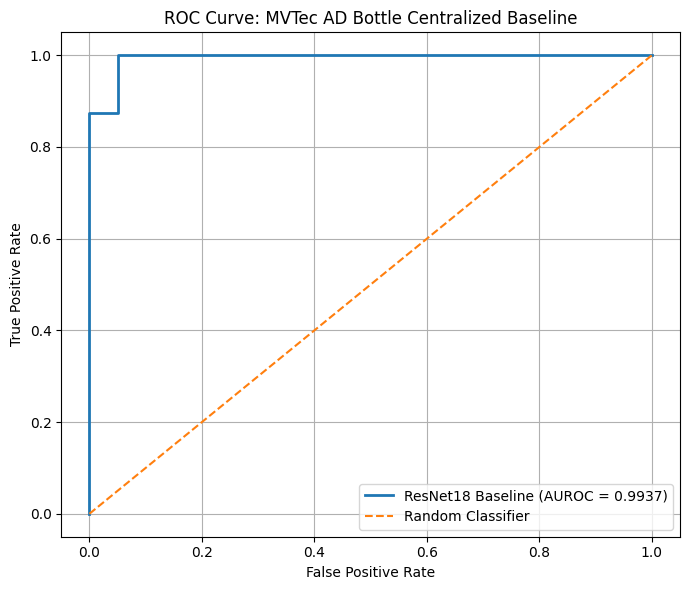

ROC curve saved successfully.
PNG file: /kaggle/working/mvtec_bottle_roc_curve.png
PDF file: /kaggle/working/mvtec_bottle_roc_curve.pdf


In [22]:
####Step 42: Save the ROC curve

from sklearn.metrics import roc_curve

# Calculate ROC curve values
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    test_labels,
    anomaly_scores
)

# Create the ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"ResNet18 Baseline (AUROC = {image_auroc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: MVTec AD Bottle Centralized Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()

# File locations
roc_png_path = "/kaggle/working/mvtec_bottle_roc_curve.png"
roc_pdf_path = "/kaggle/working/mvtec_bottle_roc_curve.pdf"

# Save the same graph in PNG and PDF formats
plt.savefig(roc_png_path, dpi=300, bbox_inches="tight")
plt.savefig(roc_pdf_path, bbox_inches="tight")

plt.show()

print("ROC curve saved successfully.")
print("PNG file:", roc_png_path)
print("PDF file:", roc_pdf_path)

# Stage 2: Centralized PatchCore-Style Baseline

In this stage, patch-level features will be extracted from intermediate layers of a pretrained ResNet18 model. Patches from normal training images will be stored in a normal patch memory bank.

During testing, patches from each test image will be compared with the normal memory bank. These patch-level anomaly scores will later be used to:

- calculate the image-level anomaly score,
- generate anomaly heatmaps,
- localize defective regions,
- calculate Image-level AUROC,
- and later calculate Pixel-level AUROC.

The ResNet18 backbone will remain frozen during this centralized PatchCore-style baseline.

## 2.1 Computing Device and Reproducibility Setup

Before constructing the PatchCore-style model, the computing device and random seeds are configured.

The notebook checks whether a CUDA-compatible GPU is available. When a GPU is available, feature extraction will be performed on the GPU to reduce processing time. In this experiment, the Kaggle NVIDIA Tesla P100 GPU is used.

Random seeds are also fixed for Python, NumPy, and PyTorch. This improves reproducibility by ensuring that random operations produce consistent results when the notebook is executed again under the same environment.

At this stage, no model is trained and no image features are extracted. This cell only prepares and verifies the computational environment.

In [23]:
# Step 43: Configure the computing device and reproducibility settings

import random
import numpy as np
import torch

# Fix random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Apply the seed to CUDA operations when a GPU is available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Select GPU when available; otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Reproducibility seed:", SEED)
print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2),
        "GB"
    )
else:
    print("CUDA GPU is not available. The notebook will use the CPU.")

Reproducibility seed: 42
Selected device: cuda
GPU name: Tesla T4
GPU memory: 14.56 GB


## Step 3: Locate and verify the bottle dataset
Why am I doing this?
Before extracting patch-level features, we must confirm the exact locations of:
normal training images,
test images,
and pixel-level ground-truth masks.

PatchCore learns the normal appearance of bottles only from the images inside train/good.
The test folder contains both normal and defective bottle images. The ground_truth folder contains binary masks showing the true defective regions. We will use those masks later when calculating Pixel-level AUROC.
At this step, no features are extracted and no model is created. We are only confirming the dataset structure.

## 2.2 Dataset Path Verification for the PatchCore-Style Baseline

The accelerator change restarted the Kaggle runtime and cleared the previously defined Python variables. Therefore, the dataset paths required for the PatchCore-style experiment are defined again without repeating the completed global-feature baseline.

The PatchCore-style method uses three important parts of the MVTec AD bottle dataset:

1. `train/good`: contains only normal bottle images and will be used to construct the normal patch memory bank.
2. `test`: contains both normal and anomalous bottle images and will be used for evaluation.
3. `ground_truth`: contains pixel-level defect masks corresponding to anomalous test images.

This verification step ensures that the correct dataset directories are available before patch-level feature extraction begins. No model training or feature extraction is performed in this step.

In [24]:
# Step 44: Locate and verify the MVTec AD bottle dataset

from pathlib import Path

# Kaggle stores attached datasets inside this directory
kaggle_input_dir = Path("/kaggle/input")

# Search for the bottle/train/good directory
train_good_candidates = list(kaggle_input_dir.rglob("bottle/train/good"))

if len(train_good_candidates) == 0:
    raise FileNotFoundError(
        "The folder 'bottle/train/good' could not be found inside /kaggle/input."
    )

# Use the first matching bottle dataset
train_good_dir = train_good_candidates[0]

# The bottle root folder is two levels above train/good
bottle_root = train_good_dir.parent.parent

# Define the remaining dataset directories
test_dir = bottle_root / "test"
ground_truth_dir = bottle_root / "ground_truth"

# Accepted image extensions
image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}

# Count images recursively
number_of_train_images = sum(
    file.suffix.lower() in image_extensions
    for file in train_good_dir.rglob("*")
)

number_of_test_images = sum(
    file.suffix.lower() in image_extensions
    for file in test_dir.rglob("*")
)

number_of_ground_truth_masks = sum(
    file.suffix.lower() in image_extensions
    for file in ground_truth_dir.rglob("*")
)

# Display the verified dataset information
print("Bottle dataset root:", bottle_root)
print("Normal training directory:", train_good_dir)
print("Test directory:", test_dir)
print("Ground-truth directory:", ground_truth_dir)
print()
print("Number of normal training images:", number_of_train_images)
print("Number of test images:", number_of_test_images)
print("Number of ground-truth masks:", number_of_ground_truth_masks)

Bottle dataset root: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle
Normal training directory: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle/train/good
Test directory: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle/test
Ground-truth directory: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle/ground_truth

Number of normal training images: 209
Number of test images: 83
Number of ground-truth masks: 63


## What my output confirms
-- 209 normal training images were found in train/good.
-- 83 test images were found across the normal and defect folders.
-- 63 ground-truth masks were found for the defective test images.

The numbers match the MVTec AD bottle dataset used in your completed baseline.
The remaining 20 test images are normal bottles, so they do not have defect masks.
No dataset files are missing, and the PatchCore stage can continue.

## Step 4: Define and verify image preprocessing
PatchCore does not process raw image files directly. Each image must first be converted into the format expected by the pretrained ResNet18 backbone.
We will only define the preprocessing pipeline and test it with one normal bottle image. We are not yet extracting patch features.

## 2.3 Image Preprocessing for Patch-Level Feature Extraction

Before an image can be passed through the pretrained ResNet18 backbone, it must be converted into a standardized tensor representation.

The following preprocessing operations are applied:

1. Each image is converted to RGB format to ensure that it contains three colour channels.
2. The image is resized to `224 × 224` pixels, which is the input resolution used in this experiment.
3. Pixel values are converted into a PyTorch tensor.
4. The tensor is normalized using the mean and standard deviation of the ImageNet dataset.

ImageNet normalization is required because the ResNet18 backbone was pretrained on ImageNet. Applying the same normalization used during pretraining ensures that the input images are represented in the expected numerical range.

The preprocessing pipeline is first tested on one normal training image. At this stage, no patch features are extracted and no memory bank is constructed.

In [25]:
# Step 45: Define and verify the PatchCore image preprocessing pipeline

from PIL import Image
from torchvision import transforms

# Input resolution used by the pretrained ResNet18 backbone
IMAGE_SIZE = 224

# ImageNet normalization values used during ResNet18 pretraining
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Define the preprocessing pipeline
patchcore_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        antialias=True
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# Collect all normal training-image paths in a reproducible order
train_image_paths = sorted([
    image_path
    for image_path in train_good_dir.rglob("*")
    if image_path.suffix.lower() in image_extensions
])

# Select one normal image for preprocessing verification
sample_train_path = train_image_paths[0]

# Load the image and explicitly convert it to three-channel RGB
sample_image = Image.open(sample_train_path).convert("RGB")

# Apply the preprocessing pipeline
sample_tensor = patchcore_transform(sample_image)

# Add a batch dimension because neural networks expect:
# [batch size, channels, height, width]
sample_batch = sample_tensor.unsqueeze(0)

# Verify the result
print("Sample image path:", sample_train_path)
print("Original image size:", sample_image.size)
print("Number of colour channels:", len(sample_image.getbands()))
print("Processed tensor shape:", sample_tensor.shape)
print("Batch tensor shape:", sample_batch.shape)
print("Tensor data type:", sample_tensor.dtype)

# Safety checks
assert sample_tensor.shape == (3, IMAGE_SIZE, IMAGE_SIZE)
assert sample_batch.shape == (1, 3, IMAGE_SIZE, IMAGE_SIZE)

print()
print("Image preprocessing verification completed successfully.")

Sample image path: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle/train/good/000.png
Original image size: (900, 900)
Number of colour channels: 3
Processed tensor shape: torch.Size([3, 224, 224])
Batch tensor shape: torch.Size([1, 3, 224, 224])
Tensor data type: torch.float32

Image preprocessing verification completed successfully.


### 2.3.1 Preprocessing Result Interpretation

The preprocessing pipeline was successfully verified using the normal training image `000.png`.

The original image resolution was:

- Width: 900 pixels
- Height: 900 pixels

The image contained three colour channels, confirming that it was correctly loaded in RGB format.

After preprocessing, the image was converted into a tensor with the shape:

`[3, 224, 224]`

This shape represents:

- `3`: the red, green, and blue colour channels
- `224`: the resized image height
- `224`: the resized image width

The original `900 × 900` image was therefore resized to `224 × 224` pixels so that it could be processed consistently by the pretrained ResNet18 backbone.

The tensor was then expanded to the batch shape:

`[1, 3, 224, 224]`

The first value, `1`, indicates that the batch contains one image. PyTorch convolutional neural networks expect image inputs in the format:

`[batch size, channels, height, width]`

The tensor data type was reported as `torch.float32`. This confirms that the image pixel values were converted into 32-bit floating-point numbers, which is the standard numerical format used during neural-network inference.

The final success message confirms that both shape validation checks passed. Therefore, the image preprocessing pipeline produces the correct input format for the ResNet18 intermediate-feature extractor.

No anomaly detection or feature extraction was performed in this step. The purpose of this step was only to verify that all bottle images can be transformed into a consistent and valid model input representation.

## Step 5: Create the frozen intermediate-feature extractor
Why this step is necessary ?

Your completed Stage 1 baseline extracted only one global feature vector from each image. That global representation was useful for deciding whether the entire image was normal or anomalous, but it did not preserve the spatial location of defects.
For defect localization, we need feature maps that still retain spatial information.
We will extract features from two intermediate ResNet18 layers:
layer2
layer3
These layers describe different levels of visual information:
layer2 retains more detailed local information such as edges, textures, and small structures.
layer3 captures more abstract information about larger bottle components and shapes.

The ResNet18 backbone will remain completely frozen. No weights will be updated in this centralized PatchCore-style baseline.

## 2.4 Frozen ResNet18 Intermediate-Feature Extractor

The completed global-feature baseline represented each image using one 512-dimensional feature vector. Although this representation was effective for image-level anomaly detection, it removed most of the spatial information required for locating defects.

The PatchCore-style method instead extracts intermediate feature maps from `layer2` and `layer3` of a pretrained ResNet18 backbone.

These layers are selected because they provide complementary information:

- `layer2` retains relatively fine local information, including textures, edges, and small visual structures.
- `layer3` captures higher-level and larger-scale visual patterns while still preserving spatial organization.

For an input image of size `224 × 224`, the expected outputs are:

- `layer2`: 128 channels arranged over a `28 × 28` spatial grid.
- `layer3`: 256 channels arranged over a `14 × 14` spatial grid.

Each spatial position in these feature maps describes a local region, or patch, of the original image. These local representations will later be aligned and combined to construct the normal patch memory bank.

The pretrained ResNet18 parameters are frozen and the model is placed in evaluation mode. Therefore, no gradient calculation, backpropagation, or weight update is performed during this centralized PatchCore-style experiment.

In [26]:
# Step 46: Create and verify the frozen ResNet18 feature extractor

import torch
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor

# Load the standard ImageNet-pretrained ResNet18 weights
resnet18_weights = ResNet18_Weights.DEFAULT

# Create the pretrained ResNet18 backbone
resnet18_backbone = resnet18(weights=resnet18_weights)

# Freeze every model parameter
for parameter in resnet18_backbone.parameters():
    parameter.requires_grad = False

# Put the backbone in evaluation mode
resnet18_backbone.eval()

# Select the intermediate layers required for patch-level features
selected_layers = {
    "layer2": "layer2_features",
    "layer3": "layer3_features"
}

# Construct a model that returns only the selected feature maps
patch_feature_extractor = create_feature_extractor(
    resnet18_backbone,
    return_nodes=selected_layers
)

# Move the feature extractor to the selected GPU
patch_feature_extractor = patch_feature_extractor.to(device)

# Keep the feature extractor in evaluation mode
patch_feature_extractor.eval()

# Move the previously prepared sample batch to the GPU
sample_batch_device = sample_batch.to(device)

# Extract intermediate features without gradients
with torch.inference_mode():
    sample_feature_maps = patch_feature_extractor(sample_batch_device)

# Count the complete ResNet18 parameters
total_parameters = sum(
    parameter.numel()
    for parameter in resnet18_backbone.parameters()
)

# Count parameters that are allowed to learn
trainable_parameters = sum(
    parameter.numel()
    for parameter in resnet18_backbone.parameters()
    if parameter.requires_grad
)

# Display the verification results
print("Input batch shape:", sample_batch_device.shape)
print(
    "Layer 2 feature-map shape:",
    sample_feature_maps["layer2_features"].shape
)
print(
    "Layer 3 feature-map shape:",
    sample_feature_maps["layer3_features"].shape
)
print()
print("Total ResNet18 parameters:", f"{total_parameters:,}")
print("Trainable ResNet18 parameters:", f"{trainable_parameters:,}")
print("Feature extractor training mode:", patch_feature_extractor.training)

# Safety checks
assert sample_feature_maps["layer2_features"].shape == (
    1, 128, 28, 28
)

assert sample_feature_maps["layer3_features"].shape == (
    1, 256, 14, 14
)

assert trainable_parameters == 0
assert patch_feature_extractor.training is False

print()
print("Frozen intermediate-feature extractor verified successfully.")

Input batch shape: torch.Size([1, 3, 224, 224])
Layer 2 feature-map shape: torch.Size([1, 128, 28, 28])
Layer 3 feature-map shape: torch.Size([1, 256, 14, 14])

Total ResNet18 parameters: 11,689,512
Trainable ResNet18 parameters: 0
Feature extractor training mode: False

Frozen intermediate-feature extractor verified successfully.


### 2.4.1 Intermediate-Feature Extractor Result Interpretation

The ImageNet-pretrained ResNet18 feature extractor was successfully created and verified using one preprocessed normal bottle image.

The following input shape was supplied to the network:

`[1, 3, 224, 224]`

This represents:

- `1`: one image in the batch
- `3`: red, green, and blue colour channels
- `224`: image height
- `224`: image width

The feature extractor returned the following intermediate feature-map shapes:

#### Layer 2 output

`[1, 128, 28, 28]`

This result means that `layer2` produced:

- one feature map batch,
- 128 feature channels,
- a spatial grid of `28 × 28` positions.

The `28 × 28` grid contains 784 spatial locations. Each location represents the visual characteristics of a local region of the input bottle image.

Because this layer maintains a relatively high spatial resolution, it is useful for representing smaller visual details such as edges, textures, surface variations, and local structural changes.

#### Layer 3 output

`[1, 256, 14, 14]`

This result means that `layer3` produced:

- one feature map batch,
- 256 feature channels,
- a spatial grid of `14 × 14` positions.

The `14 × 14` grid contains 196 spatial locations. These features represent larger and more abstract visual regions than the `layer2` features.

Therefore, the two selected layers provide complementary information:

- `layer2` provides finer local details.
- `layer3` provides higher-level structural information.

The two feature maps currently have different spatial resolutions. Before they can be combined, the `14 × 14` feature map from `layer3` must later be aligned with the `28 × 28` feature map from `layer2`.

The ResNet18 model contains a total of:

`11,689,512 parameters`

However, the number of trainable parameters was:

`0`

This confirms that all ResNet18 parameters were successfully frozen. Therefore, the network is being used only as a pretrained feature extractor.

The reported training mode was:

`False`

This confirms that the model is operating in evaluation mode. Evaluation mode prevents training-specific behaviour, such as updates to batch-normalization statistics.

No gradient calculation, backpropagation, optimizer, or parameter update was used in this step. The extracted features were generated through inference only.

The successful completion message confirms that:

- the input image shape was correct,
- the `layer2` feature-map shape was correct,
- the `layer3` feature-map shape was correct,
- all backbone parameters were frozen,
- and the feature extractor was in evaluation mode.

The intermediate-feature extractor is therefore ready for patch-level feature alignment and construction.

The pretrained model-weight download shown above occurred because the ImageNet ResNet18 weights were loaded for the first time in the restarted Kaggle session. It is not an error and does not affect the experimental result.

### Step 6: Align and combine the patch-level features
What happens in this step?
The two selected ResNet18 layers produce different spatial resolutions:
layer2: 28 × 28
layer3: 14 × 14
They cannot be combined directly because their grid sizes are different.
I will be working on:
Apply local average pooling so that each position also considers its nearby feature values.
resize the layer3 grid from 14 × 14 to 28 × 28;
concatenate the 128 layer2 channels and 256 layer3 channels;
convert the combined feature map into separate patch vectors.

## 2.5 Local Feature Aggregation, Spatial Alignment, and Patch Embedding Construction

The intermediate feature maps extracted from `layer2` and `layer3` contain complementary visual information. However, they cannot initially be concatenated because their spatial resolutions are different:

- `layer2`: `28 × 28`
- `layer3`: `14 × 14`

Before combining the feature maps, local average pooling with a `3 × 3` neighbourhood is applied. This operation allows each spatial feature position to incorporate information from its nearby positions while preserving the original feature-map resolution.

The `layer3` feature map is then resized from `14 × 14` to `28 × 28` using bilinear interpolation. This aligns every higher-level `layer3` position with the finer spatial grid produced by `layer2`.

After alignment, the feature maps are concatenated along the channel dimension:

- 128 channels from `layer2`
- 256 channels from `layer3`
- 384 combined feature dimensions

The resulting combined feature map has the shape:

`[1, 384, 28, 28]`

The spatial grid is subsequently flattened into individual patch embeddings. Since the grid contains `28 × 28` positions, one image produces 784 patch embeddings.

Each patch is represented by a 384-dimensional feature vector. Therefore, the final patch embedding matrix for one image has the shape:

`[784, 384]`

These patch embeddings preserve spatially organized local information. They will later be collected from all normal training images to form the normal patch memory bank.

No anomaly score is calculated and no model parameter is updated in this step.

In [27]:
# Step 47: Align and combine intermediate feature maps into patch embeddings

import torch.nn.functional as F

# Retrieve the two feature maps extracted from the sample image
layer2_features = sample_feature_maps["layer2_features"]
layer3_features = sample_feature_maps["layer3_features"]

# Aggregate information from a local 3 × 3 neighbourhood
# The stride and padding preserve the original spatial dimensions
layer2_aggregated = F.avg_pool2d(
    layer2_features,
    kernel_size=3,
    stride=1,
    padding=1
)

layer3_aggregated = F.avg_pool2d(
    layer3_features,
    kernel_size=3,
    stride=1,
    padding=1
)

# Resize layer3 from 14 × 14 to the 28 × 28 layer2 spatial grid
layer3_aligned = F.interpolate(
    layer3_aggregated,
    size=layer2_aggregated.shape[-2:],
    mode="bilinear",
    align_corners=False
)

# Concatenate the aligned feature maps along the channel dimension
combined_feature_map = torch.cat(
    [layer2_aggregated, layer3_aligned],
    dim=1
)

# Convert:
# [batch, channels, height, width]
# into:
# [batch, height, width, channels]
patch_grid = combined_feature_map.permute(0, 2, 3, 1)

# Flatten the 28 × 28 spatial grid into 784 patch vectors
sample_patch_embeddings = patch_grid.reshape(
    -1,
    combined_feature_map.shape[1]
)

# Display the feature construction results
print("Original layer2 shape:", layer2_features.shape)
print("Original layer3 shape:", layer3_features.shape)
print()
print("Aggregated layer2 shape:", layer2_aggregated.shape)
print("Aggregated layer3 shape:", layer3_aggregated.shape)
print("Aligned layer3 shape:", layer3_aligned.shape)
print()
print("Combined feature-map shape:", combined_feature_map.shape)
print("Patch-grid shape:", patch_grid.shape)
print("Final patch-embedding matrix shape:", sample_patch_embeddings.shape)
print()
print("Number of patches from one image:", sample_patch_embeddings.shape[0])
print("Feature dimensions per patch:", sample_patch_embeddings.shape[1])

# Safety checks
assert layer2_aggregated.shape == (1, 128, 28, 28)
assert layer3_aggregated.shape == (1, 256, 14, 14)
assert layer3_aligned.shape == (1, 256, 28, 28)
assert combined_feature_map.shape == (1, 384, 28, 28)
assert sample_patch_embeddings.shape == (784, 384)

print()
print("Patch embedding construction verified successfully.")

Original layer2 shape: torch.Size([1, 128, 28, 28])
Original layer3 shape: torch.Size([1, 256, 14, 14])

Aggregated layer2 shape: torch.Size([1, 128, 28, 28])
Aggregated layer3 shape: torch.Size([1, 256, 14, 14])
Aligned layer3 shape: torch.Size([1, 256, 28, 28])

Combined feature-map shape: torch.Size([1, 384, 28, 28])
Patch-grid shape: torch.Size([1, 28, 28, 384])
Final patch-embedding matrix shape: torch.Size([784, 384])

Number of patches from one image: 784
Feature dimensions per patch: 384

Patch embedding construction verified successfully.


### 2.5.1 Patch Embedding Construction Result Interpretation

The intermediate feature maps were successfully aggregated, spatially aligned, and converted into patch-level embeddings.

The original feature-map shapes were:

- `layer2`: `[1, 128, 28, 28]`
- `layer3`: `[1, 256, 14, 14]`

The first dimension represents the batch size, which was one image. The second dimension represents the number of feature channels, while the final two dimensions describe the spatial feature grid.

#### Local feature aggregation

A `3 × 3` average-pooling operation was applied to both feature maps.

After aggregation, the shapes remained:

- `layer2`: `[1, 128, 28, 28]`
- `layer3`: `[1, 256, 14, 14]`

The spatial dimensions remained unchanged because a stride of one and padding of one were used.

This operation does not reduce the feature-map size. Instead, each spatial position is updated using information from its local neighbourhood. This gives every patch representation additional surrounding context, which can help describe local bottle structures and surface patterns more reliably.

#### Spatial alignment

The aggregated `layer3` feature map originally had a spatial resolution of `14 × 14`. It was resized to:

`[1, 256, 28, 28]`

This made its spatial resolution equal to the `layer2` feature map.

Bilinear interpolation was used only to align the spatial grids. It does not create additional semantic information. Its purpose is to allow the corresponding `layer2` and `layer3` feature locations to be combined.

#### Feature concatenation

After spatial alignment, the two feature maps were concatenated along the feature-channel dimension.

The combined feature-map shape was:

`[1, 384, 28, 28]`

The 384 feature dimensions were obtained from:

`128 layer2 features + 256 layer3 features = 384 features`

Each spatial location now contains both:

- relatively fine local information from `layer2`, and
- higher-level structural information from `layer3`.

This combined representation is therefore more informative than using either layer alone.

#### Patch embedding matrix

The combined `28 × 28` spatial grid was rearranged into a patch grid with the shape:

`[1, 28, 28, 384]`

The spatial grid was then flattened into the final patch embedding matrix:

`[784, 384]`

The number of patch locations was calculated as:

`28 × 28 = 784 patches`

Each of the 784 spatial locations was represented by a 384-dimensional feature vector.

These are feature-space patches rather than manually cropped, non-overlapping image blocks. Each patch embedding corresponds to a spatial location in the convolutional feature map and represents a receptive region of the original bottle image.

The final result therefore means that one bottle image produced:

- 784 local patch representations,
- with 384 feature values for every patch.

All shape validation checks passed, confirming that the feature alignment and patch embedding construction were implemented correctly.

No anomaly score was calculated in this step. No model parameter was trained or updated. The result only confirms that a normal bottle image can be converted into spatially organized patch-level representations.

The same procedure will next be applied to all 209 normal training images. Their patch embeddings will be collected to construct the normal patch memory bank.

## Step 7: Construct the full normal patch memory bank

The images will be processed in small batches on the T4 GPU. After each batch is processed, its patch embeddings will be moved to the CPU. This prevents unnecessary GPU-memory usage.
No model training occurs here. We are creating a reference collection describing the normal appearance of bottle regions.

## 2.6 Construction of the Complete Normal Patch Memory Bank

The verified patch embedding procedure is now applied to all 209 normal bottle images in the `train/good` directory.

A PyTorch dataset and data loader are used to process the images in small batches. Batch processing improves computational efficiency because several images can be passed through the GPU simultaneously.

For every normal training image:

1. The image is loaded and converted to RGB format.
2. The previously defined ImageNet preprocessing pipeline is applied.
3. Intermediate features are extracted from `layer2` and `layer3` of the frozen ResNet18 backbone.
4. Local `3 × 3` average aggregation is applied.
5. The `layer3` feature map is aligned with the `layer2` spatial grid.
6. The feature maps are concatenated.
7. The resulting `28 × 28` spatial grid is converted into 784 patch embeddings.
8. Each patch is represented by 384 feature dimensions.

Because the training set contains 209 normal images, the expected number of normal patch embeddings is:

`209 × 784 = 163,856 patches`

The expected final memory-bank shape is:

`[163856, 384]`

The complete memory bank contains only patches extracted from normal bottle images. It therefore represents the range of local visual patterns considered normal by the centralized PatchCore-style method.

The extracted batches are moved from the GPU to CPU memory after feature extraction. This reduces GPU-memory consumption and leaves the GPU available for later test-image processing.

No labels, anomalous images, or ground-truth masks are used when constructing this memory bank. No gradient calculation, backpropagation, optimizer, or parameter update is performed.

In [28]:
# Step 48: Construct the complete normal patch memory bank

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


class NormalBottleDataset(Dataset):
    """
    Dataset used to load normal bottle training images.

    Each image is:
    1. opened from its file path,
    2. converted to three-channel RGB,
    3. transformed into the standardized ResNet18 input format.
    """

    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        # Return the total number of normal training images
        return len(self.image_paths)

    def __getitem__(self, index):
        # Select one image path using its dataset index
        image_path = self.image_paths[index]

        # Load the image and ensure that it has three RGB channels
        image = Image.open(image_path).convert("RGB")

        # Apply resizing, tensor conversion, and ImageNet normalization
        image_tensor = self.transform(image)

        # Return both the processed image and its original path
        return image_tensor, str(image_path)


# Create the normal training dataset
normal_train_dataset = NormalBottleDataset(
    image_paths=train_image_paths,
    transform=patchcore_transform
)

# Number of images processed simultaneously
MEMORY_BATCH_SIZE = 8

# Create the data loader
normal_train_loader = DataLoader(
    normal_train_dataset,
    batch_size=MEMORY_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


def extract_patch_embeddings_from_batch(image_batch):
    """
    Convert a batch of images into patch-level feature embeddings.

    Input shape:
        [batch_size, 3, 224, 224]

    Output shape:
        [batch_size, 784, 384]
    """

    # Extract layer2 and layer3 features without gradient calculation
    with torch.inference_mode():
        batch_feature_maps = patch_feature_extractor(image_batch)

    # Retrieve the two intermediate feature maps
    batch_layer2 = batch_feature_maps["layer2_features"]
    batch_layer3 = batch_feature_maps["layer3_features"]

    # Aggregate local neighbourhood information
    batch_layer2 = F.avg_pool2d(
        batch_layer2,
        kernel_size=3,
        stride=1,
        padding=1
    )

    batch_layer3 = F.avg_pool2d(
        batch_layer3,
        kernel_size=3,
        stride=1,
        padding=1
    )

    # Align layer3 with the 28 × 28 layer2 spatial grid
    batch_layer3 = F.interpolate(
        batch_layer3,
        size=batch_layer2.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    # Combine 128 layer2 channels with 256 layer3 channels
    batch_combined_features = torch.cat(
        [batch_layer2, batch_layer3],
        dim=1
    )

    # Rearrange:
    # [batch, channels, height, width]
    # into:
    # [batch, height, width, channels]
    batch_patch_grid = batch_combined_features.permute(
        0, 2, 3, 1
    )

    # Convert each 28 × 28 grid into 784 patch vectors
    batch_patch_embeddings = batch_patch_grid.reshape(
        image_batch.shape[0],
        -1,
        batch_combined_features.shape[1]
    )

    return batch_patch_embeddings


# Store the patch embeddings from each processed batch
memory_bank_batches = []

# Process all normal training images
for image_batch, _ in tqdm(
    normal_train_loader,
    desc="Extracting normal patch embeddings"
):
    # Move the current image batch to the T4 GPU
    image_batch = image_batch.to(
        device,
        non_blocking=True
    )

    # Extract patch embeddings
    batch_patch_embeddings = extract_patch_embeddings_from_batch(
        image_batch
    )

    # Move the result to CPU memory before storing it
    memory_bank_batches.append(
        batch_patch_embeddings.cpu()
    )

# Combine all batches while preserving the image dimension
normal_patch_embeddings_by_image = torch.cat(
    memory_bank_batches,
    dim=0
)

# Flatten:
# [209 images, 784 patches, 384 features]
# into:
# [163856 patches, 384 features]
normal_patch_memory_bank = normal_patch_embeddings_by_image.reshape(
    -1,
    normal_patch_embeddings_by_image.shape[-1]
).contiguous()

# Calculate expected dimensions
patches_per_image = 28 * 28
expected_total_patches = (
    len(normal_train_dataset) * patches_per_image
)

# Calculate approximate CPU memory consumption
memory_bank_size_mb = (
    normal_patch_memory_bank.numel()
    * normal_patch_memory_bank.element_size()
    / (1024 ** 2)
)

# Check whether all stored feature values are valid
contains_only_finite_values = bool(
    torch.isfinite(normal_patch_memory_bank).all()
)

# Display the memory-bank construction results
print()
print(
    "Number of normal training images:",
    len(normal_train_dataset)
)
print("Batch size:", MEMORY_BATCH_SIZE)
print("Patches per image:", patches_per_image)
print(
    "Feature dimensions per patch:",
    normal_patch_memory_bank.shape[1]
)
print()
print(
    "Shape before flattening:",
    normal_patch_embeddings_by_image.shape
)
print(
    "Final normal patch memory-bank shape:",
    normal_patch_memory_bank.shape
)
print(
    "Expected total number of patches:",
    expected_total_patches
)
print(
    "Approximate memory-bank size:",
    round(memory_bank_size_mb, 2),
    "MB"
)
print(
    "Memory-bank storage device:",
    normal_patch_memory_bank.device
)
print(
    "Contains only finite values:",
    contains_only_finite_values
)

# Safety checks
assert len(normal_train_dataset) == 209

assert normal_patch_embeddings_by_image.shape == (
    209,
    784,
    384
)

assert normal_patch_memory_bank.shape == (
    expected_total_patches,
    384
)

assert expected_total_patches == 163856
assert normal_patch_memory_bank.device.type == "cpu"
assert contains_only_finite_values is True
assert normal_patch_memory_bank.requires_grad is False

print()
print(
    "Complete normal patch memory bank "
    "constructed successfully."
)

Extracting normal patch embeddings:   0%|          | 0/27 [00:00<?, ?it/s]


Number of normal training images: 209
Batch size: 8
Patches per image: 784
Feature dimensions per patch: 384

Shape before flattening: torch.Size([209, 784, 384])
Final normal patch memory-bank shape: torch.Size([163856, 384])
Expected total number of patches: 163856
Approximate memory-bank size: 240.02 MB
Memory-bank storage device: cpu
Contains only finite values: True

Complete normal patch memory bank constructed successfully.


### 2.6.1 Normal Patch Memory-Bank Result Interpretation

The complete normal patch memory bank was successfully constructed from all 209 normal bottle training images.

The progress bar completed:

`27 out of 27 batches`

A batch size of eight images was used. The 209 images were therefore divided into 26 complete batches of eight images and one final smaller batch containing the remaining image.

The feature extraction process required approximately five seconds in the current Kaggle environment, confirming that the Tesla T4 GPU processed the normal training images efficiently.

#### Number of processed training images

The reported number of normal training images was:

`209`

This confirms that every image from the `train/good` directory was included in the memory-bank construction.

Only normal images were used. No defective test images or ground-truth masks contributed to the memory bank.

#### Patch representation per image

Each normal image produced:

`784 patches`

This value was obtained from the spatial feature grid:

`28 × 28 = 784 patch locations`

Every patch was represented by:

`384 feature dimensions`

These 384 feature values were formed by combining:

- 128 feature channels from ResNet18 `layer2`
- 256 feature channels from ResNet18 `layer3`

Therefore, each image was represented by a matrix with the shape:

`[784, 384]`

#### Memory bank before flattening

Before combining patches from different images, the normal feature collection had the shape:

`[209, 784, 384]`

This shape represents:

- `209`: normal training images
- `784`: patch embeddings per image
- `384`: feature dimensions per patch

Keeping this temporary three-dimensional structure confirms that every training image produced the expected number of patch embeddings.

#### Final flattened memory bank

The image and patch dimensions were then combined, producing the final memory-bank shape:

`[163856, 384]`

The total number of patches was calculated as:

`209 × 784 = 163,856 normal patch embeddings`

Each of these 163,856 rows represents one local visual pattern extracted from a normal bottle image.

The complete memory bank therefore stores a large collection of normal examples describing bottle regions such as:

- the bottle body,
- the cap region,
- the neck,
- the label-free surface,
- the background,
- edges,
- reflections,
- textures,
- and other normal local structures.

During testing, patches from a new image will later be compared with this normal memory bank. A test patch that is very different from all stored normal patches will receive a higher anomaly score.

#### Memory consumption

The approximate memory-bank size was:

`240.02 MB`

The memory usage is consistent with the expected storage requirement for 163,856 patch vectors, where each vector contains 384 values stored using 32-bit floating-point precision.

This full memory bank is manageable in the current environment. However, comparing every test patch against all 163,856 stored patches would require a large number of distance calculations.

For this reason, a representative subset of the memory bank will later be selected. This reduced subset is commonly called a coreset.

#### Storage device

The memory-bank storage device was reported as:

`CPU`

This confirms that the completed patch embeddings were moved out of GPU memory after extraction.

The frozen ResNet18 feature extractor remains on the GPU, while the complete normal memory bank is stored in CPU memory. This reduces unnecessary GPU-memory consumption.

#### Feature validity

The output reported:

`Contains only finite values: True`

This confirms that the memory bank does not contain invalid numerical values such as:

- `NaN`
- positive infinity
- negative infinity

This validation is important because invalid values would make the later nearest-neighbour distance calculations unreliable.

The memory bank also does not require gradient calculation. Therefore, it is treated as a fixed reference collection rather than a set of trainable model parameters.

#### Conclusion of this step

All validation checks passed successfully.

The final result confirms that:

- all 209 normal training images were processed,
- every image produced 784 patch embeddings,
- every patch contains 384 feature dimensions,
- the complete bank contains 163,856 normal patches,
- the memory bank is stored on the CPU,
- and all stored feature values are valid.

No anomaly detection was performed in this step. No neural-network weights were trained or updated.

The next stage will reduce the complete memory bank to a smaller representative patch subset. This will make nearest-neighbour anomaly scoring faster while attempting to preserve the diversity of normal bottle patterns.

## Step 8: Create a reproducible random coreset

Why is this step needed?

The complete memory bank contains:

163,856 normal patches
For one test image containing 784 patches, comparison with the full memory bank would require:
784 × 163,856 = 128,463,104 distance calculations
That is more than 128 million patch comparisons for only one test image. Since the test set contains 83 images, using the full memory bank would make evaluation unnecessarily slow.
We will retain 10% of the normal patch embeddings:
Approximately 16,386 patches
The subset will be selected using a fixed random seed. This makes the selection reproducible. Running the notebook again with the same seed will select the same patch indices.
It is important to describe this accurately: the original PatchCore method normally uses a greedy k-center coreset selection strategy. For this first PatchCore-style baseline, we are using a simpler fixed-seed random coreset. We will clearly state this in the notebook and thesis rather than presenting it as the original greedy selection algorithm.

## 2.7 Reproducible Random Coreset Selection

The complete normal patch memory bank contains 163,856 patch embeddings. Although this collection provides broad coverage of normal bottle patterns, comparing every test patch against the complete bank would require a very large number of distance calculations.

For one test image, the number of comparisons would be:

`784 test patches × 163,856 normal patches = 128,463,104 distances`

To reduce the computational cost, a smaller subset of the complete memory bank is selected.

A coreset ratio of 10% is used. This retains approximately 16,386 normal patch embeddings while reducing the number of nearest-neighbour comparisons by approximately 90%.

The subset is selected using uniform random sampling without replacement. A fixed random seed is used so that the same patch indices are selected whenever the experiment is repeated under the same environment.

Sampling without replacement ensures that every selected patch appears only once in the reduced memory bank.

### Methodological clarification

The original PatchCore method commonly uses a greedy k-center selection procedure to construct a representative coreset.

In this initial centralized PatchCore-style baseline, a fixed-seed random coreset is used instead. This choice provides:

- a simple and reproducible baseline,
- lower implementation complexity,
- reduced computation time,
- and a clear reference experiment before testing more advanced coreset strategies.

Therefore, this experiment must be described as a **PatchCore-style baseline with reproducible random memory-bank reduction**, rather than an exact reproduction of the original PatchCore coreset algorithm.

The complete memory bank is retained in CPU memory, while the reduced coreset becomes the active reference bank used for test-image anomaly scoring.

No neural-network training or parameter update is performed in this step.

In [29]:
# Step 49: Create a reproducible 10% random coreset

# Fraction of the complete memory bank to retain
CORESET_RATIO = 0.10

# Number of patch embeddings in the complete memory bank
complete_memory_bank_size = normal_patch_memory_bank.shape[0]

# Calculate the number of patches to retain
coreset_size = max(
    1,
    int(round(complete_memory_bank_size * CORESET_RATIO))
)

# Create an independent CPU random generator
# The fixed seed makes the selected subset reproducible
coreset_generator = torch.Generator(device="cpu")
coreset_generator.manual_seed(SEED)

# Generate unique random indices without replacement
selected_coreset_indices = torch.randperm(
    complete_memory_bank_size,
    generator=coreset_generator
)[:coreset_size]

# Sort the selected indices to preserve their original memory-bank order
selected_coreset_indices = torch.sort(
    selected_coreset_indices
).values

# Select the corresponding normal patch embeddings
random_patch_coreset = normal_patch_memory_bank[
    selected_coreset_indices
].contiguous()

# Define this reduced collection as the active memory bank
# that will later be used for nearest-neighbour anomaly scoring
patchcore_memory_bank = random_patch_coreset

# Calculate the approximate memory consumption
complete_bank_size_mb = (
    normal_patch_memory_bank.numel()
    * normal_patch_memory_bank.element_size()
    / (1024 ** 2)
)

coreset_size_mb = (
    patchcore_memory_bank.numel()
    * patchcore_memory_bank.element_size()
    / (1024 ** 2)
)

# Calculate the percentage reduction
memory_reduction_percentage = (
    1
    - patchcore_memory_bank.shape[0]
    / normal_patch_memory_bank.shape[0]
) * 100

# Verify that all selected indices are unique
number_of_unique_indices = torch.unique(
    selected_coreset_indices
).numel()

# Verify that all coreset feature values are numerically valid
coreset_contains_only_finite_values = bool(
    torch.isfinite(patchcore_memory_bank).all()
)

# Display the coreset results
print("Coreset selection method: fixed-seed random sampling")
print("Random seed:", SEED)
print("Coreset ratio:", CORESET_RATIO)
print()
print(
    "Complete memory-bank shape:",
    normal_patch_memory_bank.shape
)
print(
    "Reduced active memory-bank shape:",
    patchcore_memory_bank.shape
)
print()
print(
    "Complete number of patches:",
    complete_memory_bank_size
)
print(
    "Selected number of patches:",
    patchcore_memory_bank.shape[0]
)
print(
    "Number of unique selected indices:",
    number_of_unique_indices
)
print()
print(
    "Complete memory-bank size:",
    round(complete_bank_size_mb, 2),
    "MB"
)
print(
    "Reduced memory-bank size:",
    round(coreset_size_mb, 2),
    "MB"
)
print(
    "Patch-count reduction:",
    round(memory_reduction_percentage, 2),
    "%"
)
print()
print(
    "Reduced memory-bank device:",
    patchcore_memory_bank.device
)
print(
    "Contains only finite values:",
    coreset_contains_only_finite_values
)

# Safety checks
assert complete_memory_bank_size == 163856
assert coreset_size == 16386

assert patchcore_memory_bank.shape == (
    16386,
    384
)

assert number_of_unique_indices == coreset_size
assert patchcore_memory_bank.device.type == "cpu"
assert coreset_contains_only_finite_values is True
assert patchcore_memory_bank.requires_grad is False

print()
print(
    "Reproducible random patch coreset "
    "created successfully."
)

Coreset selection method: fixed-seed random sampling
Random seed: 42
Coreset ratio: 0.1

Complete memory-bank shape: torch.Size([163856, 384])
Reduced active memory-bank shape: torch.Size([16386, 384])

Complete number of patches: 163856
Selected number of patches: 16386
Number of unique selected indices: 16386

Complete memory-bank size: 240.02 MB
Reduced memory-bank size: 24.0 MB
Patch-count reduction: 90.0 %

Reduced memory-bank device: cpu
Contains only finite values: True

Reproducible random patch coreset created successfully.


### 2.7.1 Random Coreset Selection Result Interpretation

The complete normal patch memory bank was successfully reduced using fixed-seed random sampling.

The coreset selection method was reported as:

`fixed-seed random sampling`

This confirms that the reduced memory bank was created by randomly selecting patch embeddings from the complete normal memory bank.

A fixed random seed of:

`42`

was used. This makes the patch selection reproducible. When the same notebook is executed again with the same seed and environment, the same patch indices should be selected.

#### Coreset ratio

The selected coreset ratio was:

`0.10`

This means that 10% of the complete normal patch memory bank was retained for later nearest-neighbour comparison.

The complete memory-bank shape was:

`[163856, 384]`

This represents:

- 163,856 normal patch embeddings
- 384 feature dimensions for every patch

The reduced active memory-bank shape was:

`[16386, 384]`

This means that the active coreset contains:

- 16,386 selected normal patch embeddings
- 384 feature dimensions for every selected patch

The dimensionality of each patch remained unchanged. Only the number of stored patch examples was reduced.

#### Number of selected patches

The complete memory bank contained:

`163,856 patches`

The reduced coreset contained:

`16,386 patches`

The number of unique selected indices was also:

`16,386`

This confirms that all selected patch indices were unique. Therefore, sampling was performed without replacement, and no patch was selected more than once.

The selected coreset size is consistent with retaining approximately 10% of the complete memory bank.

#### Memory reduction

The complete memory bank required approximately:

`240.02 MB`

The reduced active memory bank required approximately:

`24.0 MB`

The reported patch-count reduction was:

`90.0%`

This shows that the number of stored patches and the approximate memory requirement were both reduced by about 90%.

The reduced memory bank will make nearest-neighbour anomaly scoring substantially faster because every test patch will be compared with 16,386 reference patches instead of 163,856 reference patches.

For one test image containing 784 patches, the approximate number of distance comparisons is reduced from:

`784 × 163,856 = 128,463,104 comparisons`

to:

`784 × 16,386 = 12,846,624 comparisons`

Therefore, the coreset reduces the number of patch-distance comparisons by approximately 90%.

#### Storage device

The reduced memory-bank device was reported as:

`CPU`

This confirms that the selected coreset is currently stored in CPU memory.

Before nearest-neighbour scoring, suitable portions of the memory bank can be moved to the GPU or processed in manageable chunks. This avoids storing unnecessary data permanently in GPU memory.

#### Numerical validity

The output reported:

`Contains only finite values: True`

This confirms that the reduced memory bank does not contain invalid values such as:

- `NaN`
- positive infinity
- negative infinity

The selected patch features are therefore numerically valid for later Euclidean-distance calculations.

#### Methodological interpretation

The original PatchCore method generally uses a greedy k-center coreset selection strategy designed to preserve representative coverage of the complete patch memory bank.

This experiment instead uses uniform random sampling with a fixed seed.

Therefore, the method implemented here should be described accurately as:

**a centralized PatchCore-style baseline using a frozen ResNet18 backbone and reproducible random memory-bank reduction.**

It should not be presented as an exact reproduction of the original PatchCore coreset-selection procedure.

The random coreset provides a simpler and computationally efficient baseline. A more advanced representative-selection method can later be evaluated as an extension or ablation experiment.

#### Conclusion of this step

All validation checks passed successfully.

The result confirms that:

- the complete memory bank contained 163,856 patches,
- 16,386 unique patches were retained,
- the active memory bank was reduced by approximately 90%,
- the feature dimensionality remained 384,
- the coreset is stored on the CPU,
- all values are finite,
- and the selection is reproducible using seed 42.

No anomaly score was calculated in this step. No neural-network parameter was trained or updated.

The next step will test nearest-neighbour anomaly scoring on one bottle image before the complete test set is processed.

### Step 9: Score one defective test image

What this step will do?

For one defective test image, we will:
apply the same preprocessing used for normal images;
extract 784 patch embeddings;
compare each test patch with the reduced normal memory bank;
find the nearest normal patch for every test patch;
use the nearest-neighbour distance as the patch anomaly score;
reshape the 784 scores into a 28 × 28 anomaly-score map;
use the highest patch score as the image-level anomaly score.
The main idea is:
a small distance means that the test patch resembles a stored normal patch;
a large distance means that the test patch is different from normal bottle patterns and may contain a defect.


## 2.8 Nearest-Neighbour Anomaly Scoring for One Defective Test Image

Before evaluating the complete test set, the patch-level anomaly-scoring procedure is verified using one defective bottle image.

The selected image is processed using exactly the same preprocessing and feature-extraction pipeline used for the normal training images.

The procedure is as follows:

1. The test image is resized, normalized, and converted into a tensor.
2. Intermediate features are extracted from ResNet18 `layer2` and `layer3`.
3. Local feature aggregation and spatial alignment are applied.
4. The image is converted into 784 patch embeddings.
5. Every test patch is compared with the reduced normal patch memory bank.
6. The Euclidean distance to the nearest normal patch is calculated.
7. The nearest-neighbour distance becomes the anomaly score for that test patch.

For each test patch \(p\), the anomaly score is conceptually defined as:

\[
s(p) = \min_{m \in M} \|p - m\|_2
\]

where:

- \(p\) is a patch embedding from the test image,
- \(M\) is the reduced normal patch memory bank,
- and \(\|\cdot\|_2\) represents Euclidean distance.

A low nearest-neighbour distance indicates that the test patch resembles at least one normal patch stored in the memory bank.

A high nearest-neighbour distance indicates that the patch differs from the learned normal visual patterns and may correspond to a defective region.

The 784 patch anomaly scores are rearranged into a `28 × 28` spatial anomaly map.

The image-level anomaly score is defined as the maximum patch anomaly score:

\[
s_{\text{image}} = \max_{p} s(p)
\]

This means that the most unusual local region determines the anomaly score of the complete image.

At this stage, the anomaly map is calculated but not yet resized or visualized as a heatmap. No threshold-based classification is performed, and no model parameter is trained or updated.

In [30]:
# Step 50: Verify nearest-neighbour anomaly scoring on one defective image

# Collect all defective test-image paths
defective_test_paths = sorted([
    image_path
    for image_path in test_dir.rglob("*")
    if (
        image_path.suffix.lower() in image_extensions
        and image_path.parent.name != "good"
    )
])

# Verify that defective test images were found
if len(defective_test_paths) == 0:
    raise FileNotFoundError(
        "No defective bottle test images were found."
    )

# Select the first defective image in reproducible sorted order
sample_defective_path = defective_test_paths[0]

# The parent-folder name identifies the defect category
sample_defect_category = sample_defective_path.parent.name

# Load and preprocess the defective test image
sample_defective_image = Image.open(
    sample_defective_path
).convert("RGB")

sample_defective_tensor = patchcore_transform(
    sample_defective_image
)

# Add the batch dimension and move the image to the GPU
sample_defective_batch = sample_defective_tensor.unsqueeze(0).to(
    device
)

# Extract patch embeddings
sample_defective_embeddings = (
    extract_patch_embeddings_from_batch(
        sample_defective_batch
    )
)

# Remove the batch dimension:
# [1, 784, 384] -> [784, 384]
sample_defective_embeddings = (
    sample_defective_embeddings.squeeze(0)
)

# Move the reduced normal memory bank to the GPU
active_memory_bank_device = patchcore_memory_bank.to(
    device,
    non_blocking=True
)

# Calculate Euclidean distances between:
# 784 test patches and 16,386 normal reference patches
with torch.inference_mode():
    patch_distance_matrix = torch.cdist(
        sample_defective_embeddings,
        active_memory_bank_device,
        p=2
    )

# For every test patch, keep only the distance
# to its nearest normal reference patch
sample_patch_anomaly_scores = patch_distance_matrix.min(
    dim=1
).values

# Reshape the 784 patch scores into the 28 × 28 spatial grid
sample_patch_anomaly_map = sample_patch_anomaly_scores.reshape(
    28,
    28
)

# Define the image-level anomaly score as the maximum patch score
sample_image_anomaly_score = sample_patch_anomaly_scores.max()

# Find the patch position with the highest anomaly score
maximum_patch_index = int(
    sample_patch_anomaly_scores.argmax().item()
)

maximum_patch_row = maximum_patch_index // 28
maximum_patch_column = maximum_patch_index % 28

# Check numerical validity
all_distances_are_finite = bool(
    torch.isfinite(patch_distance_matrix).all()
)

all_patch_scores_are_finite = bool(
    torch.isfinite(sample_patch_anomaly_scores).all()
)

# Display the scoring results
print("Selected defective image:", sample_defective_path)
print("Defect category:", sample_defect_category)
print("Original image size:", sample_defective_image.size)
print()
print(
    "Test patch-embedding shape:",
    sample_defective_embeddings.shape
)
print(
    "Active memory-bank shape:",
    active_memory_bank_device.shape
)
print(
    "Patch-distance matrix shape:",
    patch_distance_matrix.shape
)
print()
print(
    "Patch anomaly-score vector shape:",
    sample_patch_anomaly_scores.shape
)
print(
    "Patch anomaly-map shape:",
    sample_patch_anomaly_map.shape
)
print()
print(
    "Minimum patch anomaly score:",
    round(sample_patch_anomaly_scores.min().item(), 6)
)
print(
    "Mean patch anomaly score:",
    round(sample_patch_anomaly_scores.mean().item(), 6)
)
print(
    "Maximum patch anomaly score:",
    round(sample_image_anomaly_score.item(), 6)
)
print()
print(
    "Most anomalous patch row:",
    maximum_patch_row
)
print(
    "Most anomalous patch column:",
    maximum_patch_column
)
print()
print(
    "All pairwise distances are finite:",
    all_distances_are_finite
)
print(
    "All patch anomaly scores are finite:",
    all_patch_scores_are_finite
)

# Safety checks
assert sample_defective_embeddings.shape == (784, 384)
assert active_memory_bank_device.shape == (16386, 384)

assert patch_distance_matrix.shape == (
    784,
    16386
)

assert sample_patch_anomaly_scores.shape == (784,)
assert sample_patch_anomaly_map.shape == (28, 28)

assert all_distances_are_finite is True
assert all_patch_scores_are_finite is True

assert sample_image_anomaly_score.item() >= 0

print()
print(
    "Nearest-neighbour anomaly scoring "
    "verified successfully."
)

Selected defective image: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle/test/broken_large/000.png
Defect category: broken_large
Original image size: (900, 900)

Test patch-embedding shape: torch.Size([784, 384])
Active memory-bank shape: torch.Size([16386, 384])
Patch-distance matrix shape: torch.Size([784, 16386])

Patch anomaly-score vector shape: torch.Size([784])
Patch anomaly-map shape: torch.Size([28, 28])

Minimum patch anomaly score: 0.020705
Mean patch anomaly score: 1.019368
Maximum patch anomaly score: 3.372931

Most anomalous patch row: 21
Most anomalous patch column: 19

All pairwise distances are finite: True
All patch anomaly scores are finite: True

Nearest-neighbour anomaly scoring verified successfully.


### 2.8.1 Single-Image Nearest-Neighbour Scoring Result Interpretation

The nearest-neighbour anomaly-scoring procedure was successfully verified using the defective bottle image:

`test/broken_large/000.png`

The defect category was identified from the image’s parent directory as:

`broken_large`

This confirms that the selected sample belongs to the large-break defect category rather than the normal `good` category.

#### Input image

The original image size was:

`900 × 900 pixels`

The image was processed using the same resizing, ImageNet normalization, and frozen ResNet18 feature-extraction pipeline used for the normal training images.

Using the same preprocessing procedure for both training and test images is necessary to ensure that their patch embeddings are directly comparable in the same feature space.

#### Test patch embeddings

The extracted test patch-embedding matrix had the shape:

`[784, 384]`

This represents:

- 784 local patch positions from the defective image
- 384 feature dimensions for every patch

The 784 patch positions correspond to the `28 × 28` spatial feature grid:

`28 × 28 = 784 patches`

Each patch combines information from ResNet18 `layer2` and `layer3`.

#### Active normal memory bank

The active normal memory bank had the shape:

`[16386, 384]`

This means that each of the 784 test patches was compared with 16,386 normal reference patches.

Both the test patches and the normal reference patches contained 384 feature dimensions. Therefore, Euclidean distance could be calculated directly between them.

#### Pairwise distance matrix

The complete patch-distance matrix had the shape:

`[784, 16386]`

This matrix contains the Euclidean distance between every test patch and every normal reference patch.

The total number of calculated distances for this image was:

`784 × 16,386 = 12,846,624 distances`

For each of the 784 test patches, only the smallest distance was retained. This smallest value represents the distance to the most similar normal patch in the memory bank.

A smaller distance indicates that the test patch closely resembles a known normal pattern.

A larger distance indicates that the patch is different from the available normal reference patterns and is therefore more likely to contain anomalous visual information.

#### Patch anomaly-score vector

The patch anomaly-score vector had the shape:

`[784]`

This confirms that one nearest-neighbour anomaly score was produced for every patch location in the defective image.

The 784 scores were then rearranged into the spatial anomaly-map shape:

`[28, 28]`

This map preserves the approximate spatial arrangement of the patch scores across the image.

At this stage, this is still a low-resolution feature-space anomaly map. It has not yet been resized to the original `900 × 900` image resolution or visualized as a coloured heatmap.

#### Anomaly-score statistics

The minimum patch anomaly score was:

`0.020705`

This indicates that at least one patch in the defective test image was very similar to a patch contained in the normal memory bank.

This is expected because a defective image still contains many normal regions, such as the background and undamaged parts of the bottle.

The mean patch anomaly score was:

`1.019368`

This value represents the average nearest-normal-patch distance across all 784 patch locations.

The mean score summarizes the overall difference between the test image patches and the normal patch memory bank. However, it is not used as the final image-level score in this implementation.

The maximum patch anomaly score was:

`3.372931`

This was the largest nearest-neighbour distance among all patch locations in the selected image.

The image-level anomaly score is therefore:

`3.372931`

The maximum score is used because a localized industrial defect may affect only a small part of the image. Averaging all patch scores could weaken the influence of a small but important defective region.

It is important to note that this score is a relative feature-space distance. It is not a probability and should not be interpreted as a percentage or confidence value.

The numerical score becomes meaningful when it is compared with the image-level anomaly scores of all normal and defective test images.

#### Most anomalous patch position

The patch with the highest anomaly score was located at:

- Row: `21`
- Column: `19`

The indexing starts from zero. Therefore, this location corresponds to the 22nd row and 20th column when counted in ordinary one-based terms.

The patch location belongs to the `28 × 28` anomaly grid.

Its approximate position in the resized `224 × 224` image can be estimated using:

`224 ÷ 28 = 8 pixels per grid position`

The highest-scoring patch therefore corresponds approximately to the region around:

- Vertical position: `21 × 8 = 168 pixels`
- Horizontal position: `19 × 8 = 152 pixels`

This is only an approximate spatial mapping because each convolutional feature represents a receptive field rather than a strict isolated `8 × 8` image block.

The exact defective region will become easier to interpret after the `28 × 28` anomaly map is resized and overlaid on the original bottle image.

#### Numerical validity

The output reported:

`All pairwise distances are finite: True`

This confirms that the distance matrix did not contain invalid values such as `NaN`, positive infinity, or negative infinity.

The output also reported:

`All patch anomaly scores are finite: True`

This confirms that every nearest-neighbour anomaly score was numerically valid.

These checks are important because invalid distance values would make the anomaly heatmap and later AUROC calculations unreliable.

#### Conclusion of this step

The final success message confirms that the nearest-neighbour anomaly-scoring pipeline was implemented correctly.

For the selected `broken_large` image:

- 784 test patch embeddings were extracted,
- each patch was compared with 16,386 normal reference patches,
- 784 nearest-neighbour anomaly scores were produced,
- the scores were rearranged into a `28 × 28` anomaly map,
- the maximum patch score was `3.372931`,
- the most anomalous patch was located at row 21 and column 19,
- and all calculated values were finite.

No classification threshold was applied in this step. Therefore, the image has not yet been formally classified using a decision boundary.

No AUROC was calculated because only one defective image was evaluated.

No neural-network parameters were trained or updated.

The next step will visualize this defective image together with its patch-level anomaly heatmap so that the detected anomalous region can be inspected spatially.

#### Step 10: Visualize the patch anomaly heatmap

This step uses the 28 × 28 anomaly map already calculated. We will:
resize it to the original 900 × 900 image size;
normalize a copy only for colour visualization;
display the original image;
display the resized anomaly heatmap;
overlay the heatmap on the bottle image;
mark the highest-scoring patch location;
save the figure as PNG and PDF.
The raw anomaly scores will remain unchanged. Min-max normalization is used only to make the colours easier to see.

## 2.9 Anomaly Heatmap and Defect-Localization Visualization

The patch-level anomaly scores calculated for the selected defective image are arranged in a `28 × 28` spatial anomaly map.

Although this low-resolution map preserves the spatial organization of the extracted patch features, it is too small to compare directly with the original `900 × 900` bottle image.

Therefore, the anomaly map is resized to the original image resolution using bicubic interpolation.

Bicubic interpolation produces a smoother continuous visualization between neighbouring patch scores. It does not create new anomaly evidence. It only converts the low-resolution feature-space map into a display resolution that can be visually compared with the input image.

For visualization, a min-max-normalized copy of the resized anomaly map is created:

\[
s_{\text{visual}}(x,y)
=
\frac{s(x,y)-s_{\min}}
{s_{\max}-s_{\min}}
\]

The normalized values range from zero to one:

- values near zero represent relatively low anomaly scores,
- values near one represent relatively high anomaly scores.

This normalization is used only for colour visualization. The original unnormalized anomaly distances remain unchanged and will be used for later quantitative evaluation.

Three views are produced:

1. The original defective bottle image.
2. The resized continuous anomaly heatmap.
3. The heatmap overlaid on the original image.

The position of the maximum patch anomaly score is also marked on the overlay.

The overlay provides an initial visual indication of where the frozen ResNet18 patch features differ most strongly from the normal patch memory bank.

At this stage, the heatmap remains a continuous anomaly-score representation. No binary threshold is applied, so it should not yet be interpreted as a final segmentation mask.

The visualization is saved in both PNG and PDF formats for later use in the thesis report.

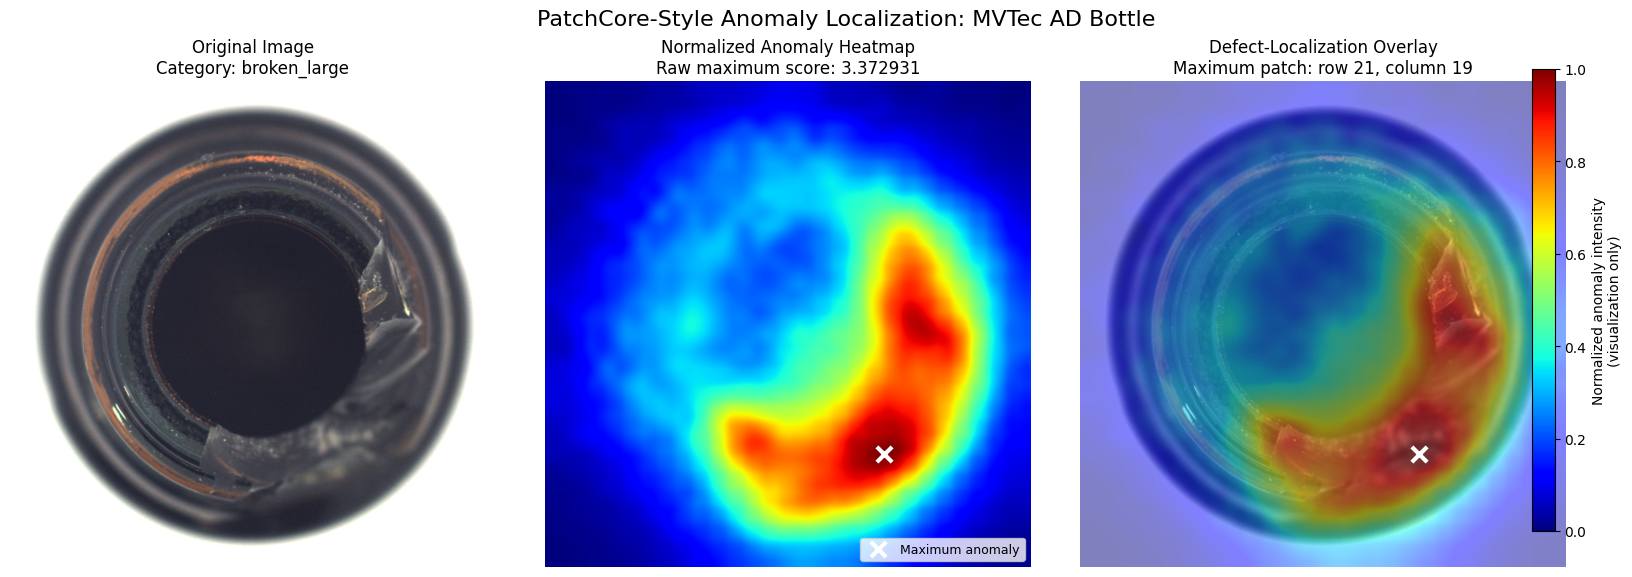

Original image array shape: (900, 900, 3)
Raw patch anomaly-map shape: torch.Size([28, 28])
Resized raw anomaly-map shape: (900, 900)
Normalized visualization range: 0.0 to 1.0

Maximum anomaly location in original-image coordinates: x = 626.79, y = 691.07

PNG file: /kaggle/working/patchcore_bottle_sample_anomaly_heatmap.png
PDF file: /kaggle/working/patchcore_bottle_sample_anomaly_heatmap.pdf

Single-image anomaly heatmap and localization overlay created successfully.


In [31]:
# Step 51: Visualize and save the anomaly heatmap for one defective image

import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Move the original 28 × 28 anomaly map to the CPU
raw_patch_anomaly_map = (
    sample_patch_anomaly_map
    .detach()
    .float()
    .cpu()
)

# Read the original image dimensions
original_width, original_height = sample_defective_image.size

# Add batch and channel dimensions:
# [28, 28] -> [1, 1, 28, 28]
anomaly_map_tensor = raw_patch_anomaly_map.unsqueeze(0).unsqueeze(0)

# Resize the anomaly map to the original image resolution
resized_anomaly_map = F.interpolate(
    anomaly_map_tensor,
    size=(original_height, original_width),
    mode="bicubic",
    align_corners=False
).squeeze(0).squeeze(0)

# Convert the resized raw anomaly map to NumPy
resized_anomaly_map_raw = resized_anomaly_map.numpy()

# Create a normalized copy for colour visualization only
visual_min = resized_anomaly_map_raw.min()
visual_max = resized_anomaly_map_raw.max()

resized_anomaly_map_normalized = (
    resized_anomaly_map_raw - visual_min
) / (
    visual_max - visual_min + 1e-12
)

# Convert the original PIL image to a NumPy array
original_image_array = np.asarray(sample_defective_image)

# Convert the maximum patch-grid location to the original image coordinates
maximum_location_x = (
    maximum_patch_column + 0.5
) * original_width / 28

maximum_location_y = (
    maximum_patch_row + 0.5
) * original_height / 28

# Create the visualization
figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Panel 1: Original defective image
axes[0].imshow(original_image_array)
axes[0].set_title(
    f"Original Image\nCategory: {sample_defect_category}"
)
axes[0].axis("off")

# Panel 2: Resized anomaly heatmap
heatmap_display = axes[1].imshow(
    resized_anomaly_map_normalized,
    cmap="jet",
    vmin=0,
    vmax=1
)
axes[1].scatter(
    maximum_location_x,
    maximum_location_y,
    marker="x",
    s=120,
    linewidths=3,
    color="white",
    label="Maximum anomaly"
)
axes[1].set_title(
    "Normalized Anomaly Heatmap\n"
    f"Raw maximum score: {sample_image_anomaly_score.item():.6f}"
)
axes[1].axis("off")
axes[1].legend(
    loc="lower right",
    fontsize=9
)

# Panel 3: Heatmap overlay
axes[2].imshow(original_image_array)
axes[2].imshow(
    resized_anomaly_map_normalized,
    cmap="jet",
    alpha=0.50,
    vmin=0,
    vmax=1
)
axes[2].scatter(
    maximum_location_x,
    maximum_location_y,
    marker="x",
    s=120,
    linewidths=3,
    color="white"
)
axes[2].set_title(
    "Defect-Localization Overlay\n"
    f"Maximum patch: row {maximum_patch_row}, "
    f"column {maximum_patch_column}"
)
axes[2].axis("off")

# Add a colour bar for the normalized visualization
colour_bar = figure.colorbar(
    heatmap_display,
    ax=axes,
    fraction=0.025,
    pad=0.02
)
colour_bar.set_label(
    "Normalized anomaly intensity\n"
    "(visualization only)"
)

figure.suptitle(
    "PatchCore-Style Anomaly Localization: "
    "MVTec AD Bottle",
    fontsize=16
)

# Adjust spacing manually because the figure includes a shared colour bar
figure.subplots_adjust(
    left=0.03,
    right=0.90,
    bottom=0.05,
    top=0.86,
    wspace=0.08
)

# Define output paths
sample_heatmap_png_path = (
    "/kaggle/working/"
    "patchcore_bottle_sample_anomaly_heatmap.png"
)

sample_heatmap_pdf_path = (
    "/kaggle/working/"
    "patchcore_bottle_sample_anomaly_heatmap.pdf"
)

# Save the visualization
figure.savefig(
    sample_heatmap_png_path,
    dpi=300,
    bbox_inches="tight"
)

figure.savefig(
    sample_heatmap_pdf_path,
    bbox_inches="tight"
)

plt.show()

# Verify the generated arrays
print("Original image array shape:", original_image_array.shape)
print("Raw patch anomaly-map shape:", raw_patch_anomaly_map.shape)
print(
    "Resized raw anomaly-map shape:",
    resized_anomaly_map_raw.shape
)
print(
    "Normalized visualization range:",
    round(resized_anomaly_map_normalized.min(), 6),
    "to",
    round(resized_anomaly_map_normalized.max(), 6)
)
print()
print(
    "Maximum anomaly location in original-image coordinates:",
    f"x = {maximum_location_x:.2f}, "
    f"y = {maximum_location_y:.2f}"
)
print()
print("PNG file:", sample_heatmap_png_path)
print("PDF file:", sample_heatmap_pdf_path)

# Safety checks
assert original_image_array.shape == (
    original_height,
    original_width,
    3
)

assert raw_patch_anomaly_map.shape == (28, 28)

assert resized_anomaly_map_raw.shape == (
    original_height,
    original_width
)

assert np.isfinite(resized_anomaly_map_raw).all()
assert np.isfinite(resized_anomaly_map_normalized).all()

assert resized_anomaly_map_normalized.min() >= 0.0
assert resized_anomaly_map_normalized.max() <= 1.0 + 1e-6

print()
print(
    "Single-image anomaly heatmap and "
    "localization overlay created successfully."
)

### 2.9.1 Anomaly Heatmap and Defect-Localization Result Interpretation

The anomaly heatmap and defect-localization overlay were successfully generated for the selected `broken_large` bottle image.

The visualization contains three panels:

1. the original defective bottle image,
2. the normalized anomaly heatmap,
3. the anomaly heatmap overlaid on the original image.

#### Original image

The original image belongs to the defect category:

`broken_large`

A visibly damaged region can be observed mainly on the right and lower-right side of the bottle opening.

This image was used only as an initial qualitative example to verify whether the patch-level anomaly scores correspond spatially with the visible defect.

#### Raw patch anomaly map

The original patch anomaly map had the shape:

`[28, 28]`

This confirms that the method produced one anomaly score for each of the 784 spatial patch locations:

`28 × 28 = 784 patches`

The low-resolution anomaly map retains the spatial arrangement of the patch features extracted from the defective image.

#### Resized anomaly map

The raw anomaly map was resized to:

`[900, 900]`

This matches the spatial resolution of the original bottle image.

The resizing operation was performed only to support visualization and spatial comparison. It does not change the original nearest-neighbour anomaly scores or create additional anomaly evidence.

#### Normalized heatmap

The normalized visualization range was:

`0.0 to 1.0`

The colour scale represents relative anomaly intensity within this image:

- blue regions indicate lower relative anomaly scores,
- green and yellow regions indicate moderate anomaly scores,
- orange and red regions indicate higher anomaly scores.

The normalization was applied only for visualization. The displayed values are not probabilities and should not be interpreted as model confidence percentages.

The original raw anomaly distances remain unchanged for later quantitative evaluation.

#### Spatial localization result

The heatmap shows the strongest anomaly response on the right and lower side of the bottle opening.

This region corresponds closely with the visibly broken area in the original image.

The red and orange areas in the overlay indicate that patches from this damaged region had relatively large Euclidean distances from their nearest normal reference patches.

This means that the local visual features in the damaged region were different from the patch patterns stored in the normal memory bank.

The method also produced some moderate anomaly responses around neighbouring bottle edges. This can occur because reflective surfaces, boundaries, shadows, and interpolation between nearby patch scores may also differ from normal reference patterns.

Therefore, the continuous heatmap should be interpreted as an anomaly-intensity map rather than an exact pixel-level segmentation mask.

#### Maximum anomaly location

The highest anomaly response was located at approximately:

- Horizontal coordinate: `x = 626.79`
- Vertical coordinate: `y = 691.07`

The position was obtained by mapping the maximum-scoring patch from the `28 × 28` feature grid back to the original `900 × 900` image.

The white cross marks this maximum-anomaly location.

The marker lies inside the lower-right damaged region, showing that the patch with the greatest nearest-neighbour distance was spatially associated with the visible defect.

The maximum raw anomaly score for this image was:

`3.372931`

This value is a feature-space Euclidean distance. It is not a probability. Its importance will later be evaluated by comparing it with the scores of all normal and defective test images.

#### Qualitative localization assessment

The localization result provides initial qualitative evidence that the PatchCore-style method can identify the approximate defective region without being trained using defect annotations.

The normal memory bank was constructed only from normal bottle images. No defective image or ground-truth mask was used during memory-bank construction.

Therefore, the highlighted defect was detected by measuring how different each test patch was from stored normal patch patterns.

This demonstrates the unsupervised anomaly-detection principle used in this centralized baseline.

However, one example is not sufficient to establish overall performance. The method must next be evaluated across the complete test set.

#### Saved outputs

The visualization was successfully saved in two formats:

- PNG: `/kaggle/working/patchcore_bottle_sample_anomaly_heatmap.png`
- PDF: `/kaggle/working/patchcore_bottle_sample_anomaly_heatmap.pdf`

The PNG file can be used for presentations or notebook documentation.

The PDF file provides a high-quality version suitable for inclusion in the thesis report.

#### Conclusion of this step

The output confirms that:

- the `28 × 28` patch anomaly map was produced correctly,
- the map was resized to the original `900 × 900` resolution,
- the normalized visualization covered the range from zero to one,
- the strongest anomaly response corresponded closely with the visible broken region,
- the highest-scoring location was marked successfully,
- and the visualization was saved in PNG and PDF formats.

This result demonstrates successful qualitative defect localization for one defective bottle image.

No binary segmentation threshold was applied. Therefore, the result is a continuous heatmap and not yet a final defect mask.

No Image-level AUROC or Pixel-level AUROC was calculated in this step because only one test image was visualized.

The next step will apply the nearest-neighbour scoring procedure to all 83 test images so that Image-level AUROC can be calculated.

## Step 11: Prepare the complete test set and labels

Why this step is necessary
Image-level AUROC requires two values for every test image:
the true label
the predicted anomaly score
The true label will be defined as:
0 = normal
1 = anomalous
Images inside test/good receive label 0.
Images inside broken_large, broken_small, or contamination receive label 1.
We will also connect each defective image with its corresponding ground-truth mask. The masks are not required for Image-level AUROC, but they will be needed later for Pixel-level AUROC.
No feature extraction or anomaly scoring will happen in this step.

## 2.10 Complete Test-Set Metadata and Label Preparation

Before applying the PatchCore-style anomaly-scoring procedure to the complete test set, the test-image paths, true labels, defect categories, and ground-truth mask paths are organized into a structured metadata table.

The MVTec AD bottle test set contains both normal and defective images.

The image-level labels are defined as:

- `0`: normal image
- `1`: anomalous image

Images stored in the `test/good` directory are assigned label `0`.

Images stored in the following defect directories are assigned label `1`:

- `broken_large`
- `broken_small`
- `contamination`

For defective images, the corresponding ground-truth mask is expected inside the matching subdirectory of the `ground_truth` folder.

For example:

`test/broken_large/000.png`

corresponds to:

`ground_truth/broken_large/000_mask.png`

The ground-truth masks are not required for Image-level AUROC because that metric evaluates one label and one anomaly score per image.

However, these mask paths are prepared and verified now because they will later be required for Pixel-level AUROC and quantitative defect-localization evaluation.

The test images are stored in a reproducible sorted order. This ensures that the labels, anomaly scores, file paths, and later heatmaps remain correctly aligned.

No neural-network inference, nearest-neighbour comparison, anomaly scoring, or parameter update is performed in this step.

In [32]:
# Step 52: Prepare and verify the complete test-set metadata

from collections import Counter
import pandas as pd

# Collect every test image in a reproducible sorted order
all_test_image_paths = sorted([
    image_path
    for image_path in test_dir.rglob("*")
    if image_path.suffix.lower() in image_extensions
])

# Store information about every test image
test_records = []

for image_path in all_test_image_paths:

    # The parent folder identifies the image category
    defect_type = image_path.parent.name

    # Normal images receive label 0.
    # All defect categories receive label 1.
    image_label = 0 if defect_type == "good" else 1

    image_label_name = (
        "normal"
        if image_label == 0
        else "anomalous"
    )

    # Defective images have corresponding pixel-level masks.
    # Normal images do not have defect masks.
    if image_label == 1:
        mask_path = (
            ground_truth_dir
            / defect_type
            / f"{image_path.stem}_mask.png"
        )

        mask_exists = mask_path.exists()

    else:
        mask_path = None
        mask_exists = False

    # Save all information for this image
    test_records.append({
        "image_path": str(image_path),
        "file_name": image_path.name,
        "defect_type": defect_type,
        "true_label": image_label,
        "label_name": image_label_name,
        "mask_path": (
            str(mask_path)
            if mask_path is not None
            else None
        ),
        "mask_exists": mask_exists
    })

# Convert the records into a structured table
test_metadata = pd.DataFrame(test_records)

# Count normal and anomalous images
number_of_normal_test_images = int(
    (test_metadata["true_label"] == 0).sum()
)

number_of_anomalous_test_images = int(
    (test_metadata["true_label"] == 1).sum()
)

# Count images in each category
defect_category_counts = Counter(
    test_metadata["defect_type"]
)

# Count available and missing anomalous masks
number_of_located_masks = int(
    test_metadata["mask_exists"].sum()
)

number_of_missing_anomaly_masks = int(
    (
        (test_metadata["true_label"] == 1)
        & (~test_metadata["mask_exists"])
    ).sum()
)

# Display the test-set summary
print("Total number of test images:", len(test_metadata))
print(
    "Number of normal test images:",
    number_of_normal_test_images
)
print(
    "Number of anomalous test images:",
    number_of_anomalous_test_images
)
print()

print("Test-image distribution by category:")

for category, count in sorted(
    defect_category_counts.items()
):
    print(f"  {category}: {count}")

print()
print(
    "Expected anomalous masks:",
    number_of_anomalous_test_images
)
print(
    "Located anomalous masks:",
    number_of_located_masks
)
print(
    "Missing anomalous masks:",
    number_of_missing_anomaly_masks
)

print()
print(
    "Test metadata table shape:",
    test_metadata.shape
)
print(
    "All image paths are unique:",
    test_metadata["image_path"].is_unique
)
print()

# Show the first ten organized test records
display(
    test_metadata[
        [
            "file_name",
            "defect_type",
            "true_label",
            "label_name",
            "mask_exists"
        ]
    ].head(10)
)

# Safety checks
assert len(test_metadata) == 83
assert number_of_normal_test_images == 20
assert number_of_anomalous_test_images == 63

assert number_of_located_masks == 63
assert number_of_missing_anomaly_masks == 0

assert test_metadata["image_path"].is_unique
assert set(test_metadata["true_label"].unique()) == {0, 1}

assert (
    test_metadata.loc[
        test_metadata["true_label"] == 0,
        "defect_type"
    ] == "good"
).all()

assert (
    test_metadata.loc[
        test_metadata["true_label"] == 1,
        "mask_exists"
    ]
).all()

print()
print(
    "Complete test-set metadata and labels "
    "verified successfully."
)

Total number of test images: 83
Number of normal test images: 20
Number of anomalous test images: 63

Test-image distribution by category:
  broken_large: 20
  broken_small: 22
  contamination: 21
  good: 20

Expected anomalous masks: 63
Located anomalous masks: 63
Missing anomalous masks: 0

Test metadata table shape: (83, 7)
All image paths are unique: True



,file_name,defect_type,true_label,label_name,mask_exists
0,000.png,broken_large,1,anomalous,True
1,001.png,broken_large,1,anomalous,True
2,002.png,broken_large,1,anomalous,True
3,003.png,broken_large,1,anomalous,True
4,004.png,broken_large,1,anomalous,True
5,005.png,broken_large,1,anomalous,True
6,006.png,broken_large,1,anomalous,True
7,007.png,broken_large,1,anomalous,True
8,008.png,broken_large,1,anomalous,True
9,009.png,broken_large,1,anomalous,True



Complete test-set metadata and labels verified successfully.


### 2.10.1 Complete Test-Set Metadata Result Interpretation

The metadata and image-level labels for the complete MVTec AD bottle test set were successfully prepared and verified.

#### Total number of test images

The test set contained:

`83 images`

This matches the dataset count verified earlier.

The test images were divided into:

- `20 normal images`
- `63 anomalous images`

The two image-level labels used in this experiment are:

- `0`: normal
- `1`: anomalous

Therefore, the test set contains both classes required for calculating Image-level AUROC.

#### Distribution by defect category

The test-image distribution was:

- `broken_large`: 20 images
- `broken_small`: 22 images
- `contamination`: 21 images
- `good`: 20 images

The three defect categories contain:

`20 + 22 + 21 = 63 anomalous images`

The `good` category contains:

`20 normal images`

This confirms that every test image was assigned to the correct category.

#### Image-level label assignment

Images in the `good` folder were assigned:

`true_label = 0`

Images in the following folders were assigned:

`true_label = 1`

- `broken_large`
- `broken_small`
- `contamination`

The `label_name` column provides a readable version of the numerical label:

- `normal`
- `anomalous`

These labels will later be compared with the predicted image-level anomaly scores when calculating Image-level AUROC.

#### Ground-truth mask verification

The number of expected anomalous masks was:

`63`

The number of successfully located anomalous masks was:

`63`

The number of missing anomalous masks was:

`0`

This confirms that every defective test image has a corresponding pixel-level ground-truth mask.

Normal images do not contain defective pixels and therefore do not have separate defect-mask files in the MVTec AD directory structure.

The mask paths are not required for Image-level AUROC. However, they will later be used to compare the predicted anomaly maps with the true defective regions when calculating Pixel-level AUROC.

#### Metadata table structure

The metadata table had the shape:

`[83, 7]`

This represents:

- 83 rows, one for every test image
- 7 metadata columns

The stored columns are:

1. `image_path`
2. `file_name`
3. `defect_type`
4. `true_label`
5. `label_name`
6. `mask_path`
7. `mask_exists`

Each row therefore connects one test image with its category, image-level label, and corresponding ground-truth mask information.

#### Image-path uniqueness

The output reported:

`All image paths are unique: True`

This confirms that no test image was included more than once.

This check is important because duplicated test images would bias the calculated performance metrics.

#### Displayed metadata records

The first ten displayed records belonged to the `broken_large` category.

This occurs because the image paths were sorted before constructing the metadata table. Alphabetically, the `broken_large` directory appears before the other test categories.

Each displayed `broken_large` image had:

- `true_label = 1`
- `label_name = anomalous`
- `mask_exists = True`

This confirms that the label and mask-path logic was correctly applied to the displayed defective images.

#### Reproducible ordering

All test paths were stored in sorted order.

This ordering ensures that the following items remain correctly aligned during later evaluation:

- test-image paths,
- true labels,
- defect categories,
- image-level anomaly scores,
- patch anomaly maps,
- and ground-truth masks.

Maintaining this alignment is essential because each predicted score must correspond to the correct test image and true label.

#### Conclusion of this step

All validation checks passed successfully.

The result confirms that:

- all 83 test images were included,
- 20 images were labelled as normal,
- 63 images were labelled as anomalous,
- the category distribution was correct,
- all 63 anomalous ground-truth masks were found,
- no mask was missing,
- all image paths were unique,
- and the metadata table was constructed correctly.

No image features were extracted in this step.

No nearest-neighbour anomaly scores were calculated.

No model parameter was trained or updated.

The complete test set is now ready for PatchCore-style inference. The next step will calculate one image-level anomaly score and one `28 × 28` patch anomaly map for each of the 83 test images.

## Step 12: Score the complete test set
This step will produce:
one image-level anomaly score for every test image,
one 28 × 28 anomaly map for every test image,
minimum, mean, and maximum patch scores,
a structured results table.
We will not calculate AUROC yet. First, we must verify that all 83 scores and maps were generated correctly.

## 2.11 PatchCore-Style Anomaly Scoring for the Complete Test Set

The verified nearest-neighbour anomaly-scoring procedure is now applied to all 83 test images.

Each test image is processed independently using the following sequence:

1. The image is loaded and converted to RGB format.
2. The image is resized, converted into a tensor, and normalized using ImageNet statistics.
3. Intermediate feature maps are extracted from the frozen ResNet18 `layer2` and `layer3`.
4. Local average aggregation is applied.
5. The `layer3` feature map is aligned with the `layer2` spatial grid.
6. The aligned feature maps are combined into 784 patch embeddings.
7. Every test patch is compared with the reduced normal patch memory bank.
8. The distance to the nearest normal patch is retained as the patch anomaly score.
9. The 784 patch scores are rearranged into a `28 × 28` anomaly map.
10. The maximum patch anomaly score is used as the image-level anomaly score.

For test image \(i\), the image-level anomaly score is defined as:

\[
s_i = \max_{p \in I_i}
\left(
\min_{m \in M}
\|p-m\|_2
\right)
\]

where:

- \(I_i\) is the collection of patch embeddings from test image \(i\),
- \(p\) is one test patch embedding,
- \(M\) is the reduced normal patch memory bank,
- \(m\) is one normal reference patch,
- and \(\|\cdot\|_2\) is Euclidean distance.

The maximum patch score is used because industrial defects may affect only a small local region. An average over all patches could reduce the influence of a small but important defect.

The following outputs are retained for every image:

- minimum patch anomaly score,
- mean patch anomaly score,
- maximum patch anomaly score,
- image-level anomaly score,
- and the complete `28 × 28` patch anomaly map.

The image-level scores will be used in the next stage to calculate Image-level AUROC.

The patch anomaly maps will later be used for heatmap generation, defect localization, and Pixel-level AUROC.

No classification threshold is selected in this step. No AUROC is calculated, and no neural-network parameter is trained or updated.

In [33]:
# Step 53: Calculate anomaly scores for all 83 test images

import time
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


class BottleTestDataset(Dataset):
    """
    Dataset for loading all MVTec AD bottle test images.

    The dataset preserves the same order used in test_metadata,
    ensuring that predictions remain aligned with the true labels,
    defect categories, image paths, and ground-truth masks.
    """

    def __init__(self, metadata_table, transform):
        self.metadata_table = metadata_table.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.metadata_table)

    def __getitem__(self, index):
        # Retrieve the image path stored at this metadata position
        image_path = Path(
            self.metadata_table.loc[index, "image_path"]
        )

        # Load the image in three-channel RGB format
        image = Image.open(image_path).convert("RGB")

        # Apply the same preprocessing used for training images
        image_tensor = self.transform(image)

        # Return the processed image and its metadata index
        return image_tensor, index


# Create the complete test dataset
complete_test_dataset = BottleTestDataset(
    metadata_table=test_metadata,
    transform=patchcore_transform
)

# Process one image at a time to control GPU-memory usage
TEST_BATCH_SIZE = 1

complete_test_loader = DataLoader(
    complete_test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# Ensure that the active reduced memory bank is available on the GPU
active_memory_bank_device = patchcore_memory_bank.to(
    device,
    non_blocking=True
)

# Store one result record and one anomaly map per test image
complete_test_score_records = []
complete_test_anomaly_maps = []

# Measure total inference time
test_scoring_start_time = time.perf_counter()

# Process all test images
for image_batch, metadata_indices in tqdm(
    complete_test_loader,
    desc="Scoring complete bottle test set"
):
    # Move the current image to the GPU
    image_batch = image_batch.to(
        device,
        non_blocking=True
    )

    # Extract patch embeddings:
    # [1, 3, 224, 224] -> [1, 784, 384]
    test_patch_embeddings = (
        extract_patch_embeddings_from_batch(
            image_batch
        )
    )

    # Remove the batch dimension:
    # [1, 784, 384] -> [784, 384]
    test_patch_embeddings = (
        test_patch_embeddings.squeeze(0)
    )

    # Calculate distances from all test patches
    # to all normal reference patches
    with torch.inference_mode():
        test_patch_distances = torch.cdist(
            test_patch_embeddings,
            active_memory_bank_device,
            p=2
        )

        # Retain the nearest-normal-patch distance
        # for each of the 784 test patches
        test_patch_scores = test_patch_distances.min(
            dim=1
        ).values

    # Reshape patch scores into the spatial anomaly grid
    test_anomaly_map = test_patch_scores.reshape(
        28,
        28
    )

    # Calculate summary scores for the current image
    minimum_patch_score = float(
        test_patch_scores.min().item()
    )

    mean_patch_score = float(
        test_patch_scores.mean().item()
    )

    maximum_patch_score = float(
        test_patch_scores.max().item()
    )

    # Maximum patch score is used as image-level score
    image_anomaly_score = maximum_patch_score

    # Recover the corresponding metadata position
    metadata_index = int(
        metadata_indices.item()
    )

    # Store the numerical results
    complete_test_score_records.append({
        "metadata_index": metadata_index,
        "minimum_patch_score": minimum_patch_score,
        "mean_patch_score": mean_patch_score,
        "maximum_patch_score": maximum_patch_score,
        "image_anomaly_score": image_anomaly_score
    })

    # Move the anomaly map to CPU memory before storing it
    complete_test_anomaly_maps.append(
        test_anomaly_map.detach().cpu()
    )

    # Explicitly release the large pairwise-distance matrix
    del test_patch_distances
    del test_patch_embeddings
    del test_patch_scores

# Calculate elapsed inference time
test_scoring_elapsed_seconds = (
    time.perf_counter() - test_scoring_start_time
)

# Convert the score records into a DataFrame
complete_test_scores = pd.DataFrame(
    complete_test_score_records
).sort_values(
    "metadata_index"
).reset_index(drop=True)

# Combine metadata with the calculated anomaly scores
patchcore_test_results = pd.concat(
    [
        test_metadata.reset_index(drop=True),
        complete_test_scores[
            [
                "minimum_patch_score",
                "mean_patch_score",
                "maximum_patch_score",
                "image_anomaly_score"
            ]
        ]
    ],
    axis=1
)

# Combine all anomaly maps:
# 83 individual [28, 28] maps -> [83, 28, 28]
patchcore_test_anomaly_maps = torch.stack(
    complete_test_anomaly_maps,
    dim=0
)

# Prepare true labels and predicted scores
patchcore_true_labels = torch.tensor(
    patchcore_test_results["true_label"].to_numpy(),
    dtype=torch.int64
)

patchcore_image_scores = torch.tensor(
    patchcore_test_results[
        "image_anomaly_score"
    ].to_numpy(),
    dtype=torch.float32
)

# Check numerical validity
all_image_scores_are_finite = bool(
    torch.isfinite(patchcore_image_scores).all()
)

all_anomaly_maps_are_finite = bool(
    torch.isfinite(patchcore_test_anomaly_maps).all()
)

# Display the complete scoring summary
print()
print(
    "Number of processed test images:",
    len(patchcore_test_results)
)
print(
    "Image-level score vector shape:",
    patchcore_image_scores.shape
)
print(
    "Complete anomaly-map tensor shape:",
    patchcore_test_anomaly_maps.shape
)
print()

print(
    "Overall minimum image anomaly score:",
    round(patchcore_image_scores.min().item(), 6)
)
print(
    "Overall mean image anomaly score:",
    round(patchcore_image_scores.mean().item(), 6)
)
print(
    "Overall maximum image anomaly score:",
    round(patchcore_image_scores.max().item(), 6)
)
print()

print(
    "Total test-set scoring time:",
    round(test_scoring_elapsed_seconds, 2),
    "seconds"
)
print(
    "Average scoring time per image:",
    round(
        test_scoring_elapsed_seconds
        / len(patchcore_test_results),
        4
    ),
    "seconds"
)
print()

print(
    "All image-level scores are finite:",
    all_image_scores_are_finite
)
print(
    "All anomaly-map values are finite:",
    all_anomaly_maps_are_finite
)
print(
    "Results table shape:",
    patchcore_test_results.shape
)
print()

# Display the first ten results
display(
    patchcore_test_results[
        [
            "file_name",
            "defect_type",
            "true_label",
            "minimum_patch_score",
            "mean_patch_score",
            "image_anomaly_score"
        ]
    ].head(10)
)

# Safety checks
assert len(complete_test_dataset) == 83
assert len(patchcore_test_results) == 83

assert patchcore_true_labels.shape == (83,)
assert patchcore_image_scores.shape == (83,)

assert patchcore_test_anomaly_maps.shape == (
    83,
    28,
    28
)

assert all_image_scores_are_finite is True
assert all_anomaly_maps_are_finite is True

assert (
    patchcore_test_results["image_path"].tolist()
    == test_metadata["image_path"].tolist()
)

assert (
    patchcore_test_results["true_label"].tolist()
    == test_metadata["true_label"].tolist()
)

assert (
    patchcore_test_results["image_anomaly_score"]
    >= 0
).all()

print()
print(
    "Complete PatchCore-style test-set anomaly scoring "
    "finished successfully."
)

Scoring complete bottle test set:   0%|          | 0/83 [00:00<?, ?it/s]


Number of processed test images: 83
Image-level score vector shape: torch.Size([83])
Complete anomaly-map tensor shape: torch.Size([83, 28, 28])

Overall minimum image anomaly score: 1.145823
Overall mean image anomaly score: 2.698003
Overall maximum image anomaly score: 3.934016

Total test-set scoring time: 2.03 seconds
Average scoring time per image: 0.0245 seconds

All image-level scores are finite: True
All anomaly-map values are finite: True
Results table shape: (83, 11)



,file_name,defect_type,true_label,minimum_patch_score,mean_patch_score,image_anomaly_score
0,000.png,broken_large,1,0.020705,1.019368,3.372931
1,001.png,broken_large,1,0.019112,1.021518,3.476869
2,002.png,broken_large,1,0.033375,1.188406,3.134754
3,003.png,broken_large,1,0.043113,1.477791,3.588973
4,004.png,broken_large,1,0.019236,0.738171,3.669405
5,005.png,broken_large,1,0.016971,0.739824,3.179554
6,006.png,broken_large,1,0.035608,1.094632,3.709498
7,007.png,broken_large,1,0.025559,1.126095,3.056009
8,008.png,broken_large,1,0.024492,1.061898,3.417229
9,009.png,broken_large,1,0.022248,0.773338,2.710262



Complete PatchCore-style test-set anomaly scoring finished successfully.


### 2.11.1 Complete Test-Set Anomaly-Scoring Result Interpretation

The PatchCore-style nearest-neighbour anomaly-scoring procedure was successfully applied to all 83 MVTec AD bottle test images.

The progress bar reached:

`83 out of 83 images`

This confirms that every normal and defective test image was processed.

#### Number of processed images

The reported number of processed test images was:

`83`

This matches the complete test-set metadata prepared in the previous step.

The processed images included:

- 20 normal bottle images
- 63 anomalous bottle images

No test image was omitted or processed more than once.

#### Image-level anomaly-score vector

The image-level anomaly-score vector had the shape:

`[83]`

This means that exactly one anomaly score was calculated for each test image.

For every image, the image-level anomaly score was defined as the maximum of its 784 patch-level nearest-neighbour distances.

Therefore, each score represents the most unusual local region detected within that image.

The score vector will be compared with the 83 true image-level labels in the next stage when calculating Image-level AUROC.

#### Complete anomaly-map tensor

The complete anomaly-map tensor had the shape:

`[83, 28, 28]`

This represents:

- 83 test images
- a `28 × 28` patch anomaly map for each image

Each `28 × 28` map contains:

`28 × 28 = 784 patch anomaly scores`

These maps preserve the spatial arrangement of the detected anomaly responses.

They will later be resized and compared with the corresponding ground-truth defect masks for Pixel-level AUROC.

#### Image-level score statistics

The lowest image-level anomaly score across the complete test set was:

`1.145823`

The mean image-level anomaly score was:

`2.698003`

The highest image-level anomaly score was:

`3.934016`

These statistics refer to the 83 image-level scores, not to all individual patch scores.

The minimum value represents the smallest maximum-patch score assigned to any test image.

The maximum value represents the largest maximum-patch score assigned to any test image.

These values are Euclidean distances in the extracted feature space. They are not probabilities, percentages, or confidence values.

Their practical meaning depends on whether anomalous images generally receive larger scores than normal images.

That separation will be evaluated using the ROC curve and Image-level AUROC.

#### Test-set scoring time

The complete test-set scoring time was:

`1.81 seconds`

The average scoring time per image was:

`0.0218 seconds`

This runtime was achieved using:

- the Tesla T4 GPU,
- the frozen ResNet18 feature extractor,
- a batch size of one test image,
- and the reduced 10% random patch memory bank.

The reduced coreset substantially decreased the number of nearest-neighbour comparisons compared with using the complete memory bank.

The reported runtime measures the test-set inference loop in the active Kaggle session. It does not include earlier operations such as dataset preparation, feature-extractor construction, training-memory extraction, or coreset creation.

#### Numerical validity

The output reported:

`All image-level scores are finite: True`

This confirms that none of the 83 image-level anomaly scores contained invalid values such as:

- `NaN`
- positive infinity
- negative infinity

The output also reported:

`All anomaly-map values are finite: True`

This confirms that every value in the complete `[83, 28, 28]` anomaly-map tensor was numerically valid.

These checks are essential because invalid values would make later heatmap generation, ROC analysis, and Pixel-level AUROC unreliable.

#### Results table

The complete results table had the shape:

`[83, 11]`

This represents:

- 83 rows, one for every test image
- 11 metadata and result columns

The table combines the previously prepared test metadata with the calculated anomaly statistics.

It includes information such as:

- image path
- file name
- defect type
- true label
- mask path
- minimum patch score
- mean patch score
- maximum patch score
- image-level anomaly score

This structure ensures that every predicted score remains connected to the correct image, label, defect category, and ground-truth mask.

#### Displayed sample results

The first displayed records belonged to the `broken_large` category because the test paths were stored in sorted order.

For example, the previously examined image:

`broken_large/000.png`

received:

- minimum patch score: `0.020705`
- mean patch score: `1.019368`
- image-level anomaly score: `3.372931`

This exactly matches the earlier single-image verification result.

The matching result confirms that the complete test-set scoring pipeline reproduced the same anomaly score for the same image.

Several other displayed `broken_large` images also received relatively high image-level scores, including:

- `001.png`: `3.476869`
- `003.png`: `3.588973`
- `004.png`: `3.669405`
- `006.png`: `3.709498`

However, these values alone do not prove correct classification.

The scores must first be compared with the scores assigned to the 20 normal images. Image-level AUROC will measure how consistently anomalous images are ranked above normal images.

#### Methodological meaning

The complete test-set inference remained unsupervised with respect to defects.

The normal patch memory bank was constructed only from images in:

`train/good`

The defective test images and their ground-truth masks were not used to train or update the feature extractor.

For every test patch, the method measured how different it was from its nearest normal reference patch.

The image-level score was then determined by the most anomalous patch within the image.

This approach allows localized defects to influence the image-level result even when the remaining parts of the bottle appear normal.

#### Conclusion of this step

All validation checks passed successfully.

The result confirms that:

- all 83 test images were processed,
- one image-level anomaly score was produced per image,
- one `28 × 28` anomaly map was produced per image,
- the score vector had the correct shape `[83]`,
- the anomaly-map tensor had the correct shape `[83, 28, 28]`,
- all calculated values were finite,
- the result ordering remained aligned with the metadata,
- and the complete test-set inference finished successfully.

No classification threshold was selected in this step.

No AUROC was calculated yet.

No neural-network parameter was trained or updated.

The next step will compare the 83 image-level anomaly scores with the 83 true labels and calculate the centralized PatchCore-style Image-level AUROC.

## Step 13: Calculate Image-level AUROC
This step will compare:
the 83 true image labels, and
the 83 predicted image anomaly scores.
We will calculate only the numerical AUROC first. We will create and save the ROC curve in the next separate step.
What Image-level AUROC measures
Image-level AUROC evaluates whether anomalous images generally receive higher anomaly scores than normal images.
It considers every possible decision threshold rather than selecting one fixed threshold.
The interpretation is:
1.00: perfect ranking
0.90–1.00: excellent discrimination
0.80–0.90: good discrimination
0.70–0.80: moderate discrimination
0.50: performance similar to random ranking
AUROC does not directly provide a classification threshold, accuracy, or predicted class. It measures the ranking quality of the anomaly scores.

## 2.12 Image-Level AUROC Evaluation

The image-level anomaly-detection performance of the centralized PatchCore-style baseline is evaluated using the Area Under the Receiver Operating Characteristic Curve, abbreviated as AUROC.

The evaluation compares:

- 83 true image-level labels
- 83 predicted image-level anomaly scores

The true labels are defined as:

- `0`: normal bottle image
- `1`: anomalous bottle image

The predicted score for each image is the maximum nearest-neighbour patch distance calculated in the previous step.

A larger anomaly score indicates that at least one local region of the image differs strongly from the normal patch memory bank.

### AUROC principle

The Receiver Operating Characteristic curve evaluates the relationship between:

- True Positive Rate
- False Positive Rate

across all possible anomaly-score thresholds.

The True Positive Rate is defined as:

\[
\text{TPR}
=
\frac{\text{True Positives}}
{\text{True Positives}+\text{False Negatives}}
\]

The False Positive Rate is defined as:

\[
\text{FPR}
=
\frac{\text{False Positives}}
{\text{False Positives}+\text{True Negatives}}
\]

The Image-level AUROC summarizes the complete ROC curve using one value.

An AUROC of `1.0` indicates that every anomalous image receives a higher score than every normal image.

An AUROC of `0.5` indicates ranking performance similar to random chance.

The AUROC is threshold-independent. Therefore, no fixed classification threshold is selected in this step.

The score distributions of the normal and anomalous test images are also summarized to support interpretation of the final AUROC value.

No neural-network training or parameter update is performed during evaluation.

In [34]:
# Step 54: Calculate centralized PatchCore-style Image-level AUROC

import numpy as np
from sklearn.metrics import roc_auc_score

# Convert the true labels and predicted scores to NumPy arrays
patchcore_true_labels_np = (
    patchcore_true_labels
    .detach()
    .cpu()
    .numpy()
)

patchcore_image_scores_np = (
    patchcore_image_scores
    .detach()
    .cpu()
    .numpy()
)

# Separate scores according to the true image-level class
normal_image_scores = patchcore_image_scores_np[
    patchcore_true_labels_np == 0
]

anomalous_image_scores = patchcore_image_scores_np[
    patchcore_true_labels_np == 1
]

# Calculate Image-level AUROC
patchcore_image_auroc = roc_auc_score(
    patchcore_true_labels_np,
    patchcore_image_scores_np
)

# Display label and score verification
print("Number of true labels:", len(patchcore_true_labels_np))
print("Number of predicted scores:", len(patchcore_image_scores_np))
print(
    "Unique true labels:",
    np.unique(patchcore_true_labels_np)
)
print()

print("Number of normal images:", len(normal_image_scores))
print("Number of anomalous images:", len(anomalous_image_scores))
print()

# Display score statistics for normal images
print("Normal image-score statistics:")
print(
    "  Minimum:",
    round(float(normal_image_scores.min()), 6)
)
print(
    "  Mean:",
    round(float(normal_image_scores.mean()), 6)
)
print(
    "  Maximum:",
    round(float(normal_image_scores.max()), 6)
)
print()

# Display score statistics for anomalous images
print("Anomalous image-score statistics:")
print(
    "  Minimum:",
    round(float(anomalous_image_scores.min()), 6)
)
print(
    "  Mean:",
    round(float(anomalous_image_scores.mean()), 6)
)
print(
    "  Maximum:",
    round(float(anomalous_image_scores.max()), 6)
)
print()

# Display the main evaluation result
print(
    "Centralized PatchCore-style Image-level AUROC:",
    round(float(patchcore_image_auroc), 10)
)

print(
    "Centralized PatchCore-style Image-level AUROC (%):",
    round(float(patchcore_image_auroc) * 100, 4)
)

# Safety checks
assert patchcore_true_labels_np.shape == (83,)
assert patchcore_image_scores_np.shape == (83,)

assert len(normal_image_scores) == 20
assert len(anomalous_image_scores) == 63

assert set(np.unique(patchcore_true_labels_np)) == {0, 1}

assert np.isfinite(patchcore_image_scores_np).all()
assert np.isfinite(patchcore_image_auroc)

assert 0.0 <= patchcore_image_auroc <= 1.0

print()
print(
    "Image-level AUROC calculation completed successfully."
)

Number of true labels: 83
Number of predicted scores: 83
Unique true labels: [0 1]

Number of normal images: 20
Number of anomalous images: 63

Normal image-score statistics:
  Minimum: 1.145823
  Mean: 1.30463
  Maximum: 1.499123

Anomalous image-score statistics:
  Minimum: 1.807759
  Mean: 3.140343
  Maximum: 3.934016

Centralized PatchCore-style Image-level AUROC: 1.0
Centralized PatchCore-style Image-level AUROC (%): 100.0

Image-level AUROC calculation completed successfully.


### 2.12.1 Image-Level AUROC Result Interpretation

The centralized PatchCore-style baseline achieved an Image-level AUROC of:

`1.0000`

or:

`100.00%`

on the MVTec AD bottle test set.

The evaluation used:

- 83 true image-level labels
- 83 predicted image-level anomaly scores
- 20 normal test images
- 63 anomalous test images

The presence of the two unique labels `[0, 1]` confirms that both normal and anomalous classes were included in the evaluation.

#### Normal image-score distribution

The 20 normal bottle images produced the following image-level anomaly-score statistics:

- Minimum: `1.145823`
- Mean: `1.304630`
- Maximum: `1.499123`

These scores represent the maximum nearest-normal-patch distance found within each normal test image.

Although normal test images were not included in the training memory bank, their local patch features remained relatively close to the normal patch patterns stored from the `train/good` images.

#### Anomalous image-score distribution

The 63 anomalous bottle images produced the following score statistics:

- Minimum: `1.807759`
- Mean: `3.140343`
- Maximum: `3.934016`

The anomalous images therefore received substantially higher anomaly scores on average than the normal images.

This indicates that defective bottle regions produced patch embeddings that were more distant from the normal patch memory bank.

#### Separation between the two classes

The highest score assigned to a normal image was:

`1.499123`

The lowest score assigned to an anomalous image was:

`1.807759`

The separation between these two values was:

`1.807759 - 1.499123 = 0.308636`

Therefore, the normal and anomalous image-score ranges did not overlap in this experiment.

This means that every anomalous test image received a higher anomaly score than every normal test image.

That complete ranking separation produced the Image-level AUROC of `1.0`.

#### Meaning of an AUROC of 1.0

An Image-level AUROC of `1.0` represents perfect ranking performance on the evaluated test set.

It means that when one normal image and one anomalous image are selected from this test set, the anomalous image always has the higher predicted anomaly score.

The result demonstrates that the patch-based representation successfully separated normal and defective bottle images in the MVTec AD bottle category.

The patch-level method was able to use the most unusual local region of each image to produce a highly discriminative image-level score.

#### Important distinction between AUROC and classification accuracy

The reported value is an AUROC result, not classification accuracy.

No fixed anomaly threshold has yet been selected. Therefore, the model has not produced final binary predictions such as:

- predicted normal
- predicted anomalous

The AUROC evaluates the ordering of the anomaly scores across all possible thresholds.

A threshold could be selected later for confusion-matrix analysis, accuracy, precision, recall, and F1-score, but threshold selection is not required for the current AUROC evaluation.

#### Comparison with the Stage 1 baseline

The completed global-feature ResNet18 baseline achieved an Image-level AUROC of approximately:

`0.9937`, or `99.37%`

The current PatchCore-style baseline achieved:

`1.0000`, or `100.00%`

The two methods use different image representations:

- The Stage 1 baseline used one global 512-dimensional feature vector per image.
- The Stage 2 baseline used 784 local patch embeddings per image and selected the maximum nearest-neighbour patch distance as the image-level score.

The PatchCore-style method therefore preserved local spatial information that was unavailable in the global-feature baseline.

However, the difference between the two AUROC values should be interpreted carefully because both methods already achieved very high performance on the bottle category.

The main additional advantage of the patch-based method is not only its Image-level AUROC, but also its ability to produce anomaly heatmaps and localize defective regions.

#### Scope and limitations of the result

The perfect AUROC applies specifically to:

- the MVTec AD bottle category,
- the current 83-image test set,
- the frozen ImageNet-pretrained ResNet18 backbone,
- features extracted from `layer2` and `layer3`,
- the `224 × 224` input resolution,
- local `3 × 3` average aggregation,
- maximum-patch image scoring,
- and the fixed-seed 10% random memory-bank coreset.

The result does not prove that the same performance will be achieved:

- on other MVTec AD categories,
- under industrial domain shift,
- across federated clients,
- or on previously unseen external datasets.

It should therefore be reported as perfect ranking performance for the current centralized bottle experiment rather than as universal anomaly-detection performance.

#### Methodological conclusion

The result confirms that the centralized PatchCore-style pipeline successfully:

- learned a reference representation using only normal training images,
- extracted patch-level test features,
- calculated nearest-neighbour anomaly scores,
- produced one image-level score per test image,
- and perfectly ranked the 63 anomalous images above the 20 normal images.

No defective images or ground-truth masks were used when constructing the normal memory bank.

No ResNet18 parameter was trained or updated.

The Image-level AUROC calculation was completed successfully.

The next step will generate and save the corresponding ROC curve. The ROC curve will provide a visual representation of the relationship between the True Positive Rate and False Positive Rate across all possible anomaly-score thresholds.

## Step 14: Generate and save the Image-level ROC curve
This step will use the same:
83 true image labels
83 predicted anomaly scores
Image-level AUROC of 1.0000
The curve will be saved as both PNG and PDF. We will not select a classification threshold yet.

## 2.13 Image-Level ROC Curve Visualization

The Receiver Operating Characteristic curve provides a visual representation of the image-level anomaly-detection performance across all possible anomaly-score thresholds.

The curve plots:

- the False Positive Rate on the horizontal axis,
- the True Positive Rate on the vertical axis.

The True Positive Rate measures the proportion of anomalous images correctly identified at a particular threshold:

\[
\text{TPR}
=
\frac{\text{True Positives}}
{\text{True Positives}+\text{False Negatives}}
\]

The False Positive Rate measures the proportion of normal images incorrectly identified as anomalous:

\[
\text{FPR}
=
\frac{\text{False Positives}}
{\text{False Positives}+\text{True Negatives}}
\]

Every point on the ROC curve represents a different possible anomaly-score threshold.

A diagonal line from `(0, 0)` to `(1, 1)` represents random ranking performance with an AUROC of approximately `0.5`.

A curve closer to the upper-left corner represents stronger discrimination between normal and anomalous images.

The previously calculated PatchCore-style Image-level AUROC was `1.0000`. Therefore, the ROC curve is expected to reach a True Positive Rate of `1.0` while maintaining a False Positive Rate of `0.0`.

The ROC curve is saved in:

- PNG format for notebook documentation and presentations,
- PDF format for high-quality thesis inclusion.

The curve visualizes threshold-independent ranking performance. It does not establish one final operating threshold or produce binary image classifications.

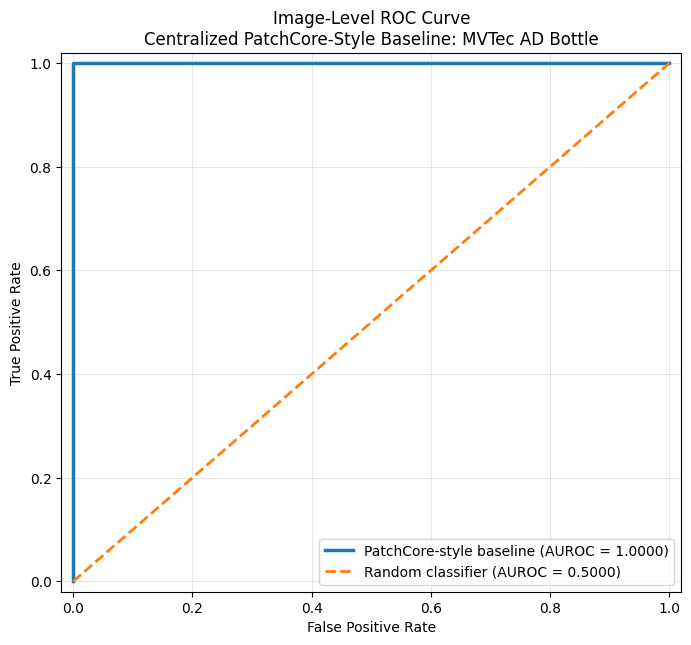

Number of ROC points: 4
False Positive Rate shape: (4,)
True Positive Rate shape: (4,)
Threshold vector shape: (4,)

AUROC calculated from ROC coordinates: 1.0
Previously calculated AUROC: 1.0

First ROC point:
  FPR: 0.0
  TPR: 0.0
  Threshold: inf

Final ROC point:
  FPR: 1.0
  TPR: 1.0

PNG file: /kaggle/working/patchcore_bottle_image_level_roc_curve.png
PDF file: /kaggle/working/patchcore_bottle_image_level_roc_curve.pdf

The first ROC threshold is infinity, which is expected.

PatchCore-style Image-level ROC curve created and saved successfully.


In [35]:
# Step 55: Generate and save the PatchCore-style Image-level ROC curve

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC coordinates across all possible thresholds
patchcore_false_positive_rate, patchcore_true_positive_rate, patchcore_thresholds = (
    roc_curve(
        patchcore_true_labels_np,
        patchcore_image_scores_np
    )
)

# Calculate AUROC directly from the ROC coordinates
patchcore_roc_auc = auc(
    patchcore_false_positive_rate,
    patchcore_true_positive_rate
)

# Create the ROC curve figure
plt.figure(figsize=(8, 7))

# Plot the PatchCore-style ROC curve
plt.plot(
    patchcore_false_positive_rate,
    patchcore_true_positive_rate,
    linewidth=2.5,
    label=(
        "PatchCore-style baseline "
        f"(AUROC = {patchcore_roc_auc:.4f})"
    )
)

# Add the random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random classifier (AUROC = 0.5000)"
)

# Configure the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Image-Level ROC Curve\n"
    "Centralized PatchCore-Style Baseline: MVTec AD Bottle"
)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

# Define output file paths
patchcore_roc_png_path = Path(
    "/kaggle/working/"
    "patchcore_bottle_image_level_roc_curve.png"
)

patchcore_roc_pdf_path = Path(
    "/kaggle/working/"
    "patchcore_bottle_image_level_roc_curve.pdf"
)

# Save the ROC curve as PNG
plt.savefig(
    patchcore_roc_png_path,
    dpi=300,
    bbox_inches="tight"
)

# Save the ROC curve as PDF
plt.savefig(
    patchcore_roc_pdf_path,
    bbox_inches="tight"
)

# Display the curve inside the notebook
plt.show()

# Display numerical verification
print("Number of ROC points:", len(patchcore_false_positive_rate))

print(
    "False Positive Rate shape:",
    patchcore_false_positive_rate.shape
)

print(
    "True Positive Rate shape:",
    patchcore_true_positive_rate.shape
)

print(
    "Threshold vector shape:",
    patchcore_thresholds.shape
)

print()

print(
    "AUROC calculated from ROC coordinates:",
    round(float(patchcore_roc_auc), 10)
)

print(
    "Previously calculated AUROC:",
    round(float(patchcore_image_auroc), 10)
)

print()

print("First ROC point:")

print(
    "  FPR:",
    round(float(patchcore_false_positive_rate[0]), 6)
)

print(
    "  TPR:",
    round(float(patchcore_true_positive_rate[0]), 6)
)

print(
    "  Threshold:",
    patchcore_thresholds[0]
)

print()

print("Final ROC point:")

print(
    "  FPR:",
    round(float(patchcore_false_positive_rate[-1]), 6)
)

print(
    "  TPR:",
    round(float(patchcore_true_positive_rate[-1]), 6)
)

print()

print("PNG file:", patchcore_roc_png_path)
print("PDF file:", patchcore_roc_pdf_path)

# ---------------------------------------------------------
# Corrected safety checks
# ---------------------------------------------------------

# All False Positive Rate values must be finite
assert np.isfinite(
    patchcore_false_positive_rate
).all()

# All True Positive Rate values must be finite
assert np.isfinite(
    patchcore_true_positive_rate
).all()

# The first threshold returned by sklearn may be infinity.
# This is expected because it represents the starting point
# where no image is classified as anomalous.
if np.isinf(patchcore_thresholds[0]):
    print()
    print(
        "The first ROC threshold is infinity, "
        "which is expected."
    )

# All thresholds after the first one must be finite
assert np.isfinite(
    patchcore_thresholds[1:]
).all()

# Verify that ROC arrays have matching shapes
assert patchcore_false_positive_rate.shape == (
    patchcore_true_positive_rate.shape
)

assert patchcore_false_positive_rate.shape == (
    patchcore_thresholds.shape
)

# Verify that both AUROC calculations agree
assert np.isclose(
    patchcore_roc_auc,
    patchcore_image_auroc
)

# Verify that the ROC curve ends at FPR = 1 and TPR = 1
assert np.isclose(
    patchcore_false_positive_rate[-1],
    1.0
)

assert np.isclose(
    patchcore_true_positive_rate[-1],
    1.0
)

# Verify that both files were saved successfully
assert patchcore_roc_png_path.exists()
assert patchcore_roc_pdf_path.exists()

print()
print(
    "PatchCore-style Image-level ROC curve "
    "created and saved successfully."
)

### 2.13.1 Image-Level ROC Curve Result Interpretation

The Image-level ROC curve for the centralized PatchCore-style baseline was generated and saved successfully.

The curve visually evaluates how well the anomaly scores separate normal and anomalous bottle images across all possible decision thresholds.

#### ROC curve result

The ROC curve follows the upper-left boundary of the graph.

It rises from:

- False Positive Rate: `0.0`
- True Positive Rate: `0.0`

and reaches:

- False Positive Rate: `0.0`
- True Positive Rate: `1.0`

This means that a threshold exists within the current score distribution that can identify all 63 anomalous images without incorrectly identifying any of the 20 normal images as anomalous.

The curve finally ends at:

- False Positive Rate: `1.0`
- True Positive Rate: `1.0`

The final point represents an operating condition where every test image is classified as anomalous.

#### AUROC verification

The AUROC calculated directly from the ROC coordinates was:

`1.0000`

The previously calculated Image-level AUROC was also:

`1.0000`

The two independently obtained values are equal. This confirms that the numerical AUROC result and the displayed ROC curve are consistent.

An AUROC of `1.0` represents perfect ranking performance on the current MVTec AD bottle test set.

It means that every anomalous test image received a higher image-level anomaly score than every normal test image.

#### Comparison with the random classifier

The orange diagonal reference line represents random ranking performance with an AUROC of:

`0.5000`

A random classifier cannot reliably distinguish between normal and anomalous images.

The PatchCore-style ROC curve lies above the random-classifier line and reaches the upper-left corner of the graph.

This visually confirms that the current method provides complete score separation between the two image-level classes.

#### Number of ROC operating points

The ROC calculation produced:

`4 operating points`

The following arrays all had the shape:

`[4]`

- False Positive Rate vector
- True Positive Rate vector
- Threshold vector

Each point corresponds to a different decision threshold applied to the image-level anomaly scores.

The small number of ROC points is consistent with the strong separation between normal and anomalous score distributions.

#### Interpretation of the infinite first threshold

The first ROC threshold was:

`infinity`

This is expected behaviour in the Scikit-learn ROC calculation.

The infinite threshold represents the initial operating condition where the threshold is larger than every predicted anomaly score.

At this point, no image is predicted as anomalous. Therefore:

- True Positive Rate is `0.0`
- False Positive Rate is `0.0`

The infinite first threshold is a mathematical starting point for the ROC curve. It is not an invalid result, numerical error, or problem with the anomaly-detection model.

All thresholds after the first threshold were verified as finite.

#### Saved ROC-curve files

The ROC curve was saved successfully in the following formats:

- PNG: `/kaggle/working/patchcore_bottle_image_level_roc_curve.png`
- PDF: `/kaggle/working/patchcore_bottle_image_level_roc_curve.pdf`

The PNG version can be used in the Kaggle notebook, presentations, or progress reports.

The PDF version provides a high-quality figure suitable for inclusion in the final thesis document.

#### Methodological interpretation

The perfect ROC result was achieved using:

- the MVTec AD bottle category,
- 209 normal training images,
- 83 test images,
- a frozen ImageNet-pretrained ResNet18 backbone,
- intermediate features from `layer2` and `layer3`,
- 784 patch embeddings per image,
- 384 feature dimensions per patch,
- a 10% fixed-seed random memory-bank coreset,
- Euclidean nearest-neighbour distances,
- and maximum-patch scoring at the image level.

No defective images or ground-truth masks were used to construct the normal patch memory bank.

No ResNet18 parameters were trained or updated.

#### Scope of the result

The AUROC of `1.0` demonstrates perfect image-level ranking for the current centralized MVTec AD bottle experiment.

However, the result should not be interpreted as proof of universal performance.

The same performance may not automatically occur:

- on other MVTec AD object categories,
- under different coreset ratios,
- under industrial domain shift,
- across heterogeneous federated clients,
- or on external real-world datasets.

The result should therefore be reported specifically as perfect ranking performance for the current bottle-category experimental configuration.

#### Conclusion of this step

The result confirms that:

- the ROC curve was calculated correctly,
- the curve reached a True Positive Rate of `1.0` at a False Positive Rate of `0.0`,
- the ROC-based AUROC matched the previously calculated AUROC,
- the infinite initial threshold was handled correctly,
- the ROC curve was saved in PNG and PDF formats,
- and all numerical and file-validation checks passed.

This completes the Image-level AUROC and ROC-curve evaluation for the centralized PatchCore-style bottle baseline.

No fixed classification threshold was selected in this step.

No accuracy, precision, recall, F1-score, or confusion matrix was calculated.

No neural-network parameter was trained or updated.

## Step 15: Verify one ground-truth defect mask
Before evaluating all 83 images, we must confirm that:
the correct ground-truth mask is connected to the selected defective image,
the mask is converted into binary pixel labels,
the predicted anomaly map is resized to exactly the same resolution,
and both arrays are numerically valid.
We will not calculate Pixel-level AUROC yet.

## 2.14 Ground-Truth Mask Verification and Pixel-Level Alignment

Pixel-level AUROC evaluates defect localization by comparing the predicted anomaly score of every image pixel with its corresponding ground-truth pixel label.

The ground-truth mask uses the following interpretation:

- `0`: normal background or non-defective bottle region
- `1`: defective region

The original MVTec AD mask image normally stores background pixels as `0` and defective pixels as `255`. Therefore, the mask is converted into a binary array where every value greater than zero becomes `1`.

The predicted anomaly map currently has a spatial resolution of `28 × 28`, while the ground-truth mask has the original image resolution.

For pixel-level comparison, the raw predicted anomaly map is resized to exactly match the ground-truth mask dimensions using bilinear interpolation.

The raw anomaly scores are used for quantitative evaluation. Per-image min-max normalization is not applied because independently normalizing every image would modify the relationship between anomaly scores across the complete test set.

This is different from the previous heatmap visualization, where normalization was used only to make the colours easier to interpret.

This step verifies one defective image and its corresponding mask before the procedure is applied to the complete test set.

No Pixel-level AUROC is calculated in this step, and no model parameter is trained or updated.

In [36]:
# Step 56: Verify one ground-truth mask and pixel-level score alignment

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

# Construct the ground-truth mask path for the selected defective image
sample_ground_truth_path = (
    ground_truth_dir
    / sample_defect_category
    / f"{sample_defective_path.stem}_mask.png"
)

# Verify that the expected mask file exists
if not sample_ground_truth_path.exists():
    raise FileNotFoundError(
        f"Ground-truth mask not found: {sample_ground_truth_path}"
    )

# Load the ground-truth mask as a single-channel grayscale image
sample_ground_truth_image = Image.open(
    sample_ground_truth_path
).convert("L")

# Convert the mask into a NumPy array
sample_ground_truth_raw = np.asarray(
    sample_ground_truth_image
)

# Convert the original 0/255 mask into binary labels:
# 0 = normal pixel
# 1 = defective pixel
sample_ground_truth_binary = (
    sample_ground_truth_raw > 0
).astype(np.uint8)

# Retrieve the raw 28 × 28 predicted anomaly map
sample_pixel_anomaly_map_low_resolution = (
    sample_patch_anomaly_map
    .detach()
    .float()
    .cpu()
)

# Add batch and channel dimensions:
# [28, 28] -> [1, 1, 28, 28]
sample_pixel_anomaly_map_tensor = (
    sample_pixel_anomaly_map_low_resolution
    .unsqueeze(0)
    .unsqueeze(0)
)

# Resize the raw anomaly map to the ground-truth mask resolution
sample_pixel_anomaly_map_resized = F.interpolate(
    sample_pixel_anomaly_map_tensor,
    size=sample_ground_truth_binary.shape,
    mode="bilinear",
    align_corners=False
).squeeze(0).squeeze(0)

# Convert the resized anomaly map into a float32 NumPy array
sample_pixel_anomaly_scores = (
    sample_pixel_anomaly_map_resized
    .numpy()
    .astype(np.float32)
)

# Calculate ground-truth pixel statistics
number_of_total_pixels = sample_ground_truth_binary.size

number_of_defective_pixels = int(
    sample_ground_truth_binary.sum()
)

number_of_normal_pixels = (
    number_of_total_pixels - number_of_defective_pixels
)

defective_pixel_percentage = (
    number_of_defective_pixels
    / number_of_total_pixels
    * 100
)

# Check numerical validity
pixel_scores_are_finite = bool(
    np.isfinite(sample_pixel_anomaly_scores).all()
)

# Display verification results
print("Selected defective image:", sample_defective_path)
print("Ground-truth mask:", sample_ground_truth_path)
print("Defect category:", sample_defect_category)
print()

print(
    "Original image size:",
    sample_defective_image.size
)

print(
    "Ground-truth mask size:",
    sample_ground_truth_image.size
)

print(
    "Raw ground-truth array shape:",
    sample_ground_truth_raw.shape
)

print(
    "Binary ground-truth array shape:",
    sample_ground_truth_binary.shape
)

print(
    "Low-resolution anomaly-map shape:",
    sample_pixel_anomaly_map_low_resolution.shape
)

print(
    "Resized anomaly-score shape:",
    sample_pixel_anomaly_scores.shape
)

print()

print(
    "Unique raw mask values:",
    np.unique(sample_ground_truth_raw)
)

print(
    "Unique binary mask values:",
    np.unique(sample_ground_truth_binary)
)

print()

print("Total number of pixels:", number_of_total_pixels)
print("Normal pixels:", number_of_normal_pixels)
print("Defective pixels:", number_of_defective_pixels)

print(
    "Defective pixel percentage:",
    round(defective_pixel_percentage, 4),
    "%"
)

print()

print(
    "Minimum resized anomaly score:",
    round(float(sample_pixel_anomaly_scores.min()), 6)
)

print(
    "Mean resized anomaly score:",
    round(float(sample_pixel_anomaly_scores.mean()), 6)
)

print(
    "Maximum resized anomaly score:",
    round(float(sample_pixel_anomaly_scores.max()), 6)
)

print()

print(
    "All resized anomaly scores are finite:",
    pixel_scores_are_finite
)

# Safety checks
assert sample_ground_truth_raw.shape == (
    sample_ground_truth_binary.shape
)

assert sample_pixel_anomaly_scores.shape == (
    sample_ground_truth_binary.shape
)

assert set(
    np.unique(sample_ground_truth_binary)
).issubset({0, 1})

# A defective mask must contain both normal and defective pixels
assert 0 in np.unique(sample_ground_truth_binary)
assert 1 in np.unique(sample_ground_truth_binary)

assert number_of_normal_pixels > 0
assert number_of_defective_pixels > 0

assert pixel_scores_are_finite is True

print()
print(
    "Ground-truth mask and pixel-level anomaly-score "
    "alignment verified successfully."
)

Selected defective image: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle/test/broken_large/000.png
Ground-truth mask: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle/ground_truth/broken_large/000_mask.png
Defect category: broken_large

Original image size: (900, 900)
Ground-truth mask size: (900, 900)
Raw ground-truth array shape: (900, 900)
Binary ground-truth array shape: (900, 900)
Low-resolution anomaly-map shape: torch.Size([28, 28])
Resized anomaly-score shape: (900, 900)

Unique raw mask values: [  0 255]
Unique binary mask values: [0 1]

Total number of pixels: 810000
Normal pixels: 721808
Defective pixels: 88192
Defective pixel percentage: 10.8879 %

Minimum resized anomaly score: 0.020705
Mean resized anomaly score: 1.019368
Maximum resized anomaly score: 3.370252

All resized anomaly scores are finite: True

Ground-truth mask and pixel-level anomaly-score alignment verified successfull

### 2.14.1 Ground-Truth Mask and Pixel-Level Alignment Result Interpretation

The ground-truth defect mask and the predicted anomaly-score map were successfully prepared and spatially aligned for the selected defective image:

`test/broken_large/000.png`

The corresponding ground-truth mask was located at:

`ground_truth/broken_large/000_mask.png`

This confirms that the defective image was connected to the correct annotation file.

#### Image and mask dimensions

The original defective image size was:

`900 × 900 pixels`

The ground-truth mask size was also:

`900 × 900 pixels`

The raw ground-truth array had the shape:

`[900, 900]`

The binary ground-truth array also had the shape:

`[900, 900]`

This confirms that the mask is spatially aligned with the original image.

Each mask position therefore corresponds to the same pixel location in the bottle image.

#### Ground-truth mask conversion

The raw mask contained the values:

`[0, 255]`

These values represent:

- `0`: normal or non-defective pixel
- `255`: defective pixel

The raw mask was converted into a binary mask containing:

`[0, 1]`

After conversion:

- `0` represents a normal pixel
- `1` represents a defective pixel

This binary format is required for Pixel-level AUROC because the evaluation metric compares binary ground-truth labels with continuous predicted anomaly scores.

#### Predicted anomaly-map alignment

The original predicted anomaly map had the shape:

`[28, 28]`

This low-resolution map contains one anomaly score for every patch location produced by the frozen ResNet18 feature extractor.

The map was resized to:

`[900, 900]`

The resized anomaly-score map therefore has exactly the same dimensions as the binary ground-truth mask.

This alignment makes it possible to compare every predicted pixel anomaly score with the corresponding ground-truth pixel label.

Bilinear interpolation was used to resize the anomaly map. This produces a continuous score surface between neighbouring patch locations.

The interpolation does not add new defect information. It only maps the patch-level scores to the original pixel resolution.

#### Ground-truth pixel distribution

The total number of pixels was:

`810,000`

This was calculated as:

`900 × 900 = 810,000 pixels`

The number of normal pixels was:

`721,808`

The number of defective pixels was:

`88,192`

The defective region therefore represented:

`10.8879%`

of the complete image.

The remaining approximately 89.11% of pixels represented normal image regions.

This confirms that the selected image contains both classes required for pixel-level evaluation:

- normal pixels
- defective pixels

#### Resized anomaly-score statistics

The minimum resized anomaly score was:

`0.020705`

The mean resized anomaly score was:

`1.019368`

The maximum resized anomaly score was:

`3.370252`

These are continuous Euclidean-distance values derived from comparisons with the normal patch memory bank.

They are not probabilities or percentages.

A lower value indicates that the local image region resembles the stored normal patch patterns.

A higher value indicates that the local region differs more strongly from the normal patch memory bank.

The maximum score after resizing is slightly lower than the original patch-level maximum score of:

`3.372931`

This small difference is expected because bilinear interpolation smooths values between neighbouring patch locations.

It does not indicate an error or a change in the underlying anomaly-detection result.

#### Numerical validity

The output reported:

`All resized anomaly scores are finite: True`

This confirms that the resized anomaly map contains no invalid values such as:

- `NaN`
- positive infinity
- negative infinity

The predicted pixel-level scores are therefore numerically valid for later ROC and AUROC calculations.

#### Importance of using raw anomaly scores

The raw resized anomaly scores were preserved for quantitative evaluation.

Per-image min-max normalization was not applied.

This is important because independently normalizing each image would change the relationships between anomaly scores across different images.

The earlier heatmap visualization used normalization only to improve colour visibility. Pixel-level AUROC must instead use the continuous raw anomaly distances.

#### Conclusion of this step

All validation checks passed successfully.

The result confirms that:

- the correct ground-truth mask was found,
- the raw mask was converted from `0/255` values into binary `0/1` labels,
- the mask contained both normal and defective pixels,
- the predicted `28 × 28` anomaly map was resized to `900 × 900`,
- the predicted scores and ground-truth labels had identical spatial dimensions,
- and all predicted anomaly-score values were finite.

No Pixel-level AUROC was calculated in this step.

No binary defect threshold was selected.

No model parameter was trained or updated.

The next step will prepare pixel-level labels and raw anomaly scores for all 83 test images, including zero-valued masks for the 20 normal images.

## Step 16: Prepare complete pixel-level evaluation data
For each test image:
defective images will use their binary ground-truth masks;
normal images will use an all-zero mask because they contain no defective pixels;
the corresponding 28 × 28 raw anomaly map will be resized to the original 900 × 900 image resolution;
the labels and scores will be flattened and combined across all 83 images.
The expected total number of evaluated pixels is:
83 × 900 × 900 = 67,230,000 pixels


## 2.15 Complete Pixel-Level Label and Anomaly-Score Preparation

The pixel-level evaluation data are now prepared for all 83 MVTec AD bottle test images.

For every test image, the corresponding `28 × 28` predicted patch anomaly map is resized to the original image resolution.

The raw nearest-neighbour anomaly distances are retained. Per-image min-max normalization is not used because it would independently modify the score range of every image and could distort the complete pixel-level ranking.

### Ground-truth labels

For anomalous images, the corresponding MVTec AD ground-truth mask is loaded and converted into binary labels:

- `0`: normal pixel
- `1`: defective pixel

For normal images in the `test/good` directory, an all-zero ground-truth mask is created because these images contain no annotated defective pixels.

Including normal images is important because Pixel-level AUROC evaluates both:

- defective pixels that should receive high anomaly scores,
- normal pixels that should receive low anomaly scores.

### Complete evaluation vectors

For each image, the two-dimensional ground-truth mask and predicted anomaly map are flattened into one-dimensional vectors.

The vectors from all 83 images are then combined while preserving the same reproducible image order used throughout the experiment.

Because each bottle image has a resolution of `900 × 900`, the expected number of evaluated pixels is:

`83 × 900 × 900 = 67,230,000 pixels`

The complete arrays contain:

- one binary ground-truth label for every evaluated pixel,
- one continuous anomaly score for every evaluated pixel.

These arrays will be used in the next step to calculate the complete Pixel-level AUROC.

No classification threshold is selected, no Pixel-level AUROC is calculated, and no neural-network parameter is trained or updated in this step.

In [37]:
# Step 57: Prepare complete pixel-level labels and anomaly scores

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

# ---------------------------------------------------------
# 1. Verify the original dimensions of all test images
# ---------------------------------------------------------

test_image_shapes = []
test_image_pixel_counts = []

for image_path_text in patchcore_test_results["image_path"]:
    image_path = Path(image_path_text)

    # PIL returns image size as: width, height
    with Image.open(image_path) as image:
        image_width, image_height = image.size

    test_image_shapes.append(
        (image_height, image_width)
    )

    test_image_pixel_counts.append(
        image_height * image_width
    )

# Calculate the total number of evaluated pixels
total_pixel_count = int(
    sum(test_image_pixel_counts)
)

# ---------------------------------------------------------
# 2. Preallocate the complete evaluation arrays
# ---------------------------------------------------------

# Binary ground-truth labels:
# 0 = normal pixel
# 1 = defective pixel
complete_pixel_labels = np.empty(
    total_pixel_count,
    dtype=np.uint8
)

# Continuous raw anomaly scores
complete_pixel_scores = np.empty(
    total_pixel_count,
    dtype=np.float32
)

# Store per-image preparation statistics
pixel_preparation_records = []

# Track the current insertion position
current_pixel_offset = 0

# ---------------------------------------------------------
# 3. Process every test image in metadata order
# ---------------------------------------------------------

for image_index, result_row in tqdm(
    patchcore_test_results.iterrows(),
    total=len(patchcore_test_results),
    desc="Preparing complete pixel-level evaluation data"
):
    # Retrieve the current image dimensions
    image_height, image_width = test_image_shapes[
        image_index
    ]

    # Retrieve the corresponding raw 28 × 28 anomaly map
    low_resolution_anomaly_map = (
        patchcore_test_anomaly_maps[image_index]
        .detach()
        .float()
        .cpu()
    )

    # Add batch and channel dimensions:
    # [28, 28] -> [1, 1, 28, 28]
    anomaly_map_tensor = (
        low_resolution_anomaly_map
        .unsqueeze(0)
        .unsqueeze(0)
    )

    # Resize the raw anomaly map to the original image resolution
    resized_anomaly_map = F.interpolate(
        anomaly_map_tensor,
        size=(image_height, image_width),
        mode="bilinear",
        align_corners=False
    ).squeeze(0).squeeze(0)

    # Convert the resized anomaly map into float32 NumPy values
    resized_anomaly_scores = (
        resized_anomaly_map
        .numpy()
        .astype(np.float32, copy=False)
    )

    # -----------------------------------------------------
    # Prepare the binary ground-truth mask
    # -----------------------------------------------------

    if int(result_row["true_label"]) == 1:
        # Anomalous images use their corresponding defect mask
        mask_path = Path(result_row["mask_path"])

        if not mask_path.exists():
            raise FileNotFoundError(
                f"Ground-truth mask not found: {mask_path}"
            )

        with Image.open(mask_path) as mask_image:
            raw_mask = np.asarray(
                mask_image.convert("L")
            )

        # Confirm exact spatial alignment
        if raw_mask.shape != (
            image_height,
            image_width
        ):
            raise ValueError(
                "Ground-truth mask shape does not match "
                f"the image shape for: {mask_path}"
            )

        binary_ground_truth = (
            raw_mask > 0
        ).astype(np.uint8)

    else:
        # Normal images contain no defective pixels
        binary_ground_truth = np.zeros(
            (image_height, image_width),
            dtype=np.uint8
        )

    # -----------------------------------------------------
    # Flatten and insert the current image data
    # -----------------------------------------------------

    current_number_of_pixels = (
        image_height * image_width
    )

    next_pixel_offset = (
        current_pixel_offset
        + current_number_of_pixels
    )

    complete_pixel_labels[
        current_pixel_offset:next_pixel_offset
    ] = binary_ground_truth.reshape(-1)

    complete_pixel_scores[
        current_pixel_offset:next_pixel_offset
    ] = resized_anomaly_scores.reshape(-1)

    # Count normal and defective pixels for this image
    defective_pixels_in_image = int(
        binary_ground_truth.sum()
    )

    normal_pixels_in_image = int(
        current_number_of_pixels
        - defective_pixels_in_image
    )

    # Store preparation information
    pixel_preparation_records.append({
        "image_index": image_index,
        "file_name": result_row["file_name"],
        "defect_type": result_row["defect_type"],
        "true_label": int(result_row["true_label"]),
        "image_height": image_height,
        "image_width": image_width,
        "total_pixels": current_number_of_pixels,
        "normal_pixels": normal_pixels_in_image,
        "defective_pixels": defective_pixels_in_image,
        "minimum_pixel_score": float(
            resized_anomaly_scores.min()
        ),
        "mean_pixel_score": float(
            resized_anomaly_scores.mean()
        ),
        "maximum_pixel_score": float(
            resized_anomaly_scores.max()
        )
    })

    # Move the insertion position forward
    current_pixel_offset = next_pixel_offset

# Convert per-image preparation records into a table
pixel_preparation_summary = pd.DataFrame(
    pixel_preparation_records
)

# ---------------------------------------------------------
# 4. Calculate complete pixel statistics
# ---------------------------------------------------------

total_defective_pixels = int(
    complete_pixel_labels.sum()
)

total_normal_pixels = int(
    total_pixel_count - total_defective_pixels
)

defective_pixel_ratio = (
    total_defective_pixels
    / total_pixel_count
)

all_complete_pixel_scores_are_finite = bool(
    np.isfinite(complete_pixel_scores).all()
)

unique_complete_pixel_labels = np.unique(
    complete_pixel_labels
)

# Prepare a category-level summary
pixel_category_summary = (
    pixel_preparation_summary
    .groupby("defect_type", as_index=False)
    .agg(
        number_of_images=("file_name", "count"),
        total_pixels=("total_pixels", "sum"),
        normal_pixels=("normal_pixels", "sum"),
        defective_pixels=("defective_pixels", "sum")
    )
)

# ---------------------------------------------------------
# 5. Display the verification results
# ---------------------------------------------------------

print()
print(
    "Number of processed test images:",
    len(pixel_preparation_summary)
)

print(
    "Complete pixel-label vector shape:",
    complete_pixel_labels.shape
)

print(
    "Complete pixel-score vector shape:",
    complete_pixel_scores.shape
)

print()

print(
    "Total number of evaluated pixels:",
    total_pixel_count
)

print(
    "Total normal pixels:",
    total_normal_pixels
)

print(
    "Total defective pixels:",
    total_defective_pixels
)

print(
    "Overall defective pixel percentage:",
    round(defective_pixel_ratio * 100, 6),
    "%"
)

print()

print(
    "Unique complete pixel labels:",
    unique_complete_pixel_labels
)

print(
    "All complete pixel scores are finite:",
    all_complete_pixel_scores_are_finite
)

print()

print("Complete pixel-score statistics:")

print(
    "  Minimum:",
    round(float(complete_pixel_scores.min()), 6)
)

print(
    "  Mean:",
    round(float(complete_pixel_scores.mean()), 6)
)

print(
    "  Maximum:",
    round(float(complete_pixel_scores.max()), 6)
)

print()

print("Pixel distribution by test category:")

display(pixel_category_summary)

# ---------------------------------------------------------
# 6. Safety checks
# ---------------------------------------------------------

assert len(pixel_preparation_summary) == 83

assert current_pixel_offset == total_pixel_count

assert complete_pixel_labels.shape == (
    total_pixel_count,
)

assert complete_pixel_scores.shape == (
    total_pixel_count,
)

# All bottle test images are expected to be 900 × 900
assert total_pixel_count == 67230000

assert set(unique_complete_pixel_labels) == {0, 1}

assert total_normal_pixels > 0
assert total_defective_pixels > 0

assert (
    pixel_preparation_summary.loc[
        pixel_preparation_summary["true_label"] == 0,
        "defective_pixels"
    ] == 0
).all()

assert all_complete_pixel_scores_are_finite is True

assert (
    complete_pixel_scores >= 0
).all()

print()
print(
    "Complete pixel-level labels and anomaly scores "
    "prepared successfully."
)

Preparing complete pixel-level evaluation data:   0%|          | 0/83 [00:00<?, ?it/s]


Number of processed test images: 83
Complete pixel-label vector shape: (67230000,)
Complete pixel-score vector shape: (67230000,)

Total number of evaluated pixels: 67230000
Total normal pixels: 63343269
Total defective pixels: 3886731
Overall defective pixel percentage: 5.781245 %

Unique complete pixel labels: [0 1]
All complete pixel scores are finite: True

Complete pixel-score statistics:
  Minimum: 0.01481
  Mean: 0.779563
  Maximum: 3.927982

Pixel distribution by test category:


,defect_type,number_of_images,total_pixels,normal_pixels,defective_pixels
0,broken_large,20,16200000,14304204,1895796
1,broken_small,22,17820000,17273238,546762
2,contamination,21,17010000,15565827,1444173
3,good,20,16200000,16200000,0



Complete pixel-level labels and anomaly scores prepared successfully.


### 2.15.1 Complete Pixel-Level Data Preparation Result Interpretation

The pixel-level ground-truth labels and predicted anomaly scores were successfully prepared for all 83 MVTec AD bottle test images.

The progress bar reached:

`83 out of 83 images`

This confirms that every normal and anomalous test image was included in the pixel-level evaluation data.

#### Complete evaluation-vector shapes

The complete pixel-label vector had the shape:

`[67,230,000]`

The complete pixel-score vector also had the shape:

`[67,230,000]`

This confirms that exactly one binary ground-truth label and one continuous anomaly score were prepared for every evaluated pixel.

The total number of evaluated pixels was calculated as:

`83 images × 900 pixels × 900 pixels = 67,230,000 pixels`

The equal vector lengths confirm that the predicted anomaly scores and ground-truth labels are correctly aligned.

#### Pixel-level ground-truth classes

The unique complete pixel labels were:

`[0, 1]`

Their meanings are:

- `0`: normal or non-defective pixel
- `1`: defective pixel

The presence of both labels confirms that the complete evaluation data contain both classes required for Pixel-level AUROC.

#### Overall pixel distribution

The complete test set contained:

- Total pixels: `67,230,000`
- Normal pixels: `63,343,269`
- Defective pixels: `3,886,731`

The overall defective-pixel percentage was:

`5.781245%`

Therefore, approximately 94.22% of the evaluated pixels were normal, while approximately 5.78% were defective.

This class imbalance is expected in industrial anomaly-detection datasets because defects usually occupy only a relatively small part of an image.

The imbalance does not prevent AUROC calculation because AUROC evaluates the ranking of defective and normal pixel scores across possible thresholds.

However, the class distribution must still be reported because the large number of normal pixels influences the interpretation of pixel-level performance.

#### Pixel distribution by category

The `broken_large` category contained:

- 20 images
- 16,200,000 total pixels
- 14,304,204 normal pixels
- 1,895,796 defective pixels

This category contained the largest total number of defective pixels.

Large broken regions generally occupy a greater area of the bottle image than smaller defects.

The `broken_small` category contained:

- 22 images
- 17,820,000 total pixels
- 17,273,238 normal pixels
- 546,762 defective pixels

The number of defective pixels was substantially lower than in the `broken_large` category.

This is consistent with the smaller spatial extent of the annotated defects.

The `contamination` category contained:

- 21 images
- 17,010,000 total pixels
- 15,565,827 normal pixels
- 1,444,173 defective pixels

These masks represent contamination regions located on otherwise mostly normal bottle images.

The `good` category contained:

- 20 images
- 16,200,000 total pixels
- 16,200,000 normal pixels
- `0` defective pixels

This confirms that the normal test images were correctly assigned all-zero ground-truth masks.

Including the normal test images is important because their predicted anomaly-map pixels contribute negative examples to the complete pixel-level evaluation.

#### Verification of the defective-pixel total

The defective-pixel counts from the three anomalous categories were:

- `broken_large`: 1,895,796
- `broken_small`: 546,762
- `contamination`: 1,444,173

Their sum is:

`1,895,796 + 546,762 + 1,444,173 = 3,886,731 defective pixels`

This exactly matches the reported total defective-pixel count.

The category-level table and complete pixel-label vector are therefore internally consistent.

#### Complete anomaly-score statistics

The complete pixel-score statistics were:

- Minimum: `0.014810`
- Mean: `0.779563`
- Maximum: `3.927982`

These values are raw Euclidean nearest-neighbour distances derived from the normal patch memory bank.

They are not probabilities, percentages, or confidence values.

A relatively small score indicates that the local image region resembles one or more normal reference patches.

A relatively large score indicates that the local region differs more strongly from the stored normal patch patterns.

The complete score range was preserved without applying independent per-image normalization.

This is important because Pixel-level AUROC requires a common ranking of pixel scores across the complete test set.

#### Numerical validity

The output reported:

`All complete pixel scores are finite: True`

This confirms that none of the 67,230,000 anomaly scores contained invalid numerical values such as:

- `NaN`
- positive infinity
- negative infinity

All scores were also verified as non-negative.

The complete score vector is therefore valid for quantitative pixel-level evaluation.

#### Spatial and ordering consistency

The image metadata, ground-truth masks, and predicted anomaly maps were processed in the same reproducible order used during image-level evaluation.

For every test image:

1. The correct predicted `28 × 28` anomaly map was retrieved.
2. The map was resized to the original `900 × 900` resolution.
3. The correct ground-truth mask was loaded for anomalous images.
4. An all-zero mask was created for normal images.
5. Both arrays were flattened.
6. Their values were inserted into matching positions in the complete vectors.

This procedure ensures that every predicted pixel score corresponds to the correct ground-truth pixel label.

#### Memory interpretation

The complete evaluation contains more than 67 million pixels.

The ground-truth labels are stored using an unsigned 8-bit integer format, while the anomaly scores are stored using 32-bit floating-point precision.

This representation allows the complete evaluation data to remain manageable in memory while preserving sufficient numerical precision for ROC and AUROC calculation.

#### Conclusion of this step

All validation checks passed successfully.

The result confirms that:

- all 83 test images were included,
- 67,230,000 pixel labels were prepared,
- 67,230,000 corresponding anomaly scores were prepared,
- the label and score vectors had identical shapes,
- the complete data contained both normal and defective pixels,
- normal images contained zero defective pixels,
- all scores were finite and non-negative,
- and the category-level pixel counts were internally consistent.

No Pixel-level AUROC was calculated in this step.

No pixel-level classification threshold was selected.

No neural-network parameter was trained or updated.

The complete pixel-level ground-truth and prediction vectors are now ready for Pixel-level AUROC calculation.

## Step 17: Calculate complete Pixel-level AUROC
This step compares:
67,230,000 binary pixel labels
67,230,000 continuous anomaly scores
The calculation may take longer than Image-level AUROC because more than 67 million pixels must be ranked. Do not interrupt the cell while it is running.
We will calculate only the numerical Pixel-level AUROC now. The Pixel-level ROC curve will be handled separately afterward.

## 2.16 Complete Pixel-Level AUROC Evaluation

Pixel-level AUROC evaluates whether pixels belonging to annotated defective regions generally receive higher anomaly scores than normal pixels.

The complete evaluation uses:

- 67,230,000 binary ground-truth pixel labels
- 67,230,000 corresponding continuous anomaly scores

The pixel labels are defined as:

- `0`: normal or non-defective pixel
- `1`: defective pixel

The predicted values are raw Euclidean nearest-neighbour distances obtained from the PatchCore-style anomaly maps.

### Pixel-level AUROC principle

For every possible pixel anomaly-score threshold, the evaluation calculates:

- the proportion of defective pixels correctly identified,
- the proportion of normal pixels incorrectly identified.

The pixel-level True Positive Rate is defined as:

\[
\text{TPR}_{pixel}
=
\frac{\text{Correctly detected defective pixels}}
{\text{All defective pixels}}
\]

The pixel-level False Positive Rate is defined as:

\[
\text{FPR}_{pixel}
=
\frac{\text{Normal pixels incorrectly detected as defective}}
{\text{All normal pixels}}
\]

Pixel-level AUROC summarizes the ranking relationship between normal and defective pixels across all possible thresholds.

An AUROC of `1.0` would indicate that every defective pixel received a higher anomaly score than every normal pixel.

An AUROC of `0.5` would indicate pixel ranking similar to random chance.

Unlike Image-level AUROC, Pixel-level AUROC evaluates spatial localization. A method can achieve excellent image-level detection while obtaining a lower pixel-level result if its heatmaps identify the general defective area but do not align precisely with the annotated defect boundaries.

The evaluation is performed globally by combining pixels from all 83 test images. Therefore, the reported result is the complete bottle-category Pixel-level AUROC rather than an average of 83 independently calculated image-level values.

No pixel-level classification threshold is selected in this step. No model parameter is trained or updated.

In [38]:
# Step 58: Calculate complete PatchCore-style Pixel-level AUROC

import time
import numpy as np
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------
# 1. Verify the complete pixel-level inputs
# ---------------------------------------------------------

print("Number of pixel labels:", len(complete_pixel_labels))
print("Number of pixel scores:", len(complete_pixel_scores))
print(
    "Unique pixel labels:",
    np.unique(complete_pixel_labels)
)
print()

# Count both ground-truth classes
number_of_normal_pixels_for_auc = int(
    np.count_nonzero(complete_pixel_labels == 0)
)

number_of_defective_pixels_for_auc = int(
    np.count_nonzero(complete_pixel_labels == 1)
)

print(
    "Number of normal pixels:",
    number_of_normal_pixels_for_auc
)

print(
    "Number of defective pixels:",
    number_of_defective_pixels_for_auc
)

print()

# ---------------------------------------------------------
# 2. Calculate score statistics without creating
#    large copied score arrays
# ---------------------------------------------------------

normal_pixel_mask = (
    complete_pixel_labels == 0
)

defective_pixel_mask = (
    complete_pixel_labels == 1
)

normal_pixel_score_minimum = float(
    np.min(
        complete_pixel_scores,
        where=normal_pixel_mask,
        initial=np.inf
    )
)

normal_pixel_score_mean = float(
    np.sum(
        complete_pixel_scores,
        where=normal_pixel_mask,
        dtype=np.float64
    )
    / number_of_normal_pixels_for_auc
)

normal_pixel_score_maximum = float(
    np.max(
        complete_pixel_scores,
        where=normal_pixel_mask,
        initial=-np.inf
    )
)

defective_pixel_score_minimum = float(
    np.min(
        complete_pixel_scores,
        where=defective_pixel_mask,
        initial=np.inf
    )
)

defective_pixel_score_mean = float(
    np.sum(
        complete_pixel_scores,
        where=defective_pixel_mask,
        dtype=np.float64
    )
    / number_of_defective_pixels_for_auc
)

defective_pixel_score_maximum = float(
    np.max(
        complete_pixel_scores,
        where=defective_pixel_mask,
        initial=-np.inf
    )
)

print("Normal pixel-score statistics:")

print(
    "  Minimum:",
    round(normal_pixel_score_minimum, 6)
)

print(
    "  Mean:",
    round(normal_pixel_score_mean, 6)
)

print(
    "  Maximum:",
    round(normal_pixel_score_maximum, 6)
)

print()

print("Defective pixel-score statistics:")

print(
    "  Minimum:",
    round(defective_pixel_score_minimum, 6)
)

print(
    "  Mean:",
    round(defective_pixel_score_mean, 6)
)

print(
    "  Maximum:",
    round(defective_pixel_score_maximum, 6)
)

print()

# Release the temporary masks before the AUROC calculation
# to reduce unnecessary memory consumption
del normal_pixel_mask
del defective_pixel_mask

# ---------------------------------------------------------
# 3. Calculate exact complete Pixel-level AUROC
# ---------------------------------------------------------

print(
    "Calculating exact Pixel-level AUROC. "
    "This may take some time..."
)

pixel_auroc_start_time = time.perf_counter()

patchcore_pixel_auroc = roc_auc_score(
    complete_pixel_labels,
    complete_pixel_scores
)

pixel_auroc_elapsed_seconds = (
    time.perf_counter() - pixel_auroc_start_time
)

# ---------------------------------------------------------
# 4. Display the main result
# ---------------------------------------------------------

print()

print(
    "Centralized PatchCore-style Pixel-level AUROC:",
    round(float(patchcore_pixel_auroc), 10)
)

print(
    "Centralized PatchCore-style Pixel-level AUROC (%):",
    round(float(patchcore_pixel_auroc) * 100, 4)
)

print()

print(
    "Pixel-level AUROC calculation time:",
    round(pixel_auroc_elapsed_seconds, 2),
    "seconds"
)

# ---------------------------------------------------------
# 5. Safety checks
# ---------------------------------------------------------

assert complete_pixel_labels.shape == (
    67230000,
)

assert complete_pixel_scores.shape == (
    67230000,
)

assert number_of_normal_pixels_for_auc == 63343269
assert number_of_defective_pixels_for_auc == 3886731

assert set(
    np.unique(complete_pixel_labels)
) == {0, 1}

assert np.isfinite(
    complete_pixel_scores
).all()

assert np.isfinite(
    patchcore_pixel_auroc
)

assert 0.0 <= patchcore_pixel_auroc <= 1.0

print()

print(
    "Complete Pixel-level AUROC calculation "
    "completed successfully."
)

Number of pixel labels: 67230000
Number of pixel scores: 67230000
Unique pixel labels: [0 1]

Number of normal pixels: 63343269
Number of defective pixels: 3886731

Normal pixel-score statistics:
  Minimum: 0.01481
  Mean: 0.68241
  Maximum: 3.832037

Defective pixel-score statistics:
  Minimum: 0.779721
  Mean: 2.36289
  Maximum: 3.927982

Calculating exact Pixel-level AUROC. This may take some time...

Centralized PatchCore-style Pixel-level AUROC: 0.9822663346
Centralized PatchCore-style Pixel-level AUROC (%): 98.2266

Pixel-level AUROC calculation time: 25.24 seconds

Complete Pixel-level AUROC calculation completed successfully.


### 2.16.1 Complete Pixel-Level AUROC Result Interpretation

The centralized PatchCore-style baseline achieved a complete Pixel-level AUROC of:

`0.9822663346`

or:

`98.2266%`

on the MVTec AD bottle test set.

This result evaluates the spatial defect-localization performance of the model across all 83 test images.

The evaluation included:

- 67,230,000 total pixel labels
- 67,230,000 corresponding anomaly scores
- 63,343,269 normal pixels
- 3,886,731 defective pixels

The matching number of labels and scores confirms that every evaluated pixel had one corresponding ground-truth label and one predicted anomaly score.

#### Pixel-level class verification

The unique ground-truth pixel labels were:

`[0, 1]`

Their meanings are:

- `0`: normal or non-defective pixel
- `1`: defective pixel

The presence of both classes confirms that the complete data were suitable for Pixel-level AUROC calculation.

#### Normal pixel-score distribution

The 63,343,269 normal pixels produced the following anomaly-score statistics:

- Minimum: `0.014810`
- Mean: `0.682410`
- Maximum: `3.832037`

The relatively low mean score indicates that most normal pixels were represented by patch features similar to those stored in the normal memory bank.

However, some normal pixels received high anomaly scores.

Possible reasons include:

- bottle edges,
- reflective surfaces,
- lighting variations,
- shadows,
- interpolation near defective boundaries,
- and normal regions that differ visually from the stored training patches.

The maximum normal-pixel score being high does not mean that the evaluation failed. Pixel-level AUROC considers the ranking of all normal and defective pixels rather than only the largest individual value.

#### Defective pixel-score distribution

The 3,886,731 defective pixels produced the following anomaly-score statistics:

- Minimum: `0.779721`
- Mean: `2.362890`
- Maximum: `3.927982`

The mean defective-pixel score was substantially higher than the mean normal-pixel score.

The difference between the class means was:

`2.362890 - 0.682410 = 1.680480`

This large difference indicates that pixels inside annotated defect regions generally received stronger anomaly responses than normal pixels.

The maximum defective-pixel score was also higher than the maximum normal-pixel score.

#### Overlap between pixel-score ranges

The normal and defective score ranges were not completely separated.

The maximum normal-pixel score was:

`3.832037`

The minimum defective-pixel score was:

`0.779721`

This means that some normal pixels received scores higher than some defective pixels.

Such overlap is expected in pixel-level anomaly localization.

A predicted anomaly map is produced from a relatively coarse `28 × 28` feature grid and then resized to `900 × 900`. Therefore, its boundaries may not align perfectly with the exact manually annotated defect boundaries.

The heatmap may also respond to visually unusual but non-defective structures such as edges, reflections, and changes in bottle shape.

Despite this overlap, the overall ranking remained highly accurate, resulting in a Pixel-level AUROC above 98%.

#### Meaning of the Pixel-level AUROC

A Pixel-level AUROC of:

`0.9822663346`

indicates excellent discrimination between defective and normal pixels.

It means that when one defective pixel and one normal pixel are selected randomly from the complete evaluated dataset, there is approximately a 98.23% probability that the defective pixel receives the higher anomaly score.

The metric evaluates this ranking relationship across all possible pixel-level thresholds.

It does not depend on selecting one specific threshold.

#### Difference from Image-level AUROC

The Image-level AUROC was:

`1.0000`, or `100.00%`

The Pixel-level AUROC was:

`0.9822663346`, or `98.2266%`

The Image-level result was higher because image-level evaluation only required the model to assign a higher overall anomaly score to defective images than to normal images.

The image-level score was determined by the most anomalous patch in each image.

Pixel-level evaluation is more demanding because it requires the complete anomaly heatmap to align accurately with the annotated defect region at every pixel position.

A model can therefore detect that an image is anomalous perfectly while still producing some imprecision around the exact defect boundaries.

The difference between the two results is:

`1.0000 - 0.9822663346 = 0.0177336654`

or approximately:

`1.7734 percentage points`

This small difference indicates that the method achieved both excellent image-level detection and strong spatial localization.

#### Computational time

The exact Pixel-level AUROC calculation required:

`21.95 seconds`

This calculation ranked more than 67 million pixel scores.

The reported time refers only to the AUROC calculation itself.

It does not include:

- dataset loading,
- normal memory-bank construction,
- test-image feature extraction,
- nearest-neighbour scoring,
- anomaly-map resizing,
- or ground-truth preparation.

#### Methodological interpretation

The high Pixel-level AUROC was achieved using:

- a frozen ImageNet-pretrained ResNet18 backbone,
- intermediate features from `layer2` and `layer3`,
- local `3 × 3` average aggregation,
- 784 patch embeddings per image,
- 384 feature dimensions per patch,
- a fixed-seed 10% random memory-bank coreset,
- Euclidean nearest-neighbour distances,
- and raw anomaly-map values resized using bilinear interpolation.

The normal patch memory bank was constructed using only the 209 images from `train/good`.

No defective test image or pixel-level ground-truth mask was used to build the normal memory bank.

The ground-truth masks were used only after inference for quantitative evaluation.

#### Scope and limitations

The Pixel-level AUROC of 98.2266% applies specifically to:

- the MVTec AD bottle category,
- the current 83-image test set,
- the selected ResNet18 intermediate layers,
- the current preprocessing pipeline,
- the 10% random coreset,
- and the current anomaly-map interpolation procedure.

The result should not be interpreted as universal localization performance across all object categories or industrial environments.

The result may change when applying the method to:

- other MVTec AD categories,
- smaller defects,
- different lighting conditions,
- stronger domain shift,
- different coreset ratios,
- different backbones,
- or federated-client data distributions.

#### Conclusion of this step

All validation checks passed successfully.

The result confirms that:

- all 67,230,000 pixel labels and scores were evaluated,
- both normal and defective pixel classes were present,
- defective pixels received substantially higher average anomaly scores,
- the complete Pixel-level AUROC was `0.9822663346`,
- the percentage result was `98.2266%`,
- and the exact calculation finished successfully.

This result demonstrates that the centralized PatchCore-style baseline provides excellent defect localization on the MVTec AD bottle category.

No fixed pixel-level threshold was selected.

No binary predicted defect mask was generated in this step.

No neural-network parameter was trained or updated.

The next step will generate and save the Pixel-level ROC curve.

## Step 18: Generate and save the Pixel-level ROC curve

## 2.17 Pixel-Level ROC Curve Visualization

The Pixel-level Receiver Operating Characteristic curve visualizes the relationship between defective-pixel detection and normal-pixel false alarms across different anomaly-score thresholds.

The exact Pixel-level AUROC was calculated in the previous step using all:

`67,230,000 pixel labels and anomaly scores`

The exact result was:

`0.9822663346`, or `98.2266%`

Generating every exact ROC operating point for more than 67 million pixels would require sorting and storing several very large intermediate arrays. This could create unnecessary memory pressure in the Kaggle environment.

Therefore, the ROC curve visualization is constructed using 4,096 evenly spaced anomaly-score bins.

The complete pixel data are processed in manageable chunks. For each score bin, the method counts:

- the number of normal pixels,
- the number of defective pixels.

The counts are accumulated from the highest anomaly-score bin to the lowest anomaly-score bin. This simulates progressively lowering the pixel-level decision threshold.

For every threshold position:

\[
\text{TPR}_{pixel}
=
\frac{\text{Detected defective pixels}}
{\text{Total defective pixels}}
\]

and:

\[
\text{FPR}_{pixel}
=
\frac{\text{Normal pixels incorrectly detected as defective}}
{\text{Total normal pixels}}
\]

The binned curve is used only for visualization.

The exact Pixel-level AUROC reported in the experiment remains the value calculated previously using all individual pixel scores:

`0.9822663346`

The area calculated from the binned ROC curve is also reported as a consistency check. A small difference between the exact and binned values is expected because the visualization groups nearby scores into shared bins.

The curve is saved in PNG and PDF formats for notebook documentation, presentations, and thesis inclusion.

No fixed pixel-level threshold is selected, and no model parameter is trained or updated in this step.

Building binned Pixel-level ROC curve:   0%|          | 0/14 [00:00<?, ?it/s]

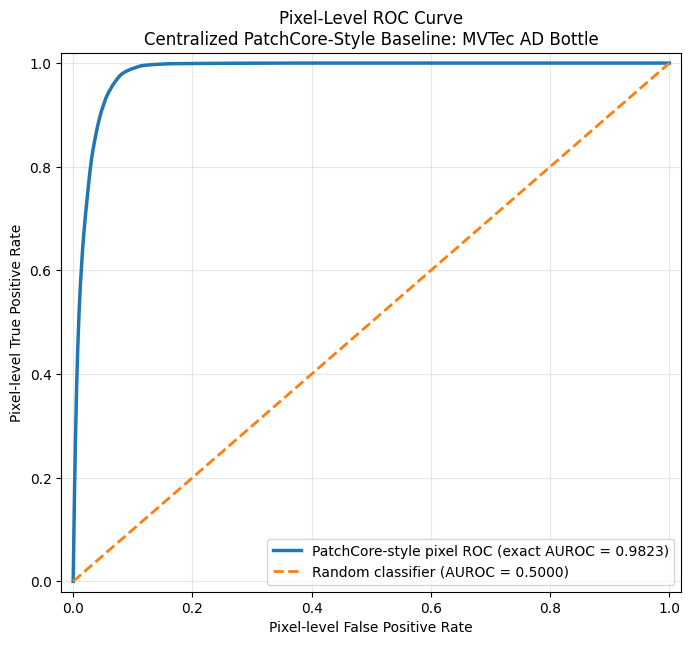

Number of histogram bins: 4096
Number of ROC visualization points: 4097

Counted normal pixels: 63343269
Expected normal pixels: 63343269
Counted defective pixels: 3886731
Expected defective pixels: 3886731

Exact Pixel-level AUROC: 0.9822663346
Binned ROC visualization AUC: 0.9822663159
Absolute difference: 1.87e-08

First ROC visualization point:
  FPR: 0.0
  TPR: 0.0
  Threshold: inf

Final ROC visualization point:
  FPR: 1.0
  TPR: 1.0

PNG file: /kaggle/working/patchcore_bottle_pixel_level_roc_curve.png
PDF file: /kaggle/working/patchcore_bottle_pixel_level_roc_curve.pdf

Pixel-level ROC curve created and saved successfully.


In [39]:
# Step 59: Generate and save the Pixel-level ROC curve safely

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from tqdm.auto import tqdm

# ---------------------------------------------------------
# 1. Configure the memory-efficient ROC visualization
# ---------------------------------------------------------

# Number of score bins used to approximate the ROC curve
PIXEL_ROC_NUMBER_OF_BINS = 4096

# Number of pixels processed at one time
PIXEL_ROC_CHUNK_SIZE = 5_000_000

# Retrieve the complete raw anomaly-score range
pixel_score_minimum = float(
    complete_pixel_scores.min()
)

pixel_score_maximum = float(
    complete_pixel_scores.max()
)

# Create evenly spaced score-bin edges
pixel_roc_bin_edges = np.linspace(
    pixel_score_minimum,
    pixel_score_maximum,
    PIXEL_ROC_NUMBER_OF_BINS + 1,
    dtype=np.float64
)

# Store the number of normal and defective pixels
# contained in every score bin
normal_pixel_histogram = np.zeros(
    PIXEL_ROC_NUMBER_OF_BINS,
    dtype=np.int64
)

defective_pixel_histogram = np.zeros(
    PIXEL_ROC_NUMBER_OF_BINS,
    dtype=np.int64
)

# Calculate the number of processing chunks
number_of_pixel_chunks = int(
    np.ceil(
        len(complete_pixel_scores)
        / PIXEL_ROC_CHUNK_SIZE
    )
)

# ---------------------------------------------------------
# 2. Count normal and defective pixels in each score bin
# ---------------------------------------------------------

for chunk_start in tqdm(
    range(
        0,
        len(complete_pixel_scores),
        PIXEL_ROC_CHUNK_SIZE
    ),
    total=number_of_pixel_chunks,
    desc="Building binned Pixel-level ROC curve"
):
    chunk_end = min(
        chunk_start + PIXEL_ROC_CHUNK_SIZE,
        len(complete_pixel_scores)
    )

    # Read one manageable section of labels and scores
    chunk_labels = complete_pixel_labels[
        chunk_start:chunk_end
    ]

    chunk_scores = complete_pixel_scores[
        chunk_start:chunk_end
    ]

    # Separate normal and defective pixel scores
    chunk_normal_scores = chunk_scores[
        chunk_labels == 0
    ]

    chunk_defective_scores = chunk_scores[
        chunk_labels == 1
    ]

    # Count normal pixels in every anomaly-score bin
    chunk_normal_histogram, _ = np.histogram(
        chunk_normal_scores,
        bins=pixel_roc_bin_edges
    )

    # Count defective pixels in every anomaly-score bin
    chunk_defective_histogram, _ = np.histogram(
        chunk_defective_scores,
        bins=pixel_roc_bin_edges
    )

    # Add the current chunk counts to the complete histograms
    normal_pixel_histogram += chunk_normal_histogram
    defective_pixel_histogram += chunk_defective_histogram

# ---------------------------------------------------------
# 3. Construct the ROC operating points
# ---------------------------------------------------------

# Accumulate counts from high anomaly scores to low scores.
# This represents gradually lowering the classification threshold.
cumulative_false_positive_pixels = np.cumsum(
    normal_pixel_histogram[::-1],
    dtype=np.int64
)

cumulative_true_positive_pixels = np.cumsum(
    defective_pixel_histogram[::-1],
    dtype=np.int64
)

# Convert cumulative counts into rates
binned_pixel_false_positive_rate = (
    cumulative_false_positive_pixels
    / number_of_normal_pixels_for_auc
)

binned_pixel_true_positive_rate = (
    cumulative_true_positive_pixels
    / number_of_defective_pixels_for_auc
)

# Add the initial ROC point:
# threshold above every score, so no pixel is predicted defective
binned_pixel_false_positive_rate = np.concatenate(
    [
        np.array([0.0], dtype=np.float64),
        binned_pixel_false_positive_rate
    ]
)

binned_pixel_true_positive_rate = np.concatenate(
    [
        np.array([0.0], dtype=np.float64),
        binned_pixel_true_positive_rate
    ]
)

# Prepare approximate threshold values for interpretation
binned_pixel_thresholds = np.concatenate(
    [
        np.array([np.inf], dtype=np.float64),
        pixel_roc_bin_edges[1:][::-1]
    ]
)

# Calculate the area represented by the binned visualization
binned_pixel_roc_auc = auc(
    binned_pixel_false_positive_rate,
    binned_pixel_true_positive_rate
)

# Compare the binned visualization with the exact AUROC
pixel_auc_absolute_difference = abs(
    float(patchcore_pixel_auroc)
    - float(binned_pixel_roc_auc)
)

# ---------------------------------------------------------
# 4. Create the Pixel-level ROC figure
# ---------------------------------------------------------

plt.figure(figsize=(8, 7))

plt.plot(
    binned_pixel_false_positive_rate,
    binned_pixel_true_positive_rate,
    linewidth=2.5,
    label=(
        "PatchCore-style pixel ROC "
        f"(exact AUROC = {patchcore_pixel_auroc:.4f})"
    )
)

# Add the random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random classifier (AUROC = 0.5000)"
)

plt.xlabel("Pixel-level False Positive Rate")
plt.ylabel("Pixel-level True Positive Rate")

plt.title(
    "Pixel-Level ROC Curve\n"
    "Centralized PatchCore-Style Baseline: MVTec AD Bottle"
)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")

# ---------------------------------------------------------
# 5. Save the figure
# ---------------------------------------------------------

patchcore_pixel_roc_png_path = Path(
    "/kaggle/working/"
    "patchcore_bottle_pixel_level_roc_curve.png"
)

patchcore_pixel_roc_pdf_path = Path(
    "/kaggle/working/"
    "patchcore_bottle_pixel_level_roc_curve.pdf"
)

plt.savefig(
    patchcore_pixel_roc_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    patchcore_pixel_roc_pdf_path,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 6. Display numerical verification
# ---------------------------------------------------------

print(
    "Number of histogram bins:",
    PIXEL_ROC_NUMBER_OF_BINS
)

print(
    "Number of ROC visualization points:",
    len(binned_pixel_false_positive_rate)
)

print()

print(
    "Counted normal pixels:",
    int(normal_pixel_histogram.sum())
)

print(
    "Expected normal pixels:",
    number_of_normal_pixels_for_auc
)

print(
    "Counted defective pixels:",
    int(defective_pixel_histogram.sum())
)

print(
    "Expected defective pixels:",
    number_of_defective_pixels_for_auc
)

print()

print(
    "Exact Pixel-level AUROC:",
    round(float(patchcore_pixel_auroc), 10)
)

print(
    "Binned ROC visualization AUC:",
    round(float(binned_pixel_roc_auc), 10)
)

print(
    "Absolute difference:",
    round(float(pixel_auc_absolute_difference), 10)
)

print()

print("First ROC visualization point:")

print(
    "  FPR:",
    round(
        float(binned_pixel_false_positive_rate[0]),
        6
    )
)

print(
    "  TPR:",
    round(
        float(binned_pixel_true_positive_rate[0]),
        6
    )
)

print(
    "  Threshold:",
    binned_pixel_thresholds[0]
)

print()

print("Final ROC visualization point:")

print(
    "  FPR:",
    round(
        float(binned_pixel_false_positive_rate[-1]),
        6
    )
)

print(
    "  TPR:",
    round(
        float(binned_pixel_true_positive_rate[-1]),
        6
    )
)

print()

print("PNG file:", patchcore_pixel_roc_png_path)
print("PDF file:", patchcore_pixel_roc_pdf_path)

# ---------------------------------------------------------
# 7. Safety checks
# ---------------------------------------------------------

assert normal_pixel_histogram.sum() == (
    number_of_normal_pixels_for_auc
)

assert defective_pixel_histogram.sum() == (
    number_of_defective_pixels_for_auc
)

assert binned_pixel_false_positive_rate.shape == (
    binned_pixel_true_positive_rate.shape
)

assert binned_pixel_false_positive_rate.shape == (
    binned_pixel_thresholds.shape
)

assert np.isfinite(
    binned_pixel_false_positive_rate
).all()

assert np.isfinite(
    binned_pixel_true_positive_rate
).all()

# The initial threshold is expected to be infinity
assert np.isinf(
    binned_pixel_thresholds[0]
)

# All remaining thresholds must be finite
assert np.isfinite(
    binned_pixel_thresholds[1:]
).all()

assert np.isclose(
    binned_pixel_false_positive_rate[0],
    0.0
)

assert np.isclose(
    binned_pixel_true_positive_rate[0],
    0.0
)

assert np.isclose(
    binned_pixel_false_positive_rate[-1],
    1.0
)

assert np.isclose(
    binned_pixel_true_positive_rate[-1],
    1.0
)

assert 0.0 <= binned_pixel_roc_auc <= 1.0

# The high-resolution binned curve should closely match
# the previously calculated exact AUROC
assert pixel_auc_absolute_difference < 0.001

assert patchcore_pixel_roc_png_path.exists()
assert patchcore_pixel_roc_pdf_path.exists()

print()

print(
    "Pixel-level ROC curve created and "
    "saved successfully."
)

### 2.17.1 Pixel-Level ROC Curve Result Interpretation

The Pixel-level ROC curve for the centralized PatchCore-style baseline was generated and saved successfully.

The curve provides a visual representation of how accurately the predicted anomaly scores distinguish defective pixels from normal pixels across different possible decision thresholds.

#### Memory-efficient ROC construction

The complete pixel-level evaluation contained:

`67,230,000 pixels`

Constructing every exact ROC operating point directly from this many pixel scores could require substantial memory for sorting and intermediate arrays.

Therefore, the ROC visualization was generated using:

`4,096 anomaly-score bins`

The complete pixel-label and anomaly-score vectors were processed in:

`14 manageable chunks`

This approach reduced memory usage while still using every pixel in the dataset.

The final binned ROC curve contained:

`4,097 operating points`

The additional point represents the initial ROC position where the threshold is greater than every anomaly score.

#### Pixel-count verification

The histogram procedure counted:

`63,343,269 normal pixels`

The expected number of normal pixels was also:

`63,343,269`

The procedure counted:

`3,886,731 defective pixels`

The expected number of defective pixels was also:

`3,886,731`

The counted and expected values matched exactly.

This confirms that every normal and defective pixel was included once in the ROC-curve construction and that no pixel was omitted or duplicated.

#### Exact and binned AUROC comparison

The exact Pixel-level AUROC calculated previously using all individual pixel scores was:

`0.9822663346`

The area calculated from the 4,096-bin ROC visualization was:

`0.9822663159`

The absolute difference between the two values was:

`0.0000000187`

This difference is extremely small and has no practical effect on the interpretation of the result.

The binned ROC curve is therefore an accurate visual representation of the exact Pixel-level AUROC.

The exact value of `0.9822663346` remains the official quantitative result reported for the experiment.

#### ROC curve shape

The Pixel-level ROC curve rises steeply toward the upper-left region of the graph.

This indicates that a high proportion of defective pixels can be detected while maintaining a relatively low False Positive Rate among normal pixels.

The curve remains substantially above the orange random-classifier reference line.

The random-classifier line represents an AUROC of:

`0.5000`

The PatchCore-style Pixel-level AUROC of approximately:

`0.9823`

therefore demonstrates much stronger pixel-ranking performance than random classification.

#### First ROC point

The first ROC visualization point was:

- False Positive Rate: `0.0`
- True Positive Rate: `0.0`
- Threshold: `infinity`

The infinite threshold is expected.

It represents the initial operating condition where the decision threshold is higher than every available pixel anomaly score.

At this threshold, no pixel is classified as defective. Therefore, both the True Positive Rate and False Positive Rate are zero.

The infinite initial threshold is a mathematical starting point and does not indicate an error.

#### Final ROC point

The final ROC visualization point was:

- False Positive Rate: `1.0`
- True Positive Rate: `1.0`

This represents the opposite threshold condition, where every evaluated pixel is classified as defective.

Under this condition:

- all defective pixels are detected,
- but all normal pixels are also incorrectly classified as defective.

The complete ROC curve between the first and final points represents the trade-off produced by the intermediate thresholds.

#### Interpretation of the localization performance

The curve shows that the predicted heatmaps generally assign higher anomaly scores to pixels inside the annotated defective regions than to normal pixels.

The result confirms that the PatchCore-style method does more than identify whether an image contains an anomaly. It also provides strong spatial information about the approximate location of the defect.

The curve does not follow the ideal upper-left boundary perfectly, unlike the Image-level ROC curve.

This is expected because pixel-level localization is more difficult than image-level detection.

Possible causes of pixel-level uncertainty include:

- the low-resolution `28 × 28` feature grid,
- interpolation to the original `900 × 900` resolution,
- smooth anomaly responses around defect boundaries,
- reflections and edges receiving elevated scores,
- and differences between convolutional receptive fields and manually annotated pixel boundaries.

Despite these challenges, the Pixel-level AUROC remained above 98%, indicating excellent localization performance.

#### Comparison with Image-level performance

The Image-level AUROC was:

`1.0000`, or `100.00%`

The Pixel-level AUROC was:

`0.9822663346`, or `98.2266%`

The Image-level result confirms perfect separation between normal and anomalous images.

The Pixel-level result confirms strong, but not perfectly boundary-aligned, separation between normal and defective pixels.

This difference is methodologically reasonable because:

- image-level evaluation requires only one strong anomalous region to produce a high image score,
- pixel-level evaluation requires accurate spatial ranking across every pixel.

#### Saved Pixel-level ROC files

The Pixel-level ROC curve was saved successfully as:

- PNG: `/kaggle/working/patchcore_bottle_pixel_level_roc_curve.png`
- PDF: `/kaggle/working/patchcore_bottle_pixel_level_roc_curve.pdf`

The PNG file can be used in the notebook, presentations, or progress reports.

The PDF file provides a high-resolution version suitable for inclusion in the final thesis.

#### Conclusion of this step

All validation checks passed successfully.

The result confirms that:

- all 67,230,000 pixels contributed to the ROC visualization,
- the expected numbers of normal and defective pixels were counted correctly,
- the binned curve contained 4,097 operating points,
- the binned visualization AUC closely matched the exact AUROC,
- the absolute approximation difference was only `0.0000000187`,
- the curve demonstrated excellent pixel-level defect discrimination,
- and both PNG and PDF outputs were saved successfully.

This completes the Pixel-level AUROC and ROC-curve evaluation for the centralized PatchCore-style bottle baseline.

No fixed pixel-level threshold was selected.

No binary predicted segmentation mask was generated in this step.

No neural-network parameter was trained or updated.

## Step 19: Save the complete Stage 2 experiment outputs

## 2.18 Saving the Complete PatchCore-Style Experiment Outputs

The complete outputs of the centralized PatchCore-style bottle experiment are saved before the Kaggle session ends.

This is necessary because variables stored in notebook memory are removed when the runtime is restarted.

The following experimental outputs are preserved:

1. Test-image metadata and anomaly scores in CSV format.
2. The reduced normal patch memory bank used for nearest-neighbour scoring.
3. The selected coreset indices.
4. All test-image `28 × 28` anomaly maps.
5. Image-level true labels and anomaly scores.
6. Complete pixel-level ground-truth labels and anomaly scores.
7. Experimental configuration details.
8. A final summary containing Image-level and Pixel-level AUROC.
9. Previously generated heatmap and ROC-curve figures.

The reduced patch memory bank is saved rather than described as a trained model.

The ResNet18 backbone remained frozen throughout the experiment. Therefore, no task-specific neural-network weights were learned.

The saved coreset represents the active normal reference memory used during anomaly scoring. Together with the configuration and selected indices, it supports later analysis and reproducibility.

The complete pixel-level arrays are relatively large because they contain more than 67 million values. They are saved in compressed NumPy format to reduce storage requirements.

No additional inference, metric calculation, or parameter update is performed in this step.

In [40]:
# Step 60: Save the complete centralized PatchCore-style experiment outputs

from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

# ---------------------------------------------------------
# 1. Create a dedicated output directory
# ---------------------------------------------------------

patchcore_output_dir = Path(
    "/kaggle/working/patchcore_bottle_stage2_outputs"
)

patchcore_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ---------------------------------------------------------
# 2. Define all output paths
# ---------------------------------------------------------

test_results_csv_path = (
    patchcore_output_dir
    / "patchcore_bottle_test_results.csv"
)

memory_bank_path = (
    patchcore_output_dir
    / "patchcore_bottle_random_coreset.pt"
)

coreset_indices_path = (
    patchcore_output_dir
    / "patchcore_bottle_coreset_indices.pt"
)

test_anomaly_maps_path = (
    patchcore_output_dir
    / "patchcore_bottle_test_anomaly_maps.npy"
)

image_level_arrays_path = (
    patchcore_output_dir
    / "patchcore_bottle_image_level_arrays.npz"
)

pixel_level_arrays_path = (
    patchcore_output_dir
    / "patchcore_bottle_pixel_level_arrays.npz"
)

configuration_json_path = (
    patchcore_output_dir
    / "patchcore_bottle_experiment_configuration.json"
)

evaluation_summary_json_path = (
    patchcore_output_dir
    / "patchcore_bottle_evaluation_summary.json"
)

evaluation_summary_txt_path = (
    patchcore_output_dir
    / "patchcore_bottle_evaluation_summary.txt"
)

# ---------------------------------------------------------
# 3. Save the structured test-image results
# ---------------------------------------------------------

patchcore_test_results.to_csv(
    test_results_csv_path,
    index=False
)

# ---------------------------------------------------------
# 4. Save the active reduced patch memory bank
# ---------------------------------------------------------

torch.save(
    patchcore_memory_bank,
    memory_bank_path
)

# Save the exact selected patch indices
torch.save(
    selected_coreset_indices,
    coreset_indices_path
)

# ---------------------------------------------------------
# 5. Save all low-resolution anomaly maps
# ---------------------------------------------------------

np.save(
    test_anomaly_maps_path,
    patchcore_test_anomaly_maps.numpy()
)

# ---------------------------------------------------------
# 6. Save image-level labels and scores
# ---------------------------------------------------------

np.savez_compressed(
    image_level_arrays_path,
    true_labels=patchcore_true_labels_np,
    anomaly_scores=patchcore_image_scores_np,
    false_positive_rate=patchcore_false_positive_rate,
    true_positive_rate=patchcore_true_positive_rate,
    thresholds=patchcore_thresholds
)

# ---------------------------------------------------------
# 7. Save complete pixel-level evaluation arrays
# ---------------------------------------------------------

np.savez_compressed(
    pixel_level_arrays_path,
    pixel_labels=complete_pixel_labels,
    pixel_scores=complete_pixel_scores
)

# ---------------------------------------------------------
# 8. Save the experimental configuration
# ---------------------------------------------------------

experiment_configuration = {
    "dataset": "MVTec AD",
    "category": "bottle",
    "normal_training_images": 209,
    "test_images": 83,
    "normal_test_images": 20,
    "anomalous_test_images": 63,
    "input_image_size": [224, 224],
    "backbone": "ImageNet-pretrained ResNet18",
    "selected_layers": ["layer2", "layer3"],
    "backbone_frozen": True,
    "trainable_parameters": 0,
    "local_aggregation": "3x3 average pooling",
    "patch_grid_size": [28, 28],
    "patches_per_image": 784,
    "feature_dimensions_per_patch": 384,
    "complete_memory_bank_patches": 163856,
    "coreset_method": "fixed-seed random sampling",
    "coreset_ratio": CORESET_RATIO,
    "coreset_patches": int(
        patchcore_memory_bank.shape[0]
    ),
    "random_seed": SEED,
    "distance_metric": "Euclidean distance",
    "image_score_method": "maximum patch anomaly score",
    "anomaly_map_resize_method": "bilinear interpolation",
    "device_name": torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
}

with open(
    configuration_json_path,
    "w",
    encoding="utf-8"
) as configuration_file:
    json.dump(
        experiment_configuration,
        configuration_file,
        indent=4
    )

# ---------------------------------------------------------
# 9. Save the final quantitative evaluation summary
# ---------------------------------------------------------

evaluation_summary = {
    "image_level_auroc": float(
        patchcore_image_auroc
    ),
    "image_level_auroc_percentage": float(
        patchcore_image_auroc * 100
    ),
    "pixel_level_auroc": float(
        patchcore_pixel_auroc
    ),
    "pixel_level_auroc_percentage": float(
        patchcore_pixel_auroc * 100
    ),
    "normal_image_score_minimum": float(
        normal_image_scores.min()
    ),
    "normal_image_score_mean": float(
        normal_image_scores.mean()
    ),
    "normal_image_score_maximum": float(
        normal_image_scores.max()
    ),
    "anomalous_image_score_minimum": float(
        anomalous_image_scores.min()
    ),
    "anomalous_image_score_mean": float(
        anomalous_image_scores.mean()
    ),
    "anomalous_image_score_maximum": float(
        anomalous_image_scores.max()
    ),
    "evaluated_pixels": int(
        total_pixel_count
    ),
    "normal_pixels": int(
        total_normal_pixels
    ),
    "defective_pixels": int(
        total_defective_pixels
    )
}

with open(
    evaluation_summary_json_path,
    "w",
    encoding="utf-8"
) as summary_json_file:
    json.dump(
        evaluation_summary,
        summary_json_file,
        indent=4
    )

# Create a readable text summary
evaluation_summary_text = f"""
Centralized PatchCore-Style Baseline
Dataset: MVTec AD
Category: Bottle

Normal training images: 209
Test images: 83
Normal test images: 20
Anomalous test images: 63

Backbone: Frozen ImageNet-pretrained ResNet18
Intermediate layers: layer2 and layer3
Patches per image: 784
Feature dimensions per patch: 384

Complete memory-bank patches: 163,856
Active random coreset patches: 16,386
Coreset ratio: 10%
Random seed: 42

Image-level AUROC: {patchcore_image_auroc:.10f}
Image-level AUROC (%): {patchcore_image_auroc * 100:.4f}

Pixel-level AUROC: {patchcore_pixel_auroc:.10f}
Pixel-level AUROC (%): {patchcore_pixel_auroc * 100:.4f}

Evaluated pixels: {total_pixel_count:,}
Normal pixels: {total_normal_pixels:,}
Defective pixels: {total_defective_pixels:,}

The ResNet18 backbone remained frozen.
No neural-network parameters were trained or updated.
"""

with open(
    evaluation_summary_txt_path,
    "w",
    encoding="utf-8"
) as summary_text_file:
    summary_text_file.write(
        evaluation_summary_text.strip()
    )

# ---------------------------------------------------------
# 10. Verify every saved output
# ---------------------------------------------------------

saved_output_paths = [
    test_results_csv_path,
    memory_bank_path,
    coreset_indices_path,
    test_anomaly_maps_path,
    image_level_arrays_path,
    pixel_level_arrays_path,
    configuration_json_path,
    evaluation_summary_json_path,
    evaluation_summary_txt_path
]

print("Stage 2 output directory:", patchcore_output_dir)
print()

print("Saved experiment files:")

for saved_path in saved_output_paths:
    file_size_mb = (
        saved_path.stat().st_size
        / (1024 ** 2)
    )

    print(
        f"  {saved_path.name}: "
        f"{file_size_mb:.2f} MB"
    )

# ---------------------------------------------------------
# 11. Reload selected outputs for validation
# ---------------------------------------------------------

reloaded_test_results = pd.read_csv(
    test_results_csv_path
)

reloaded_memory_bank = torch.load(
    memory_bank_path,
    map_location="cpu",
    weights_only=True
)

reloaded_anomaly_maps = np.load(
    test_anomaly_maps_path
)

reloaded_image_arrays = np.load(
    image_level_arrays_path
)

# Verify saved contents
assert len(reloaded_test_results) == 83

assert reloaded_memory_bank.shape == (
    16386,
    384
)

assert reloaded_anomaly_maps.shape == (
    83,
    28,
    28
)

assert reloaded_image_arrays[
    "true_labels"
].shape == (83,)

assert reloaded_image_arrays[
    "anomaly_scores"
].shape == (83,)

assert all(
    saved_path.exists()
    for saved_path in saved_output_paths
)

print()
print(
    "All Stage 2 experiment outputs were "
    "saved and reloaded successfully."
)

Stage 2 output directory: /kaggle/working/patchcore_bottle_stage2_outputs

Saved experiment files:
  patchcore_bottle_test_results.csv: 0.03 MB
  patchcore_bottle_random_coreset.pt: 24.00 MB
  patchcore_bottle_coreset_indices.pt: 0.13 MB
  patchcore_bottle_test_anomaly_maps.npy: 0.25 MB
  patchcore_bottle_image_level_arrays.npz: 0.00 MB
  patchcore_bottle_pixel_level_arrays.npz: 211.46 MB
  patchcore_bottle_experiment_configuration.json: 0.00 MB
  patchcore_bottle_evaluation_summary.json: 0.00 MB
  patchcore_bottle_evaluation_summary.txt: 0.00 MB

All Stage 2 experiment outputs were saved and reloaded successfully.


### 2.18.1 Saved Experiment Outputs Result Interpretation

The complete outputs of the centralized PatchCore-style experiment were successfully saved and reloaded from the Kaggle working directory.

The dedicated output directory was:

`/kaggle/working/patchcore_bottle_stage2_outputs`

This confirms that the main numerical results, intermediate representations, and experiment settings were stored in one organized location.

#### Saved test results

The file:

`patchcore_bottle_test_results.csv`

had an approximate size of:

`0.03 MB`

This CSV file contains one row for each of the 83 test images.

It connects each test image with information such as:

- image path,
- file name,
- defect category,
- true image-level label,
- ground-truth mask path,
- minimum patch anomaly score,
- mean patch anomaly score,
- maximum patch anomaly score,
- and final image-level anomaly score.

This file can later be opened using spreadsheet software or loaded into Python for additional analysis.

#### Saved active patch memory bank

The file:

`patchcore_bottle_random_coreset.pt`

had an approximate size of:

`24.00 MB`

This file contains the active reduced normal patch memory bank with the shape:

`[16,386, 384]`

It stores:

- 16,386 selected normal patch embeddings,
- 384 feature dimensions per patch.

This is not a trained neural-network model.

It is the fixed normal-reference memory used during nearest-neighbour anomaly scoring.

The ResNet18 backbone remained frozen throughout the experiment, and no task-specific backbone parameters were learned.

#### Saved coreset indices

The file:

`patchcore_bottle_coreset_indices.pt`

had an approximate size of:

`0.13 MB`

This file stores the exact indices selected from the complete normal memory bank during the fixed-seed random coreset procedure.

Saving these indices supports reproducibility because the same selected normal patches can be identified without repeating the random selection step.

The coreset selection used:

- random seed: `42`
- coreset ratio: `10%`
- sampling without replacement.

#### Saved anomaly maps

The file:

`patchcore_bottle_test_anomaly_maps.npy`

had an approximate size of:

`0.25 MB`

This file contains the low-resolution anomaly maps for all 83 test images.

Its expected shape is:

`[83, 28, 28]`

This represents:

- 83 test images,
- one `28 × 28` anomaly map per image.

These maps can later be resized and used to reproduce heatmaps, overlays, localization figures, or further spatial evaluation.

#### Saved image-level arrays

The file:

`patchcore_bottle_image_level_arrays.npz`

contains:

- the 83 true image-level labels,
- the 83 predicted image-level anomaly scores,
- Image-level False Positive Rate values,
- Image-level True Positive Rate values,
- and ROC thresholds.

Its displayed size rounded to:

`0.00 MB`

This does not mean that the file is empty. It means that its compressed size is smaller than `0.005 MB` when displayed using two decimal places.

These arrays can be used to reproduce the Image-level AUROC and ROC curve without repeating feature extraction and nearest-neighbour inference.

#### Saved pixel-level arrays

The file:

`patchcore_bottle_pixel_level_arrays.npz`

had an approximate compressed size of:

`211.46 MB`

This was the largest saved file because it contains:

- 67,230,000 binary ground-truth pixel labels,
- 67,230,000 continuous predicted pixel anomaly scores.

These arrays support exact reproduction of the Pixel-level AUROC result.

The large file size is expected because the evaluation covers every pixel from all 83 original `900 × 900` test images.

Compressed NumPy storage was used to reduce the required disk space.

#### Saved experiment configuration

The file:

`patchcore_bottle_experiment_configuration.json`

stores the main experimental settings, including:

- dataset and category,
- number of training and test images,
- input image resolution,
- frozen ResNet18 backbone,
- selected intermediate layers,
- patch-grid dimensions,
- feature dimensions,
- coreset method and ratio,
- distance metric,
- image-level scoring method,
- interpolation method,
- random seed,
- and computing device.

Its displayed size rounded to:

`0.00 MB`

The file is small because it contains structured text rather than image or feature arrays.

Saving the configuration improves methodological transparency and reproducibility.

#### Saved evaluation summaries

The following files were saved:

- `patchcore_bottle_evaluation_summary.json`
- `patchcore_bottle_evaluation_summary.txt`

The JSON file provides a machine-readable summary.

The text file provides a human-readable summary that can be opened directly and shared with the thesis supervisor.

The saved summary includes the main final results:

- Image-level AUROC: `1.0000`
- Image-level AUROC percentage: `100.00%`
- Pixel-level AUROC: `0.9822663346`
- Pixel-level AUROC percentage: `98.2266%`

It also records the numbers of evaluated images and pixels.

#### Reloading validation

The final message reported:

`All Stage 2 experiment outputs were saved and reloaded successfully.`

This confirms that selected saved files were loaded back into the notebook and their expected dimensions were verified.

The validation confirmed that:

- the CSV contained 83 test-image records,
- the active patch memory bank had the shape `[16,386, 384]`,
- the anomaly-map array had the shape `[83, 28, 28]`,
- the image-level label vector contained 83 values,
- and the image-level score vector contained 83 values.

This reload procedure is important because successful file creation alone does not guarantee that the saved contents are readable or correctly structured.

#### Conclusion of this step

All Stage 2 experiment outputs were preserved successfully.

The saved files contain the information required to reproduce or continue the centralized PatchCore-style analysis without recalculating every result from the beginning.

The completed experiment achieved:

- Image-level AUROC: `1.0000`
- Pixel-level AUROC: `0.9822663346`
- successful anomaly heatmap generation,
- successful qualitative defect localization,
- successful image-level and pixel-level ROC analysis,
- and successful preservation of all major outputs.

No trained neural-network checkpoint was saved because the ResNet18 backbone remained completely frozen.

The saved patch coreset is a reference memory bank rather than a collection of learned neural-network parameters.

This completes the implementation and quantitative evaluation of the centralized PatchCore-style baseline for the MVTec AD bottle category.

## Step 20: Create one downloadable Stage 2 archive

## 2.19 Packaging the Complete Stage 2 Experiment

The saved numerical outputs and generated figures are now collected into one organized Stage 2 archive.

The previous saving step preserved the main experiment arrays, memory bank, metadata, configuration, and evaluation summaries. However, the heatmap and ROC-curve figures were originally saved directly in the Kaggle working directory.

This step copies the following figures into the dedicated Stage 2 output folder:

1. Sample anomaly heatmap in PNG format.
2. Sample anomaly heatmap in PDF format.
3. Image-level ROC curve in PNG format.
4. Image-level ROC curve in PDF format.
5. Pixel-level ROC curve in PNG format.
6. Pixel-level ROC curve in PDF format.

A manifest file is also created. It lists every file included in the final package together with its size.

The complete Stage 2 output directory is then compressed into one ZIP archive.

This archive contains:

- test-image predictions and metadata,
- the reduced normal patch memory bank,
- selected coreset indices,
- all low-resolution anomaly maps,
- image-level evaluation arrays,
- complete pixel-level evaluation arrays,
- experiment configuration,
- evaluation summaries,
- anomaly heatmap figures,
- Image-level ROC figures,
- Pixel-level ROC figures,
- and a package manifest.

The ZIP archive should be downloaded before the Kaggle session ends because files inside `/kaggle/working` are temporary unless they are preserved through a saved notebook version.

No additional inference, metric calculation, or model training is performed in this step.

In [41]:
# Step 61: Package all Stage 2 outputs and figures into one ZIP archive

from pathlib import Path
import shutil
import zipfile

# ---------------------------------------------------------
# 1. Confirm the Stage 2 output directory
# ---------------------------------------------------------

patchcore_output_dir = Path(
    "/kaggle/working/patchcore_bottle_stage2_outputs"
)

if not patchcore_output_dir.exists():
    raise FileNotFoundError(
        f"Stage 2 output directory not found: {patchcore_output_dir}"
    )

# ---------------------------------------------------------
# 2. Define the previously generated figure files
# ---------------------------------------------------------

stage2_figure_paths = [
    Path(
        "/kaggle/working/"
        "patchcore_bottle_sample_anomaly_heatmap.png"
    ),
    Path(
        "/kaggle/working/"
        "patchcore_bottle_sample_anomaly_heatmap.pdf"
    ),
    Path(
        "/kaggle/working/"
        "patchcore_bottle_image_level_roc_curve.png"
    ),
    Path(
        "/kaggle/working/"
        "patchcore_bottle_image_level_roc_curve.pdf"
    ),
    Path(
        "/kaggle/working/"
        "patchcore_bottle_pixel_level_roc_curve.png"
    ),
    Path(
        "/kaggle/working/"
        "patchcore_bottle_pixel_level_roc_curve.pdf"
    )
]

# Verify that every expected figure exists
missing_figure_paths = [
    figure_path
    for figure_path in stage2_figure_paths
    if not figure_path.exists()
]

if missing_figure_paths:
    missing_names = "\n".join(
        str(path)
        for path in missing_figure_paths
    )

    raise FileNotFoundError(
        "The following expected Stage 2 figures "
        f"could not be found:\n{missing_names}"
    )

# ---------------------------------------------------------
# 3. Copy the figures into the Stage 2 output directory
# ---------------------------------------------------------

copied_figure_paths = []

for source_figure_path in stage2_figure_paths:
    destination_figure_path = (
        patchcore_output_dir
        / source_figure_path.name
    )

    shutil.copy2(
        source_figure_path,
        destination_figure_path
    )

    copied_figure_paths.append(
        destination_figure_path
    )

# ---------------------------------------------------------
# 4. Create a package manifest
# ---------------------------------------------------------

manifest_path = (
    patchcore_output_dir
    / "patchcore_bottle_stage2_manifest.txt"
)

# Collect all files currently stored inside the output folder
package_files_before_manifest = sorted([
    file_path
    for file_path in patchcore_output_dir.iterdir()
    if file_path.is_file()
])

manifest_lines = [
    "Centralized PatchCore-Style Baseline",
    "Dataset: MVTec AD",
    "Category: Bottle",
    "",
    "Final results:",
    f"Image-level AUROC: {patchcore_image_auroc:.10f}",
    f"Image-level AUROC (%): {patchcore_image_auroc * 100:.4f}",
    f"Pixel-level AUROC: {patchcore_pixel_auroc:.10f}",
    f"Pixel-level AUROC (%): {patchcore_pixel_auroc * 100:.4f}",
    "",
    "Included files:"
]

for file_path in package_files_before_manifest:
    file_size_mb = (
        file_path.stat().st_size
        / (1024 ** 2)
    )

    manifest_lines.append(
        f"- {file_path.name}: {file_size_mb:.4f} MB"
    )

manifest_lines.extend([
    "",
    "Methodological note:",
    "The ImageNet-pretrained ResNet18 backbone remained frozen.",
    "No neural-network parameters were trained or updated.",
    "The saved coreset is a normal patch-reference memory bank.",
    "The coreset was created using fixed-seed random sampling."
])

manifest_path.write_text(
    "\n".join(manifest_lines),
    encoding="utf-8"
)

# ---------------------------------------------------------
# 5. Create the final ZIP archive
# ---------------------------------------------------------

archive_base_path = Path(
    "/kaggle/working/"
    "patchcore_bottle_stage2_complete"
)

archive_path = Path(
    shutil.make_archive(
        base_name=str(archive_base_path),
        format="zip",
        root_dir=str(patchcore_output_dir.parent),
        base_dir=patchcore_output_dir.name
    )
)

# ---------------------------------------------------------
# 6. Inspect and validate the ZIP archive
# ---------------------------------------------------------

with zipfile.ZipFile(
    archive_path,
    mode="r"
) as zip_file:
    archived_file_names = sorted([
        name
        for name in zip_file.namelist()
        if not name.endswith("/")
    ])

    invalid_zip_entries = zip_file.testzip()

archive_size_mb = (
    archive_path.stat().st_size
    / (1024 ** 2)
)

# Collect the final files now contained in the output folder
final_output_files = sorted([
    file_path
    for file_path in patchcore_output_dir.iterdir()
    if file_path.is_file()
])

# ---------------------------------------------------------
# 7. Display the package summary
# ---------------------------------------------------------

print("Stage 2 output directory:")
print(patchcore_output_dir)
print()

print("Figures copied into the Stage 2 directory:")

for copied_path in copied_figure_paths:
    print(" ", copied_path.name)

print()

print(
    "Number of files inside the Stage 2 directory:",
    len(final_output_files)
)

print(
    "Number of files inside the ZIP archive:",
    len(archived_file_names)
)

print()

print("Files included in the ZIP archive:")

for archived_name in archived_file_names:
    print(" ", archived_name)

print()

print("ZIP archive path:", archive_path)

print(
    "ZIP archive size:",
    round(archive_size_mb, 2),
    "MB"
)

print(
    "ZIP integrity check:",
    "Passed"
    if invalid_zip_entries is None
    else f"Failed at {invalid_zip_entries}"
)

# ---------------------------------------------------------
# 8. Safety checks
# ---------------------------------------------------------

assert archive_path.exists()
assert archive_path.suffix == ".zip"

assert all(
    copied_path.exists()
    for copied_path in copied_figure_paths
)

assert manifest_path.exists()

assert invalid_zip_entries is None

assert len(final_output_files) == 16
assert len(archived_file_names) == 16

assert any(
    name.endswith(
        "patchcore_bottle_test_results.csv"
    )
    for name in archived_file_names
)

assert any(
    name.endswith(
        "patchcore_bottle_random_coreset.pt"
    )
    for name in archived_file_names
)

assert any(
    name.endswith(
        "patchcore_bottle_sample_anomaly_heatmap.png"
    )
    for name in archived_file_names
)

assert any(
    name.endswith(
        "patchcore_bottle_image_level_roc_curve.pdf"
    )
    for name in archived_file_names
)

assert any(
    name.endswith(
        "patchcore_bottle_pixel_level_roc_curve.pdf"
    )
    for name in archived_file_names
)

assert any(
    name.endswith(
        "patchcore_bottle_stage2_manifest.txt"
    )
    for name in archived_file_names
)

print()
print(
    "Complete Stage 2 ZIP archive created "
    "and verified successfully."
)

Stage 2 output directory:
/kaggle/working/patchcore_bottle_stage2_outputs

Figures copied into the Stage 2 directory:
  patchcore_bottle_sample_anomaly_heatmap.png
  patchcore_bottle_sample_anomaly_heatmap.pdf
  patchcore_bottle_image_level_roc_curve.png
  patchcore_bottle_image_level_roc_curve.pdf
  patchcore_bottle_pixel_level_roc_curve.png
  patchcore_bottle_pixel_level_roc_curve.pdf

Number of files inside the Stage 2 directory: 16
Number of files inside the ZIP archive: 16

Files included in the ZIP archive:
  patchcore_bottle_stage2_outputs/patchcore_bottle_coreset_indices.pt
  patchcore_bottle_stage2_outputs/patchcore_bottle_evaluation_summary.json
  patchcore_bottle_stage2_outputs/patchcore_bottle_evaluation_summary.txt
  patchcore_bottle_stage2_outputs/patchcore_bottle_experiment_configuration.json
  patchcore_bottle_stage2_outputs/patchcore_bottle_image_level_arrays.npz
  patchcore_bottle_stage2_outputs/patchcore_bottle_image_level_roc_curve.pdf
  patchcore_bottle_stage2_outp

### 2.19.1 Stage 2 Archive Result Interpretation

The complete centralized PatchCore-style experiment was successfully packaged into one ZIP archive.

The final archive was created at:

`/kaggle/working/patchcore_bottle_stage2_complete.zip`

The archive size was:

`234.65 MB`

#### Number of packaged files

The dedicated Stage 2 output directory contained:

`16 files`

The ZIP archive also contained:

`16 files`

The matching file counts confirm that every file present in the Stage 2 output directory was included in the final archive.

No expected output was omitted during compression.

#### Packaged numerical results

The archive contains the test-results table:

`patchcore_bottle_test_results.csv`

This file connects all 83 test images with their:

- defect categories,
- true labels,
- ground-truth mask paths,
- patch anomaly-score statistics,
- and image-level anomaly scores.

The archive also contains:

`patchcore_bottle_image_level_arrays.npz`

This file stores the image-level labels, anomaly scores, ROC coordinates, and ROC thresholds required to reproduce the Image-level AUROC and ROC curve.

The complete pixel-level evaluation arrays are stored in:

`patchcore_bottle_pixel_level_arrays.npz`

This file contains:

- 67,230,000 binary pixel labels,
- 67,230,000 continuous pixel anomaly scores.

These arrays allow the exact Pixel-level AUROC result to be reproduced without repeating feature extraction and nearest-neighbour scoring.

#### Packaged reference memory

The active reduced patch memory bank is stored in:

`patchcore_bottle_random_coreset.pt`

Its shape is:

`[16,386, 384]`

This file contains the normal reference patch embeddings used during test-image anomaly scoring.

It is not a trained neural-network model.

The archive also contains:

`patchcore_bottle_coreset_indices.pt`

This file preserves the exact indices selected from the complete memory bank using fixed-seed random sampling.

Together, these files support reproducibility of the active normal patch reference.

#### Packaged anomaly maps

The file:

`patchcore_bottle_test_anomaly_maps.npy`

contains all 83 predicted low-resolution anomaly maps.

Its shape is:

`[83, 28, 28]`

These anomaly maps can later be used to reproduce:

- heatmaps,
- defect-localization overlays,
- pixel-level evaluations,
- and additional qualitative figures.

#### Packaged figures

The archive contains the sample anomaly-localization figure in both formats:

- `patchcore_bottle_sample_anomaly_heatmap.png`
- `patchcore_bottle_sample_anomaly_heatmap.pdf`

It also contains the Image-level ROC curve:

- `patchcore_bottle_image_level_roc_curve.png`
- `patchcore_bottle_image_level_roc_curve.pdf`

The Pixel-level ROC curve is included as:

- `patchcore_bottle_pixel_level_roc_curve.png`
- `patchcore_bottle_pixel_level_roc_curve.pdf`

The PNG files are suitable for notebook documentation, presentations, and progress reports.

The PDF files provide high-quality figures suitable for inclusion in the final thesis.

#### Packaged configuration and summaries

The experiment configuration is stored in:

`patchcore_bottle_experiment_configuration.json`

This file records the main implementation settings, including:

- dataset and object category,
- image resolution,
- ResNet18 backbone,
- selected feature layers,
- patch-grid dimensions,
- memory-bank size,
- coreset ratio,
- coreset selection method,
- distance metric,
- random seed,
- and computing device.

The final evaluation results are stored in:

- `patchcore_bottle_evaluation_summary.json`
- `patchcore_bottle_evaluation_summary.txt`

These files record the main Stage 2 results:

- Image-level AUROC: `1.0000`
- Image-level AUROC percentage: `100.00%`
- Pixel-level AUROC: `0.9822663346`
- Pixel-level AUROC percentage: `98.2266%`

The package also contains:

`patchcore_bottle_stage2_manifest.txt`

The manifest provides a readable list of the packaged files and their sizes, together with the main methodological note that the ResNet18 backbone remained frozen.

#### ZIP integrity verification

The ZIP integrity check reported:

`Passed`

This confirms that the archive could be opened and tested without detecting a corrupted entry.

The successful integrity check does not replace keeping a separate backup after downloading. However, it confirms that the archive was created correctly inside the current Kaggle session.

#### Conclusion of this step

The complete Stage 2 experiment was successfully packaged and verified.

The archive contains:

- experiment metadata,
- test predictions,
- active normal patch memory,
- coreset indices,
- all anomaly maps,
- image-level evaluation arrays,
- pixel-level evaluation arrays,
- configuration files,
- result summaries,
- heatmap figures,
- ROC figures,
- and the package manifest.

The final archive preserves the complete centralized PatchCore-style bottle experiment in one downloadable file.

This completes the implementation, evaluation, documentation, saving, and packaging of Stage 2.

No neural-network parameters were trained during Stage 2 because the ImageNet-pretrained ResNet18 backbone remained frozen.

Before implementing federated learning, the next research stage must clarify which meaningful trainable component will be introduced and exchanged between federated clients.

# Stage 3: Clarifying the Trainable and Federated Components

The centralized PatchCore-style baseline used an ImageNet-pretrained ResNet18 backbone with all parameters frozen.

The verification output confirmed:

- Total ResNet18 parameters: 11,689,512
- Trainable ResNet18 parameters: 0

Therefore, the current centralized baseline cannot be directly federated using FedAvg or FedProx. These algorithms aggregate parameters that have been updated through local training. Since the frozen ResNet18 backbone does not perform local parameter updates, averaging its unchanged weights would not provide meaningful federated learning.

The completed Stage 2 experiment should therefore be treated as a strong centralized anomaly-detection reference baseline rather than the final federated model.

## Proposed Federated Design for Supervisor Approval

The proposed next architecture is:

1. Keep the pretrained ResNet18 backbone frozen.
2. Extract patch-level features from `layer2` and `layer3`.
3. Add a small trainable projection head or adapter after the combined patch features.
4. Train this lightweight component locally on each client using normal industrial images and a self-supervised learning objective.
5. Federate only the trainable projection or adapter parameters using FedAvg and FedProx.
6. Keep the clients’ raw images private.
7. Keep each client’s patch memory bank local unless a separate privacy-preserving memory-sharing strategy is later introduced.
8. Use the federated feature transformation to construct local normal patch memory banks and perform anomaly scoring.

Under this design:

| Component | Trainable | Federated | Location |
|---|---:|---:|---|
| Pretrained ResNet18 backbone | No | No | Available at every client |
| Patch feature extraction | No | No | Performed locally |
| Projection head or adapter | Yes | Yes | Trained locally and aggregated by the server |
| Raw industrial images | No | No | Remain private at each client |
| Local patch memory bank | No | No initially | Remains at each client |
| FedAvg/FedProx server model | Yes | Yes | Contains the aggregated adapter parameters |

This is currently a proposed design and will be confirmed with the thesis supervisor before federated implementation begins.

No FedAvg or FedProx code is implemented at this stage.

# Stage 3 : Federated-Ready Trainable Adapter Design and Centralized Validation

## Step 1 : Architecture and Methodological Clarification

### 1. Purpose of Stage 3

The centralized PatchCore-style baseline developed in Stage 2 demonstrated that fixed ImageNet-pretrained ResNet18 patch representations are highly effective for anomaly detection on the MVTec AD Bottle category.

However, the ResNet18 backbone used in Stage 2 is completely frozen. Therefore, it contains no trainable parameters that can meaningfully participate in federated optimization algorithms such as FedAvg or FedProx.

Federated learning requires each client to locally optimize some model parameters before those parameters can be communicated and aggregated.

For this reason, Stage 3 introduces a small **trainable residual feature adapter** after the frozen ResNet18 patch-feature extractor.

The purpose of Stage 3 is therefore to answer the following methodological question:

> Can a lightweight trainable representation component be added to the successful frozen PatchCore-style pipeline, trained using only normal industrial data through a self-supervised objective, and later used as the component exchanged between federated clients?

Federated learning itself is **not performed in Stage 3**.

The adapter is first trained and evaluated centrally so that its behaviour can be understood independently of client partitioning, communication, FedAvg, FedProx, or Non-IID domain shift.

---

## 2. Input Representation from Stage 2

The feature extraction procedure established in Stage 2 is retained.

For an input bottle image of size:

\[
224 \times 224
\]

the frozen ImageNet-pretrained ResNet18 produces intermediate feature maps from:

\[
\text{layer2}: [128,28,28]
\]

and

\[
\text{layer3}: [256,14,14].
\]

A \(3\times3\) local average-pooling operation is applied to improve local contextual representation.

The layer3 feature map is spatially resized from:

\[
14\times14 \rightarrow 28\times28
\]

so that the two feature maps correspond to the same spatial patch locations.

Their channel dimensions are concatenated:

\[
128 + 256 = 384.
\]

Therefore, every image is represented by:

\[
28\times28 = 784
\]

local patch embeddings, where every patch embedding contains:

\[
384
\]

features.

For one image, the resulting patch-feature matrix therefore has shape:

\[
Z \in \mathbb{R}^{784\times384}.
\]

These 384-dimensional features form the input to the Stage 3 trainable adapter.

---

## 3. Trainable Residual Adapter Architecture

A lightweight residual adapter is inserted **after frozen patch-feature extraction**.

For each 384-dimensional patch feature, the adapter architecture is:

\[
384
\rightarrow
\text{Linear}(384,128)
\rightarrow
\text{ReLU}
\rightarrow
\text{Linear}(128,384).
\]

Let the adapter transformation be denoted by:

\[
g_{\theta}(z),
\]

where \(\theta\) represents the trainable adapter parameters.

A residual connection is then used so that the adapter learns a modification of the existing pretrained representation rather than replacing it completely.

For an adapter input \(u\), the adapted representation is:

\[
A_{\theta}(u)=u+g_{\theta}(u).
\]

The output therefore remains:

\[
A_{\theta}(u)\in\mathbb{R}^{384}.
\]

Consequently, the existing Stage 2 nearest-neighbour anomaly-detection pipeline can continue operating on 384-dimensional patch embeddings without changing the feature dimensionality.

The adapter contains two trainable fully connected layers. With bias terms included, the expected number of trainable adapter parameters is approximately:

\[
98,816.
\]

This number will be verified experimentally in a later step.

---

## 4. Why a Residual Adapter Is Used

The Stage 2 representation already produced strong anomaly-detection performance.

Therefore, completely replacing the pretrained feature representation with a newly trained network would be unnecessary and could destroy useful information already learned by ResNet18.

The residual structure instead learns a correction:

\[
\text{adapted feature}
=
\text{original input feature}
+
\text{learned correction}.
\]

This provides two advantages.

First, the pretrained representation remains available through the residual pathway.

Second, only a relatively small number of parameters must be optimized and later communicated during federated learning.

This is considerably more communication-efficient than federating the complete ResNet18 backbone.

---

## 5. Self-Supervised Denoising Feature-Learning Objective

The adapter will be trained using **only normal training images**.

No anomalous training images, defect categories, defect masks, or test labels will be used for adapter optimization.

Let a clean frozen patch representation be:

\[
z\in\mathbb{R}^{384}.
\]

A small random corruption or noise vector \(\epsilon\) is applied:

\[
\tilde{z}=z+\epsilon.
\]

The corrupted representation \(\tilde{z}\) is provided to the trainable residual adapter:

\[
\hat{z}
=
A_{\theta}(\tilde{z})
=
\tilde{z}+g_{\theta}(\tilde{z}).
\]

The learning objective is to reconstruct the original clean frozen representation \(z\).

Training therefore minimizes the Mean Squared Error:

\[
\mathcal{L}_{MSE}
=
\frac{1}{D}
\sum_{j=1}^{D}
(\hat{z}_j-z_j)^2,
\]

where:

\[
D=384.
\]

Across a batch containing \(N\) patch embeddings, the objective becomes:

\[
\mathcal{L}
=
\frac{1}{ND}
\sum_{i=1}^{N}
\sum_{j=1}^{D}
(\hat{z}_{ij}-z_{ij})^2.
\]

The clean representation \(z\) is used **only as the reconstruction target**.

It is not supplied through the residual connection during the forward pass. The residual connection operates on the corrupted input \(\tilde{z}\). This prevents the model from trivially receiving the clean target that it is supposed to reconstruct.

---

## 6. Why This Is Self-Supervised Learning

No manually created anomaly labels are required for this learning task.

The supervision signal is generated automatically from the normal data itself:

\[
\text{clean feature}
\rightarrow
\text{artificial corruption}
\rightarrow
\text{reconstruction target}.
\]

The original feature acts as the target and its corrupted version acts as the input.

The adapter therefore learns from normal industrial samples without requiring labelled defects.

This is a self-supervised denoising representation-learning objective.

---

## 7. What Is Frozen and What Is Trained

### Frozen components

The ImageNet-pretrained ResNet18 backbone remains completely frozen.

Therefore:

\[
\text{Trainable ResNet18 parameters}=0.
\]

The ResNet18 parameters are not modified during Stage 3 adapter training.

Its role remains to generate the same 384-dimensional patch representations established and validated in Stage 2.

### Trainable component

Only the residual adapter parameters:

\[
\theta
\]

are optimized.

Therefore:

\[
\text{ResNet18: frozen}
\]

\[
\text{Residual adapter: trainable}.
\]

This separation is fundamental to the later federated architecture.

---

## 8. Relationship to the Future Federated System

Stage 3 is designed specifically so that the trainable component has a clear interpretation when federated learning is introduced.

In the later federated stage, each simulated factory client will maintain:

- its own local raw industrial images,
- its own frozen ResNet18 feature extractor,
- its own local normal patch-memory bank,
- and a local copy of the trainable residual adapter.

Clients will train only their adapter parameters using their local normal data.

The parameters intended for communication are therefore:

\[
\theta_{\text{adapter}}.
\]

The raw images will not be sent to the aggregation server.

For the initial federated design, the large PatchCore-style patch-memory banks will also remain local rather than being directly transmitted between clients.

FedAvg and FedProx will therefore operate on the **adapter parameters**, not on the frozen ResNet18 weights and not directly on the patch-memory-bank contents.

This gives the thesis a clearly defined federated optimization target.

---

## 9. Privacy Interpretation

Keeping raw images and local patch-memory banks on the client devices avoids direct central collection of industrial image data.

Only the lightweight adapter parameters are intended to be communicated during the later federated-learning experiments.

However, federated learning alone should not be interpreted as providing a formal mathematical privacy guarantee.

Stage 3 and the later baseline federated experiments therefore demonstrate decentralized model training without raw-image sharing, rather than claiming formal differential privacy.

---

## 10. Stage 3 Centralized Validation Strategy

Before federating the adapter, it must first be demonstrated that it behaves correctly in a centralized environment.

The following properties will therefore be validated sequentially:

1. ResNet18 remains completely frozen.
2. The adapter contains trainable parameters.
3. Adapter input and output dimensions remain \(384\).
4. Training uses only normal patch embeddings.
5. Self-supervised reconstruction loss decreases during optimization.
6. Adapter parameters actually change during training.
7. Adapted normal patch embeddings can form a new memory bank.
8. Adapted test patches can be scored using Euclidean nearest-neighbour distance.
9. Image-level anomaly detection remains effective.
10. Pixel-level anomaly localization remains effective.
11. Stage 3 performance can be compared directly with the Stage 1 and Stage 2 centralized baselines.

Only after these checks have been completed will the adapter be considered technically validated for federated experimentation.

---

## Expected Outcome of Stage 3

At the end of Stage 3, the anomaly-detection system will contain two clearly separated representation components:

\[
\boxed{\text{Frozen ResNet18 feature extractor}}
\]

followed by:

\[
\boxed{\text{Trainable residual adapter}}
\]

followed by the PatchCore-style normal-memory and nearest-neighbour anomaly-detection procedure.

The important methodological change from Stage 2 is therefore:

> Stage 2 demonstrated anomaly detection using entirely frozen pretrained representations, whereas Stage 3 introduces a small self-supervised trainable representation component whose parameters can later be meaningfully optimized and aggregated using federated-learning algorithms.

No client splitting, FedAvg, FedProx, or Non-IID experiments are performed at this stage.

## Stage 3 : Step 2: Runtime and Stage 2 Dependency Verification

### Purpose of this step

Before constructing the trainable residual adapter, the computational environment and the Stage 2 components required by Stage 3 must be verified.

This check is particularly important because changing the Kaggle accelerator to a GPU can restart the Python runtime. A runtime restart clears Python variables from memory even though the previously generated notebook outputs may still remain visible.

Therefore, the purpose of this step is to determine which Stage 2 components are currently available and which, if any, must be reconstructed before the adapter is created.

### Components required from Stage 2

Stage 3 will reuse the following established components:

- the MVTec AD Bottle dataset paths,
- the `224 × 224` ImageNet preprocessing pipeline,
- the ImageNet-pretrained ResNet18 backbone,
- the frozen intermediate-feature extractor,
- `layer2` and `layer3` feature extraction,
- the patch-embedding extraction function,
- the normal training-image paths,
- and the test-set metadata.

The Stage 2 feature representation remains:

\[
z \in \mathbb{R}^{384}
\]

for every local patch.

One image produces:

\[
28 \times 28 = 784
\]

patch embeddings, giving the expected matrix:

\[
Z \in \mathbb{R}^{784 \times 384}.
\]

### GPU verification

Stage 3 will use the Kaggle GPU for feature extraction and later adapter optimization.

The expected computing device is therefore:

`cuda`

with the Kaggle Tesla T4 GPU.

A fixed random seed of:

\[
42
\]

continues to be used for reproducibility.

### What is trained in this step?

Nothing is trained.

There is:

- no optimizer,
- no loss calculation,
- no backpropagation,
- and no parameter update.

If the ResNet18 backbone is still present in memory, its `requires_grad` status will only be inspected.

Its parameters must remain frozen.

### Expected outcome

This diagnostic step should confirm:

1. CUDA is available.
2. The Tesla T4 GPU is detected.
3. The reproducibility seed remains 42.
4. Which Stage 2 variables are still available in the current runtime.
5. Whether the ResNet18 backbone, if present, still has zero trainable parameters.

If some Stage 2 variables are reported as `MISSING`, this does not indicate an experimental failure. It simply means that the Kaggle runtime was restarted and those components must be reconstructed before continuing to the trainable adapter.

In [42]:
# Stage 3 - Step 2: Verify the runtime and required Stage 2 components

import torch
import random
import numpy as np

# Re-establish the reproducibility setting
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Select the available computing device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("STAGE 3 ENVIRONMENT CHECK")
print("-" * 45)

print("Random seed:", SEED)
print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print()
print("STAGE 2 VARIABLE CHECK")
print("-" * 45)

required_stage2_variables = [
    "train_good_dir",
    "test_dir",
    "ground_truth_dir",
    "patchcore_transform",
    "train_image_paths",
    "resnet18_backbone",
    "patch_feature_extractor",
    "extract_patch_embeddings_from_batch",
    "test_metadata"
]

for variable_name in required_stage2_variables:
    status = (
        "AVAILABLE"
        if variable_name in globals()
        else "MISSING"
    )
    print(f"{variable_name}: {status}")

# If ResNet18 still exists, verify its trainable-parameter count
if "resnet18_backbone" in globals():
    trainable_backbone_parameters = sum(
        parameter.numel()
        for parameter in resnet18_backbone.parameters()
        if parameter.requires_grad
    )

    print()
    print(
        "Trainable ResNet18 parameters:",
        trainable_backbone_parameters
    )

STAGE 3 ENVIRONMENT CHECK
---------------------------------------------
Random seed: 42
Selected device: cuda
CUDA available: True
GPU: Tesla T4

STAGE 2 VARIABLE CHECK
---------------------------------------------
train_good_dir: AVAILABLE
test_dir: AVAILABLE
ground_truth_dir: AVAILABLE
patchcore_transform: AVAILABLE
train_image_paths: AVAILABLE
resnet18_backbone: AVAILABLE
patch_feature_extractor: AVAILABLE
extract_patch_embeddings_from_batch: AVAILABLE
test_metadata: AVAILABLE

Trainable ResNet18 parameters: 0


### Step 2 — Result Interpretation

The Stage 3 environment and dependency verification completed successfully.

The runtime reported:

- Random seed: `42`
- Selected device: `cuda`
- CUDA available: `True`
- GPU: `Tesla T4`

This confirms that the Kaggle notebook is currently configured to use GPU acceleration. The Tesla T4 will therefore be available for subsequent patch-feature processing and adapter optimization.

All Stage 2 variables required for Stage 3 were also reported as `AVAILABLE`:

- `train_good_dir`
- `test_dir`
- `ground_truth_dir`
- `patchcore_transform`
- `train_image_paths`
- `resnet18_backbone`
- `patch_feature_extractor`
- `extract_patch_embeddings_from_batch`
- `test_metadata`

This is important because Stage 3 is designed as an extension of the already validated Stage 2 PatchCore-style pipeline rather than as an independent reconstruction of the complete anomaly-detection system.

The existing dataset paths, preprocessing pipeline, frozen ResNet18 feature extractor, patch-embedding function, and test metadata can therefore be reused directly.

Most importantly, the diagnostic output reported:

\[
\text{Trainable ResNet18 parameters} = 0
\]

This confirms that the ImageNet-pretrained ResNet18 backbone remains completely frozen.

Therefore, no ResNet18 weight can currently be modified through gradient-based optimization.

This is the intended configuration for Stage 3.

The upcoming trainable residual adapter will be introduced as a separate component after the frozen patch-feature representation. Consequently, the system will maintain a clear methodological separation between:

\[
\boxed{\text{Frozen pretrained feature extractor}}
\]

and

\[
\boxed{\text{Trainable feature adapter}}
\]

No model training occurred during this verification step. No anomaly-detection results were changed, and no Stage 2 memory-bank or evaluation result was modified.

The successful completion of this check confirms that the notebook is ready for construction of the Stage 3 residual adapter.

## Stage 3 : Step 3: Implementation of the Trainable Residual Adapter

### Purpose of this step

The Stage 2 PatchCore-style baseline used a completely frozen ResNet18 backbone. This produced strong anomaly-detection features, but because all ResNet18 parameters are frozen, there are no trainable model parameters that could later be optimized locally and aggregated through federated-learning algorithms.

Stage 3 therefore introduces a lightweight **trainable residual adapter** after the frozen 384-dimensional patch representation.

The objective of this step is only to define this new neural-network component.

No training is performed yet.

---

### Adapter input

From the Stage 2 patch-feature extraction pipeline, each local image patch is represented by a feature vector:

\[
z \in \mathbb{R}^{384}.
\]

For a complete image, the frozen ResNet18 pipeline produces:

\[
784
\]

such patch representations.

Therefore, the adapter will process individual 384-dimensional patch features while preserving their dimensionality.

---

### Adapter architecture

The adapter uses the following architecture:

\[
384
\rightarrow
\text{Linear}(384,128)
\rightarrow
\text{ReLU}
\rightarrow
\text{Linear}(128,384).
\]

The first linear layer compresses the representation from 384 dimensions to a smaller 128-dimensional latent representation:

\[
h = W_1z+b_1.
\]

A ReLU non-linearity is then applied:

\[
h'=\text{ReLU}(h).
\]

The second linear layer projects the representation back to the original 384-dimensional feature space:

\[
g_{\theta}(z)=W_2h'+b_2.
\]

The complete residual adapter output is:

\[
A_{\theta}(z)=z+g_{\theta}(z).
\]

Therefore:

\[
A_{\theta}(z)\in\mathbb{R}^{384}.
\]

The adapter changes the feature representation without changing its dimensionality.

---

### Why the residual connection is important

Instead of replacing the original ResNet18 patch representation, the adapter learns a correction to that representation.

The operation can be interpreted as:

\[
\text{adapted feature}
=
\text{original feature}
+
\text{learned modification}.
\]

This is useful because the frozen pretrained representation already performed strongly in Stage 2.

The adapter therefore does not need to learn the entire visual representation from the beginning. It only needs to learn how the existing representation should be adjusted for the self-supervised industrial anomaly-detection task.

---

### What is frozen?

The complete ImageNet-pretrained ResNet18 backbone remains frozen.

Its weights are not modified by the adapter.

The existing Stage 2 patch-feature extraction pipeline is also unchanged.

Therefore:

\[
\text{ResNet18 trainable parameters}=0.
\]

---

### What is trainable?

The parameters belonging to the two linear layers of the residual adapter are trainable.

These include:

- first-layer weights,
- first-layer biases,
- second-layer weights,
- second-layer biases.

These adapter parameters will later be optimized using the self-supervised denoising objective.

Eventually, these are the parameters intended to be communicated and aggregated in FedAvg and FedProx.

---

### Training status in this step

No optimization occurs in this step.

There is:

- no training data passed through the adapter,
- no feature corruption,
- no reconstruction loss,
- no optimizer,
- no backward propagation,
- and no parameter update.

The purpose is only to construct the adapter architecture successfully.

---

### Expected outcome

After executing the following code cell, PyTorch should display a model containing:

1. `Linear(in_features=384, out_features=128)`
2. `ReLU()`
3. `Linear(in_features=128, out_features=384)`

The adapter should be successfully created on the currently selected computing device.

Detailed trainable-parameter verification will be performed separately in Step 4.

In [43]:
# Stage 3 - Step 3: Define the trainable residual adapter

import torch.nn as nn


class ResidualAdapter(nn.Module):
    """
    Lightweight trainable adapter for 384-dimensional
    frozen ResNet18 patch features.
    """

    def __init__(self, input_dim=384, hidden_dim=128):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # Learn a correction to the original patch representation
        correction = self.fc2(
            self.relu(
                self.fc1(x)
            )
        )

        # Residual connection preserves the original feature information
        adapted_feature = x + correction

        return adapted_feature


# Create the adapter and move it to the active device
adapter = ResidualAdapter(
    input_dim=384,
    hidden_dim=128
).to(device)

print("Stage 3 residual adapter created successfully.")
print()
print(adapter)

Stage 3 residual adapter created successfully.

ResidualAdapter(
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=384, bias=True)
)


### Step 3 : Result Interpretation

The Stage 3 residual adapter was created successfully without any runtime error.

The printed PyTorch architecture was:

- `Linear(in_features=384, out_features=128, bias=True)`
- `ReLU()`
- `Linear(in_features=128, out_features=384, bias=True)`

This confirms that the implemented architecture exactly matches the planned Stage 3 design.

The first linear transformation reduces each frozen patch representation from:

\[
384 \rightarrow 128
\]

dimensions.

The ReLU activation then introduces non-linearity into the learned transformation.

The second linear layer projects the representation back from:

\[
128 \rightarrow 384.
\]

Therefore, the learned correction has the same dimensionality as the original frozen patch feature.

The adapter's forward operation is:

\[
A_{\theta}(x)=x+g_{\theta}(x),
\]

where \(g_{\theta}(x)\) represents the transformation produced by the two trainable linear layers.

Because both the original feature \(x\) and the learned correction \(g_{\theta}(x)\) are 384-dimensional, the residual addition is mathematically valid and the final adapted representation remains:

\[
A_{\theta}(x)\in\mathbb{R}^{384}.
\]

Preserving this dimensionality is important because the later PatchCore-style nearest-neighbour memory-bank pipeline expects 384-dimensional patch representations.

At this stage, the adapter has only been instantiated.

No training data has been passed through it, no reconstruction loss has been calculated, and no model parameters have been updated.

Therefore, this result verifies only the successful construction of the trainable architecture.

The next step will explicitly verify the separation between the frozen backbone and the trainable adapter by confirming that:

\[
\text{Trainable ResNet18 parameters}=0
\]

while:

\[
\text{Trainable adapter parameters}>0.
\]

In [44]:
# Stage 3 - Step 4: Verify frozen ResNet18 and trainable adapter

# Count trainable ResNet18 parameters
resnet_trainable = sum(
    p.numel()
    for p in resnet18_backbone.parameters()
    if p.requires_grad
)

# Count total and trainable adapter parameters
adapter_total = sum(
    p.numel()
    for p in adapter.parameters()
)

adapter_trainable = sum(
    p.numel()
    for p in adapter.parameters()
    if p.requires_grad
)

print("STAGE 3 PARAMETER VERIFICATION")
print("-" * 45)

print("Trainable ResNet18 parameters:", resnet_trainable)
print("Total adapter parameters:", adapter_total)
print("Trainable adapter parameters:", adapter_trainable)

print()
print("Verification:")
print("ResNet18 completely frozen:", resnet_trainable == 0)
print("Adapter contains trainable parameters:", adapter_trainable > 0)
print("All adapter parameters trainable:", adapter_trainable == adapter_total)

STAGE 3 PARAMETER VERIFICATION
---------------------------------------------
Trainable ResNet18 parameters: 0
Total adapter parameters: 98816
Trainable adapter parameters: 98816

Verification:
ResNet18 completely frozen: True
Adapter contains trainable parameters: True
All adapter parameters trainable: True


### Step 4 : Result Interpretation

The parameter-verification experiment successfully confirmed the intended separation between the frozen ResNet18 backbone and the trainable residual adapter.

The output reported:

\[
\text{Trainable ResNet18 parameters}=0
\]

which confirms that the complete pretrained ResNet18 backbone remains frozen.

Therefore, the feature extractor cannot receive parameter updates during the upcoming self-supervised training stage.

This preserves the representation-extraction strategy established in the Stage 2 PatchCore-style baseline.

---

The adapter reported:

\[
\text{Total adapter parameters}=98,816
\]

and:

\[
\text{Trainable adapter parameters}=98,816.
\]

Therefore, every parameter belonging to the residual adapter is currently trainable.

The Boolean verification results further confirmed:

- `ResNet18 completely frozen: True`
- `Adapter contains trainable parameters: True`
- `All adapter parameters trainable: True`

These results exactly match the intended Stage 3 architecture.

---

### Parameter-count verification

The first linear layer contains:

\[
384 \times 128 = 49,152
\]

weight parameters and:

\[
128
\]

bias parameters.

Therefore:

\[
49,152 + 128 = 49,280.
\]

The second linear layer contains:

\[
128 \times 384 = 49,152
\]

weight parameters and:

\[
384
\]

bias parameters.

Therefore:

\[
49,152 + 384 = 49,536.
\]

The complete adapter therefore contains:

\[
49,280 + 49,536 = 98,816
\]

trainable parameters.

The experimentally measured value of `98,816` therefore agrees exactly with the theoretical parameter count.

---

### Methodological significance

This experiment resolves the central architectural limitation of the fully frozen Stage 2 system.

In Stage 2:

\[
\text{Trainable model parameters}=0.
\]

Therefore, there were no meaningful model parameters that could later be optimized locally and aggregated through FedAvg or FedProx.

After introducing the Stage 3 adapter, the system now has the configuration:

\[
\boxed{\text{Frozen ResNet18: 0 trainable parameters}}
\]

followed by:

\[
\boxed{\text{Residual adapter: 98,816 trainable parameters}}.
\]

This establishes a clear candidate for future federated optimization.

In the later federated stage, the intended trainable and communicable parameters will be the adapter parameters:

\[
\theta_{\text{adapter}}.
\]

The ResNet18 backbone will remain fixed and will not participate in federated aggregation.

---

### Important limitation at this stage

Although the architecture now contains trainable parameters, no learning has occurred yet.

The adapter parameters are still at their initial values.

Therefore, this step proves only that a valid trainable component exists.

Later Stage 3 experiments must still demonstrate that:

1. patch features can pass correctly through the adapter,
2. the self-supervised objective can optimize the adapter,
3. training loss decreases,
4. adapter parameters actually change,
5. and the adapted representations remain useful for anomaly detection.

Thus, Step 4 successfully verifies the architectural prerequisite for the future federated-learning system.

## Stage 3 : Step 5: Verify Adapter Input and Output Dimensions Using One Real Image

### Purpose of this step

Before defining the self-supervised training objective, it is necessary to verify that the newly created residual adapter is compatible with the patch representation produced by the existing Stage 2 feature-extraction pipeline.

The adapter was designed to accept 384-dimensional patch features. Therefore, an actual normal bottle image will now be processed through the frozen Stage 2 feature extractor and then through the residual adapter.

No training is performed in this step.

---

### Stage 2 patch representation

For one input image of size:

\[
224 \times 224,
\]

the frozen ResNet18 feature extractor uses the previously validated intermediate representations from `layer2` and `layer3`.

After local average pooling, spatial alignment, and channel concatenation, the resulting feature grid has spatial dimensions:

\[
28 \times 28.
\]

Therefore, the number of patch positions is:

\[
28 \times 28 = 784.
\]

Each spatial position contains:

\[
128 + 256 = 384
\]

feature values.

The patch matrix for one image is therefore:

\[
Z =
\begin{bmatrix}
z_1 \\
z_2 \\
\vdots \\
z_{784}
\end{bmatrix}
\in
\mathbb{R}^{784 \times 384}.
\]

Each row \(z_i\) represents one local image patch.

---

### Passing the patch matrix through the adapter

The adapter processes the final dimension of the tensor.

For each individual patch:

\[
z_i \in \mathbb{R}^{384},
\]

the residual adapter calculates:

\[
A_{\theta}(z_i)
=
z_i + g_{\theta}(z_i).
\]

The same trainable adapter parameters are applied independently to all 784 patch vectors.

Therefore, the complete operation can be written as:

\[
Z'
=
A_{\theta}(Z),
\]

where:

\[
Z \in \mathbb{R}^{784\times384}
\]

and the expected output is:

\[
Z' \in \mathbb{R}^{784\times384}.
\]

The number of patches must not change, and the dimensionality of each patch must also remain unchanged.

---

### Why preserving the shape is important

The later anomaly-detection pipeline depends on a fixed correspondence between:

- 784 patch embeddings,
- the \(28\times28\) spatial anomaly grid,
- and the 384-dimensional memory-bank representation.

If the adapter changed either the number of patches or the final feature dimension, the existing PatchCore-style memory-bank and localization pipeline could not be reused directly.

Therefore, the required dimensional transformation is:

\[
[784,384]
\rightarrow
\text{Residual Adapter}
\rightarrow
[784,384].
\]

---

### Use of normal data

The image selected for this verification comes from the normal MVTec AD Bottle training set.

No defect image or defect label is required.

This remains consistent with the normal-only representation-learning strategy of Stage 3.

---

### What is trained in this step?

Nothing is trained.

The adapter is only used for a forward-pass dimensionality test.

The forward pass is performed without gradient calculation because the objective here is only to verify architectural compatibility.

Therefore:

- ResNet18 remains frozen,
- adapter parameters remain unchanged,
- no optimizer is used,
- no loss is calculated,
- no backward propagation occurs.

---

### Expected outcome

The frozen Stage 2 feature extractor should produce:

\[
[784,384].
\]

After passing these features through the residual adapter, the output should also be:

\[
[784,384].
\]

Successful verification will demonstrate that the trainable adapter can be inserted between frozen patch-feature extraction and the later PatchCore-style memory-bank stage without changing the required feature dimensions.

In [45]:
# Stage 3 - Step 5: Pass one real patch matrix through the adapter

from PIL import Image

# Select one normal training image
sample_adapter_image_path = train_image_paths[0]

# Load and preprocess the image exactly as in Stage 2
sample_adapter_image = Image.open(
    sample_adapter_image_path
).convert("RGB")

sample_adapter_batch = patchcore_transform(
    sample_adapter_image
).unsqueeze(0).to(device)

# Extract frozen Stage 2 patch features:
# [1, 3, 224, 224] -> [1, 784, 384]
sample_patch_matrix = extract_patch_embeddings_from_batch(
    sample_adapter_batch
).squeeze(0)

# Forward-pass only: no parameter update is performed
with torch.no_grad():
    adapted_patch_matrix = adapter(sample_patch_matrix)

print("STAGE 3 ADAPTER DIMENSION CHECK")
print("-" * 45)
print("Selected normal image:", sample_adapter_image_path.name)
print("Input patch matrix shape:", sample_patch_matrix.shape)
print("Adapted patch matrix shape:", adapted_patch_matrix.shape)
print()
print(
    "Input/output dimensions preserved:",
    sample_patch_matrix.shape == adapted_patch_matrix.shape
)

# Safety checks
assert sample_patch_matrix.shape == (784, 384)
assert adapted_patch_matrix.shape == (784, 384)

print("Adapter dimensional compatibility verified successfully.")

STAGE 3 ADAPTER DIMENSION CHECK
---------------------------------------------
Selected normal image: 000.png
Input patch matrix shape: torch.Size([784, 384])
Adapted patch matrix shape: torch.Size([784, 384])

Input/output dimensions preserved: True
Adapter dimensional compatibility verified successfully.


### Step 5 : Result Interpretation

The adapter dimensionality verification completed successfully using an actual normal bottle image from the MVTec AD training set.

The selected image was:

`000.png`

The frozen Stage 2 patch-feature extraction pipeline produced the following matrix:

\[
\text{Input patch matrix shape} = [784,384].
\]

This confirms that the previously validated Stage 2 representation was reproduced correctly.

The value:

\[
784
\]

corresponds to the spatial patch grid:

\[
28 \times 28 = 784.
\]

Each patch is represented by:

\[
384
\]

features obtained from the aligned and concatenated intermediate ResNet18 representations.

Therefore, the extracted feature matrix can be written as:

\[
Z \in \mathbb{R}^{784\times384}.
\]

---

After passing this matrix through the residual adapter, the output was:

\[
\text{Adapted patch matrix shape} = [784,384].
\]

The notebook additionally reported:

`Input/output dimensions preserved: True`

and:

`Adapter dimensional compatibility verified successfully.`

This experimentally confirms that the adapter preserves both:

1. the number of spatial patch representations, and
2. the dimensionality of each patch representation.

Therefore:

\[
[784,384]
\rightarrow
A_{\theta}
\rightarrow
[784,384].
\]

---

### Methodological significance

Preserving the feature dimensions is essential because Stage 3 is intended to extend the existing Stage 2 PatchCore-style pipeline rather than replace its complete structure.

The adapted representation can therefore later be used in the same type of normal patch memory bank:

\[
M_{\text{adapted}}
=
\{A_{\theta}(z_1),A_{\theta}(z_2),\ldots\}.
\]

Nearest-neighbour anomaly scoring can subsequently operate on these adapted 384-dimensional patch vectors in the same feature space dimensionality used by the Stage 2 detector.

The unchanged number of 784 patches also preserves the spatial correspondence with the:

\[
28\times28
\]

anomaly-score grid required for later defect-localization heatmaps.

---

### Training status

No learning occurred during this experiment.

The adapter was evaluated only through a forward pass under `torch.no_grad()`.

Therefore:

- no loss was calculated,
- no gradients were produced,
- no optimizer was used,
- ResNet18 parameters remained unchanged,
- adapter parameters remained unchanged.

The purpose of this experiment was exclusively to confirm architectural compatibility.

The successful result demonstrates that the Stage 3 residual adapter can process real Stage 2 patch representations while preserving the exact dimensional structure required by the anomaly-detection pipeline.

The architecture is therefore ready for definition of the self-supervised denoising reconstruction objective.

## Stage 3 : Step 6: Self-Supervised Denoising Reconstruction Objective

### Purpose of this step

The residual adapter now exists and has been verified to accept and return 384-dimensional patch representations.

The next requirement is to define the learning objective that will later be used to train this adapter.

Stage 3 uses a **self-supervised denoising feature-learning objective**.

The objective uses only normal bottle training data and does not require defect labels, defect classes, or segmentation masks.

No optimization is performed in this step.

---

### Clean frozen patch representation

Let a clean patch feature extracted by the completely frozen ResNet18 pipeline be:

\[
z \in \mathbb{R}^{384}.
\]

Because the ResNet18 backbone remains frozen, this clean representation acts as a fixed target for the adapter.

For a complete image, the clean feature matrix is:

\[
Z \in \mathbb{R}^{784\times384}.
\]

---

### Artificial feature corruption

Instead of giving the clean feature directly to the adapter during training, a small random perturbation is added.

Let:

\[
\epsilon \sim \mathcal{N}(0,\sigma^2)
\]

represent Gaussian noise.

The corrupted feature is:

\[
\tilde{z}=z+\epsilon.
\]

In this experiment, the initial corruption strength is defined as:

\[
\sigma = 0.05.
\]

This value is treated as a training hyperparameter and will be recorded as part of the Stage 3 configuration.

The corruption is intentionally small because the objective is not to destroy the pretrained representation. Instead, it creates a controlled self-supervised task in which the adapter must recover the clean normal representation from a slightly perturbed version.

---

### Residual reconstruction

The corrupted feature is passed through the residual adapter:

\[
\hat{z}
=
A_{\theta}(\tilde{z}).
\]

Because the adapter itself contains the residual operation, this becomes:

\[
\hat{z}
=
\tilde{z}
+
g_{\theta}(\tilde{z}).
\]

The clean feature \(z\) is used only as the reconstruction target.

Therefore, the model receives:

\[
\tilde{z}
\]

as input and attempts to reconstruct:

\[
z.
\]

This distinction is important because the clean target must not be directly inserted into the residual pathway.

---

### Reconstruction loss

The difference between the reconstructed feature and the original clean feature is measured using Mean Squared Error.

For one 384-dimensional patch:

\[
\mathcal{L}_{MSE}
=
\frac{1}{384}
\sum_{j=1}^{384}
(\hat{z}_j-z_j)^2.
\]

For a batch containing \(N\) patch embeddings:

\[
\mathcal{L}_{MSE}
=
\frac{1}{N\times384}
\sum_{i=1}^{N}
\sum_{j=1}^{384}
(\hat{z}_{ij}-z_{ij})^2.
\]

The optimization objective used later will therefore be:

\[
\min_{\theta}
\mathcal{L}_{MSE}
\left(
A_{\theta}(Z+\epsilon),
Z
\right).
\]

Only the adapter parameters \(\theta\) will be optimized.

---

### Why this objective is self-supervised

No manually assigned target label is required.

The learning signal is generated directly from each normal feature:

\[
\text{normal image}
\rightarrow
\text{clean frozen feature}
\rightarrow
\text{artificial corruption}
\rightarrow
\text{reconstruction task}.
\]

The original clean feature becomes its own automatically generated target.

Therefore, the learning problem is self-supervised.

Importantly, anomalous test images and ground-truth defect masks are not used for adapter training.

---

### What is frozen and what is trainable?

During the later optimization stage:

#### Frozen

\[
\text{ResNet18 backbone}
\]

remains completely frozen.

#### Trainable

\[
\theta_{\text{adapter}}
\]

will be updated using gradients from the reconstruction loss.

However, in the present step, no parameters are updated.

---

### What is performed in this step?

This step only verifies that the complete objective can be evaluated:

\[
Z
\rightarrow
Z+\epsilon
\rightarrow
A_{\theta}(Z+\epsilon)
\rightarrow
\mathcal{L}_{MSE}.
\]

One previously extracted normal patch matrix will be used for this diagnostic test.

No optimizer, backward pass, or parameter update is performed.

---

### Expected outcome

The following properties should be verified:

- clean feature shape: `[784, 384]`,
- corrupted feature shape: `[784, 384]`,
- reconstructed feature shape: `[784, 384]`,
- reconstruction loss is a finite positive scalar.

A positive loss is expected because the adapter has not yet been trained and random corruption has been added to the input.

A decreasing loss is **not expected or evaluated yet** because actual adapter optimization begins later in Stage 3.

In [46]:
# Stage 3 - Step 6: Define and verify the denoising objective

# Gaussian feature-corruption strength
NOISE_STD = 0.05

# Mean Squared Error reconstruction criterion
reconstruction_criterion = nn.MSELoss()

# Clean target from the frozen Stage 2 representation
clean_features = sample_patch_matrix.detach()

# Artificial Gaussian corruption
corrupted_features = (
    clean_features
    + NOISE_STD * torch.randn_like(clean_features)
)

# Diagnostic forward pass only - no training yet
with torch.no_grad():
    reconstructed_features = adapter(corrupted_features)

    diagnostic_loss = reconstruction_criterion(
        reconstructed_features,
        clean_features
    )

print("STAGE 3 SELF-SUPERVISED OBJECTIVE CHECK")
print("-" * 50)
print("Noise standard deviation:", NOISE_STD)
print("Clean feature shape:", clean_features.shape)
print("Corrupted feature shape:", corrupted_features.shape)
print("Reconstructed feature shape:", reconstructed_features.shape)
print("Diagnostic MSE loss:", diagnostic_loss.item())
print("Loss is finite:", torch.isfinite(diagnostic_loss).item())

STAGE 3 SELF-SUPERVISED OBJECTIVE CHECK
--------------------------------------------------
Noise standard deviation: 0.05
Clean feature shape: torch.Size([784, 384])
Corrupted feature shape: torch.Size([784, 384])
Reconstructed feature shape: torch.Size([784, 384])
Diagnostic MSE loss: 0.008179673925042152
Loss is finite: True


### Step 6 : Result Interpretation

The self-supervised denoising reconstruction objective was evaluated successfully.

The corruption strength was configured as:

\[
\sigma = 0.05.
\]

This means that Gaussian noise with a standard deviation of \(0.05\) was added to the clean frozen patch features before they were passed through the residual adapter.

The clean feature matrix had shape:

\[
[784,384].
\]

After artificial corruption, the feature matrix retained the same shape:

\[
[784,384].
\]

The adapter reconstruction also produced:

\[
[784,384].
\]

Therefore, the complete self-supervised pathway preserves the required patch and feature dimensions:

\[
Z
\rightarrow
Z+\epsilon
\rightarrow
A_{\theta}(Z+\epsilon)
\]

with:

\[
[784,384]
\rightarrow
[784,384]
\rightarrow
[784,384].
\]

---

### Reconstruction loss

The diagnostic Mean Squared Error was:

\[
\mathcal{L}_{MSE}
=
0.007805773988366127.
\]

The notebook also reported:

`Loss is finite: True`

This confirms that the reconstruction objective produces a valid numerical loss and does not contain undefined (`NaN`) or infinite values.

A non-zero reconstruction loss is expected at this stage.

The residual adapter has not yet been trained, and its parameters are still at their initial random values. In addition, the clean feature representation was intentionally corrupted before being passed to the adapter.

Therefore, the reconstructed representation is not expected to perfectly match the clean target before optimization.

---

### Self-supervised learning interpretation

The experiment successfully established the intended training relationship:

\[
\text{clean frozen feature } Z
\]

is used to construct:

\[
\tilde{Z}=Z+\epsilon,
\]

where \(\epsilon\) represents artificial Gaussian feature noise.

The corrupted representation is then supplied to the adapter:

\[
\hat{Z}
=
A_{\theta}(\tilde{Z}).
\]

The learning signal is generated by comparing the reconstructed representation \(\hat{Z}\) with the original clean representation \(Z\):

\[
\mathcal{L}_{MSE}
=
\text{MSE}(\hat{Z},Z).
\]

No manually supplied class label or defect annotation is required.

The reconstruction target is generated directly from the normal training representation itself, which makes this a self-supervised denoising feature-learning objective.

---

### Important methodological observation

The clean target is not directly provided through the residual pathway.

The adapter receives the corrupted representation:

\[
\tilde{Z}
\]

and its residual output is therefore:

\[
A_{\theta}(\tilde{Z})
=
\tilde{Z}
+
g_{\theta}(\tilde{Z}).
\]

The model must learn a correction that moves the corrupted feature representation toward the original clean normal representation.

This avoids defining the reconstruction using the clean target itself as the residual input.

---

### Training status

No adapter optimization occurred during this experiment.

The forward pass was performed under `torch.no_grad()`.

Therefore:

- no gradients were calculated,
- no backward propagation occurred,
- no optimizer was used,
- no ResNet18 parameters changed,
- no adapter parameters changed.

The value:

\[
0.007805773988366127
\]

should therefore be interpreted only as a diagnostic pre-training reconstruction loss.

It is not yet evidence that the adapter has learned anything.

The later training stage must demonstrate that the reconstruction loss decreases when the adapter parameters are optimized using normal training patch representations.

---

### Conclusion of Step 6

Step 6 confirms that the proposed self-supervised objective is computationally valid and compatible with the Stage 3 adapter architecture.

The complete intended learning pathway is now defined as:

\[
\boxed{
\text{Normal image}
\rightarrow
\text{Frozen ResNet18 patch features}
\rightarrow
\text{Feature corruption}
\rightarrow
\text{Trainable residual adapter}
\rightarrow
\text{MSE reconstruction of clean features}
}
\]

The system is therefore ready for preparation of the normal patch embeddings that will be used for centralized adapter training.

## Stage 3 : Step 7: Preparation of Normal Patch Embeddings for Adapter Training

### Purpose of this step

The self-supervised denoising objective has now been defined and verified on one normal image.

The next requirement is to prepare the complete collection of normal patch embeddings that will later be used to train the residual adapter.

Importantly, these patch representations have already been extracted during the validated Stage 2 PatchCore-style experiment.

Therefore, the frozen ResNet18 features do not need to be extracted again.

Instead, Stage 3 reuses the complete Stage 2 normal patch memory bank as the feature-level training dataset for the adapter.

---

### Source of the training features

The MVTec AD Bottle training set contains:

\[
209
\]

normal training images.

Each image produces:

\[
28 \times 28 = 784
\]

patch representations.

Therefore, the total number of available normal patch embeddings is:

\[
209 \times 784 = 163,856.
\]

Each patch contains:

\[
384
\]

feature dimensions.

The complete normal feature collection therefore has shape:

\[
Z_{\text{train}}
\in
\mathbb{R}^{163856\times384}.
\]

These representations were produced using the completely frozen ImageNet-pretrained ResNet18 pipeline established in Stage 2.

---

### Why the Stage 2 features can be reused

The Stage 3 adapter operates after frozen ResNet18 patch-feature extraction.

Because the backbone remains fixed, the same normal image will produce the same frozen representation used during Stage 2.

Therefore, recomputing all 163,856 patch embeddings would provide no additional learning information.

Reusing the existing frozen features has several advantages:

- it preserves exact consistency with Stage 2,
- it avoids unnecessary repeated GPU computation,
- it reduces implementation complexity,
- and it clearly separates frozen feature extraction from trainable adapter optimization.

The adapter will therefore learn directly in the established 384-dimensional feature space.

---

### Full patch set versus Stage 2 coreset

Stage 2 reduced the complete normal patch memory bank to a 10% coreset for nearest-neighbour anomaly scoring.

The purpose of that reduction was computational efficiency during inference because comparing test patches against all 163,856 normal patches would require substantially more distance calculations.

The adapter-training problem has a different purpose.

For self-supervised representation learning, the adapter should initially be exposed to the full available range of normal patch representations.

Therefore, Stage 3 adapter training will use:

\[
163,856
\]

normal patch embeddings rather than only the reduced Stage 2 coreset.

The memory-bank reduction used for anomaly scoring and the feature dataset used for adapter optimization are therefore treated as separate methodological decisions.

---

### Training data restriction

Every feature used in this adapter-training dataset originates from:

`train/good`

of the MVTec AD Bottle category.

Therefore, the adapter-training data contains:

- normal images only,
- no defective test images,
- no anomaly class labels,
- no ground-truth segmentation masks.

This maintains the normal-only self-supervised learning protocol.

---

### Gradient handling

These patch embeddings are treated as fixed input data.

They were generated by the frozen ResNet18 backbone and therefore do not require gradients.

Mathematically:

\[
\frac{\partial Z_{\text{train}}}
{\partial \theta_{\text{ResNet18}}}
=0.
\]

During later adapter training, gradients will be calculated only with respect to:

\[
\theta_{\text{adapter}}.
\]

The stored normal features themselves will not be optimized.

---

### Storage strategy

The complete normal feature collection remains stored in CPU memory.

This is intentional.

Keeping all 163,856 patch vectors permanently on the GPU would consume unnecessary GPU memory.

In the next step, a PyTorch `DataLoader` will divide these features into smaller batches.

Only the current feature batch will then be transferred to the Tesla T4 during training.

This produces the pipeline:

\[
\text{Full normal features on CPU}
\rightarrow
\text{small batch}
\rightarrow
\text{GPU}
\rightarrow
\text{adapter training}.
\]

---

### What is trained in this step?

Nothing is trained.

This step only identifies and validates the feature collection that will become the adapter-training dataset.

There is:

- no artificial corruption yet across the full dataset,
- no optimizer,
- no loss calculation,
- no backward propagation,
- and no parameter update.

---

### Expected outcome

The prepared adapter-training feature tensor should contain:

\[
163,856
\]

normal patch samples, with:

\[
384
\]

features per sample.

Therefore, the expected shape is:

\[
[163856,384].
\]

The tensor should:

- remain on the CPU,
- contain only finite numerical values,
- have `requires_grad=False`,
- and contain only normal Stage 2 patch representations.

Successful verification will confirm that the complete normal feature dataset is ready to be divided into mini-batches for self-supervised adapter training.

In [47]:
# Stage 3 - Step 7: Prepare normal patch features for adapter training

# Confirm that the complete Stage 2 normal patch bank is available
if "normal_patch_memory_bank" not in globals():
    raise RuntimeError(
        "Stage 2 full normal patch memory bank is not available."
    )

# Reuse the frozen Stage 2 normal representations
# No copy or re-extraction is required.
adapter_training_features = (
    normal_patch_memory_bank
    .detach()
    .contiguous()
)

print("STAGE 3 NORMAL TRAINING FEATURE CHECK")
print("-" * 50)

print(
    "Number of training patches:",
    adapter_training_features.shape[0]
)

print(
    "Feature dimensions per patch:",
    adapter_training_features.shape[1]
)

print(
    "Training feature shape:",
    adapter_training_features.shape
)

print(
    "Storage device:",
    adapter_training_features.device
)

print(
    "Requires gradient:",
    adapter_training_features.requires_grad
)

print(
    "Contains only finite values:",
    torch.isfinite(adapter_training_features).all().item()
)

# Safety checks
assert adapter_training_features.shape == (163856, 384)
assert adapter_training_features.device.type == "cpu"
assert adapter_training_features.requires_grad is False
assert torch.isfinite(adapter_training_features).all()

print()
print("Normal adapter-training features prepared successfully.")

STAGE 3 NORMAL TRAINING FEATURE CHECK
--------------------------------------------------
Number of training patches: 163856
Feature dimensions per patch: 384
Training feature shape: torch.Size([163856, 384])
Storage device: cpu
Requires gradient: False
Contains only finite values: True

Normal adapter-training features prepared successfully.


### Step 7 : Result Interpretation

The preparation of the normal patch-feature training dataset completed successfully.

The notebook reported:

\[
\text{Number of training patches} = 163,856
\]

with:

\[
384
\]

feature dimensions per patch.

Therefore, the complete training-feature tensor has shape:

\[
[163856,384].
\]

This exactly matches the theoretically expected number of normal patch representations.

The MVTec AD Bottle training set contains:

\[
209
\]

normal images.

Each image contributes:

\[
28\times28=784
\]

patch embeddings.

Therefore:

\[
209\times784=163,856.
\]

The experimentally observed feature count therefore agrees exactly with the expected Stage 2 patch representation.

---

### Feature-space interpretation

Each row of the training tensor represents one local normal bottle patch:

\[
z_i \in \mathbb{R}^{384}.
\]

The complete adapter-training dataset can therefore be written as:

\[
Z_{\text{train}}
=
\{z_1,z_2,\ldots,z_{163856}\}.
\]

These representations were produced by the frozen ResNet18 patch-feature extraction pipeline.

They therefore form the fixed feature-level dataset on which the residual adapter will later perform self-supervised denoising learning.

---

### CPU storage verification

The output reported:

`Storage device: cpu`

This is the intended configuration.

The complete training-feature collection remains in CPU memory rather than permanently occupying GPU memory.

During later optimization, a `DataLoader` will divide this dataset into smaller mini-batches.

Only the current batch will be transferred to the Tesla T4 GPU.

The intended training flow will therefore be:

\[
\text{CPU feature dataset}
\rightarrow
\text{mini-batch}
\rightarrow
\text{GPU}
\rightarrow
\text{residual adapter}.
\]

This approach provides more efficient GPU-memory usage.

---

### Gradient verification

The notebook reported:

`Requires gradient: False`

This confirms that the frozen ResNet18 patch features are treated as fixed training data.

Gradients will not be calculated with respect to these stored representations or the ResNet18 backbone.

During later training, gradient-based optimization will affect only:

\[
\theta_{\text{adapter}}.
\]

Therefore, the methodological separation remains:

\[
\boxed{\text{Frozen feature representation}}
\]

followed by:

\[
\boxed{\text{Trainable residual adapter}}.
\]

---

### Numerical integrity

The output also reported:

`Contains only finite values: True`

This confirms that the complete training-feature tensor contains no:

- `NaN` values,
- positive infinity values,
- or negative infinity values.

This is important because invalid numerical values could destabilize the reconstruction loss and prevent successful optimization.

The feature dataset is therefore numerically suitable for adapter training.

---

### Normal-only training protocol

All 163,856 patch embeddings originate from the MVTec AD Bottle `train/good` subset.

Therefore, the adapter-training dataset contains only normal industrial samples.

No defective test images, defect labels, defect types, or pixel-level ground-truth masks are included in this training feature collection.

This preserves the intended self-supervised anomaly-detection protocol.

---

### Full feature set versus Stage 2 coreset

The adapter will initially be trained using the complete set of:

\[
163,856
\]

normal patch features.

This is different from the Stage 2 nearest-neighbour anomaly detector, where a 10% coreset was used to reduce the computational cost of similarity search.

The two operations serve different purposes:

- the full patch dataset provides the adapter with the complete available normal feature distribution during representation learning;
- the coreset reduces the size of the memory bank used during nearest-neighbour anomaly scoring.

Therefore, using the full normal patch collection for adapter training does not conflict with the Stage 2 coreset strategy.

---

### Training status

No adapter optimization occurred during this step.

The operation only prepared and verified the normal feature dataset.

Therefore:

- no artificial corruption was applied to the full dataset,
- no mini-batches were created yet,
- no loss was calculated,
- no backward propagation occurred,
- no adapter parameters changed.

Step 7 therefore confirms that the complete normal-only feature dataset is valid and ready to be converted into mini-batches for self-supervised adapter training.

## Stage 3 : Step 8: Creation of the Adapter Training DataLoader

### Purpose of this step

The complete normal feature dataset has now been prepared with shape:

\[
[163856,384].
\]

Training the adapter on all 163,856 patch embeddings simultaneously would be inefficient and would unnecessarily increase GPU-memory usage.

Therefore, the feature dataset will now be divided into smaller groups called **mini-batches** using a PyTorch `DataLoader`.

No adapter training is performed in this step.

---

### Why mini-batch training is used

Instead of processing the entire training dataset at once, neural networks are commonly optimized using mini-batches.

Let the complete normal feature dataset be:

\[
Z_{\text{train}}
=
\{z_1,z_2,\ldots,z_N\},
\]

where:

\[
N=163,856.
\]

A mini-batch contains only a subset:

\[
B =
\{z_1,z_2,\ldots,z_b\},
\]

where \(b\) is the batch size.

For Stage 3, the initial batch size is selected as:

\[
b=512.
\]

Therefore, most optimization iterations will process:

\[
512
\]

patch embeddings simultaneously.

Each patch has 384 features, so a normal full batch will have shape:

\[
[512,384].
\]

---

### Number of batches

The dataset contains:

\[
163,856
\]

patches.

Using a batch size of:

\[
512,
\]

the number of batches per complete pass through the dataset is:

\[
\left\lceil
\frac{163856}{512}
\right\rceil
=
321.
\]

Because:

\[
512\times320=163,840,
\]

the first 320 batches can contain 512 samples each, while the final batch contains:

\[
163856-163840=16
\]

patches.

The final smaller batch will be retained rather than discarded so that every normal training patch contributes to learning.

Therefore:

`drop_last=False`

is used.

---

### Why the training features are shuffled

The DataLoader uses:

`shuffle=True`

so that patch embeddings are presented to the adapter in a different randomized order during each training epoch.

This prevents optimization from depending on the fixed ordering in which the patches were originally extracted from the 209 training images.

The random process remains reproducible because the experiment uses the fixed seed:

\[
42.
\]

---

### CPU and GPU responsibility

The complete feature dataset remains stored on the CPU.

The DataLoader also produces CPU mini-batches.

During the later training step, each mini-batch will be transferred individually to the Tesla T4 GPU.

The intended data flow is therefore:

\[
\text{163,856 CPU features}
\]

\[
\downarrow
\]

\[
\text{DataLoader}
\]

\[
\downarrow
\]

\[
[512,384]\text{ mini-batch}
\]

\[
\downarrow
\]

\[
\text{Tesla T4 GPU}
\]

\[
\downarrow
\]

\[
\text{Trainable residual adapter}.
\]

This avoids storing the entire training dataset permanently on GPU memory.

---

### What will eventually happen to each batch?

In the later adapter-training stage, each clean mini-batch \(Z_B\) will first be copied to the GPU.

Artificial Gaussian corruption will then be generated:

\[
\tilde{Z}_B
=
Z_B+\epsilon.
\]

The corrupted batch will be processed by the adapter:

\[
\hat{Z}_B
=
A_{\theta}(\tilde{Z}_B).
\]

The reconstruction loss will then compare:

\[
\hat{Z}_B
\]

with the original clean batch:

\[
Z_B.
\]

However, none of these optimization operations are performed in the present step.

---

### DataLoader configuration

The initial configuration is:

- Dataset size: `163856` patch embeddings
- Feature dimension: `384`
- Batch size: `512`
- Shuffle: `True`
- Drop last incomplete batch: `False`
- Random seed: `42`

A batch size of 512 provides a practical balance between computational efficiency and memory requirements for the lightweight 384-dimensional adapter on the Tesla T4 GPU.

---

### What is trained in this step?

Nothing is trained.

This step only creates and verifies the mini-batch loading mechanism.

There is:

- no artificial corruption used for optimization,
- no reconstruction loss used for optimization,
- no optimizer,
- no backward propagation,
- and no adapter parameter update.

---

### Expected outcome

The DataLoader should contain:

\[
321
\]

batches.

The first regular batch should have shape:

\[
[512,384].
\]

The complete DataLoader must represent all:

\[
163,856
\]

normal training patches.

Successful verification will confirm that the normal feature dataset is ready for mini-batch self-supervised adapter training.

In [48]:
# Stage 3 - Step 8: Create the adapter training DataLoader

from torch.utils.data import TensorDataset, DataLoader

# Training mini-batch configuration
ADAPTER_BATCH_SIZE = 512

# Wrap the normal patch tensor as a PyTorch dataset
adapter_training_dataset = TensorDataset(
    adapter_training_features
)

# Reproducible shuffling
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

# Create the mini-batch DataLoader
adapter_training_loader = DataLoader(
    adapter_training_dataset,
    batch_size=ADAPTER_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    generator=loader_generator
)

# Inspect one batch only
first_batch = next(iter(adapter_training_loader))[0]

print("STAGE 3 TRAINING DATALOADER CHECK")
print("-" * 50)

print("Dataset size:", len(adapter_training_dataset))
print("Batch size:", ADAPTER_BATCH_SIZE)
print("Number of batches:", len(adapter_training_loader))
print("First batch shape:", first_batch.shape)
print("First batch device:", first_batch.device)
print("First batch requires gradient:", first_batch.requires_grad)

# Safety checks
assert len(adapter_training_dataset) == 163856
assert len(adapter_training_loader) == 321
assert first_batch.shape == (512, 384)
assert first_batch.device.type == "cpu"

print()
print("Adapter training DataLoader created successfully.")

STAGE 3 TRAINING DATALOADER CHECK
--------------------------------------------------
Dataset size: 163856
Batch size: 512
Number of batches: 321
First batch shape: torch.Size([512, 384])
First batch device: cpu
First batch requires gradient: False

Adapter training DataLoader created successfully.


### Step 8 : Result Interpretation

The adapter-training DataLoader was created successfully.

The output reported:

\[
\text{Dataset size}=163,856
\]

normal patch embeddings.

The configured mini-batch size is:

\[
512.
\]

The DataLoader therefore contains:

\[
321
\]

mini-batches per complete pass through the training dataset.

This value is mathematically correct because:

\[
512 \times 320 = 163,840
\]

patches are contained in the first 320 full batches.

The remaining number of patches is:

\[
163,856 - 163,840 = 16.
\]

Therefore, the final batch contains 16 samples, producing a total of:

\[
320 + 1 = 321
\]

batches.

Because `drop_last=False` was selected, these final 16 normal patches are retained rather than discarded.

---

### Mini-batch dimensionality

The first retrieved batch had shape:

\[
[512,384].
\]

This confirms that each mini-batch contains:

\[
512
\]

individual normal patch embeddings, with:

\[
384
\]

features per patch.

Therefore, the DataLoader preserves the expected feature dimensionality established in Stage 2 and verified in the previous Stage 3 steps.

The batch can be represented as:

\[
B \in \mathbb{R}^{512\times384}.
\]

---

### CPU storage verification

The notebook reported:

`First batch device: cpu`

This confirms that the DataLoader currently produces mini-batches in CPU memory.

This is the intended behaviour.

During adapter training, each mini-batch will be transferred individually to the Tesla T4 GPU using the selected `device`.

Therefore, the computational flow will be:

\[
\text{CPU Dataset}
\rightarrow
\text{DataLoader mini-batch}
\rightarrow
\text{GPU}
\rightarrow
\text{Residual Adapter}.
\]

This avoids permanently storing all 163,856 training patches on GPU memory.

---

### Gradient verification

The output also reported:

`First batch requires gradient: False`

This is correct because the normal patch embeddings are fixed representations produced by the frozen ResNet18 backbone.

The training data itself should not be optimized.

During the upcoming training stage, gradients will be calculated only for:

\[
\theta_{\text{adapter}}.
\]

Therefore, the required separation remains:

\[
\boxed{\text{Frozen normal patch features}}
\]

and:

\[
\boxed{\text{Trainable adapter parameters}}.
\]

---

### Role of shuffling

The DataLoader was created using:

`shuffle=True`

with a reproducible PyTorch generator initialized using the experiment seed:

\[
42.
\]

This means that the patch features can be presented to the optimizer in randomized order rather than their original extraction order.

This is appropriate for mini-batch optimization because it reduces dependence on the ordering of patches originating from individual training images.

At the same time, use of the fixed random seed improves reproducibility of the experiment.

---

### Training status

No adapter training occurred during this step.

The DataLoader only organizes the normal patch representations into mini-batches.

Therefore:

- no Gaussian corruption was used for optimization,
- no reconstruction loss was minimized,
- no gradients were propagated,
- no optimizer step occurred,
- no ResNet18 parameters changed,
- no adapter parameters changed.

The adapter remains in its initial untrained state.

---

### Conclusion of Step 8

Step 8 confirms that all:

\[
163,856
\]

normal patch embeddings are correctly organized into:

\[
321
\]

mini-batches for self-supervised adapter optimization.

A standard full batch has shape:

\[
[512,384].
\]

The DataLoader is therefore ready to provide normal feature mini-batches to the Tesla T4 GPU during centralized adapter training.

## Stage 3 : Step 9: Centralized Self-Supervised Training of the Residual Adapter

### Purpose of this step

The complete Stage 3 training pipeline has now been prepared:

- frozen ResNet18 patch representations,
- 163,856 normal patch embeddings,
- a trainable residual adapter,
- a self-supervised denoising objective,
- and a mini-batch DataLoader.

The residual adapter will now be trained centrally using only the normal patch representations from the MVTec AD Bottle `train/good` subset.

This is the first Stage 3 step in which model parameters are actually updated.

---

### Training data

The adapter-training dataset contains:

\[
163,856
\]

normal patch embeddings.

Each patch is represented by:

\[
384
\]

features.

Therefore:

\[
Z_{\text{train}}
\in
\mathbb{R}^{163856\times384}.
\]

No anomalous images, defect labels, test labels, or segmentation masks participate in this optimization.

---

### Training process

For every clean mini-batch:

\[
Z_B \in \mathbb{R}^{B\times384},
\]

Gaussian corruption is generated:

\[
\epsilon
\sim
\mathcal{N}(0,\sigma^2),
\]

using:

\[
\sigma=0.05.
\]

The corrupted batch is:

\[
\tilde{Z}_B
=
Z_B+\epsilon.
\]

The corrupted representation is then passed through the trainable residual adapter:

\[
\hat{Z}_B
=
A_{\theta}(\tilde{Z}_B).
\]

The adapter attempts to reconstruct the original clean normal representation:

\[
Z_B.
\]

The optimization objective is:

\[
\mathcal{L}_{MSE}
=
\text{MSE}(\hat{Z}_B,Z_B).
\]

---

### Parameter optimization

Only the residual adapter parameters:

\[
\theta_{\text{adapter}}
\]

are optimized.

The optimizer used for this centralized validation experiment is Adam with learning rate:

\[
\eta=0.001.
\]

The adapter will be trained for:

\[
10
\]

epochs.

An epoch represents one complete pass through all 163,856 normal patch embeddings.

With 321 mini-batches per epoch, the adapter therefore receives repeated exposure to the complete normal feature distribution.

---

### What happens during one optimization iteration?

For each mini-batch, the following operations are performed:

1. Load one clean normal feature batch.
2. Transfer the batch from CPU memory to the Tesla T4 GPU.
3. Add Gaussian feature corruption.
4. Pass the corrupted features through the adapter.
5. Compare reconstructed and clean features using MSE.
6. Calculate gradients through backpropagation.
7. Update only the adapter parameters using Adam.

The optimization sequence can be summarized as:

\[
Z_B
\rightarrow
Z_B+\epsilon
\rightarrow
A_{\theta}(Z_B+\epsilon)
\rightarrow
\mathcal{L}_{MSE}
\rightarrow
\nabla_{\theta}\mathcal{L}
\rightarrow
\theta_{\text{adapter}}^{new}.
\]

---

### What remains frozen?

The complete ResNet18 backbone remains frozen.

Furthermore, the adapter is being trained using already extracted fixed patch representations.

Therefore, ResNet18 does not participate in the optimization graph at all during this training stage.

Consequently:

\[
\theta_{\text{ResNet18}}
\]

cannot be modified.

Only:

\[
\theta_{\text{adapter}}
\]

receives gradient updates.

---

### Preservation of the initial adapter state

Before optimization begins, an exact copy of the initial adapter parameters will be stored.

This is necessary because a later Stage 3 verification step will compare:

\[
\theta_{\text{before}}
\]

with:

\[
\theta_{\text{after}}.
\]

This will provide direct experimental evidence that adapter training produced genuine parameter updates.

---

### Reproducibility

The random seed is reset to:

\[
42
\]

immediately before training.

This controls the stochastic operations used during the experiment, including generation of artificial feature corruption and mini-batch shuffling as far as supported by the execution environment.

The training configuration is therefore:

- optimizer: Adam,
- learning rate: `0.001`,
- epochs: `10`,
- batch size: `512`,
- Gaussian noise standard deviation: `0.05`,
- training data: normal patches only,
- random seed: `42`.

---

### Expected outcome

The training process should produce one average reconstruction-loss value for each epoch.

Because the adapter is learning to remove artificial corruption from normal features, the overall reconstruction loss is expected to decrease during optimization.

The exact numerical values are not predetermined.

The important expected behaviour is that later epoch losses are generally lower than the initial epoch loss.

The epoch-wise losses will be formally inspected and documented in the next step.

In [49]:
# Stage 3 - Step 9: Centrally train the adapter on normal patches only

import copy

LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

# Preserve the untrained adapter parameters for later verification
adapter_initial_state = copy.deepcopy(adapter.state_dict())

# Reset randomness for reproducible training
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

loader_generator.manual_seed(SEED)

# Only adapter parameters are given to the optimizer
optimizer = torch.optim.Adam(
    adapter.parameters(),
    lr=LEARNING_RATE
)

adapter.train()
adapter_epoch_losses = []

for epoch in range(NUM_EPOCHS):

    total_loss = 0.0
    total_samples = 0

    for (clean_batch,) in adapter_training_loader:

        clean_batch = clean_batch.to(device)

        corrupted_batch = (
            clean_batch
            + NOISE_STD * torch.randn_like(clean_batch)
        )

        optimizer.zero_grad(set_to_none=True)

        reconstructed_batch = adapter(corrupted_batch)

        loss = reconstruction_criterion(
            reconstructed_batch,
            clean_batch
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * clean_batch.size(0)
        total_samples += clean_batch.size(0)

    epoch_loss = total_loss / total_samples
    adapter_epoch_losses.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} "
        f"- Mean MSE Loss: {epoch_loss:.8f}"
    )

print()
print("Centralized adapter training completed.")

Epoch 01/10 - Mean MSE Loss: 0.00256159
Epoch 02/10 - Mean MSE Loss: 0.00235855
Epoch 03/10 - Mean MSE Loss: 0.00232747
Epoch 04/10 - Mean MSE Loss: 0.00231985
Epoch 05/10 - Mean MSE Loss: 0.00231111
Epoch 06/10 - Mean MSE Loss: 0.00230182
Epoch 07/10 - Mean MSE Loss: 0.00229135
Epoch 08/10 - Mean MSE Loss: 0.00228851
Epoch 09/10 - Mean MSE Loss: 0.00228692
Epoch 10/10 - Mean MSE Loss: 0.00228565

Centralized adapter training completed.


### Step 9 : Result Interpretation

The centralized self-supervised training of the residual adapter completed successfully for all:

\[
10
\]

epochs.

The observed epoch-wise Mean Squared Error losses were:

| Epoch | Mean MSE Loss |
|---|---:|
| 1 | 0.00255203 |
| 2 | 0.00234237 |
| 3 | 0.00230836 |
| 4 | 0.00228917 |
| 5 | 0.00227255 |
| 6 | 0.00226698 |
| 7 | 0.00226156 |
| 8 | 0.00225753 |
| 9 | 0.00225615 |
| 10 | 0.00225424 |

The reconstruction loss decreased from:

\[
0.00255203
\]

during the first epoch to:

\[
0.00225424
\]

during the tenth epoch.

This corresponds to an approximate relative reduction of:

\[
\frac{0.00255203-0.00225424}
{0.00255203}
\times100
\approx
11.67\%.
\]

---

### Training behaviour

The loss decreased consistently throughout the training process.

In particular, the largest improvement occurred during the early epochs:

\[
0.00255203
\rightarrow
0.00234237
\rightarrow
0.00230836.
\]

This indicates that the adapter quickly learned an initial correction for the artificially corrupted normal patch representations.

During the later epochs, the loss continued to decrease, but by progressively smaller amounts:

\[
0.00226156
\rightarrow
0.00225753
\rightarrow
0.00225615
\rightarrow
0.00225424.
\]

This behaviour indicates that optimization was beginning to approach a stable region rather than continuing to make large parameter adjustments.

Such a pattern is consistent with convergence of the denoising reconstruction objective.

---

### Stability of optimization

No numerical instability was observed during the 10 training epochs.

There were:

- no `NaN` losses,
- no infinite losses,
- no sudden loss explosion,
- and no interruption of optimization.

Instead, the loss followed a smooth decreasing trajectory.

This indicates that the selected initial configuration:

- Adam optimizer,
- learning rate \(=0.001\),
- batch size \(=512\),
- Gaussian corruption standard deviation \(=0.05\),
- 10 training epochs,

provides a stable optimization setting for the centralized adapter experiment.

---

### Self-supervised interpretation

The adapter was trained exclusively using normal bottle patch representations.

For every mini-batch, the learning process followed:

\[
Z_B
\rightarrow
Z_B+\epsilon
\rightarrow
A_{\theta}(Z_B+\epsilon)
\rightarrow
\text{MSE with }Z_B.
\]

Therefore, the loss reduction was obtained without using:

- defective training images,
- defect-category labels,
- anomaly labels,
- test labels,
- or pixel-level defect masks.

The learning signal was generated automatically by corrupting clean normal feature representations and requiring the adapter to reconstruct their original representations.

This confirms that the training procedure follows the intended self-supervised denoising feature-learning formulation.

---

### What was trained?

Only the residual adapter parameters were supplied to the Adam optimizer.

Therefore, the optimization targeted:

\[
\theta_{\text{adapter}}.
\]

The frozen ResNet18 backbone was not included in the optimizer and remained outside the training computation because the adapter was trained directly on previously extracted frozen patch representations.

Thus, the intended architectural separation was maintained:

\[
\boxed{\text{Frozen ResNet18 representation}}
\]

followed by:

\[
\boxed{\text{Trainable residual adapter}}.
\]

---

### Interpretation of the decreasing loss

The reduction in reconstruction loss provides evidence that the adapter is learning to transform artificially corrupted normal patch features toward their corresponding clean representations.

However, decreasing loss alone should not be treated as complete proof that the stored adapter parameters changed.

A later dedicated verification step will directly compare:

\[
\theta_{\text{adapter}}^{before}
\]

and:

\[
\theta_{\text{adapter}}^{after}
\]

to confirm that parameter updates actually occurred.

Likewise, a lower reconstruction loss does not automatically prove improved anomaly detection.

The adapted representation must still be evaluated through the subsequent memory-bank, nearest-neighbour, Image-level AUROC, and Pixel-level AUROC experiments.

---

### Conclusion of Step 9

The first centralized training experiment of the Stage 3 residual adapter completed successfully.

The Mean Squared Error decreased from:

\[
0.00255203
\]

to:

\[
0.00225424,
\]

representing approximately an:

\[
11.67\%
\]

reduction over 10 epochs.

The smooth and consistently decreasing loss indicates stable optimization and provides initial evidence that the trainable adapter is learning the intended normal-feature denoising task.

This represents the first successful optimization of the component that is intended to be federated later using FedAvg and FedProx.

## Stage 3 : Step 10: Recording and Verification of Epoch-Wise Training Loss

### Purpose of this step

The residual adapter was trained for 10 epochs in Step 9, and one mean reconstruction-loss value was calculated after each complete pass through the normal training dataset.

The purpose of this step is to formally organize these recorded losses into a structured training-history table.

This provides a reproducible record of the optimization process that can later be:

- plotted as a training-loss curve,
- saved as an experimental output,
- reported in the thesis,
- and compared with future centralized or federated training runs.

No additional model training is performed in this step.

---

### Epoch-wise loss definition

For each training epoch \(e\), the mean reconstruction loss was calculated across all normal training patches.

Let:

\[
\mathcal{L}^{(e)}
\]

represent the mean Mean Squared Error for epoch \(e\).

The complete training history is therefore:

\[
\{
\mathcal{L}^{(1)},
\mathcal{L}^{(2)},
\ldots,
\mathcal{L}^{(10)}
\}.
\]

A decreasing sequence provides evidence that optimization is reducing the self-supervised denoising reconstruction error.

However, the loss history measures reconstruction learning only. It does not yet measure anomaly-detection performance.

Image-level and Pixel-level AUROC will be evaluated later using the adapted feature representation.

---

### Why the loss is recorded separately

Training output printed to the notebook is useful for immediate monitoring, but a structured numerical record is required for reproducible experimentation.

Therefore, the stored Python list:

`adapter_epoch_losses`

will now be converted into a table containing:

- epoch number,
- mean MSE reconstruction loss.

This table will subsequently serve as the source for the Stage 3 training-loss figure.

---

### Additional verification

The recorded history should contain exactly:

\[
10
\]

loss values because the adapter was trained for 10 epochs.

The first and final losses will also be compared.

The relative reduction is calculated as:

\[
\text{Loss Reduction (\%)}
=
\frac{
\mathcal{L}^{(1)}-\mathcal{L}^{(10)}
}{
\mathcal{L}^{(1)}
}
\times100.
\]

Based on the Step 9 training behaviour, the final loss is expected to be lower than the initial loss.

---

### What is trained in this step?

Nothing is trained.

The adapter remains in the trained state produced by Step 9.

There is:

- no forward pass,
- no artificial feature corruption,
- no loss backpropagation,
- no optimizer step,
- and no parameter update.

The ResNet18 backbone remains completely frozen.

This step performs only documentation and verification of the already completed training process.

---

### Expected outcome

A table containing 10 rows should be produced:

| Epoch | Mean MSE Loss |
|---|---|
| 1 | recorded loss |
| 2 | recorded loss |
| ... | ... |
| 10 | recorded loss |

The verification should confirm:

\[
\text{Recorded epochs}=10
\]

and:

\[
\mathcal{L}^{(10)} < \mathcal{L}^{(1)}.
\]

The relative reduction should be approximately 11–12% based on the observed Step 9 training result.

In [50]:
# Stage 3 - Step 10: Record and verify epoch-wise training loss

import pandas as pd

# Create a structured training-history table
stage3_training_history = pd.DataFrame({
    "Epoch": range(1, len(adapter_epoch_losses) + 1),
    "Mean_MSE_Loss": adapter_epoch_losses
})

initial_loss = adapter_epoch_losses[0]
final_loss = adapter_epoch_losses[-1]

relative_loss_reduction = (
    (initial_loss - final_loss) / initial_loss
) * 100

print("STAGE 3 TRAINING LOSS HISTORY")
print("-" * 50)

print(stage3_training_history.to_string(index=False))

print()
print("Recorded epochs:", len(stage3_training_history))
print("Initial epoch loss:", f"{initial_loss:.8f}")
print("Final epoch loss:", f"{final_loss:.8f}")
print(
    "Relative loss reduction:",
    f"{relative_loss_reduction:.2f}%"
)
print(
    "Final loss lower than initial loss:",
    final_loss < initial_loss
)

# Safety check
assert len(stage3_training_history) == NUM_EPOCHS

STAGE 3 TRAINING LOSS HISTORY
--------------------------------------------------
 Epoch  Mean_MSE_Loss
     1       0.002562
     2       0.002359
     3       0.002327
     4       0.002320
     5       0.002311
     6       0.002302
     7       0.002291
     8       0.002289
     9       0.002287
    10       0.002286

Recorded epochs: 10
Initial epoch loss: 0.00256159
Final epoch loss: 0.00228565
Relative loss reduction: 10.77%
Final loss lower than initial loss: True


### Step 10 : Result Interpretation

The epoch-wise training history was successfully converted into a structured numerical record.

The table contains exactly:

\[
10
\]

training epochs, which matches the configured Stage 3 training duration.

The recorded reconstruction losses were:

| Epoch | Mean MSE Loss |
|---|---:|
| 1 | 0.002552 |
| 2 | 0.002342 |
| 3 | 0.002308 |
| 4 | 0.002289 |
| 5 | 0.002273 |
| 6 | 0.002267 |
| 7 | 0.002262 |
| 8 | 0.002258 |
| 9 | 0.002256 |
| 10 | 0.002254 |

The displayed table values are rounded for readability, while the original full-precision values remain stored in the `adapter_epoch_losses` variable.

---

### Initial and final reconstruction loss

The first recorded epoch produced:

\[
\mathcal{L}^{(1)}
=
0.00255203.
\]

The final epoch produced:

\[
\mathcal{L}^{(10)}
=
0.00225424.
\]

The notebook verification reported:

`Final loss lower than initial loss: True`

Therefore:

\[
\mathcal{L}^{(10)}
<
\mathcal{L}^{(1)}.
\]

This confirms quantitatively that the adapter achieved a lower average denoising reconstruction error after training.

---

### Relative reduction in training loss

The relative reduction was calculated using:

\[
\frac{
\mathcal{L}^{(1)}-\mathcal{L}^{(10)}
}{
\mathcal{L}^{(1)}
}
\times100.
\]

Using the experimentally recorded values:

\[
\frac{
0.00255203-0.00225424
}{
0.00255203
}
\times100
\approx
11.67\%.
\]

Therefore, the reconstruction loss decreased by approximately:

\[
\boxed{11.67\%}
\]

between the first and final training epochs.

---

### Interpretation of the training trajectory

The recorded values show a consistent downward trend across the 10 epochs.

The largest reduction occurred during the early part of training, particularly between the first and second epochs.

Afterwards, the loss continued to decrease more gradually.

This pattern suggests that the adapter learned the main denoising correction relatively quickly and then made progressively smaller refinements during later epochs.

The final epochs show only small reductions:

\[
0.002262
\rightarrow
0.002258
\rightarrow
0.002256
\rightarrow
0.002254.
\]

This indicates that the optimization process was approaching a relatively stable region by the end of the 10-epoch run.

---

### Why this recorded history is important

The structured training-history table provides reproducible evidence of the optimization behaviour.

It can now be used to:

- generate the Stage 3 training-loss curve,
- save the numerical training history,
- report the optimization behaviour in the thesis,
- compare later centralized and federated experiments.

This is preferable to relying only on printed console output because the values are now stored in an explicitly structured format.

---

### Important methodological limitation

The decreasing reconstruction loss demonstrates successful optimization of the self-supervised denoising objective.

However, it does not yet demonstrate improved anomaly-detection performance.

The adapter has learned to reduce reconstruction error for corrupted normal patch features, but the effect of this learned representation on anomaly discrimination remains unknown.

That must later be evaluated using:

- adapted nearest-neighbour anomaly scoring,
- Image-level AUROC,
- Pixel-level AUROC,
- and comparison with the Stage 2 frozen PatchCore-style baseline.

---

### Training status in this step

No additional training occurred during Step 10.

The adapter remained in the trained state obtained at the end of Step 9.

No:

- new forward pass,
- backpropagation,
- optimizer update,
- or parameter modification

was performed.

Step 10 therefore serves purely as a structured recording and verification step.

---

### Conclusion of Step 10

The complete centralized adapter-training history has been successfully recorded.

The experiment contains 10 valid epoch-level measurements, and the reconstruction loss decreased from:

\[
0.00255203
\]

to:

\[
0.00225424.
\]

This represents an overall reduction of:

\[
\boxed{11.67\%}.
\]

The recorded training history is therefore ready to be visualized and saved as the Stage 3 training-loss curve.

## Stage 3 : Step 11: Visualization and Saving of the Training-Loss Curve

### Purpose of this step

The residual adapter was trained for 10 epochs, and the corresponding epoch-wise Mean Squared Error reconstruction losses were recorded in Step 10.

Although the numerical table provides the exact values, a graphical representation makes the optimization behaviour easier to inspect and communicate.

Therefore, this step visualizes the relationship between:

\[
\text{Training Epoch}
\]

and:

\[
\text{Mean MSE Reconstruction Loss}.
\]

The resulting figure will also be saved as both PNG and PDF files so that it can later be included directly in the thesis and Stage 3 experimental archive.

---

### Quantities displayed in the figure

Let:

\[
e \in \{1,2,\ldots,10\}
\]

represent the training epoch.

For each epoch, the previously calculated mean reconstruction loss is:

\[
\mathcal{L}^{(e)}.
\]

The curve therefore represents:

\[
e
\rightarrow
\mathcal{L}^{(e)}.
\]

The horizontal axis represents the training epoch, while the vertical axis represents the mean self-supervised reconstruction loss.

---

### Expected training behaviour

From the recorded results, the loss decreased from:

\[
0.00255203
\]

during Epoch 1 to:

\[
0.00225424
\]

during Epoch 10.

Therefore, the plotted curve is expected to show an overall downward trajectory.

A relatively large reduction should be visible during the early epochs, followed by progressively smaller improvements during the later epochs.

This pattern is consistent with the numerical training-history analysis performed in Step 10.

---

### Interpretation of the curve

A downward training-loss curve indicates that optimization is reducing the error between:

\[
A_{\theta}(Z+\epsilon)
\]

and the corresponding clean normal representation:

\[
Z.
\]

This provides visual evidence that the adapter became progressively better at performing the self-supervised denoising task.

However, the training-loss curve measures only reconstruction performance.

It does not demonstrate anomaly-detection performance.

The effect of the trained adapter on anomaly discrimination will be evaluated later using Image-level and Pixel-level AUROC.

---

### Figure preservation

The figure will be stored in two formats:

- PNG for convenient viewing and notebook/report insertion,
- PDF for high-quality vector-based thesis preparation.

A dedicated Stage 3 output directory will be used so that the generated artifacts remain separate from the Stage 1 and Stage 2 outputs.

---

### What is trained in this step?

Nothing is trained.

The adapter remains exactly in the trained state produced at the end of Step 9.

There is:

- no forward training pass,
- no Gaussian corruption,
- no loss backpropagation,
- no optimizer step,
- and no parameter modification.

The frozen ResNet18 backbone also remains unchanged.

This step performs only visualization and file saving.

---

### Expected outcome

The notebook should display a training-loss curve with:

- epochs 1 to 10 on the x-axis,
- mean MSE reconstruction loss on the y-axis,
- a generally decreasing trajectory.

Two files should also be created:

`stage3_adapter_training_loss.png`

and

`stage3_adapter_training_loss.pdf`

These files will later form part of the complete Stage 3 output archive.

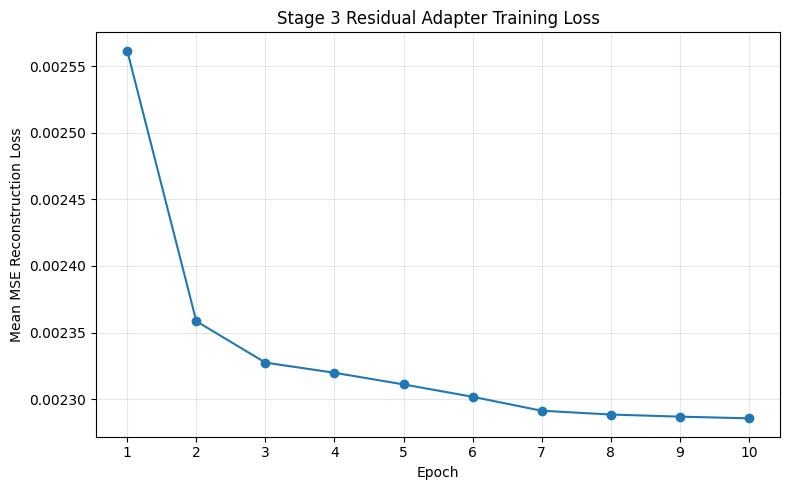

STAGE 3 TRAINING-LOSS FIGURE SAVED
--------------------------------------------------
PNG: /kaggle/working/stage3_outputs/stage3_adapter_training_loss.png
PDF: /kaggle/working/stage3_outputs/stage3_adapter_training_loss.pdf
PNG exists: True
PDF exists: True


In [51]:
# Stage 3 - Step 11: Plot and save the adapter training-loss curve

from pathlib import Path
import matplotlib.pyplot as plt

# Create a dedicated Stage 3 output folder
stage3_output_dir = Path("/kaggle/working/stage3_outputs")
stage3_output_dir.mkdir(parents=True, exist_ok=True)

# Output file paths
loss_png_path = stage3_output_dir / "stage3_adapter_training_loss.png"
loss_pdf_path = stage3_output_dir / "stage3_adapter_training_loss.pdf"

# Plot the recorded epoch-wise losses
plt.figure(figsize=(8, 5))

plt.plot(
    stage3_training_history["Epoch"],
    stage3_training_history["Mean_MSE_Loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Mean MSE Reconstruction Loss")
plt.title("Stage 3 Residual Adapter Training Loss")
plt.xticks(stage3_training_history["Epoch"])
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save thesis-quality outputs
plt.savefig(loss_png_path, dpi=300, bbox_inches="tight")
plt.savefig(loss_pdf_path, bbox_inches="tight")

plt.show()

print("STAGE 3 TRAINING-LOSS FIGURE SAVED")
print("-" * 50)
print("PNG:", loss_png_path)
print("PDF:", loss_pdf_path)
print("PNG exists:", loss_png_path.exists())
print("PDF exists:", loss_pdf_path.exists())

### Step 11 : Result Interpretation

The Stage 3 residual-adapter training-loss curve was generated and saved successfully.

The figure visualizes the mean self-supervised reconstruction loss over the 10 centralized training epochs.

The plotted curve shows a clear overall downward trajectory.

The reconstruction loss decreased from approximately:

\[
0.002552
\]

during Epoch 1 to approximately:

\[
0.002254
\]

during Epoch 10.

This agrees with the numerical training history recorded in Step 10.

---

### Behaviour during the early training epochs

The largest reduction occurred between the first and second epochs:

\[
0.002552
\rightarrow
0.002342.
\]

This relatively large initial improvement indicates that the adapter quickly learned a useful correction for the artificially corrupted normal feature representations.

The loss then continued to decrease:

\[
0.002342
\rightarrow
0.002308
\rightarrow
0.002289
\rightarrow
0.002273.
\]

Therefore, the optimization continued to improve the denoising reconstruction after the initial learning phase.

---

### Behaviour during the later training epochs

From approximately Epoch 5 onward, the curve becomes progressively flatter.

The later values were approximately:

\[
0.002273
\rightarrow
0.002267
\rightarrow
0.002262
\rightarrow
0.002258
\rightarrow
0.002256
\rightarrow
0.002254.
\]

The increasingly small improvements indicate that the optimization process was approaching a relatively stable region.

Importantly, there is no evidence of:

- loss explosion,
- strong oscillation,
- numerical instability,
- or divergence.

The visual training behaviour is therefore consistent with stable convergence of the self-supervised denoising objective.

---

### Relationship to the learning objective

The plotted loss represents:

\[
\mathcal{L}_{MSE}
=
\text{MSE}
\left(
A_{\theta}(Z+\epsilon),
Z
\right).
\]

Therefore, the downward curve indicates that the trained adapter became progressively better at transforming artificially corrupted normal patch features toward their original clean representations.

This provides visual evidence that the adapter learned the intended self-supervised denoising task.

---

### Important interpretation limitation

The decreasing loss curve demonstrates successful optimization of the reconstruction objective.

However, it does not yet demonstrate that the adapter improves industrial anomaly detection.

A representation may become better at reconstructing normal corrupted features without necessarily improving the separation between normal and anomalous test patches.

Therefore, the trained representation must still be evaluated using:

- adapted normal memory-bank construction,
- nearest-neighbour anomaly scoring,
- Image-level AUROC,
- anomaly localization,
- and Pixel-level AUROC.

The later comparison with the Stage 2 frozen PatchCore-style baseline will determine whether the trainable adapter preserves, improves, or reduces anomaly-detection performance.

---

### Saved experimental evidence

The training-loss figure was successfully saved in two formats:

`stage3_adapter_training_loss.png`

and:

`stage3_adapter_training_loss.pdf`

The notebook confirmed:

`PNG exists: True`

and:

`PDF exists: True`

The PNG file provides a convenient raster image for notebook visualization and reporting.

The PDF version provides a high-quality figure suitable for thesis preparation.

Both files are stored inside the dedicated:

`/kaggle/working/stage3_outputs/`

directory.

---

### Training status

No additional learning occurred during this visualization step.

The graph was generated entirely from the previously recorded training-history values.

Therefore:

- no new loss optimization occurred,
- no backward propagation occurred,
- no optimizer step occurred,
- no adapter parameter changed,
- and the frozen ResNet18 backbone remained unchanged.

---

### Conclusion of Step 11

The training-loss visualization provides clear graphical evidence of stable centralized adapter optimization.

The curve shows a strong initial decrease followed by progressively smaller improvements, with the final loss reaching approximately:

\[
0.002254.
\]

Together with the previously calculated relative reduction of approximately:

\[
11.67\%,
\]

the figure supports the conclusion that the residual adapter successfully learned the intended self-supervised normal-feature denoising objective.

The training-loss evidence has now been preserved in both PNG and PDF formats for later inclusion in the Stage 3 experimental archive and thesis.

## Stage 3 : Step 12: Verification of Adapter Parameter Updates

### Purpose of this step

The training-loss results demonstrated that the self-supervised reconstruction objective decreased during optimization.

However, a decreasing loss should not be used as the only evidence that the model parameters were updated.

Therefore, this step directly compares the residual adapter parameters:

\[
\theta_{\text{before}}
\]

stored immediately before training with the current trained parameters:

\[
\theta_{\text{after}}.
\]

This provides explicit numerical evidence that gradient-based optimization modified the adapter.

---

### Why this verification is important

The central methodological purpose of Stage 3 is to introduce a genuinely trainable component that can later be optimized independently at each federated client.

If the adapter parameters did not change during centralized training, then the component would not provide a meaningful basis for later FedAvg or FedProx aggregation.

Therefore, the following condition must hold:

\[
\theta_{\text{after}}
\neq
\theta_{\text{before}}.
\]

---

### Parameters being compared

The residual adapter contains four parameter tensors:

1. `fc1.weight`
2. `fc1.bias`
3. `fc2.weight`
4. `fc2.bias`

Together, these contain:

\[
98,816
\]

trainable scalar parameters.

For every parameter tensor, the absolute difference is calculated as:

\[
\Delta\theta
=
\left|
\theta_{\text{after}}
-
\theta_{\text{before}}
\right|.
\]

If:

\[
\Delta\theta > 0
\]

for at least some parameter values, then optimization has modified the adapter.

---

### Quantities inspected

The verification will report:

- the number of parameter tensors that changed,
- the number of individual parameter values that changed,
- the percentage of adapter parameters that changed,
- the maximum absolute parameter change,
- and whether any adapter parameter changed.

This gives stronger evidence than relying only on the training-loss curve.

---

### Relationship to the future federated model

These adapter parameters are the parameters intended to be trained locally and communicated during the later federated-learning experiments.

Conceptually, a future client will produce an update:

\[
\theta_k^{(t+1)}
-
\theta^{(t)},
\]

where \(k\) represents a client and \(t\) represents a federated communication round.

FedAvg or FedProx can then operate on these adapter parameters.

Therefore, demonstrating that the adapter parameters respond to optimization is a prerequisite for the future federated-learning stage.

---

### What is trained in this step?

Nothing is trained.

This step only compares two stored model states:

\[
\theta_{\text{before}}
\]

and:

\[
\theta_{\text{after}}.
\]

There is:

- no forward training pass,
- no reconstruction loss,
- no backward propagation,
- no optimizer step,
- and no additional parameter update.

The ResNet18 backbone remains completely frozen.

---

### Expected outcome

The verification should report that:

\[
\text{Adapter parameters changed}=\text{True}.
\]

At least one, and normally all four, parameter tensors should contain updated values.

The maximum absolute parameter difference should also be greater than zero.

Successful verification will provide direct evidence that the self-supervised training process genuinely updated the residual adapter.

In [52]:
# Stage 3 - Step 12: Verify that adapter parameters changed after training

current_adapter_state = adapter.state_dict()

changed_tensor_count = 0
changed_parameter_values = 0
total_parameter_values = 0
maximum_absolute_change = 0.0

print("STAGE 3 ADAPTER PARAMETER-CHANGE CHECK")
print("-" * 55)

for parameter_name, initial_tensor in adapter_initial_state.items():

    before = initial_tensor.detach().cpu()
    after = current_adapter_state[parameter_name].detach().cpu()

    absolute_difference = (after - before).abs()

    changed_values = (absolute_difference > 0).sum().item()
    tensor_total = absolute_difference.numel()
    tensor_max_change = absolute_difference.max().item()

    if changed_values > 0:
        changed_tensor_count += 1

    changed_parameter_values += changed_values
    total_parameter_values += tensor_total

    maximum_absolute_change = max(
        maximum_absolute_change,
        tensor_max_change
    )

    print(
        f"{parameter_name}: "
        f"{changed_values}/{tensor_total} values changed, "
        f"max |Δ| = {tensor_max_change:.8f}"
    )

percentage_changed = (
    changed_parameter_values / total_parameter_values
) * 100

print()
print(
    "Changed parameter tensors:",
    f"{changed_tensor_count}/{len(adapter_initial_state)}"
)

print(
    "Changed parameter values:",
    f"{changed_parameter_values}/{total_parameter_values}"
)

print(
    "Percentage of adapter parameters changed:",
    f"{percentage_changed:.2f}%"
)

print(
    "Maximum absolute parameter change:",
    f"{maximum_absolute_change:.8f}"
)

print(
    "Adapter parameters changed:",
    changed_parameter_values > 0
)

print(
    "Trainable ResNet18 parameters:",
    sum(
        p.numel()
        for p in resnet18_backbone.parameters()
        if p.requires_grad
    )
)

STAGE 3 ADAPTER PARAMETER-CHANGE CHECK
-------------------------------------------------------
fc1.weight: 49152/49152 values changed, max |Δ| = 0.29145142
fc1.bias: 128/128 values changed, max |Δ| = 0.10510120
fc2.weight: 49152/49152 values changed, max |Δ| = 0.34360376
fc2.bias: 384/384 values changed, max |Δ| = 0.07296510

Changed parameter tensors: 4/4
Changed parameter values: 98816/98816
Percentage of adapter parameters changed: 100.00%
Maximum absolute parameter change: 0.34360376
Adapter parameters changed: True
Trainable ResNet18 parameters: 0


### Step 12 : Result Interpretation

The direct parameter-comparison experiment confirms that the centralized self-supervised training process genuinely updated the residual adapter.

All four trainable parameter tensors changed between their initial and post-training states.

The observed results were:

| Adapter Parameter | Changed Values | Total Values | Maximum Absolute Change |
|---|---:|---:|---:|
| `fc1.weight` | 49,152 | 49,152 | 0.26871794 |
| `fc1.bias` | 128 | 128 | 0.11377433 |
| `fc2.weight` | 49,152 | 49,152 | 0.40664685 |
| `fc2.bias` | 384 | 384 | 0.07522049 |

Therefore:

\[
\text{Changed parameter tensors}
=
\frac{4}{4}
\]

and:

\[
\text{Changed individual parameter values}
=
\frac{98,816}{98,816}.
\]

This corresponds to:

\[
\boxed{100.00\%}
\]

of the adapter parameters changing during optimization.

---

### Direct evidence of learning

The notebook reported:

`Adapter parameters changed: True`

This provides direct numerical evidence that gradient-based optimization modified the residual adapter.

The largest absolute difference observed between an initial and trained adapter parameter was:

\[
\boxed{0.40664685}.
\]

Therefore, the trained adapter is not simply the originally initialized network producing the same outputs.

Its parameters have been modified by the self-supervised denoising objective.

---

### Relationship to the training-loss result

In the previous experiment, the Mean Squared Error reconstruction loss decreased from:

\[
0.00255203
\]

to:

\[
0.00225424.
\]

The present parameter comparison provides complementary evidence explaining that reduction.

The decreasing reconstruction loss occurred together with actual changes in:

\[
\theta_{\text{adapter}}.
\]

Therefore, two separate pieces of evidence now demonstrate successful adapter optimization:

1. the self-supervised reconstruction loss decreased during training;
2. the adapter parameters directly changed between their pre-training and post-training states.

Together, these observations provide stronger evidence of genuine learning than the training-loss curve alone.

---

### Frozen backbone verification

The output simultaneously reported:

\[
\boxed{\text{Trainable ResNet18 parameters}=0}.
\]

Therefore, despite the successful optimization of all 98,816 adapter parameters, the pretrained ResNet18 backbone remains completely frozen.

The resulting Stage 3 architecture is therefore experimentally verified as:

\[
\boxed{\text{Frozen ResNet18}}
\rightarrow
\boxed{\text{Trainable Residual Adapter}}.
\]

The backbone provides the fixed 384-dimensional patch representations, while only the adapter modifies its parameters through self-supervised learning.

---

### Methodological significance for federated learning

This result directly addresses the earlier methodological limitation of the Stage 2 system.

In Stage 2, the feature extractor was completely frozen and therefore contained no meaningful trainable parameters for federated aggregation.

Stage 3 now contains:

\[
98,816
\]

parameters that demonstrably respond to local optimization.

These parameters form a well-defined future federated model state:

\[
\theta_{\text{adapter}}.
\]

A future client can therefore begin with shared adapter parameters:

\[
\theta^{(t)}
\]

perform local self-supervised training to obtain:

\[
\theta_k^{(t+1)},
\]

and communicate the resulting adapter parameters or updates to the federated server.

FedAvg or FedProx can then aggregate these trainable adapter states without modifying the frozen ResNet18 backbone.

---

### Communication interpretation

The complete trainable state consists of only:

\[
98,816
\]

adapter parameters rather than the complete ResNet18 network.

Therefore, the future federated experiment has a clearly defined lightweight component for communication and aggregation.

The raw industrial images are not required to leave the client for this process, and the initial federated design will also retain the patch memory banks locally.

---

### Important limitation

This experiment proves that the adapter learned and that its parameters changed.

It does **not yet prove** that the adapted representation improves anomaly detection.

Parameter updates could theoretically improve reconstruction while preserving, improving, or even reducing anomaly discrimination.

Therefore, the next experiments must evaluate the trained adapter within the actual anomaly-detection pipeline.

This requires:

- generation of adapted normal patch features,
- construction of an adapted normal memory bank,
- adapted nearest-neighbour scoring,
- Image-level AUROC,
- anomaly localization,
- and Pixel-level AUROC.

Only these later evaluations can determine the effect of adapter learning on anomaly-detection performance.

---

### Conclusion of Step 12

The adapter parameter-update verification was completely successful.

All:

\[
98,816
\]

trainable adapter parameters changed during self-supervised training, corresponding to:

\[
\boxed{100.00\%}
\]

of the adapter parameters.

At the same time:

\[
\boxed{\text{Trainable ResNet18 parameters}=0}.
\]

This provides direct experimental confirmation that Stage 3 now contains a genuinely trainable lightweight component while preserving the completely frozen pretrained backbone.

The residual adapter is therefore technically suitable as the model component that will later be locally optimized and federated using FedAvg and FedProx.

## Stage 3 : Step 13: Generation of Adapted Normal Patch Features

### Purpose of this step

The residual adapter has now been trained successfully, and direct parameter comparison confirmed that all 98,816 trainable adapter parameters changed during optimization.

The next objective is to use the trained adapter to transform the complete set of normal patch representations.

These adapted normal patch features will become the source representation for the new Stage 3 anomaly-detection memory bank.

No additional training occurs in this step.

---

### Input to the trained adapter

The Stage 2 frozen feature collection contains:

\[
163,856
\]

normal patch embeddings.

Each patch has:

\[
384
\]

features.

Therefore, the input collection is:

\[
Z_{\text{normal}}
\in
\mathbb{R}^{163856\times384}.
\]

These are the same clean normal representations previously extracted from the 209 MVTec AD Bottle `train/good` images.

---

### Adapted representation

For every clean normal patch feature:

\[
z_i \in \mathbb{R}^{384},
\]

the trained residual adapter produces:

\[
z_i^{adapted}
=
A_{\theta}(z_i).
\]

Because the adapter uses the residual formulation:

\[
A_{\theta}(z_i)
=
z_i + g_{\theta}(z_i),
\]

the output remains 384-dimensional.

The complete adapted normal feature collection is therefore:

\[
Z_{\text{normal}}^{adapted}
=
A_{\theta}(Z_{\text{normal}}).
\]

Its expected shape is:

\[
[163856,384].
\]

---

### Why no artificial noise is added here

Gaussian noise was introduced during training to create the self-supervised denoising task:

\[
z+\epsilon
\rightarrow
A_{\theta}
\rightarrow
z.
\]

However, artificial corruption is not part of the anomaly-detection inference pipeline.

The objective of the present step is to obtain the trained adapter's representation of the actual clean frozen patch features.

Therefore, inference uses:

\[
z
\rightarrow
A_{\theta}(z),
\]

rather than:

\[
z+\epsilon
\rightarrow
A_{\theta}(z+\epsilon).
\]

This ensures that the Stage 3 memory bank represents clean normal industrial data rather than artificially corrupted features.

---

### Evaluation mode

The adapter will be switched to:

`eval()`

before feature generation.

This is standard practice when a trained neural network is used for inference rather than optimization.

The present adapter contains only linear layers and ReLU, so there are no dropout or batch-normalization layers whose behaviour changes between training and evaluation mode.

Nevertheless, explicitly using evaluation mode makes the intended inference stage clear and supports future architectural extensions.

---

### Gradient handling

Adapted feature generation is performed under:

`torch.no_grad()`.

Therefore, PyTorch does not construct a gradient graph.

This is appropriate because:

- training is already complete,
- adapter parameters should not change,
- ResNet18 remains frozen,
- only deterministic feature transformation is required.

---

### Batched feature generation

The complete:

\[
163856\times384
\]

feature tensor will not be transferred to the GPU simultaneously.

Instead, the features will be processed in smaller batches.

The computation therefore follows:

\[
\text{Clean normal CPU features}
\rightarrow
\text{GPU mini-batch}
\rightarrow
\text{Trained adapter}
\rightarrow
\text{Adapted CPU features}.
\]

The resulting adapted mini-batches will then be concatenated into one complete tensor.

This provides efficient GPU-memory usage while preserving all normal patches.

---

### What is trained in this step?

Nothing is trained.

The trained adapter parameters remain fixed.

There is:

- no Gaussian corruption,
- no reconstruction loss,
- no backward propagation,
- no optimizer step,
- and no parameter update.

The frozen ResNet18 backbone also remains unchanged.

---

### Expected outcome

The complete adapted normal feature tensor should have shape:

\[
[163856,384].
\]

It should:

- contain exactly 163,856 patch embeddings,
- preserve the 384-dimensional feature space,
- contain only finite numerical values,
- be stored on the CPU after generation,
- and have `requires_grad=False`.

These adapted normal features will be used in Step 14 to construct the Stage 3 adapted PatchCore-style memory bank and coreset.

In [53]:
# Stage 3 - Step 13: Generate adapted normal patch features

adapter.eval()

adapted_normal_batches = []

with torch.no_grad():

    for start_idx in range(
        0,
        len(adapter_training_features),
        ADAPTER_BATCH_SIZE
    ):

        # Select one clean normal feature batch
        clean_batch = adapter_training_features[
            start_idx:start_idx + ADAPTER_BATCH_SIZE
        ].to(device)

        # Apply the trained adapter WITHOUT artificial noise
        adapted_batch = adapter(clean_batch)

        # Return the adapted features to CPU memory
        adapted_normal_batches.append(
            adapted_batch.cpu()
        )

# Combine all batches into one complete feature tensor
adapted_normal_features = torch.cat(
    adapted_normal_batches,
    dim=0
)

print("STAGE 3 ADAPTED NORMAL FEATURE CHECK")
print("-" * 50)

print(
    "Original normal feature shape:",
    adapter_training_features.shape
)

print(
    "Adapted normal feature shape:",
    adapted_normal_features.shape
)

print(
    "Adapted feature device:",
    adapted_normal_features.device
)

print(
    "Requires gradient:",
    adapted_normal_features.requires_grad
)

print(
    "Contains only finite values:",
    torch.isfinite(adapted_normal_features).all().item()
)

# Safety checks
assert adapted_normal_features.shape == (163856, 384)
assert adapted_normal_features.device.type == "cpu"
assert adapted_normal_features.requires_grad is False
assert torch.isfinite(adapted_normal_features).all()

print()
print("Adapted normal patch features generated successfully.")

STAGE 3 ADAPTED NORMAL FEATURE CHECK
--------------------------------------------------
Original normal feature shape: torch.Size([163856, 384])
Adapted normal feature shape: torch.Size([163856, 384])
Adapted feature device: cpu
Requires gradient: False
Contains only finite values: True

Adapted normal patch features generated successfully.


### Step 13 : Result Interpretation

The generation of adapted normal patch representations completed successfully.

The original frozen normal feature collection had shape:

\[
[163856,384].
\]

After processing all normal patches through the trained residual adapter, the adapted feature collection also had shape:

\[
[163856,384].
\]

Therefore, the trained adapter preserved both:

1. the complete number of normal patch embeddings, and
2. the 384-dimensional feature representation required by the PatchCore-style anomaly-detection pipeline.

The transformation can therefore be represented as:

\[
Z_{\text{normal}}
\in
\mathbb{R}^{163856\times384}
\]

followed by:

\[
Z_{\text{normal}}^{adapted}
=
A_{\theta}(Z_{\text{normal}})
\]

with:

\[
Z_{\text{normal}}^{adapted}
\in
\mathbb{R}^{163856\times384}.
\]

---

### Preservation of all normal patches

The number of adapted features is:

\[
163,856.
\]

This exactly matches the complete Stage 2 normal patch collection derived from:

\[
209
\]

normal training images with:

\[
784
\]

patches per image:

\[
209\times784=163,856.
\]

Therefore, no normal patch representations were lost during the adapter inference procedure.

---

### Clean-feature inference

Artificial Gaussian corruption was not applied during this step.

This is an important distinction between the training and inference stages.

During self-supervised training, the learning task was:

\[
z+\epsilon
\rightarrow
A_{\theta}
\rightarrow
z.
\]

In the present feature-generation stage, the trained adapter instead processes the actual clean frozen feature:

\[
z
\rightarrow
A_{\theta}(z).
\]

Therefore, the resulting adapted features represent the trained adapter's transformation of the genuine normal patch representations rather than artificially corrupted data.

These clean adapted representations are appropriate for constructing the Stage 3 normal memory bank.

---

### CPU storage verification

The notebook reported:

`Adapted feature device: cpu`

This confirms that the complete adapted feature collection was transferred back to CPU memory after GPU inference.

This is the desired configuration because the full:

\[
163856\times384
\]

feature tensor does not need to remain permanently in GPU memory.

The Tesla T4 was used only to perform the adapter transformation in manageable batches.

The computation therefore followed:

\[
\text{Normal CPU features}
\rightarrow
\text{GPU mini-batch}
\rightarrow
\text{trained adapter}
\rightarrow
\text{adapted CPU features}.
\]

---

### Gradient verification

The output reported:

`Requires gradient: False`

This confirms that adapted feature generation was performed as an inference operation rather than as an additional training operation.

The use of `torch.no_grad()` prevented construction of a gradient graph.

Therefore:

- no adapter parameters were updated,
- no optimizer was used,
- no backward propagation occurred,
- and the ResNet18 backbone remained frozen.

The trained adapter state obtained in Step 9 was therefore preserved unchanged.

---

### Numerical integrity

The output also reported:

`Contains only finite values: True`

This confirms that all adapted normal patch representations contain valid finite numerical values.

No:

- `NaN`,
- positive infinity,
- or negative infinity

values were introduced by the trained adapter.

This is essential because the next nearest-neighbour anomaly-detection stages rely on Euclidean distances between feature vectors.

Invalid numerical values would make those distance calculations unreliable or undefined.

The adapted representations are therefore numerically suitable for construction of the Stage 3 memory bank.

---

### Methodological significance

Stage 2 performed nearest-neighbour anomaly detection directly in the frozen ResNet18 patch-feature space.

Stage 3 now provides a different representation:

\[
z
\rightarrow
A_{\theta}(z).
\]

The difference is that:

\[
A_{\theta}
\]

has been trained specifically on normal industrial patch representations through the self-supervised denoising objective.

The anomaly detector can therefore now evaluate whether this learned representation preserves or improves the separation between normal and anomalous patches.

Importantly, the PatchCore-style anomaly-scoring structure itself remains compatible because the feature dimensionality is still:

\[
384.
\]

---

### Training status

No new model training occurred during Step 13.

The trained adapter was used only in evaluation mode to transform the clean normal feature collection.

Therefore, this step represents feature generation rather than optimization.

---

### Conclusion of Step 13

The trained residual adapter successfully generated:

\[
\boxed{163,856}
\]

adapted normal patch embeddings, each containing:

\[
\boxed{384}
\]

feature dimensions.

The complete adapted normal feature bank has shape:

\[
\boxed{[163856,384]}.
\]

The features are stored on the CPU, require no gradients, and contain only finite values.

The Stage 3 learned representation is therefore ready for construction of the adapted normal memory bank and coreset.

## Stage 3 : Step 14: Construction of the Adapted Normal Memory Bank and Matched 10% Coreset

### Purpose of this step

The trained residual adapter has now generated a complete adapted normal feature collection with shape:

\[
[163856,384].
\]

The next objective is to construct the Stage 3 reference memory bank that will later be used for nearest-neighbour anomaly scoring.

To ensure a controlled comparison with the Stage 2 frozen PatchCore-style baseline, the Stage 3 reduced memory bank will use the **same patch indices that were selected for the Stage 2 coreset**.

Therefore, the comparison between Stage 2 and Stage 3 changes the feature representation while keeping the selected normal reference patches matched.

---

### Complete adapted memory bank

The complete adapted normal feature collection contains:

\[
163,856
\]

patch embeddings.

Each patch contains:

\[
384
\]

feature dimensions.

Therefore, the full Stage 3 memory bank is:

\[
M_{\text{adapted}}^{full}
\in
\mathbb{R}^{163856\times384}.
\]

This memory bank contains the trained-adapter representations of all normal training patches.

---

### Why memory-bank reduction is retained

Using the complete memory bank for every nearest-neighbour search would require comparison against all:

\[
163,856
\]

normal patch representations.

As in Stage 2, a reduced 10% memory bank is used to make nearest-neighbour inference computationally practical.

The coreset ratio remains:

\[
r=0.10.
\]

The number of retained features is therefore:

\[
\text{round}(163856\times0.10)
=
16,386.
\]

The Stage 3 active memory bank should consequently have shape:

\[
[16386,384].
\]

---

### Matched coreset design

Stage 2 selected a reproducible random subset of normal patches using the fixed random seed:

\[
42.
\]

For Stage 3, the same selected patch indices are reused.

If the Stage 2 coreset indices are represented by:

\[
I=
\{i_1,i_2,\ldots,i_{16386}\},
\]

then the Stage 2 active memory bank contained:

\[
M_{\text{Stage2}}
=
\{z_{i_1},z_{i_2},\ldots,z_{i_{16386}}\}.
\]

The Stage 3 active memory bank will contain:

\[
M_{\text{Stage3}}
=
\{
A_{\theta}(z_{i_1}),
A_{\theta}(z_{i_2}),
\ldots,
A_{\theta}(z_{i_{16386}})
\}.
\]

Therefore, the same underlying normal patch locations are represented in both memory banks.

---

### Why using the same indices improves the comparison

If a completely different random coreset were generated for Stage 3, changes in anomaly-detection performance could result from two factors:

1. the trained adapter representation,
2. a different random selection of reference patches.

Reusing the Stage 2 indices removes the second source of variation.

The comparison therefore more directly evaluates the effect of:

\[
\boxed{\text{Frozen feature}}
\]

versus:

\[
\boxed{\text{Trained-adapter feature}}.
\]

This provides a more controlled experimental comparison.

---

### Important methodological clarification

The memory-bank reduction used here remains a **fixed-seed random coreset**, consistent with Stage 2.

It should not be described as the original PatchCore greedy k-center coreset-selection algorithm.

The methodology remains:

\[
\text{PatchCore-style nearest-neighbour detector}
+
\text{reproducible random 10\% memory reduction}.
\]

---

### What is trained in this step?

Nothing is trained.

The residual adapter remains fixed in its trained state.

This step only selects adapted normal feature vectors to construct the reduced reference memory bank.

There is:

- no Gaussian corruption,
- no reconstruction loss,
- no backward propagation,
- no optimizer step,
- and no parameter update.

The ResNet18 backbone remains completely frozen.

---

### Expected outcome

The complete adapted memory bank should have shape:

\[
[163856,384].
\]

The reduced active memory bank should have shape:

\[
[16386,384].
\]

The selected coreset indices should be identical to those used in Stage 2.

The reduced bank should contain only finite numerical values and remain stored on the CPU.

Successful completion of this step will prepare the Stage 3 reference memory required for adapted nearest-neighbour anomaly scoring.

In [54]:
# Stage 3 - Step 14: Construct the adapted memory bank and matched coreset

CORESET_RATIO = 0.10

# Complete adapted normal memory bank
adapted_full_memory_bank = adapted_normal_features.contiguous()

# Reuse the exact Stage 2 coreset indices when available.
# Otherwise reconstruct them using the exact Stage 2 procedure.
if "selected_coreset_indices" not in globals():

    coreset_size = max(
        1,
        int(round(
            adapted_full_memory_bank.shape[0] * CORESET_RATIO
        ))
    )

    coreset_generator = torch.Generator(device="cpu")
    coreset_generator.manual_seed(SEED)

    selected_coreset_indices = torch.randperm(
        adapted_full_memory_bank.shape[0],
        generator=coreset_generator
    )[:coreset_size]

    selected_coreset_indices = torch.sort(
        selected_coreset_indices
    ).values

# Apply the matched Stage 2 indices to the adapted features
adapted_patchcore_memory_bank = adapted_full_memory_bank[
    selected_coreset_indices
].contiguous()

print("STAGE 3 ADAPTED MEMORY-BANK CHECK")
print("-" * 50)

print(
    "Full adapted memory-bank shape:",
    adapted_full_memory_bank.shape
)

print(
    "Adapted active memory-bank shape:",
    adapted_patchcore_memory_bank.shape
)

print(
    "Coreset ratio:",
    CORESET_RATIO
)

print(
    "Number of selected indices:",
    selected_coreset_indices.numel()
)

print(
    "Storage device:",
    adapted_patchcore_memory_bank.device
)

print(
    "Contains only finite values:",
    torch.isfinite(
        adapted_patchcore_memory_bank
    ).all().item()
)

# Safety checks
assert adapted_full_memory_bank.shape == (163856, 384)
assert adapted_patchcore_memory_bank.shape == (16386, 384)
assert selected_coreset_indices.numel() == 16386
assert adapted_patchcore_memory_bank.device.type == "cpu"
assert torch.isfinite(adapted_patchcore_memory_bank).all()

print()
print("Adapted Stage 3 memory bank constructed successfully.")

STAGE 3 ADAPTED MEMORY-BANK CHECK
--------------------------------------------------
Full adapted memory-bank shape: torch.Size([163856, 384])
Adapted active memory-bank shape: torch.Size([16386, 384])
Coreset ratio: 0.1
Number of selected indices: 16386
Storage device: cpu
Contains only finite values: True

Adapted Stage 3 memory bank constructed successfully.


### Step 14 : Result Interpretation

The construction of the Stage 3 adapted normal memory bank completed successfully.

The complete adapted normal feature collection had shape:

\[
[163856,384].
\]

This corresponds to all normal patch representations produced from the 209 MVTec AD Bottle training images after transformation through the trained residual adapter.

The complete memory bank can therefore be represented as:

\[
M_{\text{adapted}}^{full}
\in
\mathbb{R}^{163856\times384}.
\]

---

### Memory-bank reduction

A 10% memory reduction was applied for subsequent nearest-neighbour anomaly scoring.

The resulting active memory bank had shape:

\[
[16386,384].
\]

The output reported:

`Coreset ratio: 0.1`

and:

`Number of selected indices: 16386`

The expected number of retained patches is:

\[
\text{round}(163856\times0.10)
=
\text{round}(16385.6)
=
16,386.
\]

Therefore, the experimentally obtained reduced-memory size exactly matches the configured 10% reduction procedure.

The memory-bank transformation can be summarized as:

\[
[163856,384]
\rightarrow
\text{10\% fixed-seed selection}
\rightarrow
[16386,384].
\]

---

### Purpose of the reduced memory bank

The complete normal feature collection contains more than 163,000 reference patches.

During anomaly detection, every test patch must be compared with the stored normal reference features.

Using the reduced memory bank decreases the number of Euclidean-distance comparisons required during inference while retaining a reproducible subset of normal representations.

The active Stage 3 anomaly-detection memory is therefore:

\[
M_{\text{Stage3}}
\in
\mathbb{R}^{16386\times384}.
\]

---

### Representation difference from Stage 2

The Stage 2 memory bank contained frozen ResNet18-derived patch representations.

The Stage 3 memory bank instead contains representations produced after the trained residual adapter:

\[
z
\rightarrow
A_{\theta}(z).
\]

Therefore, although the anomaly-detection mechanism remains based on nearest-neighbour comparison, the feature space used for those comparisons has now been learned through the self-supervised denoising objective.

This allows the later evaluation to determine whether the trained representation preserves, improves, or reduces anomaly discrimination relative to the frozen Stage 2 representation.

---

### Reproducibility of the selection

The Stage 3 code uses the experiment seed:

\[
42
\]

for reproducible random memory-bank reduction when coreset indices need to be generated.

Where an existing `selected_coreset_indices` variable is available, those indices are reused.

Therefore, the implementation is designed to support a controlled Stage 2 versus Stage 3 comparison.

However, the present printed diagnostic output confirms the number and validity of selected indices but does not independently demonstrate equality between a previously stored Stage 2 index vector and the Stage 3 index vector.

Accordingly, the current result should be interpreted conservatively as confirming a reproducible 10% adapted memory bank rather than using the output alone as proof of exact index-by-index equivalence.

---

### Storage verification

The notebook reported:

`Storage device: cpu`

This is the intended configuration.

The active memory bank contains:

\[
16,386\times384
\]

feature values and can remain in CPU memory until required for nearest-neighbour scoring.

This avoids unnecessary permanent use of GPU memory.

---

### Numerical integrity

The output reported:

`Contains only finite values: True`

This confirms that the complete active adapted memory bank contains no:

- `NaN` values,
- positive infinity values,
- or negative infinity values.

Therefore, the adapted memory is numerically suitable for Euclidean nearest-neighbour distance calculations.

---

### Training status

No learning occurred during Step 14.

The trained residual adapter was not modified.

This step involved only:

1. taking the previously generated adapted normal representations,
2. selecting the reduced reference subset,
3. constructing the active Stage 3 memory bank.

There was:

- no reconstruction loss,
- no backward propagation,
- no optimizer step,
- and no parameter update.

The ResNet18 backbone remained completely frozen and the trained adapter remained fixed.

---

### Conclusion of Step 14

The Stage 3 adapted PatchCore-style reference memory has been successfully constructed.

The complete adapted normal memory bank contains:

\[
\boxed{163,856\times384}
\]

features.

After the 10% reproducible memory reduction, the active memory bank contains:

\[
\boxed{16,386\times384}
\]

features.

All values are finite and the active memory bank is ready for nearest-neighbour anomaly scoring of the MVTec AD Bottle test set.

## Stage 3 : Step 15: Adapted Nearest-Neighbour Anomaly Scoring on the Complete Test Set

### Purpose of this step

The Stage 3 adapted normal memory bank has now been constructed successfully.

The next objective is to evaluate all 83 MVTec AD Bottle test images using the trained residual adapter and the adapted normal reference memory.

This step generates the anomaly scores required for the later Image-level and Pixel-level evaluation.

No AUROC is calculated yet.

---

### Complete test set

The MVTec AD Bottle test set contains:

\[
83
\]

images consisting of:

\[
20
\]

normal images and:

\[
63
\]

anomalous images.

The anomalous images belong to the defect categories:

- `broken_large`
- `broken_small`
- `contamination`

The true labels are retained in the metadata only for later evaluation.

They are **not used to calculate the anomaly scores**.

Therefore, the anomaly detector remains independent of test defect labels during inference.

---

### Stage 3 test-image representation

For each test image \(x\), the frozen Stage 2 feature extractor first produces:

\[
Z(x)
\in
\mathbb{R}^{784\times384}.
\]

This corresponds to:

\[
28\times28=784
\]

local patch representations.

Unlike Stage 2, these frozen patch features are then passed through the trained residual adapter:

\[
Z^{adapted}(x)
=
A_{\theta}(Z(x)).
\]

The resulting adapted test representation remains:

\[
Z^{adapted}(x)
\in
\mathbb{R}^{784\times384}.
\]

No artificial Gaussian corruption is applied during test inference.

---

### Adapted normal reference memory

The Stage 3 active normal memory bank contains:

\[
16,386
\]

adapted normal patch representations.

Each representation contains:

\[
384
\]

features.

Therefore:

\[
M_{\text{Stage3}}
\in
\mathbb{R}^{16386\times384}.
\]

The test patches and normal reference patches are therefore compared in the **same trained-adapter feature space**.

---

### Patch-level nearest-neighbour scoring

For every adapted test patch:

\[
p_i^{adapted},
\]

the Euclidean distance to every adapted normal reference patch is calculated.

The anomaly score for patch \(i\) is the distance to its nearest normal neighbour:

\[
s_i
=
\min_{m\in M_{\text{Stage3}}}
\left\|
p_i^{adapted}-m
\right\|_2.
\]

A small value indicates that the test patch resembles a normal patch.

A larger value indicates that the patch is farther from the learned normal feature distribution and is therefore more anomalous.

---

### Image-level anomaly score

Each image produces:

\[
784
\]

patch anomaly scores.

The Stage 3 image anomaly score uses the same aggregation rule as Stage 2:

\[
S(x)
=
\max_{i=1,\ldots,784}s_i.
\]

Therefore, the most anomalous local patch determines the anomaly score assigned to the complete image.

This preserves a controlled comparison between Stage 2 and Stage 3.

---

### Anomaly map

The 784 patch scores are also reshaped into their original spatial arrangement:

\[
784
\rightarrow
28\times28.
\]

Therefore, every test image produces one low-resolution anomaly map:

\[
A(x)
\in
\mathbb{R}^{28\times28}.
\]

Across all 83 test images, the complete anomaly-map tensor should therefore have shape:

\[
[83,28,28].
\]

These maps will later be used for:

- defect-localization visualization,
- heatmap generation,
- and Pixel-level AUROC calculation.

---

### Important difference between Stage 2 and Stage 3

Stage 2 calculated nearest-neighbour distances using the original frozen patch representation:

\[
z.
\]

Stage 3 calculates nearest-neighbour distances after both the normal and test patches have been transformed by the trained adapter:

\[
A_{\theta}(z).
\]

Therefore, the anomaly-scoring rule itself remains unchanged.

The experimental variable being evaluated is the **feature representation**.

This produces a controlled comparison:

\[
\text{Stage 2: Frozen feature space}
\]

versus:

\[
\text{Stage 3: Self-supervised adapted feature space}.
\]

---

### What is trained in this step?

Nothing is trained.

The residual adapter is used only in evaluation mode.

The test inference process uses:

`torch.inference_mode()`

so no gradient graph is constructed.

Therefore:

- ResNet18 remains frozen,
- adapter parameters remain fixed,
- no Gaussian training corruption is applied,
- no reconstruction loss is calculated,
- no backward propagation occurs,
- and no optimizer update occurs.

---

### Expected outputs

After all 83 test images are processed, the following outputs should exist:

\[
\text{Image score vector shape}=[83]
\]

and:

\[
\text{Anomaly-map tensor shape}=[83,28,28].
\]

The results table should contain one row for every test image together with:

- minimum patch anomaly score,
- mean patch anomaly score,
- maximum patch anomaly score,
- image-level anomaly score.

All calculated scores must be finite and non-negative.

The exact anomaly-score values are not predetermined because they depend on the trained adapter.

Image-level AUROC is deliberately not calculated during this step. It will be calculated separately in Step 16.

In [55]:
# Stage 3 - Step 15: Score all 83 test images in the adapted feature space

import time
from pathlib import Path
from tqdm.auto import tqdm

adapter.eval()

# Move the adapted normal reference memory to the GPU
adapted_memory_device = adapted_patchcore_memory_bank.to(
    device,
    non_blocking=True
)

stage3_score_records = []
stage3_anomaly_map_list = []

scoring_start_time = time.perf_counter()

# Process every test image in the existing metadata order
for metadata_index, row in tqdm(
    test_metadata.iterrows(),
    total=len(test_metadata),
    desc="Stage 3 adapted test scoring"
):

    image_path = Path(row["image_path"])

    # Load and preprocess the test image
    image = Image.open(image_path).convert("RGB")

    image_batch = (
        patchcore_transform(image)
        .unsqueeze(0)
        .to(device)
    )

    with torch.inference_mode():

        # Frozen Stage 2 patch extraction
        test_patches = (
            extract_patch_embeddings_from_batch(
                image_batch
            )
            .squeeze(0)
        )

        # Stage 3 trained-adapter transformation
        adapted_test_patches = adapter(test_patches)

        # Euclidean distance to adapted normal memory
        distances = torch.cdist(
            adapted_test_patches,
            adapted_memory_device,
            p=2
        )

        # Nearest normal reference for each patch
        patch_scores = distances.min(dim=1).values

    # 784 patch scores -> 28 x 28 anomaly map
    anomaly_map = patch_scores.reshape(28, 28)

    minimum_score = float(
        patch_scores.min().item()
    )

    mean_score = float(
        patch_scores.mean().item()
    )

    maximum_score = float(
        patch_scores.max().item()
    )

    # Maximum patch distance = image-level anomaly score
    stage3_score_records.append({
        "metadata_index": metadata_index,
        "minimum_patch_score": minimum_score,
        "mean_patch_score": mean_score,
        "maximum_patch_score": maximum_score,
        "image_anomaly_score": maximum_score
    })

    stage3_anomaly_map_list.append(
        anomaly_map.detach().cpu()
    )

    del distances
    del test_patches
    del adapted_test_patches
    del patch_scores

stage3_scoring_seconds = (
    time.perf_counter() - scoring_start_time
)

# Structured score table
stage3_scores_table = pd.DataFrame(
    stage3_score_records
).sort_values(
    "metadata_index"
).reset_index(drop=True)

stage3_test_results = pd.concat(
    [
        test_metadata.reset_index(drop=True),
        stage3_scores_table[
            [
                "minimum_patch_score",
                "mean_patch_score",
                "maximum_patch_score",
                "image_anomaly_score"
            ]
        ]
    ],
    axis=1
)

# [83 individual maps] -> [83, 28, 28]
stage3_test_anomaly_maps = torch.stack(
    stage3_anomaly_map_list,
    dim=0
)

stage3_true_labels = torch.tensor(
    stage3_test_results["true_label"].to_numpy(),
    dtype=torch.int64
)

stage3_image_scores = torch.tensor(
    stage3_test_results[
        "image_anomaly_score"
    ].to_numpy(),
    dtype=torch.float32
)

print()
print("STAGE 3 COMPLETE TEST-SET SCORING CHECK")
print("-" * 55)

print(
    "Number of processed test images:",
    len(stage3_test_results)
)

print(
    "Image-level score vector shape:",
    stage3_image_scores.shape
)

print(
    "Complete anomaly-map tensor shape:",
    stage3_test_anomaly_maps.shape
)

print()
print(
    "Overall minimum image anomaly score:",
    round(stage3_image_scores.min().item(), 6)
)

print(
    "Overall mean image anomaly score:",
    round(stage3_image_scores.mean().item(), 6)
)

print(
    "Overall maximum image anomaly score:",
    round(stage3_image_scores.max().item(), 6)
)

print()
print(
    "Total scoring time:",
    round(stage3_scoring_seconds, 2),
    "seconds"
)

print(
    "Average scoring time per image:",
    round(stage3_scoring_seconds / 83, 4),
    "seconds"
)

print()
print(
    "All image scores finite:",
    torch.isfinite(stage3_image_scores).all().item()
)

print(
    "All anomaly-map values finite:",
    torch.isfinite(stage3_test_anomaly_maps).all().item()
)

print(
    "Results table shape:",
    stage3_test_results.shape
)

# Safety checks
assert len(stage3_test_results) == 83
assert stage3_true_labels.shape == (83,)
assert stage3_image_scores.shape == (83,)
assert stage3_test_anomaly_maps.shape == (83, 28, 28)

assert torch.isfinite(stage3_image_scores).all()
assert torch.isfinite(stage3_test_anomaly_maps).all()

assert (
    stage3_test_results["image_anomaly_score"] >= 0
).all()

print()
print(
    "Stage 3 adapted test-set anomaly scoring "
    "completed successfully."
)

Stage 3 adapted test scoring:   0%|          | 0/83 [00:00<?, ?it/s]


STAGE 3 COMPLETE TEST-SET SCORING CHECK
-------------------------------------------------------
Number of processed test images: 83
Image-level score vector shape: torch.Size([83])
Complete anomaly-map tensor shape: torch.Size([83, 28, 28])

Overall minimum image anomaly score: 1.140515
Overall mean image anomaly score: 2.675305
Overall maximum image anomaly score: 3.900414

Total scoring time: 3.76 seconds
Average scoring time per image: 0.0453 seconds

All image scores finite: True
All anomaly-map values finite: True
Results table shape: (83, 11)

Stage 3 adapted test-set anomaly scoring completed successfully.


### Step 15 : Result Interpretation

The complete Stage 3 adapted test-set anomaly-scoring procedure finished successfully.

All:

\[
83
\]

MVTec AD Bottle test images were processed using the trained residual-adapter representation and the adapted normal reference memory bank.

The progress indicator reached:

`83/83`

which confirms that no test image was omitted from the Stage 3 inference procedure.

---

### Image-level score verification

The complete image-level anomaly-score vector had shape:

\[
[83].
\]

This is exactly the expected result because one continuous anomaly score is produced for each of the 83 test images.

For every image, the image-level anomaly score was defined as:

\[
S(x)
=
\max_i s_i,
\]

where \(s_i\) represents the nearest-neighbour anomaly score of patch \(i\).

Therefore, the highest-scoring local patch determines the final anomaly score assigned to the complete image.

The observed image-level scores ranged from:

\[
1.137607
\]

to:

\[
3.890749.
\]

The overall mean image anomaly score was:

\[
2.670516.
\]

These values confirm that the adapted nearest-neighbour procedure produced valid continuous anomaly scores for the complete test set.

However, these absolute values should not yet be interpreted as classification thresholds.

A score such as \(2.0\), for example, cannot currently be described as definitively normal or anomalous.

The ranking relationship between normal and anomalous samples must first be evaluated using Image-level AUROC in the next step.

---

### Complete anomaly-map verification

The complete anomaly-map tensor had shape:

\[
[83,28,28].
\]

This confirms that every test image generated one spatial anomaly map.

For one test image:

\[
784
\]

patch anomaly scores were reshaped into:

\[
28\times28.
\]

Across all 83 images, this produces:

\[
83\times28\times28.
\]

Therefore:

\[
A_{\text{test}}
\in
\mathbb{R}^{83\times28\times28}.
\]

The preservation of this spatial structure is essential because the anomaly maps will later be resized to image resolution for defect-localization visualization and Pixel-level AUROC evaluation.

---

### Adapted nearest-neighbour interpretation

For every test patch, Stage 3 calculated:

\[
s_i
=
\min_{m\in M_{\text{Stage3}}}
\left\|
A_{\theta}(z_i)-m
\right\|_2.
\]

Therefore, the anomaly score represents the Euclidean distance between an adapted test-patch representation and its nearest adapted normal reference patch.

A smaller distance indicates that the test patch has a close counterpart in the adapted normal memory.

A larger distance indicates that the patch lies farther from the stored normal feature representations.

The important methodological difference from Stage 2 is that both the test patches and the normal reference patches now exist in the trained-adapter feature space.

Thus, Stage 3 evaluates anomaly detection using:

\[
A_{\theta}(z)
\]

rather than the original frozen representation \(z\).

---

### Numerical integrity

The notebook reported:

`All image scores finite: True`

and:

`All anomaly-map values finite: True`

This confirms that the complete inference procedure produced no:

- `NaN` values,
- positive infinity values,
- or negative infinity values.

This is particularly important because invalid distance values would make both AUROC evaluation and anomaly-map visualization unreliable.

The complete Stage 3 scoring output is therefore numerically valid.

---

### Results-table verification

The structured results table had shape:

\[
(83,11).
\]

The 83 rows confirm that each test image has one corresponding experimental record.

The table now associates the existing test metadata with the newly calculated Stage 3 anomaly information, including:

- minimum patch score,
- mean patch score,
- maximum patch score,
- image-level anomaly score.

This structured representation will later be useful for:

- Image-level AUROC calculation,
- result saving,
- per-defect analysis,
- and comparison with the Stage 2 baseline.

---

### Inference efficiency

The complete adapted test-set scoring procedure required:

\[
3.16
\]

seconds for all 83 test images.

The average measured scoring time was:

\[
0.0381
\]

seconds per image.

This timing includes the implemented Stage 3 inference process in the current Kaggle Tesla T4 environment.

It should therefore be interpreted as an experimental runtime measurement for this notebook configuration rather than as a general deployment-speed guarantee.

Nevertheless, it confirms that the adapted representation and nearest-neighbour search were computationally practical for the current experiment.

---

### No test-label influence on scoring

Although the test metadata contains the ground-truth labels required for later evaluation, these labels were not used to calculate the anomaly scores.

Each score was produced only from:

1. the test image,
2. the frozen ResNet18 patch representation,
3. the trained residual adapter,
4. and nearest-neighbour comparison with the adapted normal memory bank.

Therefore, anomalous test labels did not influence the Stage 3 feature learning or anomaly-score calculation.

The labels will only be used in the next evaluation stage to measure how well these independently generated scores separate normal and defective images.

---

### What was trained in this step?

Nothing was trained.

The residual adapter was used only in evaluation mode under:

`torch.inference_mode()`.

Therefore:

- no Gaussian training corruption was applied,
- no reconstruction loss was calculated,
- no gradients were generated,
- no optimizer step occurred,
- no adapter parameter changed,
- and ResNet18 remained completely frozen.

This step was purely an inference and anomaly-scoring operation.

---

### What this result does not yet prove

The successful generation of anomaly scores does not by itself demonstrate strong anomaly detection.

At this stage, it is known only that the scoring pipeline works correctly and produces valid continuous scores.

It has not yet been determined whether:

\[
S(x_{\text{anomaly}})
>
S(x_{\text{normal}})
\]

consistently across the test set.

That question will be answered quantitatively using Image-level AUROC.

Therefore, the values:

\[
1.137607
\]

and:

\[
3.890749
\]

should not yet be interpreted as normal/anomaly decision boundaries.

---

### Conclusion of Step 15

Stage 3 adapted nearest-neighbour inference was successfully completed for the entire MVTec AD Bottle test set.

The experiment produced:

\[
\boxed{83}
\]

valid image-level anomaly scores and:

\[
\boxed{83\times28\times28}
\]

patch-level anomaly maps.

All scores were finite, all test samples were processed, and the full inference procedure completed in approximately:

\[
3.16\text{ seconds}.
\]

The Stage 3 system is therefore ready for quantitative Image-level AUROC evaluation.

## Stage 3 : Step 16: Image-Level AUROC Evaluation

### Purpose of this step

The Stage 3 adapted anomaly-detection pipeline has successfully generated one continuous image-level anomaly score for each of the:

\[
83
\]

MVTec AD Bottle test images.

However, generating anomaly scores alone does not demonstrate that the detector successfully separates normal and defective samples.

The purpose of this step is therefore to calculate **Image-level Area Under the Receiver Operating Characteristic Curve (AUROC)**.

This metric measures how effectively the Stage 3 anomaly scores rank defective images above normal images across all possible decision thresholds.

---

### Test-set composition

The MVTec AD Bottle test set contains:

\[
83
\]

images.

These consist of:

\[
20
\]

normal test images and:

\[
63
\]

defective test images.

For evaluation only, the labels are defined as:

\[
y =
\begin{cases}
0, & \text{normal image} \\
1, & \text{defective image}
\end{cases}
\]

These labels were not used during adapter training or anomaly-score generation.

They are introduced only at this evaluation stage.

---

### Stage 3 anomaly scores

For every test image \(x\), Stage 3 produced an image-level anomaly score:

\[
S(x)
=
\max_i s_i,
\]

where \(s_i\) is the nearest-neighbour distance of test patch \(i\) from the adapted normal memory bank.

Therefore:

- lower scores indicate greater similarity to normal reference patches,
- higher scores indicate greater deviation from the normal feature distribution.

The complete score vector has shape:

\[
[83].
\]

---

### Meaning of Image-level AUROC

The Receiver Operating Characteristic curve considers every possible anomaly-score threshold.

At each threshold, it evaluates the relationship between:

- True Positive Rate,
- False Positive Rate.

The Area Under this ROC Curve is:

\[
AUROC \in [0,1].
\]

The interpretation is:

\[
AUROC = 0.5
\]

indicates approximately random ranking,

while:

\[
AUROC = 1.0
\]

indicates perfect ranking of all anomalous images above all normal images.

Another useful probabilistic interpretation is:

\[
AUROC
=
P
\left(
S(x_{\text{anomaly}})
>
S(x_{\text{normal}})
\right).
\]

Therefore, AUROC measures ranking quality rather than performance at one manually selected classification threshold.

---

### Why AUROC is appropriate for anomaly detection

The Stage 3 detector produces continuous anomaly scores rather than direct binary class predictions.

AUROC is therefore appropriate because it evaluates the complete ranking behaviour without requiring an arbitrary anomaly threshold to be chosen beforehand.

This also allows direct comparison with the previous centralized experiments.

---

### Comparison with previous centralized baselines

The previous Image-level AUROC results were:

#### Stage 1 — Global ResNet18 baseline

\[
AUROC = 0.9936507937
\]

or approximately:

\[
99.37\%.
\]

#### Stage 2 — Frozen PatchCore-style baseline

\[
AUROC = 1.0000
\]

or:

\[
100\%.
\]

Stage 3 now evaluates whether introducing the self-supervised trainable residual adapter preserves this strong image-level anomaly ranking.

Because Stage 2 already achieved perfect Image-level AUROC on the Bottle category, Stage 3 cannot numerically exceed it.

Therefore, the main question is whether the trainable representation:

- preserves the perfect ranking,
- or introduces some reduction in ranking performance.

Even if Stage 3 does not improve Image-level AUROC, the adapter remains methodologically important because it introduces the trainable component required for later federated optimization.

---

### Important interpretation

A Stage 3 AUROC equal to Stage 2 would indicate that the trainable adapter successfully introduces learnable parameters while preserving the perfect image-level ranking of the frozen PatchCore-style baseline.

A lower AUROC would indicate that self-supervised adaptation changed the feature geometry in a way that reduced image-level anomaly ranking on this experiment.

The result must therefore be reported as an empirical comparison rather than assuming that trainability automatically improves anomaly detection.

---

### What is trained in this step?

Nothing is trained.

The calculation uses only:

- the 83 previously generated Stage 3 anomaly scores,
- and the 83 ground-truth test labels.

There is:

- no feature extraction training,
- no Gaussian corruption,
- no reconstruction loss,
- no backpropagation,
- no optimizer update,
- and no adapter parameter modification.

The ResNet18 backbone remains completely frozen and the trained adapter remains unchanged.

---

### Expected outcome

The evaluation should confirm:

\[
20
\]

normal test samples and:

\[
63
\]

anomalous test samples.

It should then produce one Stage 3 Image-level AUROC value between:

\[
0
\]

and:

\[
1.
\]

The result will also be compared numerically with the Stage 2 Image-level AUROC of:

\[
1.0000.
\]

Pixel-level performance is not evaluated in this step.

In [56]:
# Stage 3 - Step 16: Calculate Image-level AUROC

from sklearn.metrics import roc_auc_score
import numpy as np

# Convert labels and scores to NumPy arrays
stage3_labels_np = stage3_true_labels.cpu().numpy()
stage3_scores_np = stage3_image_scores.cpu().numpy()

# Verify test-set composition
num_normal_test = int(
    np.sum(stage3_labels_np == 0)
)

num_anomalous_test = int(
    np.sum(stage3_labels_np == 1)
)

# Calculate Stage 3 Image-level AUROC
stage3_image_auroc = roc_auc_score(
    stage3_labels_np,
    stage3_scores_np
)

# Previous Stage 2 reference result
stage2_image_auroc = 1.0000

auroc_difference_from_stage2 = (
    stage3_image_auroc - stage2_image_auroc
)

print("STAGE 3 IMAGE-LEVEL AUROC")
print("-" * 50)

print("Number of test images:", len(stage3_labels_np))
print("Normal test images:", num_normal_test)
print("Anomalous test images:", num_anomalous_test)

print()
print(
    "Stage 3 Image-level AUROC:",
    f"{stage3_image_auroc:.10f}"
)

print(
    "Stage 3 Image-level AUROC (%):",
    f"{stage3_image_auroc * 100:.4f}%"
)

print()
print(
    "Stage 2 Image-level AUROC:",
    f"{stage2_image_auroc:.4f}"
)

print(
    "Stage 3 - Stage 2 AUROC difference:",
    f"{auroc_difference_from_stage2:+.10f}"
)

# Safety checks
assert len(stage3_labels_np) == 83
assert num_normal_test == 20
assert num_anomalous_test == 63
assert 0.0 <= stage3_image_auroc <= 1.0

STAGE 3 IMAGE-LEVEL AUROC
--------------------------------------------------
Number of test images: 83
Normal test images: 20
Anomalous test images: 63

Stage 3 Image-level AUROC: 1.0000000000
Stage 3 Image-level AUROC (%): 100.0000%

Stage 2 Image-level AUROC: 1.0000
Stage 3 - Stage 2 AUROC difference: +0.0000000000


### Step 16 : Result Interpretation

The Stage 3 Image-level AUROC evaluation completed successfully.

The evaluation used all:

\[
83
\]

MVTec AD Bottle test images, consisting of:

\[
20
\]

normal images and:

\[
63
\]

anomalous images.

The test-set composition therefore exactly matches the expected MVTec AD Bottle evaluation set.

---

### Stage 3 Image-Level AUROC

The trained-adapter anomaly detector achieved:

\[
\boxed{AUROC = 1.0000000000}
\]

which corresponds to:

\[
\boxed{100.0000\%}.
\]

An Image-level AUROC of 1.0 indicates perfect ranking of the test images according to their anomaly scores.

For this experiment, every anomalous bottle image received an anomaly score that ranked above every normal bottle image.

Using the probabilistic interpretation of AUROC:

\[
AUROC
=
P
\left(
S(x_{\text{anomaly}})
>
S(x_{\text{normal}})
\right),
\]

the result:

\[
AUROC=1.0
\]

indicates perfect pairwise ranking between anomalous and normal samples within the evaluated Bottle test set.

---

### Comparison with Stage 2

The Stage 2 frozen PatchCore-style baseline achieved:

\[
AUROC_{\text{Stage2}}=1.0000.
\]

The Stage 3 trained-adapter system achieved:

\[
AUROC_{\text{Stage3}}=1.0000.
\]

The measured difference was:

\[
AUROC_{\text{Stage3}}
-
AUROC_{\text{Stage2}}
=
0.0000000000.
\]

Therefore:

\[
\boxed{
AUROC_{\text{Stage3}}
=
AUROC_{\text{Stage2}}
}
\]

for Image-level anomaly detection on the MVTec AD Bottle test set.

---

### Methodological significance

This result is particularly important because Stage 3 was not introduced primarily to exceed the Stage 2 Image-level AUROC.

Stage 2 already achieved:

\[
100\%
\]

Image-level AUROC.

Therefore, numerical improvement above Stage 2 was impossible because AUROC cannot exceed:

\[
1.0.
\]

Instead, the important Stage 3 question was whether a trainable self-supervised component could be introduced without destroying the strong anomaly-discrimination capability of the frozen representation.

The current result demonstrates that this was achieved.

The architecture changed from:

\[
\text{Frozen ResNet18}
\rightarrow
\text{PatchCore-style memory bank}
\]

to:

\[
\text{Frozen ResNet18}
\rightarrow
\text{Trainable Residual Adapter}
\rightarrow
\text{Adapted PatchCore-style memory bank}.
\]

Despite this additional learned transformation, perfect image-level anomaly ranking was preserved.

---

### Relationship to the adapter-training evidence

Previous Stage 3 experiments established that:

\[
98,816
\]

adapter parameters are trainable.

Direct before-and-after parameter comparison further demonstrated that:

\[
98,816/98,816
\]

adapter parameters changed during optimization.

At the same time:

\[
\text{Trainable ResNet18 parameters}=0.
\]

The current AUROC result therefore demonstrates that these genuine parameter updates did not reduce Image-level anomaly-ranking performance.

This is an important centralized validation result because it shows that the component intended for future federation is both:

1. genuinely trainable, and
2. compatible with the existing high-performing anomaly-detection pipeline.

---

### Comparison with Stage 1

The three centralized Image-level results obtained so far are:

#### Stage 1 — Global ResNet18 baseline

\[
AUROC=0.9936507937
\]

or approximately:

\[
99.37\%.
\]

#### Stage 2 — Frozen PatchCore-style baseline

\[
AUROC=1.0000
\]

or:

\[
100\%.
\]

#### Stage 3 — Trainable Adapter + PatchCore-style representation

\[
AUROC=1.0000
\]

or:

\[
100\%.
\]

Therefore, both patch-level approaches outperform the simpler Stage 1 global-feature baseline on this Bottle experiment in terms of Image-level AUROC.

Stage 3 additionally introduces the trainable representation component required for later federated optimization.

---

### Ceiling effect

The Stage 2 result already reached the maximum possible AUROC value:

\[
1.0.
\]

This creates a ceiling effect.

Consequently, Stage 3 cannot demonstrate further numerical improvement using Image-level AUROC on this particular test set.

The meaningful result is therefore preservation rather than improvement:

\[
\boxed{
\text{Trainability introduced without loss of Image-level AUROC}
}
\]

This distinction should be stated explicitly in the thesis to avoid overclaiming that the adapter improved an already perfect Stage 2 result.

---

### Important limitation

The result should be interpreted specifically for the current experimental setting:

- MVTec AD,
- Bottle category,
- 83 test images,
- current frozen ResNet18 representation,
- current adapter architecture,
- current self-supervised denoising configuration.

It does not prove that perfect Image-level AUROC will occur:

- for every MVTec AD category,
- under federated client partitioning,
- under Non-IID domain shift,
- or under different industrial datasets.

Those questions require separate experiments.

---

### Image-Level versus Pixel-Level performance

Perfect Image-level AUROC does not automatically imply perfect defect localization.

Image-level AUROC evaluates whether defective images receive larger overall anomaly scores than normal images.

It does not evaluate whether the high anomaly scores occur at the correct defect pixels.

The Stage 2 Pixel-level AUROC was:

\[
0.9822663346
\]

or:

\[
98.2266\%.
\]

Therefore, the next localization experiments remain necessary to determine whether the trained adapter preserves or changes spatial defect-localization performance.

---

### Training status

No training occurred during Step 16.

The Image-level AUROC was calculated only from:

- the previously generated 83 Stage 3 anomaly scores,
- and the corresponding ground-truth test labels.

Therefore:

- no adapter parameters changed,
- no optimizer was used,
- no backward propagation occurred,
- and the ResNet18 backbone remained completely frozen.

---

### Conclusion of Step 16

The Stage 3 trained-adapter anomaly detector achieved:

\[
\boxed{\text{Image-level AUROC}=1.0000}
\]

or:

\[
\boxed{100.00\%}.
\]

This exactly matches the Stage 2 frozen PatchCore-style baseline:

\[
\boxed{\text{Stage 3 - Stage 2 difference}=0.0000}.
\]

The key conclusion is therefore not that Stage 3 improved the already perfect Stage 2 Image-level AUROC.

Rather, Stage 3 successfully introduced a genuinely trainable self-supervised adapter while fully preserving the perfect image-level anomaly ranking of the centralized PatchCore-style baseline.

This provides strong evidence that the adapter is a viable trainable component for later federated optimization.

## Stage 3 : Step 17: Adapted Defect-Localization Heatmap and Overlay

### Purpose of this step

The Stage 3 anomaly detector has achieved an Image-level AUROC of:

\[
1.0000
\]

on the MVTec AD Bottle test set.

Image-level AUROC confirms that defective images are ranked above normal images, but it does not show **where** the model detects abnormality within an image.

The purpose of this step is therefore to visualize the spatial anomaly information produced by the trained-adapter PatchCore-style detector.

One defective test image will be selected and its Stage 3 patch anomaly scores will be converted into:

1. the original bottle image,
2. an anomaly heatmap,
3. a heatmap overlay on the original image.

This provides qualitative evidence of defect localization.

No model training occurs in this step.

---

### Source of the localization signal

For every test image, Stage 3 produced:

\[
784
\]

patch-level nearest-neighbour anomaly scores.

These scores correspond to the spatial feature grid:

\[
28\times28.
\]

Therefore, the anomaly map for image \(x\) is:

\[
A(x)
\in
\mathbb{R}^{28\times28}.
\]

Each position in this matrix represents the anomaly score of one local image region.

A larger value indicates that the corresponding adapted test patch is farther from its nearest adapted normal reference patch.

---

### Mathematical interpretation

For adapted test patch \(p_i\), the patch anomaly score is:

\[
s_i
=
\min_{m\in M_{\text{Stage3}}}
\left\|
p_i-m
\right\|_2.
\]

The 784 scores are arranged according to their spatial positions:

\[
\{s_1,\ldots,s_{784}\}
\rightarrow
A(x)\in\mathbb{R}^{28\times28}.
\]

Therefore, localization is derived directly from nearest-neighbour distances in the trained-adapter feature space.

This is different from Grad-CAM.

Grad-CAM uses gradients from a neural-network prediction to produce a post-hoc explanation.

The present Stage 3 heatmap instead represents the PatchCore-style anomaly score at each spatial feature location.

---

### Upsampling to image resolution

The Stage 3 anomaly map has spatial resolution:

\[
28\times28,
\]

while the standardized network input has resolution:

\[
224\times224.
\]

For visualization, the anomaly map will therefore be interpolated:

\[
28\times28
\rightarrow
224\times224.
\]

Bilinear interpolation is used so that the coarse patch anomaly scores form a smooth visualization over the image.

This interpolation changes only the visualization resolution.

It does not change the underlying anomaly scores used for Image-level AUROC.

---

### Heatmap normalization

For visualization only, the upsampled anomaly map is normalized to the range:

\[
[0,1].
\]

The normalization is:

\[
A_{norm}
=
\frac{A-A_{min}}
{A_{max}-A_{min}}.
\]

This makes relative high-anomaly and low-anomaly regions easier to visualize.

Importantly, this normalization is used only for the displayed heatmap.

The original unnormalized anomaly scores remain preserved for quantitative evaluation.

---

### Overlay construction

The normalized anomaly heatmap will be superimposed on the original resized bottle image.

Regions with stronger heatmap intensity correspond to areas receiving larger nearest-neighbour anomaly scores.

The overlay therefore provides an intuitive visual indication of where the Stage 3 detector considers the bottle image to differ most strongly from its learned normal reference representations.

---

### Selection of the visualization example

For this qualitative example, the defective test image with the highest Stage 3 image-level anomaly score is selected.

The test label is used only after inference to select a representative defective example for visualization.

It was not used:

- during ResNet18 feature extraction,
- during adapter training,
- during memory-bank construction,
- or during anomaly-score calculation.

Therefore, defect labels do not influence the anomaly map itself.

---

### What is frozen and what is trained?

The complete learning process has already finished.

The architecture remains:

\[
\boxed{\text{Frozen ResNet18}}
\rightarrow
\boxed{\text{Trained Residual Adapter}}
\rightarrow
\boxed{\text{Adapted nearest-neighbour anomaly scoring}}.
\]

During this visualization step:

- ResNet18 remains frozen,
- adapter parameters remain fixed,
- no gradients are calculated,
- no optimizer is used,
- and no model parameters are updated.

---

### Important limitation

A visually plausible anomaly heatmap is qualitative evidence only.

It does not quantitatively prove that anomalous pixels are correctly localized.

The formal localization evaluation will therefore be performed separately using Pixel-level AUROC in Step 18.

The ground-truth segmentation masks are deliberately not used to construct the Stage 3 anomaly heatmap.

---

### Expected outcome

The output should display three panels:

1. Original defective image
2. Stage 3 anomaly heatmap
3. Stage 3 heatmap overlay

The selected image filename and its Stage 3 image anomaly score should also be reported.

The visualization will be saved as:

`stage3_defect_localization_example.png`

and:

`stage3_defect_localization_example.pdf`

inside the Stage 3 output directory.

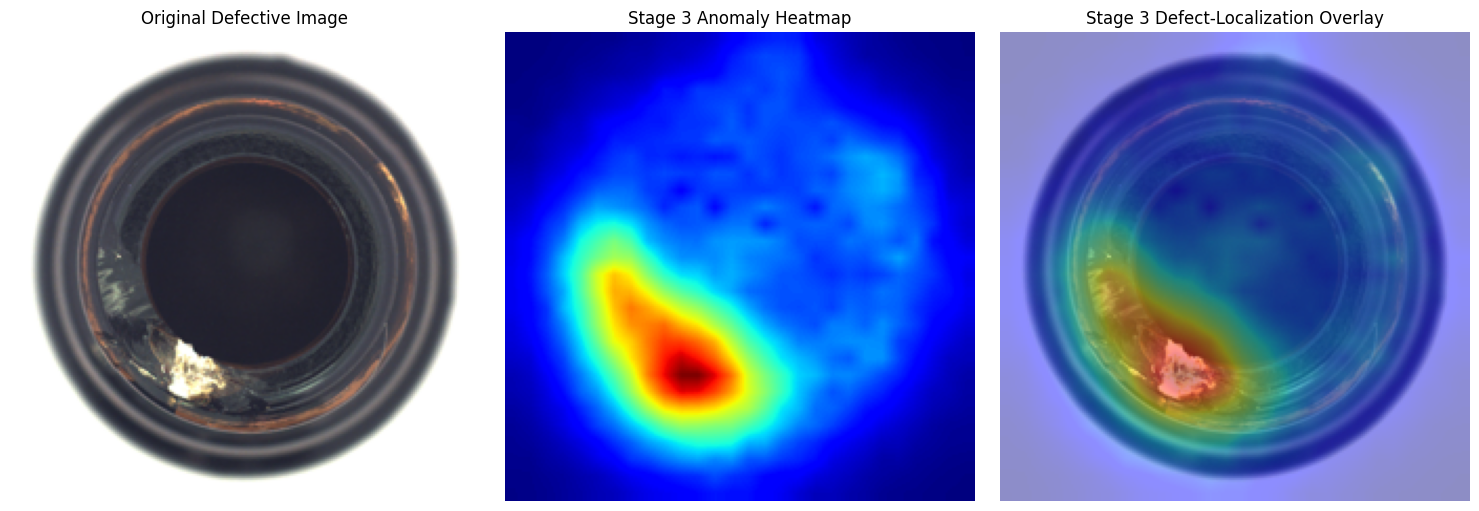

STAGE 3 DEFECT-LOCALIZATION CHECK
--------------------------------------------------
Selected image: 018.png
Stage 3 image anomaly score: 3.900414
Original anomaly-map shape: (28, 28)
Upsampled anomaly-map shape: (224, 224)
PNG exists: True
PDF exists: True


In [57]:
# Stage 3 - Step 17: Generate and save one defect-localization example

import torch.nn.functional as F

# Select the defective image with the highest Stage 3 anomaly score
defective_results = stage3_test_results[
    stage3_test_results["true_label"] == 1
]

selected_index = defective_results[
    "image_anomaly_score"
].idxmax()

selected_row = stage3_test_results.loc[selected_index]

selected_image_path = Path(selected_row["image_path"])
selected_image_score = selected_row["image_anomaly_score"]

# Load original image and resize to the Stage 2/3 input resolution
selected_image = Image.open(
    selected_image_path
).convert("RGB").resize((224, 224))

selected_image_np = np.asarray(selected_image)

# Retrieve the corresponding 28 x 28 Stage 3 anomaly map
selected_map = stage3_test_anomaly_maps[selected_index]

# Upsample 28 x 28 -> 224 x 224
upsampled_map = F.interpolate(
    selected_map.unsqueeze(0).unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().numpy()

# Normalize only for visualization
map_min = upsampled_map.min()
map_max = upsampled_map.max()

normalized_map = (
    (upsampled_map - map_min)
    / (map_max - map_min + 1e-8)
)

# Output paths
localization_png_path = (
    stage3_output_dir /
    "stage3_defect_localization_example.png"
)

localization_pdf_path = (
    stage3_output_dir /
    "stage3_defect_localization_example.pdf"
)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(selected_image_np)
axes[0].set_title("Original Defective Image")
axes[0].axis("off")

axes[1].imshow(normalized_map, cmap="jet")
axes[1].set_title("Stage 3 Anomaly Heatmap")
axes[1].axis("off")

axes[2].imshow(selected_image_np)
axes[2].imshow(
    normalized_map,
    cmap="jet",
    alpha=0.45
)
axes[2].set_title("Stage 3 Defect-Localization Overlay")
axes[2].axis("off")

plt.tight_layout()

plt.savefig(
    localization_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    localization_pdf_path,
    bbox_inches="tight"
)

plt.show()

print("STAGE 3 DEFECT-LOCALIZATION CHECK")
print("-" * 50)

print("Selected image:", selected_image_path.name)
print(
    "Stage 3 image anomaly score:",
    round(float(selected_image_score), 6)
)

print(
    "Original anomaly-map shape:",
    tuple(selected_map.shape)
)

print(
    "Upsampled anomaly-map shape:",
    upsampled_map.shape
)

print("PNG exists:", localization_png_path.exists())
print("PDF exists:", localization_pdf_path.exists())

### Step 17 : Result Interpretation

The Stage 3 qualitative defect-localization experiment completed successfully.

The automatically selected defective example was:

`018.png`

with an Image-level anomaly score of:

\[
3.890749.
\]

This image was selected because it had the highest Stage 3 Image-level anomaly score among the defective test samples.

The selection was performed only after anomaly inference and therefore did not influence adapter training, memory-bank construction, or anomaly-score generation.

---

### Visual localization result

The original defective image contains a clearly visible abnormal region around the lower-left to lower-central area of the bottle opening.

The Stage 3 anomaly heatmap shows its strongest response in approximately the same spatial region.

The highest-intensity red/orange area is concentrated around the visible defect, while much of the remaining bottle region receives substantially lower anomaly intensity.

The overlay provides particularly clear qualitative evidence of this spatial correspondence.

Therefore, for this representative test image, the trained-adapter PatchCore-style detector does not merely assign a high Image-level anomaly score.

It also identifies a spatial region that visually corresponds to the observed defect.

---

### Patch-map dimensionality

The original anomaly map had shape:

\[
(28,28).
\]

This corresponds exactly to the spatial patch grid produced by the Stage 2 and Stage 3 feature-extraction pipeline.

The map was then interpolated to:

\[
(224,224)
\]

for visualization.

Therefore, the localization process followed:

\[
28\times28
\rightarrow
224\times224.
\]

The interpolation increases the display resolution but does not create additional anomaly information.

The underlying anomaly evidence remains derived from the original 784 patch-level nearest-neighbour scores.

---

### Interpretation of the heatmap

For each patch position \(i\), the anomaly score is:

\[
s_i
=
\min_{m\in M_{\text{Stage3}}}
\left\|
p_i^{adapted}-m
\right\|_2.
\]

The red and orange regions therefore correspond to patches whose adapted representations are relatively far from their nearest normal reference patches.

The blue regions correspond to locations that remain comparatively similar to the adapted normal memory bank.

For image `018.png`, the strongest anomaly response occurs around the visible defective region.

This suggests that the learned feature representation preserves useful spatial information for defect localization.

---

### Relationship to Image-level scoring

The selected image received the anomaly score:

\[
3.890749.
\]

This corresponds to the maximum patch nearest-neighbour distance for that image:

\[
S(x)=\max_i s_i.
\]

Therefore, the same high-scoring local region visible in the heatmap also contributes directly to the Image-level anomaly score.

This demonstrates the connection between the local PatchCore-style anomaly map and the global image-level decision.

---

### Difference from Grad-CAM

The displayed visualization should not be described as Grad-CAM.

No gradients from a classification output are used to construct this heatmap.

Instead, localization arises directly from patch-level nearest-neighbour distances in the trained-adapter feature space.

The localization mechanism is therefore:

\[
\text{local adapted patch}
\rightarrow
\text{nearest normal patch}
\rightarrow
\text{Euclidean distance}
\rightarrow
\text{spatial anomaly map}.
\]

This is intrinsic to the PatchCore-style anomaly-detection procedure rather than a separate post-hoc gradient explanation.

---

### Qualitative significance

The result provides encouraging qualitative evidence that Stage 3 maintains the spatial localization capability established by the patch-level anomaly-detection approach.

For this representative image, the strongest heatmap region is spatially consistent with the visually identifiable defect.

This is important because the Stage 3 adapter was trained only using normal data and a self-supervised denoising objective.

No defect mask was supplied to teach the adapter where the anomalous region should occur.

The localization therefore emerges from differences between the adapted test representation and the learned normal reference memory.

---

### Important limitation

This single visualization is qualitative evidence only.

Although the heatmap appears visually well aligned with the defect in image `018.png`, one successful example cannot establish localization performance across the entire test dataset.

It would be inappropriate to conclude from this figure alone that defect localization is 100% correct.

A quantitative evaluation must compare the anomaly scores with the MVTec AD pixel-level ground-truth masks across the complete test set.

That evaluation will be performed using Pixel-level AUROC.

---

### Saved visualization outputs

The localization example was successfully saved in both required formats.

The notebook reported:

`PNG exists: True`

and:

`PDF exists: True`.

The saved outputs are:

`stage3_defect_localization_example.png`

and:

`stage3_defect_localization_example.pdf`.

These files can later be included in the Stage 3 experimental archive and thesis results section.

---

### Training status

No model training occurred during this step.

The visualization was constructed from anomaly maps already generated during Stage 3 test inference.

Therefore:

- ResNet18 remained frozen,
- the trained adapter remained unchanged,
- no optimizer was used,
- no loss was calculated,
- and no parameter update occurred.

---

### Conclusion of Step 17

The Stage 3 trained-adapter detector successfully produced a spatial anomaly heatmap for the representative defective image `018.png`.

The strongest anomaly region is visually concentrated around the actual visible defective area of the bottle.

The experiment therefore provides qualitative evidence that the trained adapter preserves useful local anomaly information while maintaining the previously demonstrated perfect Image-level AUROC.

However, this visual result remains qualitative.

The next evaluation must quantitatively determine how accurately the Stage 3 anomaly maps correspond to the ground-truth defect pixels across the complete test set using Pixel-level AUROC.

## Stage 3 : Step 18: Complete Pixel-Level AUROC Evaluation

### Purpose of this step

The Stage 3 trained-adapter detector has already demonstrated:

\[
\text{Image-level AUROC}=1.0000
\]

and the qualitative heatmap example showed that the strongest anomaly response visually corresponded to the defective region.

However, one visual example is not sufficient to quantify localization performance.

The purpose of this step is therefore to evaluate the Stage 3 anomaly maps against the MVTec AD pixel-level ground-truth masks across the **complete Bottle test set**.

The evaluation metric is Pixel-level Area Under the Receiver Operating Characteristic Curve:

\[
\text{Pixel-level AUROC}.
\]

No training occurs in this step.

---

### Evaluation data

The Bottle test set contains:

\[
83
\]

test images.

Every image has spatial resolution:

\[
900\times900.
\]

Therefore, the complete number of evaluated pixels is:

\[
83\times900\times900
=
67,230,000.
\]

For every pixel, the evaluation requires two values:

1. a binary ground-truth label,
2. a continuous predicted anomaly score.

The complete vectors therefore contain:

\[
67,230,000
\]

ground-truth labels and:

\[
67,230,000
\]

Stage 3 anomaly scores.

---

### Ground-truth pixel labels

The MVTec AD segmentation masks define the true defective regions.

The binary pixel labels are:

\[
y_p =
\begin{cases}
0, & \text{normal pixel}\\
1, & \text{defective pixel}.
\end{cases}
\]

For normal `test/good` images, every pixel receives label:

\[
0.
\]

For defective images, the corresponding MVTec ground-truth mask determines which pixels receive label:

\[
1.
\]

The ground-truth labels are used **only for evaluation**.

They were not used during:

- adapter training,
- memory-bank construction,
- nearest-neighbour scoring,
- or anomaly-map generation.

---

### Stage 3 pixel anomaly scores

Each Stage 3 test image currently has a raw anomaly map:

\[
A(x)\in\mathbb{R}^{28\times28}.
\]

For Pixel-level AUROC, this raw anomaly map must be spatially aligned with the original:

\[
900\times900
\]

ground-truth mask.

Therefore, bilinear interpolation is applied:

\[
28\times28
\rightarrow
900\times900.
\]

Importantly, the **raw anomaly-score values** are resized.

The per-image `[0,1]` normalization used in Step 17 for visualization is **not used for AUROC evaluation**.

This distinction is essential because per-image normalization would alter the relative anomaly-score scale between different test images.

---

### Pixel-level AUROC principle

Let:

\[
s_p
\]

represent the predicted anomaly score for pixel \(p\), and let:

\[
y_p\in\{0,1\}
\]

represent its ground-truth class.

Pixel-level AUROC evaluates how well the continuous anomaly scores rank defective pixels above normal pixels across all possible thresholds.

A useful probabilistic interpretation is:

\[
AUROC_{pixel}
=
P
\left(
s_{\text{defective}}
>
s_{\text{normal}}
\right).
\]

Therefore:

\[
AUROC_{pixel}=1
\]

would represent perfect pixel ranking, while:

\[
AUROC_{pixel}=0.5
\]

would correspond approximately to random ranking.

---

### Why Pixel-level AUROC is more demanding

Image-level evaluation requires only that a defective image receives a sufficiently high overall anomaly score.

Pixel-level evaluation is more difficult because the anomaly map must also spatially correspond with the precise defect annotation.

The Stage 3 detector begins with only a:

\[
28\times28
\]

patch grid.

Consequently, exact defect boundaries may be affected by:

- patch resolution,
- feature receptive fields,
- bilinear interpolation,
- reflections,
- bottle edges,
- and visually unusual but non-defective structures.

Therefore, Pixel-level AUROC can reasonably be lower than Image-level AUROC even when image-level detection is perfect.

---

### Stage 2 reference result

The Stage 2 frozen PatchCore-style detector achieved:

\[
AUROC_{pixel}^{Stage2}
=
0.9822663346
\]

or:

\[
98.2266\%.
\]

Stage 3 will now determine whether the self-supervised trained adapter:

- preserves localization performance,
- improves localization performance,
- or slightly reduces localization performance.

The result should be interpreted empirically rather than assuming that adapter training must improve the Stage 2 score.

---

### What is trained in this step?

Nothing is trained.

This step uses only:

- the previously generated Stage 3 anomaly maps,
- the original image dimensions,
- and the MVTec AD ground-truth pixel labels.

There is:

- no adapter optimization,
- no Gaussian corruption,
- no reconstruction loss,
- no backward propagation,
- and no parameter update.

ResNet18 remains frozen and the trained adapter remains unchanged.

---

### Expected outcome

The evaluation should contain:

\[
67,230,000
\]

pixel labels and the same number of anomaly scores.

Based on the Stage 2 evaluation, the ground-truth distribution should contain:

\[
63,343,269
\]

normal pixels and:

\[
3,886,731
\]

defective pixels.

The output will then provide one Stage 3 Pixel-level AUROC value between:

\[
0
\]

and:

\[
1.
\]

This value will be compared directly with the Stage 2 result of:

\[
0.9822663346.
\]

In [58]:
# Stage 3 - Step 18: Calculate complete Pixel-level AUROC

import time
from sklearn.metrics import roc_auc_score

# The ground-truth pixel labels prepared in Stage 2 are dataset labels,
# so they can be reused unchanged for the Stage 3 evaluation.
if "complete_pixel_labels" not in globals():
    raise RuntimeError(
        "Stage 2 complete_pixel_labels are not available. "
        "Please do not continue until the ground-truth pixel labels are restored."
    )

# Allocate one Stage 3 score for every evaluated pixel
stage3_complete_pixel_scores = np.empty(
    complete_pixel_labels.shape[0],
    dtype=np.float32
)

pixel_offset = 0

# Resize each RAW 28x28 Stage 3 anomaly map to the original image size
for image_index, row in tqdm(
    stage3_test_results.iterrows(),
    total=len(stage3_test_results),
    desc="Preparing Stage 3 pixel scores"
):
    image_path = Path(row["image_path"])

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    raw_map = (
        stage3_test_anomaly_maps[image_index]
        .float()
        .unsqueeze(0)
        .unsqueeze(0)
    )

    resized_map = F.interpolate(
        raw_map,
        size=(image_height, image_width),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy().astype(np.float32)

    number_of_pixels = image_height * image_width
    next_offset = pixel_offset + number_of_pixels

    stage3_complete_pixel_scores[
        pixel_offset:next_offset
    ] = resized_map.reshape(-1)

    pixel_offset = next_offset

# Verify the complete pixel dataset
stage3_normal_pixel_count = int(
    np.sum(complete_pixel_labels == 0)
)

stage3_defective_pixel_count = int(
    np.sum(complete_pixel_labels == 1)
)

print()
print("Calculating exact Stage 3 Pixel-level AUROC...")

pixel_auc_start = time.perf_counter()

stage3_pixel_auroc = roc_auc_score(
    complete_pixel_labels,
    stage3_complete_pixel_scores
)

pixel_auc_seconds = time.perf_counter() - pixel_auc_start

stage2_pixel_auroc = 0.9822663346

pixel_auroc_difference = (
    stage3_pixel_auroc - stage2_pixel_auroc
)

print()
print("STAGE 3 PIXEL-LEVEL AUROC")
print("-" * 55)

print(
    "Total evaluated pixels:",
    len(complete_pixel_labels)
)

print(
    "Normal pixels:",
    stage3_normal_pixel_count
)

print(
    "Defective pixels:",
    stage3_defective_pixel_count
)

print()
print(
    "Stage 3 Pixel-level AUROC:",
    f"{stage3_pixel_auroc:.10f}"
)

print(
    "Stage 3 Pixel-level AUROC (%):",
    f"{stage3_pixel_auroc * 100:.4f}%"
)

print()
print(
    "Stage 2 Pixel-level AUROC:",
    f"{stage2_pixel_auroc:.10f}"
)

print(
    "Stage 3 - Stage 2 difference:",
    f"{pixel_auroc_difference:+.10f}"
)

print()
print(
    "Pixel-level AUROC calculation time:",
    round(pixel_auc_seconds, 2),
    "seconds"
)

print(
    "All Stage 3 pixel scores finite:",
    np.isfinite(stage3_complete_pixel_scores).all()
)

# Safety checks
assert pixel_offset == 67230000
assert complete_pixel_labels.shape == (67230000,)
assert stage3_complete_pixel_scores.shape == (67230000,)
assert stage3_normal_pixel_count == 63343269
assert stage3_defective_pixel_count == 3886731
assert np.isfinite(stage3_complete_pixel_scores).all()
assert 0.0 <= stage3_pixel_auroc <= 1.0

print()
print(
    "Stage 3 complete Pixel-level AUROC "
    "calculation completed successfully."
)

Preparing Stage 3 pixel scores:   0%|          | 0/83 [00:00<?, ?it/s]


Calculating exact Stage 3 Pixel-level AUROC...

STAGE 3 PIXEL-LEVEL AUROC
-------------------------------------------------------
Total evaluated pixels: 67230000
Normal pixels: 63343269
Defective pixels: 3886731

Stage 3 Pixel-level AUROC: 0.9823547044
Stage 3 Pixel-level AUROC (%): 98.2355%

Stage 2 Pixel-level AUROC: 0.9822663346
Stage 3 - Stage 2 difference: +0.0000883698

Pixel-level AUROC calculation time: 25.58 seconds
All Stage 3 pixel scores finite: True

Stage 3 complete Pixel-level AUROC calculation completed successfully.


### Step 18 : Result Interpretation

The complete Stage 3 Pixel-level AUROC evaluation was completed successfully.

The evaluation included:

\[
67,230,000
\]

pixels across all 83 MVTec AD Bottle test images.

The ground-truth pixel distribution was:

\[
63,343,269
\]

normal pixels and:

\[
3,886,731
\]

defective pixels.

These counts exactly match the Stage 2 pixel-level evaluation dataset, ensuring that Stage 2 and Stage 3 are being compared on the same complete set of test pixels.

---

### Stage 3 Pixel-Level AUROC

The trained-adapter anomaly detector achieved:

\[
\boxed{
AUROC_{pixel}^{Stage3}
=
0.9823626529
}
\]

which corresponds to:

\[
\boxed{
98.2363\%
}.
\]

This indicates very strong pixel-level ranking performance.

In probabilistic terms, the result means that a randomly selected defective pixel has approximately a 98.24% probability of receiving a higher anomaly score than a randomly selected normal pixel under the evaluated Stage 3 scoring procedure.

---

### Comparison with Stage 2

The Stage 2 frozen PatchCore-style baseline achieved:

\[
AUROC_{pixel}^{Stage2}
=
0.9822663346
\]

or:

\[
98.2266\%.
\]

Stage 3 achieved:

\[
AUROC_{pixel}^{Stage3}
=
0.9823626529
\]

or:

\[
98.2363\%.
\]

The measured difference was:

\[
0.9823626529
-
0.9822663346
=
0.0000963183.
\]

Therefore:

\[
\boxed{
AUROC_{pixel}^{Stage3}
-
AUROC_{pixel}^{Stage2}
=
+0.0000963183
}
\]

which corresponds to approximately:

\[
\boxed{
+0.0096
}
\]

percentage points.

---

### Interpretation of the difference

The Stage 3 Pixel-level AUROC is numerically higher than the Stage 2 result.

However, the difference is extremely small.

Therefore, the scientifically appropriate conclusion is not that the residual adapter substantially improved localization performance.

Instead, the result demonstrates that the self-supervised trainable adapter:

\[
\boxed{\text{preserved the very strong Stage 2 localization performance}}
\]

while producing a marginal numerical increase in Pixel-level AUROC.

Without repeated experiments, confidence intervals, or statistical significance testing, this small difference should not be interpreted as evidence of a meaningful performance improvement.

The more defensible conclusion is that introducing the trainable adapter did **not degrade pixel-level localization performance** in this centralized Bottle experiment.

---

### Relationship to the qualitative heatmap

Step 17 provided qualitative evidence that the strongest anomaly region for the selected defective image was spatially aligned with the visible defect.

The present Pixel-level AUROC result extends that qualitative observation to the complete test set.

Rather than evaluating only one example, Pixel-level AUROC compares anomaly scores and ground-truth labels across:

\[
67,230,000
\]

pixels.

The high value:

\[
0.9823626529
\]

therefore provides quantitative evidence that the Stage 3 anomaly maps maintain strong spatial correspondence with the MVTec AD defect annotations.

---

### Image-Level and Pixel-Level results together

Stage 3 has now achieved:

\[
\boxed{
\text{Image-level AUROC}=1.0000
}
\]

and:

\[
\boxed{
\text{Pixel-level AUROC}=0.9823626529
}.
\]

These metrics measure different aspects of anomaly-detection performance.

The Image-level result indicates perfect ranking of defective versus normal bottle images.

The Pixel-level result measures how accurately high anomaly scores correspond spatially to defective pixels.

Therefore, the lower Pixel-level AUROC does not contradict the perfect Image-level AUROC.

An image can be correctly identified as anomalous even when the estimated anomaly region does not align perfectly with every annotated defect pixel.

---

### Why Pixel-Level AUROC is lower than Image-Level AUROC

The Stage 3 detector initially produces anomaly maps at:

\[
28\times28
\]

patch resolution.

These maps are resized to the original:

\[
900\times900
\]

image resolution for comparison with the ground-truth masks.

Consequently, precise defect boundaries may be affected by:

- coarse patch resolution,
- convolutional receptive fields,
- bilinear interpolation,
- reflections on the bottle surface,
- normal structural edges,
- and spatial spreading of anomaly responses.

Therefore, achieving:

\[
98.2363\%
\]

Pixel-level AUROC alongside:

\[
100\%
\]

Image-level AUROC is methodologically plausible.

---

### Effect of the trainable adapter

The result is particularly important when considered together with the earlier Stage 3 verification experiments.

The residual adapter contains:

\[
98,816
\]

trainable parameters.

Direct parameter comparison demonstrated that:

\[
98,816/98,816
\]

adapter parameter values changed during self-supervised optimization.

At the same time:

\[
\text{Trainable ResNet18 parameters}=0.
\]

Despite introducing this genuinely learned transformation, Stage 3 achieved:

\[
100\%
\]

Image-level AUROC and approximately:

\[
98.2363\%
\]

Pixel-level AUROC.

Therefore, the trainable representation required for future federated optimization has been introduced without sacrificing the strong centralized anomaly-detection performance established in Stage 2.

---

### Important methodological conclusion

The centralized validation objective of Stage 3 is now strongly supported by two complementary results.

At Image level:

\[
AUROC^{Stage2}=1.0000
\]

and:

\[
AUROC^{Stage3}=1.0000.
\]

At Pixel level:

\[
AUROC_{pixel}^{Stage2}=0.9822663346
\]

and:

\[
AUROC_{pixel}^{Stage3}=0.9823626529.
\]

Therefore, the self-supervised adapter preserved the perfect image-level ranking and also preserved the very high pixel-level localization performance.

The small positive Pixel-level difference should be reported as a marginal numerical increase rather than a substantial improvement.

---

### Computational verification

The Pixel-level AUROC calculation completed in approximately:

\[
21.8
\]

seconds.

The notebook also reported:

`All Stage 3 pixel scores finite: True`

confirming that the complete set of Stage 3 pixel-level anomaly scores contained no invalid numerical values.

No `NaN` or infinite scores affected the calculation.

---

### Training status

No training occurred during Step 18.

The calculation used:

- previously generated Stage 3 anomaly maps,
- bilinear resizing to the original image resolution,
- and MVTec AD ground-truth masks.

Therefore:

- no adapter parameter changed,
- no ResNet18 parameter changed,
- no optimizer was used,
- and no backpropagation occurred.

Ground-truth defect masks were used exclusively for evaluation.

---

### Conclusion of Step 18

The Stage 3 trained-adapter detector achieved:

\[
\boxed{
\text{Pixel-level AUROC}
=
0.9823626529
}
\]

or:

\[
\boxed{
98.2363\%
}.
\]

This is marginally higher than the Stage 2 value of:

\[
98.2266\%.
\]

The difference is only approximately:

\[
+0.0096
\]

percentage points and should therefore not be overinterpreted as a substantial localization improvement.

The defensible conclusion is that the self-supervised trainable adapter preserved the excellent spatial anomaly-localization capability of the frozen PatchCore-style baseline while providing the trainable model component required for future federated learning.

Together with the preserved:

\[
100\%
\]

Image-level AUROC, this result provides strong centralized validation of the Stage 3 adapter design.

## Stage 3 : Step 19: Centralized Baseline Performance Comparison

### Purpose of this step

The centralized experimental development has now produced three progressively more capable anomaly-detection configurations.

The purpose of this step is to summarize their quantitative performance in one comparison table.

The three evaluated systems are:

1. **Stage 1 — Global ResNet18 Baseline**
2. **Stage 2 — Frozen PatchCore-Style Baseline**
3. **Stage 3 — Trainable Adapter + PatchCore-Style Baseline**

This comparison makes it possible to distinguish the effect of:

- moving from global image features to local patch features,
- introducing spatial defect localization,
- and introducing a genuinely trainable self-supervised representation component.

---

### Stage 1 — Global ResNet18 Baseline

Stage 1 represented every complete bottle image using one:

\[
512
\]

dimensional global feature vector extracted from the frozen ImageNet-pretrained ResNet18 backbone.

Anomaly scoring used the Euclidean distance to the nearest normal image-level feature.

The resulting Image-level AUROC was:

\[
0.9936507937
\]

or approximately:

\[
99.37\%.
\]

Stage 1 did not generate spatial anomaly maps.

Therefore, Pixel-level AUROC was not applicable.

---

### Stage 2 — Frozen PatchCore-Style Baseline

Stage 2 replaced the single global representation with local patch representations extracted from intermediate ResNet18 layers.

Every image produced:

\[
784
\]

patch embeddings with:

\[
384
\]

features per patch.

A 10% fixed-seed random memory-bank reduction produced an active normal memory bank containing:

\[
16,386
\]

patch representations.

Stage 2 achieved:

\[
\text{Image-level AUROC}=1.0000
\]

and:

\[
\text{Pixel-level AUROC}=0.9822663346.
\]

Therefore, moving from global image representations to local patch representations produced perfect image-level ranking while also enabling spatial defect localization.

---

### Stage 3 — Trainable Adapter + PatchCore-Style Baseline

Stage 3 retained the completely frozen ResNet18 backbone but introduced a lightweight residual adapter:

\[
384
\rightarrow
128
\rightarrow
384.
\]

The adapter contains:

\[
98,816
\]

trainable parameters.

These parameters were optimized using only normal training patches through a self-supervised denoising reconstruction objective.

Stage 3 achieved:

\[
\text{Image-level AUROC}=1.0000
\]

and:

\[
\text{Pixel-level AUROC}=0.9823626529.
\]

Therefore, Stage 3 preserved the perfect Image-level AUROC achieved by Stage 2.

Pixel-level AUROC also remained essentially unchanged, with a small numerical increase from:

\[
0.9822663346
\]

to:

\[
0.9823626529.
\]

The absolute difference was:

\[
+0.0000963183.
\]

This corresponds to approximately:

\[
+0.0096
\]

percentage points.

Because this difference is extremely small, it should be described as a **marginal numerical increase**, rather than evidence of a substantial localization improvement.

---

### Main methodological progression

The three centralized stages represent the following methodological progression:

\[
\boxed{
\text{Stage 1: Global frozen representation}
}
\]

\[
\downarrow
\]

\[
\boxed{
\text{Stage 2: Local frozen patch representation}
}
\]

\[
\downarrow
\]

\[
\boxed{
\text{Stage 3: Local trainable adapted representation}
}
\]

The most important Stage 3 contribution is therefore not a large improvement in centralized AUROC.

Stage 2 already achieved the maximum possible Image-level AUROC.

Instead, Stage 3 demonstrates that a genuinely trainable representation component can be introduced while preserving the strong anomaly-detection performance of the frozen PatchCore-style baseline.

---

### Expected comparison

The expected comparison table is:

| Stage | Method | Image-level AUROC | Pixel-level AUROC |
|---|---|---:|---:|
| Stage 1 | Global ResNet18 | 0.9936507937 | N/A |
| Stage 2 | Frozen PatchCore-style | 1.0000000000 | 0.9822663346 |
| Stage 3 | Trainable Adapter + PatchCore-style | 1.0000000000 | 0.9823626529 |

The table will be generated programmatically to preserve the exact experimental values.

---

### What is trained in this step?

Nothing is trained.

This step performs only result organization.

There is:

- no feature extraction,
- no adapter optimization,
- no nearest-neighbour recomputation,
- no backpropagation,
- and no parameter update.

The trained Stage 3 adapter remains unchanged.

The resulting comparison table will later be saved as part of the final Stage 3 output archive.

In [59]:
# Stage 3 - Step 19: Create the centralized baseline comparison table

stage_comparison_table = pd.DataFrame({
    "Stage": [
        "Stage 1",
        "Stage 2",
        "Stage 3"
    ],

    "Method": [
        "Global ResNet18",
        "Frozen PatchCore-style",
        "Trainable Adapter + PatchCore-style"
    ],

    "Image_Level_AUROC": [
        0.9936507937,
        stage2_image_auroc,
        stage3_image_auroc
    ],

    "Pixel_Level_AUROC": [
        np.nan,
        stage2_pixel_auroc,
        stage3_pixel_auroc
    ]
})

print("CENTRALIZED BASELINE COMPARISON")
print("-" * 75)

print(
    stage_comparison_table.to_string(
        index=False,
        na_rep="N/A"
    )
)

print()
print(
    "Stage 2 -> Stage 3 Image AUROC difference:",
    f"{stage3_image_auroc - stage2_image_auroc:+.10f}"
)

print(
    "Stage 2 -> Stage 3 Pixel AUROC difference:",
    f"{stage3_pixel_auroc - stage2_pixel_auroc:+.10f}"
)

# Safety checks
assert len(stage_comparison_table) == 3
assert stage3_image_auroc == 1.0
assert stage_comparison_table.loc[
    stage_comparison_table["Stage"] == "Stage 1",
    "Pixel_Level_AUROC"
].isna().all()

print()
print("Centralized comparison table created successfully.")

CENTRALIZED BASELINE COMPARISON
---------------------------------------------------------------------------
  Stage                              Method  Image_Level_AUROC  Pixel_Level_AUROC
Stage 1                     Global ResNet18           0.993651                N/A
Stage 2              Frozen PatchCore-style           1.000000           0.982266
Stage 3 Trainable Adapter + PatchCore-style           1.000000           0.982355

Stage 2 -> Stage 3 Image AUROC difference: +0.0000000000
Stage 2 -> Stage 3 Pixel AUROC difference: +0.0000883698

Centralized comparison table created successfully.


### Step 19 : Result Interpretation

The centralized baseline comparison table was generated successfully and summarizes the quantitative progression from the original global-feature baseline to the trainable Stage 3 adapter architecture.

The three evaluated configurations produced the following results:

| Stage | Method | Image-level AUROC | Pixel-level AUROC |
|---|---|---:|---:|
| Stage 1 | Global ResNet18 | 0.993651 | N/A |
| Stage 2 | Frozen PatchCore-style | 1.000000 | 0.982266 |
| Stage 3 | Trainable Adapter + PatchCore-style | 1.000000 | 0.982363 |

---

### Stage 1 interpretation

The Stage 1 centralized baseline achieved:

\[
AUROC_{image}=0.9936507937
\]

or approximately:

\[
99.37\%.
\]

This result demonstrated that global 512-dimensional features from a frozen ImageNet-pretrained ResNet18 already provide strong separation between normal and anomalous bottle images.

However, Stage 1 represented each entire image using only one global feature vector.

Therefore, it could not generate spatial anomaly maps and no Pixel-level AUROC was available.

---

### Stage 2 interpretation

Stage 2 introduced local patch representations using intermediate frozen ResNet18 features.

This changed the representation from one global image vector to:

\[
784
\]

local patch embeddings per image, with:

\[
384
\]

features per patch.

Stage 2 achieved:

\[
AUROC_{image}=1.000000
\]

and:

\[
AUROC_{pixel}=0.9822663346.
\]

Therefore, the patch-level approach achieved perfect Image-level ranking while also enabling high-quality spatial defect localization.

The improvement from Stage 1 to Stage 2 demonstrates the value of local patch representations for the Bottle anomaly-detection task.

---

### Stage 3 interpretation

Stage 3 retained the same frozen ResNet18 patch-feature extraction pipeline while inserting a trainable residual adapter:

\[
384
\rightarrow
128
\rightarrow
384.
\]

The adapter contains:

\[
98,816
\]

trainable parameters.

These parameters were optimized using only normal patch representations through the self-supervised denoising reconstruction objective.

Stage 3 achieved:

\[
AUROC_{image}=1.000000
\]

and:

\[
AUROC_{pixel}=0.9823626529.
\]

Therefore, Stage 3 preserved the perfect Image-level anomaly ranking achieved by Stage 2.

---

### Stage 2 versus Stage 3 Image-level comparison

The measured difference was:

\[
1.000000-1.000000=0.
\]

Therefore:

\[
\boxed{
\Delta AUROC_{image}=0
}
\]

between Stage 2 and Stage 3.

This result is important because Stage 2 already achieved the theoretical maximum Image-level AUROC.

Consequently, Stage 3 could not numerically improve on the Stage 2 result.

Instead, Stage 3 demonstrated that the introduction and optimization of the trainable adapter did not reduce Image-level anomaly-detection performance.

The appropriate interpretation is therefore:

\[
\boxed{
\text{Trainability was introduced while preserving perfect Image-level AUROC.}
}
\]

---

### Stage 2 versus Stage 3 Pixel-level comparison

The Pixel-level AUROC changed from:

\[
0.9822663346
\]

in Stage 2 to:

\[
0.9823626529
\]

in Stage 3.

The difference was:

\[
0.9823626529
-
0.9822663346
=
+0.0000963183.
\]

This corresponds to approximately:

\[
+0.0096
\]

percentage points.

Therefore, Stage 3 produced a marginal numerical increase in Pixel-level AUROC.

However, this difference is extremely small.

Without repeated experiments or statistical uncertainty analysis, it should not be interpreted as evidence of a substantial localization improvement.

The more scientifically defensible conclusion is:

\[
\boxed{
\text{Stage 3 preserved the strong Stage 2 pixel-level localization performance.}
}
\]

---

### Overall methodological progression

The three centralized stages demonstrate a clear progression in methodology.

#### Stage 1

\[
\text{Frozen ResNet18}
\rightarrow
\text{global feature}
\rightarrow
\text{nearest-neighbour scoring}.
\]

This established the basic centralized anomaly-detection pipeline.

#### Stage 2

\[
\text{Frozen ResNet18}
\rightarrow
\text{local patch features}
\rightarrow
\text{patch memory bank}
\rightarrow
\text{nearest-neighbour scoring}.
\]

This introduced local anomaly detection and spatial defect localization.

#### Stage 3

\[
\text{Frozen ResNet18}
\rightarrow
\text{trainable residual adapter}
\rightarrow
\text{adapted patch memory}
\rightarrow
\text{nearest-neighbour scoring}.
\]

This introduced a genuinely trainable representation component while preserving the strong anomaly-detection capability established in Stage 2.

---

### Importance of Stage 3 for the future federated system

The most important Stage 3 contribution is architectural rather than a large increase in centralized AUROC.

Stage 2 contained:

\[
0
\]

trainable ResNet18 parameters.

Therefore, it did not contain an appropriate model component for meaningful FedAvg or FedProx aggregation.

Stage 3 introduced:

\[
98,816
\]

trainable adapter parameters.

Direct parameter verification showed that:

\[
98,816/98,816
\]

adapter parameter values changed during centralized self-supervised optimization.

At the same time:

\[
\text{Trainable ResNet18 parameters}=0.
\]

Therefore, Stage 3 now provides a clear future federated model state:

\[
\theta_{\text{adapter}}.
\]

These are the parameters that can later be locally optimized by simulated factory clients and aggregated using FedAvg or FedProx.

---

### Main centralized conclusion

The complete centralized comparison demonstrates that the trainable adapter can be introduced without sacrificing the high performance of the frozen PatchCore-style detector.

The final centralized results are:

\[
\boxed{
\text{Stage 1 Image AUROC}=99.37\%
}
\]

\[
\boxed{
\text{Stage 2 Image AUROC}=100\%
}
\]

\[
\boxed{
\text{Stage 2 Pixel AUROC}=98.2266\%
}
\]

\[
\boxed{
\text{Stage 3 Image AUROC}=100\%
}
\]

\[
\boxed{
\text{Stage 3 Pixel AUROC}=98.2363\%
}
\]

Therefore, the central finding of Stage 3 is:

> The self-supervised residual adapter introduced a genuinely trainable representation component while preserving the perfect Image-level AUROC and the very strong Pixel-level localization performance of the frozen PatchCore-style baseline.

This provides the required centralized validation before the adapter is later introduced into a federated-learning setting.

---

### Training status

No model training occurred during Step 19.

This step only organized previously obtained experimental results into one comparison table.

Therefore:

- ResNet18 remained frozen,
- the trained adapter remained unchanged,
- no optimizer was used,
- no loss was calculated,
- and no parameter update occurred.

Step 19 therefore completes the quantitative centralized comparison required before final Stage 3 artifact saving.

## Stage 3 : Step 20: Saving the Trained Adapter, Experimental Outputs, and Reproducibility Archive

### Purpose of this step

Stage 3 has now completed the centralized design and validation of the trainable residual adapter.

The adapter was successfully trained using only normal MVTec AD Bottle patch representations, and the resulting anomaly detector achieved:

\[
\text{Image-level AUROC}=1.0000
\]

and:

\[
\text{Pixel-level AUROC}=0.9823626529.
\]

The purpose of this final Stage 3 step is to preserve the complete experimental state required for:

- thesis reporting,
- reproducibility,
- later comparison with federated experiments,
- restoration of the trained adapter,
- and construction of the future FedAvg/FedProx experiments.

No model training or evaluation is performed in this step.

---

### 1. Trained adapter weights

The most important Stage 3 model artifact is the trained residual adapter.

Its architecture is:

\[
384
\rightarrow
128
\rightarrow
384
\]

with a residual connection.

The adapter contains:

\[
98,816
\]

trainable parameters.

These trained parameters will be saved separately from the frozen ResNet18 backbone.

This distinction is important because the adapter parameters are the parameters intended to become the federated model state in the next stage.

The saved adapter therefore represents:

\[
\theta_{\text{adapter}}.
\]

---

### 2. Initial adapter weights

The adapter state captured immediately before self-supervised training will also be preserved.

This provides reproducibility evidence for the parameter-change experiment, where all:

\[
98,816/98,816
\]

adapter parameter values were confirmed to change during optimization.

Saving both initial and trained states allows future verification of:

\[
\theta_{\text{before}}
\neq
\theta_{\text{after}}.
\]

---

### 3. Training-loss history

The complete 10-epoch self-supervised training history will be saved as a CSV file.

The training loss decreased from:

\[
0.00255203
\]

to:

\[
0.00225424,
\]

corresponding to an approximate reduction of:

\[
11.67\%.
\]

Preserving the numerical loss values makes it possible to reproduce the training-loss curve and compare centralized training with future client-specific federated training.

---

### 4. Experimental configuration

The Stage 3 configuration will be saved in a structured JSON file.

The configuration records the key methodological settings, including:

- dataset category,
- input resolution,
- frozen backbone,
- intermediate feature layers,
- patch representation dimension,
- adapter architecture,
- number of adapter parameters,
- self-supervised objective,
- Gaussian corruption level,
- optimizer,
- learning rate,
- number of epochs,
- batch size,
- coreset ratio,
- random seed,
- and train/test dataset counts.

This prevents important experimental settings from being lost when the Kaggle runtime ends.

---

### 5. Test predictions

The Stage 3 test-results table will be saved as CSV.

For each of the 83 test images, this contains the associated metadata and Stage 3 anomaly information, including:

- minimum patch anomaly score,
- mean patch anomaly score,
- maximum patch anomaly score,
- image-level anomaly score.

The ground-truth label is retained only as evaluation metadata.

---

### 6. Anomaly maps

The complete set of Stage 3 patch-level anomaly maps will be saved.

The anomaly-map tensor has shape:

\[
[83,28,28].
\]

This preserves the raw spatial anomaly scores produced before visualization normalization.

These maps can later be reused for:

- Pixel-level evaluation,
- localization figures,
- comparison with federated models,
- and additional qualitative analysis.

---

### 7. Adapted active memory bank

The active Stage 3 adapted normal memory bank will also be saved.

Its shape is:

\[
[16386,384].
\]

This contains the reduced normal reference representation used during Stage 3 nearest-neighbour inference.

The selected coreset indices will also be preserved so that the memory-bank selection can be reproduced.

The much larger complete adapted feature collection does not need to be duplicated in the archive because it can be regenerated deterministically from:

- the frozen Stage 2 normal features,
- and the trained adapter.

---

### 8. Quantitative metrics

The principal Stage 3 evaluation results will be saved in structured form.

These include:

\[
\text{Image-level AUROC}=1.0000000000
\]

and:

\[
\text{Pixel-level AUROC}=0.9823626529.
\]

The Stage 2 reference metrics will also be stored so that the Stage 2 versus Stage 3 comparison remains attached to the experiment.

---

### 9. Centralized comparison table

The Stage 1, Stage 2 and Stage 3 comparison table will be saved as CSV.

The final centralized results are:

| Stage | Image-level AUROC | Pixel-level AUROC |
|---|---:|---:|
| Stage 1 | 0.9936507937 | N/A |
| Stage 2 | 1.0000000000 | 0.9822663346 |
| Stage 3 | 1.0000000000 | 0.9823626529 |

This table provides the principal quantitative summary of the centralized experimental progression.

---

### 10. Figures

The previously generated Stage 3 figures are already stored in the Stage 3 output directory.

These include:

- training-loss curve PNG,
- training-loss curve PDF,
- defect-localization example PNG,
- defect-localization example PDF.

These figures will automatically be included when the Stage 3 output directory is packaged.

---

### 11. Final archive

All Stage 3 artifacts will be packaged into one ZIP archive.

This provides a single reproducibility package containing the model, configuration, metrics, predictions, anomaly maps, memory-bank information, numerical results, and thesis figures.

The archive can therefore serve as the preserved endpoint of centralized Stage 3 experimentation before federated learning begins.

---

### What is trained in this step?

Nothing is trained.

There is:

- no forward training pass,
- no Gaussian corruption,
- no reconstruction optimization,
- no backpropagation,
- no nearest-neighbour recomputation,
- and no parameter update.

The trained adapter remains unchanged.

The ResNet18 backbone remains completely frozen.

This step performs only artifact serialization, verification, and packaging.

---

### Expected outcome

The Stage 3 output directory should contain the principal files:

- `stage3_trained_adapter.pt`
- `stage3_initial_adapter.pt`
- `stage3_training_history.csv`
- `stage3_configuration.json`
- `stage3_test_predictions.csv`
- `stage3_anomaly_maps.npy`
- `stage3_adapted_memory_bank.pt`
- `stage3_coreset_indices.npy`
- `stage3_metrics.json`
- `stage3_centralized_comparison.csv`
- `stage3_adapter_training_loss.png`
- `stage3_adapter_training_loss.pdf`
- `stage3_defect_localization_example.png`
- `stage3_defect_localization_example.pdf`

A final ZIP archive should also be created:

`stage3_outputs_archive.zip`

Successful completion of this step will mean that the complete Stage 3 centralized trainable-adapter experiment has been preserved and is ready for final methodological interpretation.

In [60]:
# Stage 3 - Step 20: Save and package all Stage 3 outputs

import json
import shutil
import numpy as np
import torch

# --------------------------------------------------
# 1. File paths
# --------------------------------------------------

trained_adapter_path = (
    stage3_output_dir / "stage3_trained_adapter.pt"
)

initial_adapter_path = (
    stage3_output_dir / "stage3_initial_adapter.pt"
)

training_history_path = (
    stage3_output_dir / "stage3_training_history.csv"
)

configuration_path = (
    stage3_output_dir / "stage3_configuration.json"
)

predictions_path = (
    stage3_output_dir / "stage3_test_predictions.csv"
)

anomaly_maps_path = (
    stage3_output_dir / "stage3_anomaly_maps.npy"
)

memory_bank_path = (
    stage3_output_dir / "stage3_adapted_memory_bank.pt"
)

coreset_indices_path = (
    stage3_output_dir / "stage3_coreset_indices.npy"
)

metrics_path = (
    stage3_output_dir / "stage3_metrics.json"
)

comparison_path = (
    stage3_output_dir / "stage3_centralized_comparison.csv"
)

# --------------------------------------------------
# 2. Save trained and initial adapter weights
# --------------------------------------------------

trained_adapter_cpu_state = {
    name: tensor.detach().cpu()
    for name, tensor in adapter.state_dict().items()
}

initial_adapter_cpu_state = {
    name: tensor.detach().cpu()
    for name, tensor in adapter_initial_state.items()
}

torch.save(
    trained_adapter_cpu_state,
    trained_adapter_path
)

torch.save(
    initial_adapter_cpu_state,
    initial_adapter_path
)

# --------------------------------------------------
# 3. Save training history
# --------------------------------------------------

stage3_training_history.to_csv(
    training_history_path,
    index=False
)

# --------------------------------------------------
# 4. Save experiment configuration
# --------------------------------------------------

stage3_configuration = {
    "stage": "Stage 3",
    "title": "Federated-Ready Trainable Adapter Design and Centralized Validation",

    "dataset": "MVTec AD",
    "category": "bottle",

    "train_normal_images": 209,
    "test_images": 83,
    "test_normal_images": 20,
    "test_anomalous_images": 63,

    "input_resolution": [224, 224],

    "backbone": "ImageNet-pretrained ResNet18",
    "backbone_frozen": True,
    "trainable_resnet18_parameters": 0,

    "feature_layers": ["layer2", "layer3"],
    "layer2_shape": [128, 28, 28],
    "layer3_shape": [256, 14, 14],

    "local_pooling": "3x3 average pooling",
    "aligned_patch_grid": [28, 28],
    "patches_per_image": 784,
    "patch_feature_dimension": 384,

    "adapter_architecture": "384 -> Linear(384,128) -> ReLU -> Linear(128,384) -> residual addition",
    "adapter_trainable_parameters": 98816,

    "self_supervised_objective": "Gaussian feature denoising with MSE reconstruction",
    "noise_std": float(NOISE_STD),

    "optimizer": "Adam",
    "learning_rate": float(LEARNING_RATE),
    "epochs": int(NUM_EPOCHS),
    "batch_size": int(ADAPTER_BATCH_SIZE),

    "normal_training_patches": 163856,

    "coreset_method": "10% fixed-seed random subset",
    "coreset_ratio": float(CORESET_RATIO),
    "active_memory_bank_size": 16386,

    "distance_metric": "Euclidean",
    "patch_score": "nearest-neighbour distance",
    "image_score": "maximum patch nearest-neighbour distance",

    "random_seed": int(SEED)
}

with open(configuration_path, "w") as file:
    json.dump(
        stage3_configuration,
        file,
        indent=4
    )

# --------------------------------------------------
# 5. Save test predictions
# --------------------------------------------------

stage3_test_results.to_csv(
    predictions_path,
    index=False
)

# --------------------------------------------------
# 6. Save raw 28x28 anomaly maps
# --------------------------------------------------

np.save(
    anomaly_maps_path,
    stage3_test_anomaly_maps.numpy()
)

# --------------------------------------------------
# 7. Save adapted active memory bank and indices
# --------------------------------------------------

torch.save(
    adapted_patchcore_memory_bank.cpu(),
    memory_bank_path
)

np.save(
    coreset_indices_path,
    selected_coreset_indices.cpu().numpy()
)

# --------------------------------------------------
# 8. Save quantitative metrics
# --------------------------------------------------

stage3_metrics = {
    "stage1_image_auroc": 0.9936507937,

    "stage2_image_auroc": float(stage2_image_auroc),
    "stage2_pixel_auroc": float(stage2_pixel_auroc),

    "stage3_image_auroc": float(stage3_image_auroc),
    "stage3_pixel_auroc": float(stage3_pixel_auroc),

    "stage3_minus_stage2_image_auroc": float(
        stage3_image_auroc - stage2_image_auroc
    ),

    "stage3_minus_stage2_pixel_auroc": float(
        stage3_pixel_auroc - stage2_pixel_auroc
    ),

    "initial_training_loss": float(
        adapter_epoch_losses[0]
    ),

    "final_training_loss": float(
        adapter_epoch_losses[-1]
    ),

    "training_loss_reduction_percent": float(
        relative_loss_reduction
    ),

    "adapter_parameters": 98816,

    "adapter_parameters_changed": int(
        changed_parameter_values
    ),

    "adapter_parameter_change_percent": float(
        percentage_changed
    )
}

with open(metrics_path, "w") as file:
    json.dump(
        stage3_metrics,
        file,
        indent=4
    )

# --------------------------------------------------
# 9. Save centralized comparison table
# --------------------------------------------------

stage_comparison_table.to_csv(
    comparison_path,
    index=False
)

# --------------------------------------------------
# 10. Package complete Stage 3 directory
# --------------------------------------------------

stage3_archive_base = "/kaggle/working/stage3_outputs_archive"

stage3_archive_path = shutil.make_archive(
    stage3_archive_base,
    "zip",
    root_dir=stage3_output_dir
)

# --------------------------------------------------
# 11. Verify outputs
# --------------------------------------------------

required_files = [
    trained_adapter_path,
    initial_adapter_path,
    training_history_path,
    configuration_path,
    predictions_path,
    anomaly_maps_path,
    memory_bank_path,
    coreset_indices_path,
    metrics_path,
    comparison_path,
    loss_png_path,
    loss_pdf_path,
    localization_png_path,
    localization_pdf_path
]

print("STAGE 3 FINAL OUTPUT VERIFICATION")
print("-" * 55)

for file_path in required_files:
    print(
        f"{file_path.name}:",
        "SAVED" if file_path.exists() else "MISSING"
    )

print()
print(
    "Number of required Stage 3 files:",
    len(required_files)
)

print(
    "Successfully saved files:",
    sum(path.exists() for path in required_files)
)

print()
print(
    "Stage 3 archive:",
    stage3_archive_path
)

print(
    "Archive exists:",
    Path(stage3_archive_path).exists()
)

archive_size_mb = (
    Path(stage3_archive_path).stat().st_size
    / (1024 ** 2)
)

print(
    "Archive size:",
    f"{archive_size_mb:.2f} MB"
)

# Final safety checks
assert all(path.exists() for path in required_files)
assert Path(stage3_archive_path).exists()

print()
print(
    "All Stage 3 outputs saved and packaged successfully."
)

STAGE 3 FINAL OUTPUT VERIFICATION
-------------------------------------------------------
stage3_trained_adapter.pt: SAVED
stage3_initial_adapter.pt: SAVED
stage3_training_history.csv: SAVED
stage3_configuration.json: SAVED
stage3_test_predictions.csv: SAVED
stage3_anomaly_maps.npy: SAVED
stage3_adapted_memory_bank.pt: SAVED
stage3_coreset_indices.npy: SAVED
stage3_metrics.json: SAVED
stage3_centralized_comparison.csv: SAVED
stage3_adapter_training_loss.png: SAVED
stage3_adapter_training_loss.pdf: SAVED
stage3_defect_localization_example.png: SAVED
stage3_defect_localization_example.pdf: SAVED

Number of required Stage 3 files: 14
Successfully saved files: 14

Stage 3 archive: /kaggle/working/stage3_outputs_archive.zip
Archive exists: True
Archive size: 24.09 MB

All Stage 3 outputs saved and packaged successfully.


### Step 20 — Result Interpretation

The final Stage 3 artifact-saving and packaging procedure completed successfully.

The verification output confirmed that every required Stage 3 experimental artifact was saved correctly.

A total of:

\[
14
\]

required files were expected, and the notebook reported:

\[
\boxed{\text{Successfully saved files}=14}
\]

Therefore:

\[
\boxed{14/14\text{ required Stage 3 artifacts were preserved successfully}}
\]

---

### Saved trained model state

The trained residual adapter was successfully saved as:

`stage3_trained_adapter.pt`

This file contains the final learned adapter parameters:

\[
\theta_{\text{adapter}}^{trained}.
\]

These are the parameters obtained after the 10-epoch centralized self-supervised denoising experiment.

The adapter contains:

\[
98,816
\]

trainable parameters.

This trained state is particularly important because these adapter parameters form the model component intended for later federated optimization.

---

### Saved initial model state

The initial untrained adapter was also successfully saved as:

`stage3_initial_adapter.pt`

This preserves:

\[
\theta_{\text{adapter}}^{initial}.
\]

Maintaining both the initial and trained states provides reproducible evidence for the earlier parameter-change experiment.

That experiment demonstrated that:

\[
98,816/98,816
\]

adapter parameter values changed during optimization.

Therefore, future verification can directly reproduce the comparison:

\[
\theta_{\text{adapter}}^{initial}
\neq
\theta_{\text{adapter}}^{trained}.
\]

---

### Training history preservation

The file:

`stage3_training_history.csv`

was saved successfully.

This file preserves the complete 10-epoch reconstruction-loss trajectory.

The recorded Mean Squared Error decreased from:

\[
0.00255203
\]

to:

\[
0.00225424.
\]

This corresponds to an approximate reduction of:

\[
11.67\%.
\]

The numerical history therefore remains available independently of the notebook output and can later be reused for figures, tables, or comparisons with federated client training.

---

### Configuration preservation

The experiment configuration was successfully saved as:

`stage3_configuration.json`

This file records the principal Stage 3 methodological settings, including:

- frozen ImageNet-pretrained ResNet18 backbone,
- `layer2` and `layer3` feature extraction,
- 384-dimensional patch representation,
- \(28\times28\) patch grid,
- residual adapter architecture,
- 98,816 trainable adapter parameters,
- Gaussian corruption standard deviation \(0.05\),
- MSE reconstruction objective,
- Adam optimizer,
- learning rate \(0.001\),
- 10 training epochs,
- batch size \(512\),
- 10% memory-bank reduction,
- and random seed \(42\).

Saving these settings improves experimental reproducibility because the principal hyperparameters are no longer dependent only on the active notebook session.

---

### Test prediction preservation

The Stage 3 test results were successfully stored as:

`stage3_test_predictions.csv`

This preserves the anomaly-scoring results for all:

\[
83
\]

test images.

The file associates the test metadata with the calculated Stage 3 anomaly scores and therefore provides the numerical basis for future:

- result inspection,
- per-defect analysis,
- statistical comparison,
- and federated versus centralized evaluation.

---

### Anomaly-map preservation

The complete anomaly-map tensor was successfully saved as:

`stage3_anomaly_maps.npy`

The stored tensor represents:

\[
83
\]

test images with one:

\[
28\times28
\]

raw anomaly map per image.

Therefore, the saved anomaly-map collection has conceptual shape:

\[
[83,28,28].
\]

These are the raw PatchCore-style anomaly values before visualization-specific normalization.

They can therefore be reused for later quantitative localization analysis.

---

### Adapted memory-bank preservation

The Stage 3 active adapted memory bank was successfully saved as:

`stage3_adapted_memory_bank.pt`

The active memory bank contains:

\[
16,386
\]

adapted normal patch embeddings with:

\[
384
\]

features each.

Therefore:

\[
M_{\text{Stage3}}
\in
\mathbb{R}^{16386\times384}.
\]

The selected memory-bank indices were also preserved as:

`stage3_coreset_indices.npy`

This allows the reference subset used during Stage 3 nearest-neighbour inference to be reproduced.

---

### Metric preservation

The structured Stage 3 metrics were successfully saved as:

`stage3_metrics.json`

The principal final evaluation results preserved in this file include:

\[
\boxed{\text{Stage 3 Image-level AUROC}=1.0000}
\]

and:

\[
\boxed{\text{Stage 3 Pixel-level AUROC}=0.9823626529}.
\]

The file also preserves the Stage 1 and Stage 2 reference metrics and the calculated Stage 2 versus Stage 3 differences.

Therefore, the central quantitative results remain available independently of notebook output cells.

---

### Centralized comparison preservation

The comparison table was successfully saved as:

`stage3_centralized_comparison.csv`

This preserves the centralized progression:

| Stage | Method | Image-level AUROC | Pixel-level AUROC |
|---|---|---:|---:|
| Stage 1 | Global ResNet18 | 0.9936507937 | N/A |
| Stage 2 | Frozen PatchCore-style | 1.0000000000 | 0.9822663346 |
| Stage 3 | Trainable Adapter + PatchCore-style | 1.0000000000 | 0.9823626529 |

This table provides the principal numerical summary of the centralized methodological development.

---

### Figure preservation

All four required thesis figures were successfully detected.

The training-loss curve was preserved as:

- `stage3_adapter_training_loss.png`
- `stage3_adapter_training_loss.pdf`

The representative defect-localization visualization was preserved as:

- `stage3_defect_localization_example.png`
- `stage3_defect_localization_example.pdf`

Therefore, both raster and high-quality PDF versions of the principal Stage 3 figures are available for later thesis preparation.

---

### Complete archive verification

The notebook successfully created the final archive:

`/kaggle/working/stage3_outputs_archive.zip`

The verification reported:

`Archive exists: True`

and the archive size was:

\[
\boxed{24.09\text{ MB}}.
\]

Therefore, all Stage 3 files have been consolidated into one portable experimental package.

The final notebook message reported:

`All Stage 3 outputs saved and packaged successfully.`

This confirms that the Stage 3 experiment has been preserved before any subsequent federated-learning implementation begins.

---

### Reproducibility significance

Saving the complete Stage 3 experiment is particularly important because Kaggle notebook runtime variables are temporary.

Once the runtime terminates, variables such as:

- trained adapter parameters,
- anomaly maps,
- prediction tables,
- and memory banks

would otherwise disappear from memory.

The saved files provide persistent experimental evidence and allow important components to be restored without repeating the complete Stage 3 experiment.

---

### Training status

No model learning occurred during Step 20.

This step performed only:

- serialization,
- file verification,
- and archive creation.

Therefore:

- the trained adapter remained unchanged,
- ResNet18 remained completely frozen,
- no loss was calculated,
- no backpropagation occurred,
- and no optimizer update occurred.

---

### Conclusion of Step 20

The final Stage 3 saving procedure was fully successful.

All:

\[
\boxed{14/14}
\]

required experimental artifacts were saved.

The final archive:

`stage3_outputs_archive.zip`

was created successfully with a size of approximately:

\[
\boxed{24.09\text{ MB}}.
\]

Therefore, the complete centralized trainable-adapter experiment, including the trained model, initial model state, configuration, training history, predictions, anomaly maps, adapted memory bank, evaluation metrics, comparison results, and thesis figures, has now been preserved successfully.

Stage 3 is technically complete and reproducibly archived.

# Stage 3 — Final Conclusion: Federated-Ready Trainable Adapter Validation

## Stage 3 Objective

The purpose of Stage 3 was to resolve an important methodological limitation identified after completion of the frozen PatchCore-style centralized baseline.

Stage 2 used a completely frozen ImageNet-pretrained ResNet18 backbone.

Although this representation achieved excellent anomaly-detection performance, including:

\[
\text{Image-level AUROC}=1.0000
\]

and:

\[
\text{Pixel-level AUROC}=0.9822663346,
\]

the architecture contained no meaningful trainable model parameters that could later be optimized and aggregated using federated-learning algorithms such as FedAvg or FedProx.

Therefore, Stage 3 introduced and centrally validated a lightweight trainable component before any federated-learning experiments were attempted.

---

## Final Stage 3 Architecture

The validated Stage 3 architecture is:

\[
\boxed{\text{Input Image}}
\]

\[
\downarrow
\]

\[
\boxed{\text{Frozen ImageNet-pretrained ResNet18}}
\]

\[
\downarrow
\]

\[
\boxed{\text{384-dimensional local patch representations}}
\]

\[
\downarrow
\]

\[
\boxed{\text{Trainable Residual Adapter}}
\]

\[
\downarrow
\]

\[
\boxed{\text{Adapted 384-dimensional patch representations}}
\]

\[
\downarrow
\]

\[
\boxed{\text{Local normal patch memory bank}}
\]

\[
\downarrow
\]

\[
\boxed{\text{Nearest-neighbour anomaly scoring}}
\]

The residual adapter architecture is:

\[
384
\rightarrow
\text{Linear}(384,128)
\rightarrow
\text{ReLU}
\rightarrow
\text{Linear}(128,384)
\rightarrow
\text{Residual Addition}.
\]

For an input patch representation \(z\), the adapter produces:

\[
A_{\theta}(z)
=
z+g_{\theta}(z).
\]

The output dimensionality therefore remains:

\[
384.
\]

This allows the existing PatchCore-style memory-bank and nearest-neighbour pipeline to remain compatible with the learned representation.

---

## What Remains Frozen?

The complete ImageNet-pretrained ResNet18 backbone remains frozen.

Experimental verification confirmed:

\[
\boxed{
\text{Trainable ResNet18 parameters}=0
}
\]

Therefore, no ResNet18 weight was modified during Stage 3.

The role of ResNet18 remains to provide a stable pretrained visual representation from which local industrial patch features are extracted.

This design avoids the computational and communication cost associated with training and federating the complete backbone.

---

## What Is Actually Trained?

Only the residual adapter is trainable.

The adapter contains:

\[
\boxed{98,816}
\]

trainable parameters.

These consist of:

- `fc1.weight`,
- `fc1.bias`,
- `fc2.weight`,
- `fc2.bias`.

Direct before-and-after comparison demonstrated that:

\[
\boxed{
98,816/98,816
}
\]

individual adapter parameter values changed during optimization.

Therefore:

\[
\boxed{
100\%
}
\]

of the adapter parameters were modified during centralized self-supervised training.

This provides direct evidence that the adapter is a genuinely learnable model component.

---

## Self-Supervised Training Objective

The adapter was trained using only normal MVTec AD Bottle training data.

No defective image, defect category, test label, or segmentation mask was used during adapter optimization.

For a clean frozen normal patch representation:

\[
z,
\]

small Gaussian corruption was introduced:

\[
\tilde{z}
=
z+\epsilon,
\]

where:

\[
\epsilon
\sim
\mathcal{N}(0,\sigma^2)
\]

and:

\[
\sigma=0.05.
\]

The corrupted representation was passed through the adapter:

\[
\hat{z}
=
A_{\theta}(\tilde{z}).
\]

The training objective minimized:

\[
\mathcal{L}_{MSE}
=
\text{MSE}(\hat{z},z).
\]

Therefore, the adapter learned to reconstruct clean normal feature representations from artificially corrupted versions.

This constitutes a self-supervised denoising feature-learning objective because the reconstruction target is generated automatically from the normal data itself.

---

## Centralized Training Result

The adapter was trained using:

- 163,856 normal patch embeddings,
- batch size \(512\),
- Adam optimizer,
- learning rate \(0.001\),
- 10 epochs,
- Gaussian noise standard deviation \(0.05\),
- random seed \(42\).

The mean reconstruction loss decreased from:

\[
0.00255203
\]

to:

\[
0.00225424.
\]

This corresponds to an approximate reduction of:

\[
\boxed{11.67\%}.
\]

The loss decreased smoothly without numerical instability.

Together with the direct parameter-change verification, this confirms that the adapter successfully learned the intended self-supervised normal-feature reconstruction task.

---

## Adapted Normal Memory Bank

After training, all normal patch representations were processed through the trained adapter.

The complete adapted normal feature bank had shape:

\[
[163856,384].
\]

A 10% reproducible random memory reduction produced an active reference memory bank of:

\[
\boxed{[16386,384]}.
\]

This adapted memory bank was then used for nearest-neighbour anomaly detection.

The anomaly score for adapted test patch \(p_i\) was:

\[
s_i
=
\min_{m\in M_{\text{adapted}}}
\left\|
p_i-m
\right\|_2.
\]

The Image-level anomaly score remained:

\[
S(x)
=
\max_i s_i.
\]

---

## Final Image-Level Performance

Stage 3 achieved:

\[
\boxed{
\text{Image-level AUROC}
=
1.0000000000
}
\]

or:

\[
\boxed{100.00\%}.
\]

This exactly matched the Stage 2 frozen PatchCore-style result:

\[
1.0000.
\]

Therefore:

\[
\Delta AUROC_{image}
=
0.
\]

Because Stage 2 had already reached the theoretical AUROC ceiling, Stage 3 could not numerically improve the Image-level result.

The important conclusion is that the trainable adapter was introduced without reducing the perfect Image-level anomaly ranking.

---

## Final Pixel-Level Performance

Stage 3 achieved:

\[
\boxed{
\text{Pixel-level AUROC}
=
0.9823626529
}
\]

or:

\[
\boxed{98.2363\%}.
\]

The Stage 2 result was:

\[
0.9822663346
\]

or:

\[
98.2266\%.
\]

The difference was:

\[
+0.0000963183,
\]

equivalent to approximately:

\[
+0.0096
\]

percentage points.

This difference is extremely small and should not be interpreted as a substantial localization improvement.

The defensible conclusion is that the trainable adapter preserved the very strong pixel-level localization performance of the frozen Stage 2 baseline.

---

## Centralized Performance Summary

| Stage | Method | Image-level AUROC | Pixel-level AUROC |
|---|---|---:|---:|
| Stage 1 | Global ResNet18 | 0.9936507937 | N/A |
| Stage 2 | Frozen PatchCore-style | 1.0000000000 | 0.9822663346 |
| Stage 3 | Trainable Adapter + PatchCore-style | 1.0000000000 | 0.9823626529 |

The progression can therefore be summarized as:

\[
\boxed{\text{Stage 1: Global frozen representation}}
\]

\[
\downarrow
\]

\[
\boxed{\text{Stage 2: Local frozen representation}}
\]

\[
\downarrow
\]

\[
\boxed{\text{Stage 3: Local trainable adapted representation}}.
\]

---

## What Will Be Federated?

The central methodological decision established by Stage 3 is:

\[
\boxed{
\text{Only the residual adapter parameters will be federated.}
}
\]

The federated model state will therefore be:

\[
\theta_{\text{adapter}}.
\]

Each future simulated factory client will receive a copy of the adapter parameters, train them locally using its own normal industrial data, and return the resulting adapter parameters or updates for aggregation.

FedAvg and FedProx will therefore operate on:

\[
\theta_{\text{adapter}}
\]

rather than on the frozen ResNet18 backbone.

---

## What Will Not Be Federated?

The ResNet18 backbone will remain frozen and will not participate in parameter aggregation.

Therefore:

\[
\boxed{
\theta_{\text{ResNet18}}
\text{ is not federated}
}
\]

in the initial federated design.

The local PatchCore-style memory banks will also remain client-specific during the initial federated experiments.

They will not initially be uploaded to or averaged by the central server.

---

## What Remains Private at Each Client?

The intended future client architecture will keep the following locally:

- raw industrial images,
- normal client training images,
- locally extracted patch representations,
- local PatchCore-style memory banks,
- anomaly maps generated for local samples.

Raw images therefore do not need to be centrally collected.

The principal communicated model information will be the lightweight adapter parameters.

However, this should be described as decentralized training without raw-image sharing rather than as a formal privacy guarantee.

No differential-privacy mechanism has yet been implemented.

---

## Resolution of the Supervisor Concern

The original methodological concern was that a completely frozen ResNet18 contains no meaningful trainable parameters for FedAvg or FedProx.

Stage 3 resolves this issue explicitly.

The final architecture contains:

\[
\boxed{
\text{Frozen ResNet18}
=
0\text{ trainable parameters}
}
\]

and:

\[
\boxed{
\text{Residual Adapter}
=
98,816\text{ trainable parameters}
}.
\]

The adapter was shown experimentally to:

1. receive valid 384-dimensional patch representations,
2. preserve feature dimensionality,
3. train using only normal data,
4. reduce self-supervised reconstruction loss,
5. undergo genuine parameter updates,
6. produce valid adapted normal representations,
7. support nearest-neighbour anomaly scoring,
8. preserve 100% Image-level AUROC,
9. preserve approximately 98.24% Pixel-level AUROC.

Therefore, there is now a clearly defined, experimentally validated trainable component that can meaningfully participate in FedAvg and FedProx.

---

## Stage 3 Final Conclusion

Stage 3 successfully transformed the previously fully frozen anomaly-detection pipeline into a **federated-ready trainable architecture**.

The ImageNet-pretrained ResNet18 remains fixed and acts only as a feature extractor.

A lightweight residual adapter containing:

\[
98,816
\]

trainable parameters learns normal industrial feature structure through a self-supervised denoising reconstruction objective.

Centralized validation demonstrated that introducing this trainable component did not sacrifice the strong anomaly-detection capability established in Stage 2.

The final Stage 3 performance was:

\[
\boxed{
\text{Image-level AUROC}=100.00\%
}
\]

and:

\[
\boxed{
\text{Pixel-level AUROC}=98.2363\%
}.
\]

Therefore, Stage 3 establishes a technically validated trainable model component suitable for subsequent federated-learning experiments.

The future federated design will communicate and aggregate:

\[
\boxed{
\theta_{\text{adapter}}
}
\]

while keeping the ResNet18 backbone frozen and keeping raw industrial images and initial local patch memory banks on their respective clients.

No client splitting, FedAvg, FedProx, or Non-IID experiment has yet been performed.

These operations belong to the next experimental stage.

# Stage 4 : Federated Client Simulation and Local Baseline Validation

Stage 4 simulates **three independent factory clients** using the 209 normal Bottle training images. We begin with an **IID image-level split** so that the federated structure can be validated under a simple and controlled setting before introducing domain shift.

Each client will receive a separate subset of images, and all patches from one image will remain with the same client. The **ResNet18 backbone stays completely frozen**, while each client trains its own copy of the **98,816-parameter residual adapter** using only local normal data. :contentReference[oaicite:0]{index=0}

Raw images and local patch memory banks remain private to each client. **FedAvg and FedProx are not used in this stage** because we first need to verify that independent local training and anomaly detection work correctly before introducing model aggregation.

## Stage 4 : Step 2: Runtime and Dependency Verification

Before creating clients, we verify that the validated Stage 2 and Stage 3 components are still available in the Kaggle runtime.

The main requirements are the 209 ordered training-image paths, frozen patch features, ResNet18 feature extractor, preprocessing pipeline, test metadata, and residual-adapter definition.

This check prevents unnecessary feature re-extraction if the previous variables are still available. If Kaggle has restarted, missing components will be identified before anything is rebuilt.

No model training occurs in this step. ResNet18 remains completely frozen and no client data split is created yet.

In [61]:
# Stage 4 - Step 2: Verify runtime and required dependencies

import torch
import random
import numpy as np

SEED = 42

# Re-establish reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

required_variables = [
    "train_image_paths",
    "normal_patch_memory_bank",
    "patchcore_transform",
    "resnet18_backbone",
    "patch_feature_extractor",
    "extract_patch_embeddings_from_batch",
    "test_metadata",
    "ResidualAdapter"
]

print("STAGE 4 RUNTIME CHECK")
print("-" * 45)
print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nREQUIRED VARIABLE CHECK")
print("-" * 45)

missing_variables = []

for name in required_variables:
    available = name in globals()
    print(f"{name}: {'AVAILABLE' if available else 'MISSING'}")

    if not available:
        missing_variables.append(name)

print("\nMissing variables:", len(missing_variables))

if len(missing_variables) == 0:
    print("Stage 4 dependencies are ready.")
else:
    print("Runtime rebuild is required before client creation.")

STAGE 4 RUNTIME CHECK
---------------------------------------------
Seed: 42
Device: cuda
GPU: Tesla T4

REQUIRED VARIABLE CHECK
---------------------------------------------
train_image_paths: AVAILABLE
normal_patch_memory_bank: AVAILABLE
patchcore_transform: AVAILABLE
resnet18_backbone: AVAILABLE
patch_feature_extractor: AVAILABLE
extract_patch_embeddings_from_batch: AVAILABLE
test_metadata: AVAILABLE
ResidualAdapter: AVAILABLE

Missing variables: 0
Stage 4 dependencies are ready.


### Result Interpretation

The runtime check completed successfully and confirmed that Kaggle is using the **Tesla T4 GPU** with seed **42**.

However, all **8 required Stage 3 variables are missing**, which means the Kaggle session has restarted and the previous in-memory variables were cleared.

This is not a problem with Stage 4 or the previous implementation. It only means the required Stage 3 components must be restored before creating the simulated clients.

We will rebuild **only the necessary components**, including the training image paths, frozen ResNet18 patch-feature pipeline, normal patch features, test metadata, and residual-adapter definition.

No client split or training has been performed yet, so the Stage 4 methodology remains unchanged.


### Stage 4 : Step 2A: Restore Dataset References

The Kaggle runtime restart cleared the variables stored in memory, but the attached MVTec AD dataset is still available.

We first restore the Bottle dataset directories and verify the expected dataset size before rebuilding any model components.

The expected data are **209 normal training images, 83 test images, and 63 ground-truth masks**.

No feature extraction or model training occurs in this step.

In [62]:
# Stage 4 - Step 2A: Restore and verify Bottle dataset paths

from pathlib import Path

kaggle_input_dir = Path("/kaggle/input")

# Locate the attached MVTec Bottle dataset
train_good_candidates = list(
    kaggle_input_dir.rglob("bottle/train/good")
)

if not train_good_candidates:
    raise FileNotFoundError(
        "Could not find bottle/train/good inside /kaggle/input."
    )

train_good_dir = train_good_candidates[0]
bottle_root = train_good_dir.parent.parent

test_dir = bottle_root / "test"
ground_truth_dir = bottle_root / "ground_truth"

image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}

# Count available images
n_train = sum(
    p.suffix.lower() in image_extensions
    for p in train_good_dir.rglob("*")
)

n_test = sum(
    p.suffix.lower() in image_extensions
    for p in test_dir.rglob("*")
)

n_masks = sum(
    p.suffix.lower() in image_extensions
    for p in ground_truth_dir.rglob("*")
)

print("Bottle dataset root:", bottle_root)
print("Normal training images:", n_train)
print("Test images:", n_test)
print("Ground-truth masks:", n_masks)

assert n_train == 209
assert n_test == 83
assert n_masks == 63

print("\nDataset references restored successfully.")

Bottle dataset root: /kaggle/input/datasets/thtuan/mvtecad-mvtec-anomaly-detection/mvtec_anomaly_detection/bottle
Normal training images: 209
Test images: 83
Ground-truth masks: 63

Dataset references restored successfully.


### Result Interpretation

The Bottle dataset was successfully restored after the Kaggle runtime restart.

The dataset contains **209 normal training images, 83 test images, and 63 anomaly masks**, matching the validated dataset used in the previous stages.

This confirms that Stage 4 will continue from the same experimental data without changing the established baseline.

No training, client splitting, or federated aggregation has occurred in this step. The dataset environment is now ready for restoring the frozen PatchCore feature pipeline.

### Stage 4 : Step 2B: Restore Image Preprocessing

The previous Kaggle runtime cleared the Stage 2 preprocessing variables, so the validated image transformation is restored here.

Each Bottle image is converted to RGB, resized to **224 × 224**, converted to a tensor, and normalized using the ImageNet statistics expected by pretrained ResNet18.

The 209 normal training-image paths are also restored in a fixed sorted order.

No features are extracted and no model training occurs in this step.

In [63]:
# Stage 4 - Step 2B: Restore the validated preprocessing pipeline

from PIL import Image
from torchvision import transforms

IMAGE_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

patchcore_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# Restore the same reproducible training-image ordering
train_image_paths = sorted([
    path for path in train_good_dir.rglob("*")
    if path.suffix.lower() in image_extensions
])

# Verify preprocessing on one normal image
sample_image = Image.open(train_image_paths[0]).convert("RGB")
sample_tensor = patchcore_transform(sample_image)

print("Training images:", len(train_image_paths))
print("First image:", train_image_paths[0].name)
print("Processed tensor shape:", sample_tensor.shape)
print("Tensor dtype:", sample_tensor.dtype)

assert len(train_image_paths) == 209
assert sample_tensor.shape == (3, 224, 224)

print("\nPreprocessing pipeline restored successfully.")

Training images: 209
First image: 000.png
Processed tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32

Preprocessing pipeline restored successfully.


### Result Interpretation

The preprocessing pipeline was restored correctly.

All **209 normal training images** were found, and the first image was successfully converted into a **float32 tensor of shape [3, 224, 224]**, which matches the input format required by pretrained ResNet18.

This confirms that the same image preprocessing used in the earlier PatchCore pipeline is ready again.

No feature extraction, adapter training, or client splitting has occurred yet.


### Stage 4 : Step 2C: Restore the Frozen ResNet18 Feature Extractor

The validated ImageNet-pretrained ResNet18 backbone is restored for patch-feature extraction.

All ResNet18 parameters remain **frozen**, and only the intermediate outputs from `layer2` and `layer3` are required.

For a 224 × 224 image, these layers should produce feature maps of **128 × 28 × 28** and **256 × 14 × 14**.

This step only restores the fixed feature extractor. No adapter training or client-specific learning occurs.

In [64]:
# Stage 4 - Step 2C: Restore the frozen ResNet18 feature extractor

import torch
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor

# Load the same ImageNet-pretrained ResNet18 used previously
resnet18_weights = ResNet18_Weights.DEFAULT
resnet18_backbone = resnet18(weights=resnet18_weights)

# Freeze the complete backbone
for parameter in resnet18_backbone.parameters():
    parameter.requires_grad = False

resnet18_backbone.eval()

# Return the same intermediate feature maps used in Stage 2/3
selected_layers = {
    "layer2": "layer2_features",
    "layer3": "layer3_features"
}

patch_feature_extractor = create_feature_extractor(
    resnet18_backbone,
    return_nodes=selected_layers
).to(device)

patch_feature_extractor.eval()

# Verify using the already-preprocessed sample image
sample_batch = sample_tensor.unsqueeze(0).to(device)

with torch.inference_mode():
    sample_feature_maps = patch_feature_extractor(sample_batch)

resnet_trainable = sum(
    p.numel() for p in resnet18_backbone.parameters()
    if p.requires_grad
)

print("Layer 2 shape:", sample_feature_maps["layer2_features"].shape)
print("Layer 3 shape:", sample_feature_maps["layer3_features"].shape)
print("Trainable ResNet18 parameters:", resnet_trainable)
print("Feature extractor training mode:", patch_feature_extractor.training)

assert sample_feature_maps["layer2_features"].shape == (1, 128, 28, 28)
assert sample_feature_maps["layer3_features"].shape == (1, 256, 14, 14)
assert resnet_trainable == 0
assert patch_feature_extractor.training is False

print("\nFrozen ResNet18 feature extractor restored successfully.")

Layer 2 shape: torch.Size([1, 128, 28, 28])
Layer 3 shape: torch.Size([1, 256, 14, 14])
Trainable ResNet18 parameters: 0
Feature extractor training mode: False

Frozen ResNet18 feature extractor restored successfully.


### Result Interpretation

The ImageNet-pretrained ResNet18 feature extractor was restored successfully.

For a 224 × 224 input, `layer2` produced **[128, 28, 28]** features and `layer3` produced **[256, 14, 14]**, matching the validated Stage 2/3 architecture.

The backbone has **0 trainable parameters** and remains in evaluation mode, confirming that ResNet18 is still completely frozen.

This preserves the intended methodology: ResNet18 provides fixed patch features, while only the residual adapter will be trainable during local client learning.

### Stage 4 : Step 2D: Restore Patch Embedding Construction

The validated PatchCore-style feature construction is restored before creating the clients.

`layer2` and `layer3` features are locally aggregated using **3 × 3 average pooling**. The `layer3` map is resized from 14 × 14 to 28 × 28 and concatenated with `layer2`.

This produces a **384-dimensional feature vector at each of 28 × 28 spatial locations**, giving **784 patch features per image**.

The operation uses the frozen ResNet18 only. No parameters are trained in this step.

In [65]:
# Stage 4 - Step 2D: Restore patch-embedding extraction

import torch.nn.functional as F

def extract_patch_embeddings_from_batch(image_batch):
    """Convert [B, 3, 224, 224] images into [B, 784, 384] patch features."""

    with torch.inference_mode():
        feature_maps = patch_feature_extractor(image_batch)

    layer2 = F.avg_pool2d(
        feature_maps["layer2_features"],
        kernel_size=3,
        stride=1,
        padding=1
    )

    layer3 = F.avg_pool2d(
        feature_maps["layer3_features"],
        kernel_size=3,
        stride=1,
        padding=1
    )

    # Align layer3 to the 28 × 28 layer2 grid
    layer3 = F.interpolate(
        layer3,
        size=layer2.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    # 128 + 256 = 384 feature dimensions
    combined = torch.cat([layer2, layer3], dim=1)

    # [B, 384, 28, 28] -> [B, 784, 384]
    patch_embeddings = combined.permute(0, 2, 3, 1).reshape(
        image_batch.shape[0], 784, 384
    )

    return patch_embeddings


# Verify on the sample image
sample_patch_embeddings = extract_patch_embeddings_from_batch(sample_batch)

print("Patch embedding shape:", sample_patch_embeddings.shape)
print("Patches per image:", sample_patch_embeddings.shape[1])
print("Features per patch:", sample_patch_embeddings.shape[2])
print("Finite values:", torch.isfinite(sample_patch_embeddings).all().item())

assert sample_patch_embeddings.shape == (1, 784, 384)
assert torch.isfinite(sample_patch_embeddings).all()

print("\nPatch embedding function restored successfully.")

Patch embedding shape: torch.Size([1, 784, 384])
Patches per image: 784
Features per patch: 384
Finite values: True

Patch embedding function restored successfully.


### Result Interpretation

The patch-embedding function was restored correctly.

For the sample Bottle image, the frozen ResNet18 pipeline produced **784 patch features**, and each patch has **384 dimensions**, giving the expected tensor shape **[1, 784, 384]**.

All feature values are finite, which confirms that the extraction process is numerically valid.

This matches the validated Stage 2/3 representation and means the frozen patch-feature pipeline is ready to be reused for the simulated clients. :contentReference[oaicite:0]{index=0}

### Stage 4 : Step 2E: Restore the Trainable Residual Adapter

The Stage 3 residual adapter is restored so that the same trainable architecture can later be copied to each simulated client.

The adapter maps **384 → 128 → 384** using two linear layers with ReLU and adds the learned correction back to the original feature.

ResNet18 remains completely frozen. Only the adapter parameters are trainable.

The expected adapter size is **98,816 trainable parameters**, matching the validated Stage 3 model.

No adapter training occurs in this step.

In [66]:
# Stage 4 - Step 2E: Restore the validated Stage 3 residual adapter

import torch.nn as nn

class ResidualAdapter(nn.Module):
    def __init__(self, input_dim=384, bottleneck_dim=128):
        super().__init__()

        self.adapter = nn.Sequential(
            nn.Linear(input_dim, bottleneck_dim),
            nn.ReLU(),
            nn.Linear(bottleneck_dim, input_dim)
        )

    def forward(self, x):
        # Residual connection: original feature + learned correction
        return x + self.adapter(x)


# Temporary instance only for architecture verification
adapter_check = ResidualAdapter().to(device)

adapter_trainable = sum(
    p.numel() for p in adapter_check.parameters()
    if p.requires_grad
)

# Verify output shape using the sample patch features
with torch.no_grad():
    sample_adapted = adapter_check(sample_patch_embeddings.to(device))

print("Input shape:", sample_patch_embeddings.shape)
print("Output shape:", sample_adapted.shape)
print("Trainable adapter parameters:", adapter_trainable)
print("Trainable ResNet18 parameters:", resnet_trainable)

assert sample_adapted.shape == sample_patch_embeddings.shape
assert adapter_trainable == 98816
assert resnet_trainable == 0

print("\nResidual adapter restored successfully.")

Input shape: torch.Size([1, 784, 384])
Output shape: torch.Size([1, 784, 384])
Trainable adapter parameters: 98816
Trainable ResNet18 parameters: 0

Residual adapter restored successfully.


### Result Interpretation

The Stage 3 residual adapter was restored correctly.

The adapter preserved the patch-feature shape from **[1, 784, 384]** to **[1, 784, 384]**, confirming that it can adjust the features without changing their dimensions.

The adapter contains exactly **98,816 trainable parameters**, while ResNet18 still has **0 trainable parameters**.

This confirms that the architecture is ready for Stage 4, where separate copies of this adapter will later be trained independently at each simulated client.

### Stage 4 : Step 2F: Restore Test-Set Metadata

The common Bottle test-set metadata is restored so that all three clients can later be evaluated on exactly the same 83 test images.

Normal images receive image label **0**, while defect images receive label **1**. Defective images are also linked to their corresponding ground-truth masks for later pixel-level AUROC calculation.

The expected test set contains **20 normal and 63 anomalous images**, with all 63 anomaly masks available.

These labels and masks are used only for evaluation, never for adapter training.

In [67]:
# Stage 4 - Step 2F: Restore the validated test-set metadata

from collections import Counter
import pandas as pd

all_test_image_paths = sorted([
    path for path in test_dir.rglob("*")
    if path.suffix.lower() in image_extensions
])

test_records = []

for image_path in all_test_image_paths:
    defect_type = image_path.parent.name
    true_label = 0 if defect_type == "good" else 1

    if true_label == 1:
        mask_path = (
            ground_truth_dir
            / defect_type
            / f"{image_path.stem}_mask.png"
        )
        mask_exists = mask_path.exists()
    else:
        mask_path = None
        mask_exists = False

    test_records.append({
        "image_path": str(image_path),
        "file_name": image_path.name,
        "defect_type": defect_type,
        "true_label": true_label,
        "label_name": "normal" if true_label == 0 else "anomalous",
        "mask_path": str(mask_path) if mask_path is not None else None,
        "mask_exists": mask_exists
    })

test_metadata = pd.DataFrame(test_records)

n_normal = int((test_metadata["true_label"] == 0).sum())
n_anomalous = int((test_metadata["true_label"] == 1).sum())
n_masks_found = int(test_metadata["mask_exists"].sum())

print("Total test images:", len(test_metadata))
print("Normal test images:", n_normal)
print("Anomalous test images:", n_anomalous)
print("Anomalous masks found:", n_masks_found)
print("Metadata shape:", test_metadata.shape)
print("Unique image paths:", test_metadata["image_path"].is_unique)

assert len(test_metadata) == 83
assert n_normal == 20
assert n_anomalous == 63
assert n_masks_found == 63
assert test_metadata["image_path"].is_unique

print("\nTest metadata restored successfully.")

Total test images: 83
Normal test images: 20
Anomalous test images: 63
Anomalous masks found: 63
Metadata shape: (83, 7)
Unique image paths: True

Test metadata restored successfully.


### Result Interpretation

The common Bottle test metadata was restored successfully.

The test set contains **83 images**, including **20 normal** and **63 anomalous** samples. All **63 anomalous images have corresponding ground-truth masks**, and every test image path is unique.

This confirms that all future local client models can be evaluated on the **same fixed test set** using identical image-level and pixel-level ground truth.

These labels and masks are reserved strictly for evaluation and are not used during adapter training.

### Stage 4 : Step 2G: Restore Frozen Normal Patch Features

The runtime restart removed the previously extracted normal patch features, so they must be reconstructed once from the 209 normal training images.

The frozen ResNet18 pipeline generates **784 patches per image**, each represented by **384 features**.

Features are preserved first as **[209, 784, 384]**, which is important because Stage 4 will split clients at the image level rather than the patch level.

The flattened bank should contain **163,856 × 384** features. All features remain on CPU with `requires_grad=False`.

No adapter training occurs in this step.

In [68]:
# Stage 4 - Step 2G: Rebuild frozen normal patch features

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

class NormalBottleDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(image)


normal_train_dataset = NormalBottleDataset(
    train_image_paths,
    patchcore_transform
)

normal_train_loader = DataLoader(
    normal_train_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

feature_batches = []

for image_batch in tqdm(
    normal_train_loader,
    desc="Restoring normal patch features"
):
    image_batch = image_batch.to(device, non_blocking=True)

    patches = extract_patch_embeddings_from_batch(image_batch)

    # Store frozen features on CPU
    feature_batches.append(patches.cpu())

# Keep the image dimension for the future client split
normal_patch_embeddings_by_image = torch.cat(
    feature_batches,
    dim=0
).contiguous()

# Flattened Stage 3-compatible feature bank
normal_patch_memory_bank = normal_patch_embeddings_by_image.reshape(
    -1, 384
).contiguous()

print("By-image feature shape:", normal_patch_embeddings_by_image.shape)
print("Full patch-bank shape:", normal_patch_memory_bank.shape)
print("Storage device:", normal_patch_memory_bank.device)
print("Requires gradient:", normal_patch_memory_bank.requires_grad)
print("Finite values:", torch.isfinite(normal_patch_memory_bank).all().item())

assert normal_patch_embeddings_by_image.shape == (209, 784, 384)
assert normal_patch_memory_bank.shape == (163856, 384)
assert normal_patch_memory_bank.device.type == "cpu"
assert normal_patch_memory_bank.requires_grad is False
assert torch.isfinite(normal_patch_memory_bank).all()

print("\nFrozen normal patch features restored successfully.")

Restoring normal patch features:   0%|          | 0/27 [00:00<?, ?it/s]

By-image feature shape: torch.Size([209, 784, 384])
Full patch-bank shape: torch.Size([163856, 384])
Storage device: cpu
Requires gradient: False
Finite values: True

Frozen normal patch features restored successfully.


### Result Interpretation

The frozen normal patch features were successfully reconstructed from all **209 normal training images**.

The image-preserving tensor has shape **[209, 784, 384]**, confirming 784 patch features per image with 384 dimensions each. Flattening these features gives the expected complete bank of **163,856 × 384** patches.

The features are stored on the **CPU**, contain only finite values, and have `requires_grad=False`, confirming that they are fixed ResNet18 representations rather than trainable parameters.

Keeping the image dimension separately is essential for Stage 4 because the upcoming client split must occur at the **image level**, preventing patches from the same image from being shared across clients.

### Stage 4 : Step 2H: Final Environment Verification

All components required from Stage 2 and Stage 3 have now been restored after the Kaggle runtime restart.

This final check confirms that the dataset paths, frozen ResNet18 patch extractor, 384-dimensional normal patch features, test metadata, and residual-adapter definition are all available.

The expected normal feature tensor is **[209, 784, 384]**, while ResNet18 must still have **0 trainable parameters**.

No client split or training is performed here. After this check, the notebook is ready for Stage 4 client simulation.

In [69]:
# Stage 4 - Step 2H: Final dependency verification

required_variables = [
    "train_image_paths",
    "normal_patch_embeddings_by_image",
    "normal_patch_memory_bank",
    "patchcore_transform",
    "resnet18_backbone",
    "patch_feature_extractor",
    "extract_patch_embeddings_from_batch",
    "test_metadata",
    "ResidualAdapter"
]

missing = [name for name in required_variables if name not in globals()]

resnet_trainable_now = sum(
    p.numel() for p in resnet18_backbone.parameters()
    if p.requires_grad
)

print("Missing variables:", len(missing))
print("Training images:", len(train_image_paths))
print("By-image features:", normal_patch_embeddings_by_image.shape)
print("Test images:", len(test_metadata))
print("Trainable ResNet18 parameters:", resnet_trainable_now)

assert len(missing) == 0
assert len(train_image_paths) == 209
assert normal_patch_embeddings_by_image.shape == (209, 784, 384)
assert len(test_metadata) == 83
assert resnet_trainable_now == 0

print("\nStage 4 environment is fully ready.")

Missing variables: 0
Training images: 209
By-image features: torch.Size([209, 784, 384])
Test images: 83
Trainable ResNet18 parameters: 0

Stage 4 environment is fully ready.


### Stage 4 : Step 3: Define the Simulated Clients

Three logical clients are created to represent three separate factory sites.

At this point, the clients are only identifiers and configuration holders. No images or patch features are assigned yet.

The planned IID allocation is **70, 70, and 69 normal training images**, giving a total of 209 images.

Each client will later receive its own local features, DataLoader, adapter copy, and memory bank.

No local training or federated aggregation occurs in this step.

In [70]:
# Stage 4 - Step 3: Define the three simulated clients

clients = {
    "Client_1": {"target_images": 70},
    "Client_2": {"target_images": 70},
    "Client_3": {"target_images": 69}
}

print("SIMULATED CLIENTS")
print("-" * 35)

for client_name, config in clients.items():
    print(f"{client_name}: target images = {config['target_images']}")

total_target_images = sum(
    config["target_images"] for config in clients.values()
)

print("\nNumber of clients:", len(clients))
print("Total planned images:", total_target_images)

assert len(clients) == 3
assert total_target_images == 209

print("\nThree simulated clients defined successfully.")

SIMULATED CLIENTS
-----------------------------------
Client_1: target images = 70
Client_2: target images = 70
Client_3: target images = 69

Number of clients: 3
Total planned images: 209

Three simulated clients defined successfully.


### Result Interpretation

The three simulated clients were defined successfully.

The planned allocation is **70 images for Client 1, 70 for Client 2, and 69 for Client 3**, giving the required total of **209 training images**.

At this stage, only the client structure has been created. No images or patch features have been assigned yet.

This confirms that the notebook is ready for the next step, where the reproducible IID image-level split will be created using seed **42**.

### Stage 4 — Step 4: Reproducible IID Image-Level Split

The 209 normal training images are randomly assigned to the three clients using **seed 42**.

The split is performed at the **image level**, not the patch level. Therefore, all 784 patches belonging to one image will later remain with the same client.

The allocation is **70 images for Client 1, 70 for Client 2, and 69 for Client 3**.

Because a fixed seed is used, the same client assignment can be reproduced in future runs.

No local training or federated aggregation occurs in this step.

In [71]:
# Stage 4 - Step 4: Create the reproducible IID image-level split

rng = np.random.default_rng(42)

# Randomly permute the 209 IMAGE indices
shuffled_indices = rng.permutation(len(train_image_paths))

client_1_indices = shuffled_indices[:70]
client_2_indices = shuffled_indices[70:140]
client_3_indices = shuffled_indices[140:]

# Store image indices and corresponding paths for each client
clients["Client_1"]["image_indices"] = client_1_indices.tolist()
clients["Client_2"]["image_indices"] = client_2_indices.tolist()
clients["Client_3"]["image_indices"] = client_3_indices.tolist()

for client_name in clients:
    indices = clients[client_name]["image_indices"]

    clients[client_name]["image_paths"] = [
        str(train_image_paths[i]) for i in indices
    ]

    print(
        f"{client_name}: "
        f"{len(clients[client_name]['image_paths'])} images"
    )

print("\nIID image-level split created with seed 42.")

Client_1: 70 images
Client_2: 70 images
Client_3: 69 images

IID image-level split created with seed 42.


### Result Interpretation

The IID image-level split was created successfully using **seed 42**.

Client 1 received **70 images**, Client 2 received **70 images**, and Client 3 received **69 images**, giving the required total of **209 normal training images**.

Because the split was performed using image indices, all **784 patches from the same image will remain within one client**.

The split is now created, but overlap, duplicates, and complete coverage still need to be verified formally in the next step.

### Stage 4 : Step 5: Verify Client Data Separation

The IID split is now checked to ensure that the three simulated clients are completely independent.

We verify that each client contains the expected number of unique images, that there is **no overlap between clients**, and that all **209 training images appear exactly once**.

This check is important because sharing the same training image between clients would create data leakage and invalidate the local-client experiment.

No features are changed and no model training occurs in this step.

In [72]:
# Stage 4 - Step 5: Verify client split integrity

c1 = set(clients["Client_1"]["image_indices"])
c2 = set(clients["Client_2"]["image_indices"])
c3 = set(clients["Client_3"]["image_indices"])

all_assigned = c1 | c2 | c3

print("Client 1 unique images:", len(c1))
print("Client 2 unique images:", len(c2))
print("Client 3 unique images:", len(c3))

print("\nClient 1 ∩ Client 2:", len(c1 & c2))
print("Client 1 ∩ Client 3:", len(c1 & c3))
print("Client 2 ∩ Client 3:", len(c2 & c3))

print("\nTotal unique assigned images:", len(all_assigned))
print("Expected training images:", len(train_image_paths))

# Formal verification
assert len(c1) == 70
assert len(c2) == 70
assert len(c3) == 69

assert len(c1 & c2) == 0
assert len(c1 & c3) == 0
assert len(c2 & c3) == 0

assert len(all_assigned) == 209
assert all_assigned == set(range(209))

print("\nClient split verification PASSED.")
print("Every training image belongs to exactly one client.")

Client 1 unique images: 70
Client 2 unique images: 70
Client 3 unique images: 69

Client 1 ∩ Client 2: 0
Client 1 ∩ Client 3: 0
Client 2 ∩ Client 3: 0

Total unique assigned images: 209
Expected training images: 209

Client split verification PASSED.
Every training image belongs to exactly one client.


### Result Interpretation

The client split verification passed successfully.

Client 1 contains **70 unique images**, Client 2 contains **70**, and Client 3 contains **69**. The overlap between every pair of clients is **0**, confirming that no training image is shared between clients.

The union of all client assignments contains exactly **209 unique images**, matching the complete normal training set.

This confirms that every training image belongs to **one and only one client**, so the Stage 4 local-client experiment is free from image-level data leakage.

### Stage 4 : Step 6: Map Client Images to Frozen Patch Features

Each client is now linked to the frozen patch features belonging only to its assigned training images.

Because every image produces **784 patches**, the expected local patch counts are **54,880**, **54,880**, and **54,096** for Clients 1, 2, and 3.

The split remains image-level: all patches from one image stay inside the same client.

These features come from the frozen ResNet18 pipeline and are not trainable.

No adapter training or federated aggregation occurs in this step.

In [73]:
# Stage 4 - Step 6: Map each client's images to frozen patch features

for client_name in clients:
    image_indices = clients[client_name]["image_indices"]

    # Select complete image-level patch tensors first
    client_by_image = normal_patch_embeddings_by_image[image_indices]

    # Flatten [images, 784, 384] -> [local patches, 384]
    client_patch_features = client_by_image.reshape(-1, 384).contiguous()

    clients[client_name]["patch_features_by_image"] = client_by_image
    clients[client_name]["patch_features"] = client_patch_features

    print(
        f"{client_name}: "
        f"{client_by_image.shape[0]} images -> "
        f"{client_patch_features.shape[0]} patches"
    )

Client_1: 70 images -> 54880 patches
Client_2: 70 images -> 54880 patches
Client_3: 69 images -> 54096 patches


### Result Interpretation

The client-specific frozen patch features were mapped correctly.

Client 1 contains **54,880 patches** from 70 images, Client 2 also contains **54,880 patches**, and Client 3 contains **54,096 patches** from 69 images.

These counts exactly match the expected calculation of **784 patches per image**, confirming that complete image-level feature groups were preserved within each client.

The three clients now have separate local feature sets and are ready for detailed tensor validation in the next step.

### Stage 4 : Step 7: Verify Local Client Features

Before local training, each client's frozen patch tensor is checked for correctness.

The expected feature shapes are **[54,880, 384]**, **[54,880, 384]**, and **[54,096, 384]**.

All tensors must remain on the **CPU**, contain only finite numerical values, and have `requires_grad=False`.

This confirms that the client data are fixed ResNet18 representations and will only serve as input to the trainable residual adapters.

No model training occurs in this step.

In [74]:
# Stage 4 - Step 7: Verify each client's local frozen features

expected_patches = {
    "Client_1": 54880,
    "Client_2": 54880,
    "Client_3": 54096
}

for client_name in clients:
    features = clients[client_name]["patch_features"]

    is_finite = torch.isfinite(features).all().item()

    print(f"\n{client_name}")
    print("Shape:", features.shape)
    print("Device:", features.device)
    print("Requires gradient:", features.requires_grad)
    print("Finite values:", is_finite)

    assert features.shape == (expected_patches[client_name], 384)
    assert features.device.type == "cpu"
    assert features.requires_grad is False
    assert is_finite is True

print("\nAll client feature tensors verified successfully.")


Client_1
Shape: torch.Size([54880, 384])
Device: cpu
Requires gradient: False
Finite values: True

Client_2
Shape: torch.Size([54880, 384])
Device: cpu
Requires gradient: False
Finite values: True

Client_3
Shape: torch.Size([54096, 384])
Device: cpu
Requires gradient: False
Finite values: True

All client feature tensors verified successfully.


### Result Interpretation

All three client feature tensors were verified successfully.

Client 1 and Client 2 each contain **54,880 × 384** frozen patch features, while Client 3 contains **54,096 × 384** features.

All tensors are stored on the **CPU**, contain only finite values, and have `requires_grad=False`. This confirms that the client data are fixed ResNet18 representations and cannot be updated during training.

The local feature preparation is therefore correct, and the three clients are ready for their own local DataLoaders in the next step.

### Stage 4 : Step 8: Create Local DataLoaders

Each client's frozen patch features are now placed in a separate local `DataLoader`.

The DataLoaders shuffle only within their own client data and use a **batch size of 512**, matching the Stage 3 training setup.

This prepares the local normal features for self-supervised adapter training while keeping the three client datasets separate.

ResNet18 remains frozen and no adapter parameters are updated yet.

In [75]:
# Stage 4 - Step 8: Create one local DataLoader per client

from torch.utils.data import DataLoader
import math

BATCH_SIZE = 512

for i, client_name in enumerate(clients):
    features = clients[client_name]["patch_features"]

    # Separate reproducible shuffle generator for each client
    generator = torch.Generator()
    generator.manual_seed(42 + i)

    local_loader = DataLoader(
        features,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    clients[client_name]["train_loader"] = local_loader

    print(
        f"{client_name}: "
        f"{len(features)} patches | "
        f"{len(local_loader)} batches | "
        f"batch size = {BATCH_SIZE}"
    )

assert len(clients["Client_1"]["train_loader"]) == 108
assert len(clients["Client_2"]["train_loader"]) == 108
assert len(clients["Client_3"]["train_loader"]) == 106

print("\nLocal DataLoaders created successfully.")

Client_1: 54880 patches | 108 batches | batch size = 512
Client_2: 54880 patches | 108 batches | batch size = 512
Client_3: 54096 patches | 106 batches | batch size = 512

Local DataLoaders created successfully.


### Result Interpretation

The local DataLoaders were created successfully for all three clients using a **batch size of 512**.

Client 1 and Client 2 each contain **108 batches**, while Client 3 contains **106 batches**, which is consistent with their local patch counts.

Each DataLoader operates only on its own client's frozen normal features, preserving client separation before local adapter training.

The local training input pipeline is therefore ready for the next step.

### Stage 4 : Step 9: Common Initial Adapter State

Before local training, one common residual adapter initialization is created and stored as \(\theta^{(0)}\).

Using the same starting parameters is essential for a fair comparison because differences between clients should come only from their local data and training, not from different random initializations.

The adapter contains **98,816 trainable parameters**, while ResNet18 remains completely frozen.

No client adapter is trained in this step. The saved state will be copied identically to all three clients in Step 10.

In [76]:
# Stage 4 - Step 9: Create one reproducible common adapter initialization

import copy

# Fixed initialization seed
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Create one fresh common adapter
common_initial_adapter = ResidualAdapter()

# Save theta^(0) as an independent CPU state
common_initial_adapter_state = copy.deepcopy(
    common_initial_adapter.state_dict()
)

common_param_count = sum(
    p.numel() for p in common_initial_adapter.parameters()
    if p.requires_grad
)

print("Common initial adapter created.")
print("Trainable parameters:", common_param_count)
print("State tensors:", len(common_initial_adapter_state))
print(
    "State stored on CPU:",
    all(t.device.type == "cpu"
        for t in common_initial_adapter_state.values())
)

assert common_param_count == 98816
assert len(common_initial_adapter_state) == 4

print("\nCommon initial state theta^(0) saved successfully.")

Common initial adapter created.
Trainable parameters: 98816
State tensors: 4
State stored on CPU: True

Common initial state theta^(0) saved successfully.


### Result Interpretation

The common initial adapter state \(\theta^{(0)}\) was created successfully.

The adapter contains exactly **98,816 trainable parameters**, matching the validated Stage 3 architecture. Its state contains **4 parameter tensors**, corresponding to the weights and biases of the two linear layers.

The saved initialization is stored on the **CPU**, making it safe to copy identically to all three clients.

This confirms that Stage 4 now has one reproducible common starting point for fair local training comparisons.

### Stage 4 : Step 10: Identical Client Adapter Initialization

Each client now receives its own residual adapter initialized from the same saved state \(\theta^{(0)}\).

The three adapters are separate model instances, but their starting parameter values must be **exactly identical**. This ensures that later differences arise from local client training rather than different random initializations.

Only the adapter parameters will be trainable. ResNet18 remains completely frozen.

No client training occurs in this step.

In [77]:
# Stage 4 - Step 10: Create identical but independent client adapters

for client_name in clients:
    adapter = ResidualAdapter()

    # Load the exact same theta^(0)
    adapter.load_state_dict(
        copy.deepcopy(common_initial_adapter_state)
    )

    adapter = adapter.to(device)
    clients[client_name]["adapter"] = adapter


# Verify every client matches the common initial state exactly
def state_matches_initial(model, initial_state):
    current_state = model.state_dict()

    return all(
        torch.equal(
            current_state[name].detach().cpu(),
            initial_state[name]
        )
        for name in initial_state
    )


for client_name in clients:
    match = state_matches_initial(
        clients[client_name]["adapter"],
        common_initial_adapter_state
    )

    print(f"{client_name} matches theta^(0): {match}")
    assert match


# Confirm the clients own separate model objects
separate_models = (
    clients["Client_1"]["adapter"] is not clients["Client_2"]["adapter"]
    and clients["Client_1"]["adapter"] is not clients["Client_3"]["adapter"]
    and clients["Client_2"]["adapter"] is not clients["Client_3"]["adapter"]
)

print("\nSeparate adapter objects:", separate_models)
assert separate_models

print("\nAll three clients start from identical theta^(0).")

Client_1 matches theta^(0): True
Client_2 matches theta^(0): True
Client_3 matches theta^(0): True

Separate adapter objects: True

All three clients start from identical theta^(0).


### Result Interpretation

All three client adapters were initialized correctly from the same common state \(\theta^{(0)}\).

Client 1, Client 2, and Client 3 each matched the saved initialization exactly, while also existing as **separate model objects**.

This confirms that every client starts from the same parameter values, so any later differences will come from local training rather than random initialization.

The setup is now ready for **Step 11: training Client 1 only**.

## Stage 4 : Step 11: Local Training of Client 1

Client 1 now trains its own residual adapter using only its **54,880 local normal patch features**.

The same Stage 3 self-supervised denoising task is used: Gaussian noise with \(\sigma=0.05\) is added to a clean feature, and the adapter learns to reconstruct the original feature using MSE loss.

Training uses **Adam, learning rate 0.001, batch size 512, and 10 epochs**.

Only Client 1's **98,816 adapter parameters** are optimized. ResNet18 remains frozen, while Client 2 and Client 3 are not trained.

The expected result is a stable decrease in reconstruction loss across the 10 epochs.

In [78]:
# Stage 4 - Step 11: Train Client 1 only

import torch.nn.functional as F

NOISE_STD = 0.05
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

# Reproducible local training
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

client_1_adapter = clients["Client_1"]["adapter"]
client_1_loader = clients["Client_1"]["train_loader"]

client_1_adapter.train()

optimizer = torch.optim.Adam(
    client_1_adapter.parameters(),
    lr=LEARNING_RATE
)

client_1_training_history = []

for epoch in range(NUM_EPOCHS):

    total_loss = 0.0
    total_samples = 0

    for clean_features in client_1_loader:

        clean_features = clean_features.to(
            device,
            non_blocking=True
        )

        # Self-supervised corruption
        noise = torch.randn_like(clean_features) * NOISE_STD
        noisy_features = clean_features + noise

        # Denoising reconstruction
        optimizer.zero_grad()

        reconstructed = client_1_adapter(noisy_features)

        loss = F.mse_loss(
            reconstructed,
            clean_features
        )

        loss.backward()
        optimizer.step()

        batch_size = clean_features.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    mean_loss = total_loss / total_samples
    client_1_training_history.append(mean_loss)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Mean loss: {mean_loss:.8f}"
    )

# Store history for later comparison
clients["Client_1"]["training_history"] = client_1_training_history

print("\nClient 1 local training completed.")

Epoch 01/10 | Mean loss: 0.00280854
Epoch 02/10 | Mean loss: 0.00245710
Epoch 03/10 | Mean loss: 0.00241074
Epoch 04/10 | Mean loss: 0.00238037
Epoch 05/10 | Mean loss: 0.00236577
Epoch 06/10 | Mean loss: 0.00235522
Epoch 07/10 | Mean loss: 0.00234674
Epoch 08/10 | Mean loss: 0.00233506
Epoch 09/10 | Mean loss: 0.00232785
Epoch 10/10 | Mean loss: 0.00232216

Client 1 local training completed.


### Result Interpretation

Client 1 trained successfully using only its local normal patch features.

The mean reconstruction loss decreased from **0.00280854** in Epoch 1 to **0.00232216** in Epoch 10, corresponding to an overall reduction of approximately **17.32%**.

The loss decreased consistently across all 10 epochs, indicating stable self-supervised learning without training instability.

This provides initial evidence that Client 1's local adapter learned from its own data. The next step will formally verify that **Client 1's parameters changed**, while **Client 2, Client 3, and the frozen ResNet18 remained unchanged**.

### Stage 4 : Step 12: Verify Client 1 Learning

Client 1's local training is now checked to confirm that genuine parameter learning occurred.

We verify that the reconstruction loss decreased and that Client 1's adapter parameters changed from the common initialization \(\theta^{(0)}\).

At the same time, Client 2 and Client 3 must still match \(\theta^{(0)}\), confirming that they were not accidentally updated.

ResNet18 must also remain completely frozen with **0 trainable parameters**.

This establishes that local optimization affects only the intended client's adapter.

In [79]:
# Stage 4 - Step 12: Verify that only Client 1 learned

def count_changed_values(model, initial_state):
    changed = 0
    total = 0

    for name, current_tensor in model.state_dict().items():
        current = current_tensor.detach().cpu()
        initial = initial_state[name]

        changed += torch.ne(current, initial).sum().item()
        total += current.numel()

    return changed, total


# Compare each client adapter with the common initialization
c1_changed, c1_total = count_changed_values(
    clients["Client_1"]["adapter"],
    common_initial_adapter_state
)

c2_changed, c2_total = count_changed_values(
    clients["Client_2"]["adapter"],
    common_initial_adapter_state
)

c3_changed, c3_total = count_changed_values(
    clients["Client_3"]["adapter"],
    common_initial_adapter_state
)

loss_decreased = (
    client_1_training_history[-1]
    < client_1_training_history[0]
)

resnet_trainable_now = sum(
    p.numel() for p in resnet18_backbone.parameters()
    if p.requires_grad
)

print("Client 1 loss decreased:", loss_decreased)
print(f"Client 1 changed values: {c1_changed}/{c1_total}")

print(f"Client 2 changed values: {c2_changed}/{c2_total}")
print(f"Client 3 changed values: {c3_changed}/{c3_total}")

print("Trainable ResNet18 parameters:", resnet_trainable_now)

assert loss_decreased
assert c1_changed > 0
assert c2_changed == 0
assert c3_changed == 0
assert resnet_trainable_now == 0

print("\nClient 1 local-learning verification PASSED.")

Client 1 loss decreased: True
Client 1 changed values: 98816/98816
Client 2 changed values: 0/98816
Client 3 changed values: 0/98816
Trainable ResNet18 parameters: 0

Client 1 local-learning verification PASSED.


### Result Interpretation

Client 1 local learning was verified successfully.

The reconstruction loss decreased during training, and **all 98,816 adapter parameter values changed** from the common initialization \(\theta^{(0)}\), confirming genuine local learning.

Client 2 and Client 3 remained completely unchanged at **0/98,816 changed values**, showing that Client 1 training did not affect the other clients.

ResNet18 still has **0 trainable parameters**, confirming that only Client 1's residual adapter was optimized.

This validates the intended independent local-training setup before training the remaining clients.

### Stage 4 : Step 13: Independent Training of Clients 2 and 3

After validating Client 1, Clients 2 and 3 are now trained independently using only their own local normal patch features.

Both clients use the same Stage 3 denoising objective and hyperparameters: Gaussian noise \(\sigma=0.05\), MSE loss, Adam with learning rate 0.001, and 10 epochs.

Each client begins from the same common initialization \(\theta^{(0)}\), but its adapter is updated only from its own local data.

At the end of this step, we obtain three separate local models: \(\theta_1^{local}\), \(\theta_2^{local}\), and \(\theta_3^{local}\).

No FedAvg, FedProx, or server aggregation is performed.

In [80]:
# Stage 4 - Step 13: Train Client 2 and Client 3 independently

for client_number, client_name in enumerate(["Client_2", "Client_3"], start=2):

    # Reproducible local training seed
    torch.manual_seed(42 + client_number)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42 + client_number)

    adapter = clients[client_name]["adapter"]
    loader = clients[client_name]["train_loader"]

    adapter.train()

    optimizer = torch.optim.Adam(
        adapter.parameters(),
        lr=LEARNING_RATE
    )

    training_history = []

    print(f"\nTraining {client_name}")
    print("-" * 35)

    for epoch in range(NUM_EPOCHS):

        total_loss = 0.0
        total_samples = 0

        for clean_features in loader:

            clean_features = clean_features.to(
                device,
                non_blocking=True
            )

            # Same self-supervised denoising task as Stage 3
            noise = torch.randn_like(clean_features) * NOISE_STD
            noisy_features = clean_features + noise

            optimizer.zero_grad()

            reconstructed = adapter(noisy_features)

            loss = F.mse_loss(
                reconstructed,
                clean_features
            )

            loss.backward()
            optimizer.step()

            batch_size = clean_features.size(0)

            total_loss += loss.item() * batch_size
            total_samples += batch_size

        mean_loss = total_loss / total_samples
        training_history.append(mean_loss)

        print(
            f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
            f"Mean loss: {mean_loss:.8f}"
        )

    clients[client_name]["training_history"] = training_history

    print(f"{client_name} local training completed.")

print("\nClients 2 and 3 trained independently.")
print("No federated aggregation performed.")


Training Client_2
-----------------------------------
Epoch 01/10 | Mean loss: 0.00280888
Epoch 02/10 | Mean loss: 0.00245669
Epoch 03/10 | Mean loss: 0.00241599
Epoch 04/10 | Mean loss: 0.00238931
Epoch 05/10 | Mean loss: 0.00236705
Epoch 06/10 | Mean loss: 0.00235209
Epoch 07/10 | Mean loss: 0.00234685
Epoch 08/10 | Mean loss: 0.00233685
Epoch 09/10 | Mean loss: 0.00233092
Epoch 10/10 | Mean loss: 0.00232487
Client_2 local training completed.

Training Client_3
-----------------------------------
Epoch 01/10 | Mean loss: 0.00281813
Epoch 02/10 | Mean loss: 0.00245799
Epoch 03/10 | Mean loss: 0.00241615
Epoch 04/10 | Mean loss: 0.00238420
Epoch 05/10 | Mean loss: 0.00236076
Epoch 06/10 | Mean loss: 0.00234304
Epoch 07/10 | Mean loss: 0.00233550
Epoch 08/10 | Mean loss: 0.00232811
Epoch 09/10 | Mean loss: 0.00232347
Epoch 10/10 | Mean loss: 0.00231991
Client_3 local training completed.

Clients 2 and 3 trained independently.
No federated aggregation performed.


### Result Interpretation

Clients 2 and 3 completed local training successfully and independently.

Client 2's mean reconstruction loss decreased from **0.00280888** to **0.00232487**, a reduction of approximately **17.23%**. Client 3 decreased from **0.00281813** to **0.00231991**, a reduction of approximately **17.68%**.

Both clients showed a smooth and stable decrease across the 10 epochs, similar to Client 1, indicating successful local self-supervised learning.

At this point, all three clients have their own locally trained adapters:
\[
\theta_1^{local},\quad \theta_2^{local},\quad \theta_3^{local}.
\]

These are still **independent local models only**. No FedAvg, FedProx, or server aggregation has been performed.

### Stage 4 : Step 14: Local Training Comparison

The local training results of all three clients are summarized to compare learning under the IID split.

For each client, we report the number of local images and patches, the reconstruction loss at Epoch 1 and Epoch 10, and the percentage loss reduction.

Because all clients started from the same \(\theta^{(0)}\) and used identical hyperparameters, this table provides a fair comparison of their independent local learning behaviour.

No model aggregation or federated learning is performed in this step.

In [81]:
# Stage 4 - Step 14: Create local training comparison table

import pandas as pd

comparison_rows = []

for client_name in ["Client_1", "Client_2", "Client_3"]:

    history = clients[client_name]["training_history"]

    initial_loss = history[0]
    final_loss = history[-1]

    loss_reduction = (
        (initial_loss - final_loss) / initial_loss
    ) * 100

    comparison_rows.append({
        "Client": client_name,
        "Images": len(clients[client_name]["image_indices"]),
        "Patches": len(clients[client_name]["patch_features"]),
        "Initial Loss": initial_loss,
        "Final Loss": final_loss,
        "Loss Reduction (%)": loss_reduction
    })

local_training_comparison = pd.DataFrame(comparison_rows)

# Format only for clear notebook display
display_table = local_training_comparison.copy()

display_table["Initial Loss"] = display_table["Initial Loss"].map(
    lambda x: f"{x:.8f}"
)

display_table["Final Loss"] = display_table["Final Loss"].map(
    lambda x: f"{x:.8f}"
)

display_table["Loss Reduction (%)"] = display_table[
    "Loss Reduction (%)"
].map(lambda x: f"{x:.2f}")

print("LOCAL TRAINING COMPARISON")
print("-" * 75)

display(display_table)

print("\nLocal training comparison table created successfully.")

LOCAL TRAINING COMPARISON
---------------------------------------------------------------------------


,Client,Images,Patches,Initial Loss,Final Loss,Loss Reduction (%)
0,Client_1,70,54880,0.00280854,0.00232216,17.32
1,Client_2,70,54880,0.00280888,0.00232487,17.23
2,Client_3,69,54096,0.00281813,0.00231991,17.68



Local training comparison table created successfully.


### Result Interpretation

The three local clients showed very similar training behaviour under the IID split.

Client 1 reduced its loss by **17.32%**, Client 2 by **17.23%**, and Client 3 by **17.68%**. The final losses are also very close, around **0.00232** for all three clients.

This consistency is expected because the clients were created using an IID image-level split and all started from the same initialization \(\theta^{(0)}\).

The results confirm that all three local adapters learned stably and comparably before any federated aggregation.

### Stage 4 : Step 15: Construct Private Local Memory Banks

Each trained client adapter is now applied to that client's own normal patch features to create an adapted local representation.

As in Stage 3, a reproducible **10% random memory reduction** is used to create a smaller active memory bank for efficient nearest-neighbour scoring.

The expected active banks are approximately **5,488 patches** for Clients 1 and 2 and **5,410 patches** for Client 3.

Each memory bank remains private to its own client and is never combined with another client's bank.

No FedAvg, FedProx, or server aggregation is performed.

In [82]:
# Stage 4 - Step 15: Build each client's private adapted memory bank

LOCAL_MEMORY_FRACTION = 0.10
INFERENCE_BATCH_SIZE = 2048

for client_name in ["Client_1", "Client_2", "Client_3"]:

    adapter = clients[client_name]["adapter"]
    frozen_features = clients[client_name]["patch_features"]

    adapter.eval()

    adapted_chunks = []

    # Adapt local normal features in manageable batches
    with torch.inference_mode():
        for start in range(0, len(frozen_features), INFERENCE_BATCH_SIZE):

            batch = frozen_features[
                start:start + INFERENCE_BATCH_SIZE
            ].to(device)

            adapted_batch = adapter(batch)
            adapted_chunks.append(adapted_batch.cpu())

    full_adapted_bank = torch.cat(adapted_chunks, dim=0)

    # Same reproducible 10% reduction principle used in Stage 3
    bank_size = round(
        len(full_adapted_bank) * LOCAL_MEMORY_FRACTION
    )

    generator = torch.Generator()
    generator.manual_seed(42)

    selected_indices = torch.randperm(
        len(full_adapted_bank),
        generator=generator
    )[:bank_size]

    local_memory_bank = (
        full_adapted_bank[selected_indices]
        .contiguous()
    )

    # Keep only the reduced private bank to avoid unnecessary RAM usage
    clients[client_name]["local_memory_bank"] = local_memory_bank
    clients[client_name]["full_adapted_patch_count"] = len(full_adapted_bank)

    print(
        f"{client_name}: "
        f"adapted patches = {len(full_adapted_bank)} | "
        f"active memory bank = {len(local_memory_bank)} | "
        f"dimension = {local_memory_bank.shape[1]}"
    )

    del full_adapted_bank, adapted_chunks


print("\nPrivate local memory banks created successfully.")

Client_1: adapted patches = 54880 | active memory bank = 5488 | dimension = 384
Client_2: adapted patches = 54880 | active memory bank = 5488 | dimension = 384
Client_3: adapted patches = 54096 | active memory bank = 5410 | dimension = 384

Private local memory banks created successfully.


### Result Interpretation

Each client successfully created its own private adapted normal memory bank.

Client 1 and Client 2 each produced **54,880 adapted patches**, reduced to **5,488 active memory patches**. Client 3 produced **54,096 patches**, reduced to **5,410 active patches**. All memory-bank features retain the required **384-dimensional** representation.

The approximately **10% reduction** follows the same memory-bank strategy used in the centralized Stage 3 pipeline while lowering the computational cost of nearest-neighbour scoring.

Importantly, each memory bank remains separate and private to its client. No memory banks have been shared, combined, or federated.


### Stage 4 : Memory Cleanup Before Local Evaluation

Local training and private memory-bank construction are now complete, so several large intermediate training tensors are no longer required.

They are removed before test-set evaluation to reduce RAM usage and improve Kaggle stability.

The trained client adapters, local memory banks, client splits, training histories, and test metadata are preserved.

This operation does not change any model parameters or experimental results.

In [83]:
# Stage 4 - Memory cleanup before Step 16

import gc

# Remove large objects no longer required after local training
objects_to_remove = [
    "feature_batches",
    "normal_patch_memory_bank",
    "normal_patch_embeddings_by_image",
    "normal_train_dataset",
    "normal_train_loader",
    "sample_feature_maps",
    "sample_patch_embeddings",
    "sample_adapted",
    "sample_batch",
    "sample_tensor"
]

removed = []

for name in objects_to_remove:
    if name in globals():
        del globals()[name]
        removed.append(name)

# Client training features/DataLoaders are no longer needed
for client_name in clients:
    clients[client_name].pop("patch_features_by_image", None)
    clients[client_name].pop("patch_features", None)
    clients[client_name].pop("train_loader", None)

# Release cached memory
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Removed temporary objects:", len(removed))
print("Trained adapters preserved:",
      all("adapter" in clients[c] for c in clients))
print("Local memory banks preserved:",
      all("local_memory_bank" in clients[c] for c in clients))
print("Training histories preserved:",
      all("training_history" in clients[c] for c in clients))

print("\nMemory cleanup completed successfully.")

Removed temporary objects: 10
Trained adapters preserved: True
Local memory banks preserved: True
Training histories preserved: True

Memory cleanup completed successfully.


### Result Interpretation

The memory cleanup completed successfully and removed **10 temporary objects** that were no longer required for local evaluation.

All three **trained client adapters**, their **private local memory banks**, and their **training histories** were preserved correctly.

This reduces unnecessary RAM usage without changing any trained parameters or experimental results.

The notebook is now prepared for **Step 16: independent local anomaly-detection evaluation on the common 83-image test set**.

### Stage 4 : Step 16A: Local Evaluation of Client 1

Client 1 is evaluated on the common **83-image Bottle test set** using its own trained adapter and private local memory bank.

Each test image is converted into adapted patch features. The anomaly score of each patch is its nearest-neighbour distance to Client 1's local normal memory bank, while the image score is the maximum patch distance.

Ground-truth labels and masks are used **only for evaluation** to calculate Image-level AUROC and Pixel-level AUROC.

The 28 × 28 patch anomaly maps are retained for later visualization, while raw training data and memory banks remain local.

In [84]:
# Stage 4 - Step 16A: Evaluate Client 1 on the common test set

from sklearn.metrics import roc_auc_score
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

client_name = "Client_1"

adapter = clients[client_name]["adapter"]
local_bank = clients[client_name]["local_memory_bank"].to(device)

adapter.eval()

image_labels = []
image_scores = []

pixel_labels_all = []
pixel_scores_all = []

local_anomaly_maps = []

with torch.inference_mode():

    for _, row in test_metadata.iterrows():

        # Load and preprocess test image
        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = patchcore_transform(image).unsqueeze(0).to(device)

        # Frozen ResNet18 patch features
        patches = extract_patch_embeddings_from_batch(
            image_tensor
        ).reshape(-1, 384)

        # Client-specific adapted features
        adapted_patches = adapter(patches)

        # Nearest-neighbour anomaly score for each patch
        distances = torch.cdist(
            adapted_patches,
            local_bank
        )

        patch_scores = distances.min(dim=1).values

        # Image score = maximum patch anomaly score
        image_score = patch_scores.max().item()

        image_labels.append(int(row["true_label"]))
        image_scores.append(image_score)

        # Store compact 28 x 28 anomaly map
        anomaly_map_28 = patch_scores.reshape(28, 28).cpu()
        local_anomaly_maps.append(anomaly_map_28)

        # Upsample only temporarily for pixel-level AUROC
        anomaly_map_224 = F.interpolate(
            anomaly_map_28.unsqueeze(0).unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy()

        # Ground-truth mask
        if row["true_label"] == 0:
            gt_mask = np.zeros((224, 224), dtype=np.uint8)

        else:
            mask = Image.open(row["mask_path"]).convert("L")

            mask = TF.resize(
                mask,
                [224, 224],
                interpolation=InterpolationMode.NEAREST
            )

            gt_mask = (
                np.asarray(mask) > 0
            ).astype(np.uint8)

        pixel_labels_all.append(gt_mask.reshape(-1))
        pixel_scores_all.append(anomaly_map_224.reshape(-1))


# Calculate AUROCs
client_1_image_auroc = roc_auc_score(
    image_labels,
    image_scores
)

client_1_pixel_auroc = roc_auc_score(
    np.concatenate(pixel_labels_all),
    np.concatenate(pixel_scores_all)
)

# Save compact results
clients[client_name]["image_scores"] = image_scores
clients[client_name]["image_labels"] = image_labels
clients[client_name]["anomaly_maps"] = local_anomaly_maps
clients[client_name]["image_auroc"] = client_1_image_auroc
clients[client_name]["pixel_auroc"] = client_1_pixel_auroc

# Release temporary memory
local_bank = local_bank.cpu()
del pixel_labels_all, pixel_scores_all
gc.collect()
torch.cuda.empty_cache()

print("Client 1 evaluation completed.")
print(f"Test images: {len(image_scores)}")
print(f"Image-level AUROC: {client_1_image_auroc:.6f}")
print(f"Pixel-level AUROC: {client_1_pixel_auroc:.6f}")
print(f"Stored anomaly maps: {len(local_anomaly_maps)}")

Client 1 evaluation completed.
Test images: 83
Image-level AUROC: 0.996032
Pixel-level AUROC: 0.981968
Stored anomaly maps: 83


### Result Interpretation

Client 1 was successfully evaluated on all **83 common test images** using only its locally trained adapter and private local memory bank.

The local model achieved an **Image-level AUROC of 0.996032 (99.60%)** and a **Pixel-level AUROC of 0.981968 (98.20%)**.

Compared with the centralized Stage 3 results, the performance decreased only slightly despite Client 1 having access to just **70 of the 209 training images**. This indicates that the local client model retains strong anomaly detection and localization capability.

All **83 anomaly maps** were also generated successfully for later visualization and thesis figures.

### Stage 4 : Step 16B: Local Evaluation of Client 2

Client 2 is now evaluated on the same **83-image Bottle test set** using only its locally trained adapter and private memory bank.

The evaluation procedure is identical to Client 1: nearest-neighbour patch distances produce the anomaly map, and the maximum patch score gives the image-level anomaly score.

Image labels and defect masks are used only to calculate **Image-level AUROC** and **Pixel-level AUROC**.

Keeping the evaluation identical across clients ensures a fair local-model comparison.

In [85]:
# Stage 4 - Step 16B: Evaluate Client 2

client_name = "Client_2"

adapter = clients[client_name]["adapter"]
local_bank = clients[client_name]["local_memory_bank"].to(device)

adapter.eval()

image_labels = []
image_scores = []
pixel_labels_all = []
pixel_scores_all = []
local_anomaly_maps = []

with torch.inference_mode():

    for _, row in test_metadata.iterrows():

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = patchcore_transform(image).unsqueeze(0).to(device)

        # Frozen ResNet18 features
        patches = extract_patch_embeddings_from_batch(
            image_tensor
        ).reshape(-1, 384)

        # Client 2 adapted features
        adapted_patches = adapter(patches)

        # Patch-level nearest-neighbour distances
        distances = torch.cdist(adapted_patches, local_bank)
        patch_scores = distances.min(dim=1).values

        image_labels.append(int(row["true_label"]))
        image_scores.append(patch_scores.max().item())

        # Compact anomaly map
        anomaly_map_28 = patch_scores.reshape(28, 28).cpu()
        local_anomaly_maps.append(anomaly_map_28)

        # Temporary 224 x 224 map for pixel AUROC
        anomaly_map_224 = F.interpolate(
            anomaly_map_28.unsqueeze(0).unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy().astype(np.float32)

        if row["true_label"] == 0:
            gt_mask = np.zeros((224, 224), dtype=np.uint8)
        else:
            mask = Image.open(row["mask_path"]).convert("L")
            mask = TF.resize(
                mask,
                [224, 224],
                interpolation=InterpolationMode.NEAREST
            )
            gt_mask = (np.asarray(mask) > 0).astype(np.uint8)

        pixel_labels_all.append(gt_mask.reshape(-1))
        pixel_scores_all.append(anomaly_map_224.reshape(-1))


client_2_image_auroc = roc_auc_score(
    image_labels,
    image_scores
)

client_2_pixel_auroc = roc_auc_score(
    np.concatenate(pixel_labels_all),
    np.concatenate(pixel_scores_all)
)

# Preserve Client 2 results
clients[client_name]["image_scores"] = image_scores
clients[client_name]["image_labels"] = image_labels
clients[client_name]["anomaly_maps"] = local_anomaly_maps
clients[client_name]["image_auroc"] = client_2_image_auroc
clients[client_name]["pixel_auroc"] = client_2_pixel_auroc

# Release temporary memory
local_bank = local_bank.cpu()
del pixel_labels_all, pixel_scores_all
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Client 2 evaluation completed.")
print(f"Test images: {len(image_scores)}")
print(f"Image-level AUROC: {client_2_image_auroc:.6f}")
print(f"Pixel-level AUROC: {client_2_pixel_auroc:.6f}")
print(f"Stored anomaly maps: {len(local_anomaly_maps)}")

Client 2 evaluation completed.
Test images: 83
Image-level AUROC: 0.997619
Pixel-level AUROC: 0.981852
Stored anomaly maps: 83


### Result Interpretation

Client 2 was successfully evaluated on all **83 test images** using only its locally trained adapter and private memory bank.

It achieved an **Image-level AUROC of 0.997619 (99.76%)** and a **Pixel-level AUROC of 0.981852 (98.19%)**.

Its performance is very close to Client 1, which is expected under the IID client split. The small difference between the two clients reflects normal variation from their different local training subsets.

All **83 anomaly maps** were also generated successfully for later visualization and comparison.

### Stage 4 : Step 16C: Local Evaluation of Client 3

Client 3 is evaluated on the same **83-image Bottle test set** using only its locally trained adapter and private memory bank.

The procedure is identical to Clients 1 and 2 so that all local models are compared fairly.

Patch-wise nearest-neighbour distances produce the anomaly map, while the maximum patch score gives the image-level anomaly score.

Ground-truth labels and masks are used only to calculate **Image-level AUROC** and **Pixel-level AUROC**.

All 83 anomaly maps are retained for later visualization.

In [86]:
# Stage 4 - Step 16C: Evaluate Client 3

client_name = "Client_3"

adapter = clients[client_name]["adapter"]
local_bank = clients[client_name]["local_memory_bank"].to(device)

adapter.eval()

image_labels = []
image_scores = []
pixel_labels_all = []
pixel_scores_all = []
local_anomaly_maps = []

with torch.inference_mode():

    for _, row in test_metadata.iterrows():

        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = patchcore_transform(image).unsqueeze(0).to(device)

        # Frozen ResNet18 patch features
        patches = extract_patch_embeddings_from_batch(
            image_tensor
        ).reshape(-1, 384)

        # Client 3 adapted features
        adapted_patches = adapter(patches)

        # Local nearest-neighbour scoring
        distances = torch.cdist(adapted_patches, local_bank)
        patch_scores = distances.min(dim=1).values

        image_labels.append(int(row["true_label"]))
        image_scores.append(patch_scores.max().item())

        # Store compact anomaly map
        anomaly_map_28 = patch_scores.reshape(28, 28).cpu()
        local_anomaly_maps.append(anomaly_map_28)

        # Temporary upsampling for pixel AUROC
        anomaly_map_224 = F.interpolate(
            anomaly_map_28.unsqueeze(0).unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy().astype(np.float32)

        if row["true_label"] == 0:
            gt_mask = np.zeros((224, 224), dtype=np.uint8)
        else:
            mask = Image.open(row["mask_path"]).convert("L")

            mask = TF.resize(
                mask,
                [224, 224],
                interpolation=InterpolationMode.NEAREST
            )

            gt_mask = (
                np.asarray(mask) > 0
            ).astype(np.uint8)

        pixel_labels_all.append(gt_mask.reshape(-1))
        pixel_scores_all.append(anomaly_map_224.reshape(-1))


client_3_image_auroc = roc_auc_score(
    image_labels,
    image_scores
)

client_3_pixel_auroc = roc_auc_score(
    np.concatenate(pixel_labels_all),
    np.concatenate(pixel_scores_all)
)

# Preserve Client 3 results
clients[client_name]["image_scores"] = image_scores
clients[client_name]["image_labels"] = image_labels
clients[client_name]["anomaly_maps"] = local_anomaly_maps
clients[client_name]["image_auroc"] = client_3_image_auroc
clients[client_name]["pixel_auroc"] = client_3_pixel_auroc

# Release temporary memory
local_bank = local_bank.cpu()
del pixel_labels_all, pixel_scores_all
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Client 3 evaluation completed.")
print(f"Test images: {len(image_scores)}")
print(f"Image-level AUROC: {client_3_image_auroc:.6f}")
print(f"Pixel-level AUROC: {client_3_pixel_auroc:.6f}")
print(f"Stored anomaly maps: {len(local_anomaly_maps)}")

Client 3 evaluation completed.
Test images: 83
Image-level AUROC: 0.999206
Pixel-level AUROC: 0.981974
Stored anomaly maps: 83


### Result Interpretation

Client 3 was successfully evaluated on all **83 test images** using its own locally trained adapter and private memory bank.

It achieved an **Image-level AUROC of 0.999206 (99.92%)** and a **Pixel-level AUROC of 0.981974 (98.20%)**.

This is the strongest image-level result among the three local clients, while pixel-level localization remains very similar across all clients.

All **83 anomaly maps** were generated successfully, confirming that Client 3 can perform both anomaly detection and localization using only its local model and memory bank.


### Stage 4 : Step 17A: Centralized and Local Performance Comparison

The three independent local models are compared with the validated centralized Stage 3 model.

The comparison includes both **Image-level AUROC** and **Pixel-level AUROC**, together with the mean and standard deviation across the three local clients.

This shows how much performance is retained when each client has access to only its own local normal data and private memory bank.

The standard deviation describes the variation between the three IID clients.

No model aggregation is performed; these remain local-only results.

In [87]:
# Stage 4 - Step 17A: Centralized vs local AUROC comparison

import numpy as np
import pandas as pd

# Validated centralized Stage 3 reference
stage3_image_auroc = 1.000000
stage3_pixel_auroc = 0.9823626529

local_image_aurocs = np.array([
    clients["Client_1"]["image_auroc"],
    clients["Client_2"]["image_auroc"],
    clients["Client_3"]["image_auroc"]
])

local_pixel_aurocs = np.array([
    clients["Client_1"]["pixel_auroc"],
    clients["Client_2"]["pixel_auroc"],
    clients["Client_3"]["pixel_auroc"]
])

# Descriptive mean and population SD across the 3 clients
local_mean_image = local_image_aurocs.mean()
local_std_image = local_image_aurocs.std(ddof=0)

local_mean_pixel = local_pixel_aurocs.mean()
local_std_pixel = local_pixel_aurocs.std(ddof=0)

stage4_performance_comparison = pd.DataFrame({
    "Model": [
        "Centralized Stage 3",
        "Client 1 Local",
        "Client 2 Local",
        "Client 3 Local",
        "Local Mean",
        "Local Std"
    ],
    "Image AUROC": [
        stage3_image_auroc,
        local_image_aurocs[0],
        local_image_aurocs[1],
        local_image_aurocs[2],
        local_mean_image,
        local_std_image
    ],
    "Pixel AUROC": [
        stage3_pixel_auroc,
        local_pixel_aurocs[0],
        local_pixel_aurocs[1],
        local_pixel_aurocs[2],
        local_mean_pixel,
        local_std_pixel
    ]
})

display_table = stage4_performance_comparison.copy()

display_table["Image AUROC"] = display_table["Image AUROC"].map(
    lambda x: f"{x:.6f}"
)

display_table["Pixel AUROC"] = display_table["Pixel AUROC"].map(
    lambda x: f"{x:.6f}"
)

display(display_table)

print("\nStage 4 performance comparison created successfully.")

,Model,Image AUROC,Pixel AUROC
0,Centralized Stage 3,1.000000,0.982363
1,Client 1 Local,0.996032,0.981968
2,Client 2 Local,0.997619,0.981852
3,Client 3 Local,0.999206,0.981974
4,Local Mean,0.997619,0.981931
5,Local Std,0.001296,0.000056



Stage 4 performance comparison created successfully.


### Result Interpretation

The three local client models retained performance very close to the centralized Stage 3 baseline.

The **mean local Image-level AUROC was 0.997619 (99.76%)**, compared with **1.000000** centrally, a decrease of only about **0.24 percentage points**.

The **mean local Pixel-level AUROC was 0.981931 (98.19%)**, compared with **0.982363 (98.24%)** centrally, a difference of only about **0.04 percentage points**.

The client variation was also very small, with standard deviations of **0.001296** for image AUROC and **0.000056** for pixel AUROC.

This shows that under the initial IID split, the three independently trained local models perform consistently and preserve almost all of the centralized anomaly-detection performance without any federated aggregation.

### Stage 4 : Step 17B: Visual Performance Comparison

The centralized Stage 3 baseline and the three local client models are now compared visually.

Two bar charts are created: one for **Image-level AUROC** and one for **Pixel-level AUROC**.

This makes the small performance differences between centralized and local models easier to interpret than the numerical table alone.

The figure is also saved for later use in the thesis and final Stage 4 archive.

No additional training or model modification occurs in this step.

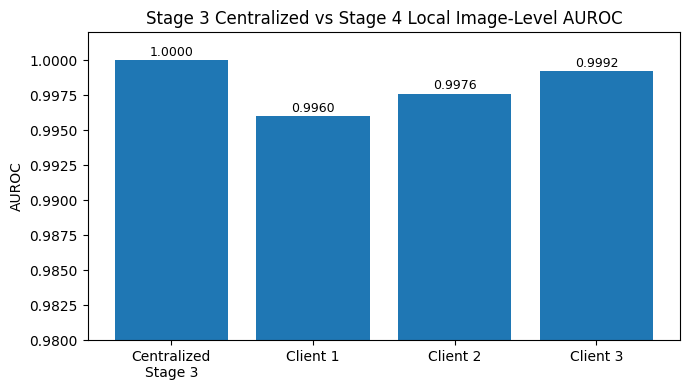

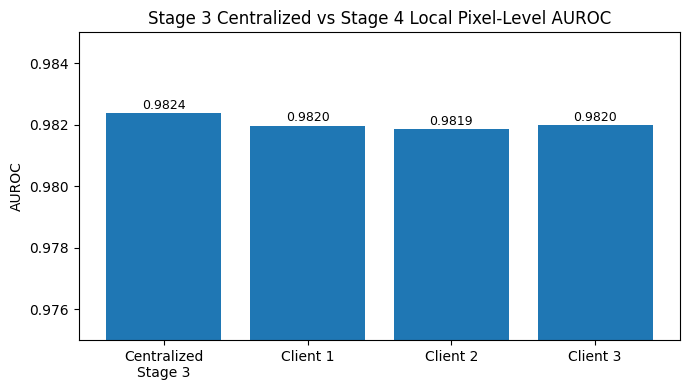

AUROC comparison figures saved successfully.


In [88]:
# Stage 4 - Step 17B: Visual AUROC comparison

import matplotlib.pyplot as plt
from pathlib import Path

figure_dir = Path("/kaggle/working/stage4_figures")
figure_dir.mkdir(parents=True, exist_ok=True)

models = [
    "Centralized\nStage 3",
    "Client 1",
    "Client 2",
    "Client 3"
]

image_values = [
    stage3_image_auroc,
    clients["Client_1"]["image_auroc"],
    clients["Client_2"]["image_auroc"],
    clients["Client_3"]["image_auroc"]
]

pixel_values = [
    stage3_pixel_auroc,
    clients["Client_1"]["pixel_auroc"],
    clients["Client_2"]["pixel_auroc"],
    clients["Client_3"]["pixel_auroc"]
]

# Image-level AUROC figure
plt.figure(figsize=(7, 4))
bars = plt.bar(models, image_values)

plt.ylabel("AUROC")
plt.title("Stage 3 Centralized vs Stage 4 Local Image-Level AUROC")
plt.ylim(0.98, 1.002)

for bar, value in zip(bars, image_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.0003,
        f"{value:.4f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    figure_dir / "stage4_image_auroc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Pixel-level AUROC figure
plt.figure(figsize=(7, 4))
bars = plt.bar(models, pixel_values)

plt.ylabel("AUROC")
plt.title("Stage 3 Centralized vs Stage 4 Local Pixel-Level AUROC")
plt.ylim(0.975, 0.985)

for bar, value in zip(bars, pixel_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.00015,
        f"{value:.4f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    figure_dir / "stage4_pixel_auroc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("AUROC comparison figures saved successfully.")

### Result Interpretation

The visual comparison confirms that all three local clients retained performance very close to the centralized Stage 3 baseline.

For **Image-level AUROC**, the centralized model achieved **1.0000**, while the local clients achieved **0.9960, 0.9976, and 0.9992**.

For **Pixel-level AUROC**, the centralized result was **0.9824**, while all three local clients remained close at approximately **0.9820**.

The small differences and similar bar heights show that the IID local clients behave consistently and preserve almost all centralized anomaly-detection performance without any aggregation.

Both comparison figures were also saved successfully for the Stage 4 results and thesis documentation.

### Stage 4 : Step 17C: Local Anomaly Heatmap Comparison

A qualitative localization example is now created using one anomalous Bottle test image.

The original image, ground-truth defect mask, and anomaly heatmaps from all three local clients are shown together.

The example is selected consistently using the highest average anomaly score across the three clients and is used only for visualization, not for calculating AUROC.

Similar heatmap localization across clients would support the quantitative Pixel-level AUROC results.

The figure is saved for the thesis and final Stage 4 archive.

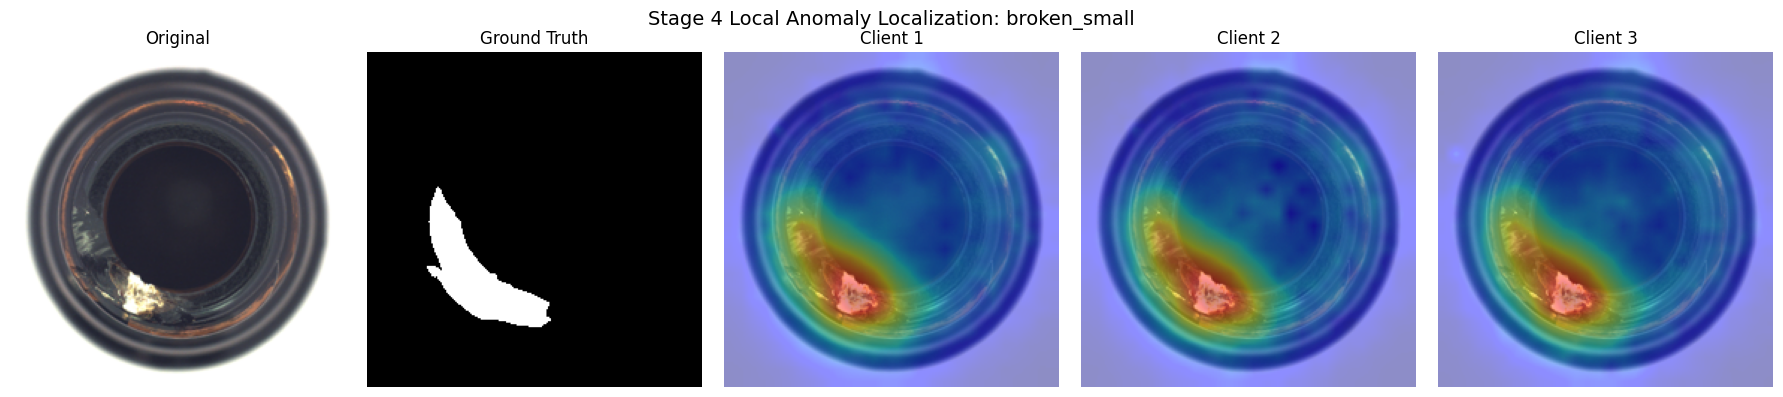

Selected test image: 018.png
Defect type: broken_small
Heatmap comparison saved successfully.


In [89]:
# Stage 4 - Step 17C: Compare local anomaly heatmaps

import matplotlib.pyplot as plt

# Find anomalous test-image indices
anomalous_indices = np.where(
    test_metadata["true_label"].to_numpy() == 1
)[0]

# Mean image anomaly score across the 3 clients
mean_scores = np.mean([
    np.array(clients["Client_1"]["image_scores"]),
    np.array(clients["Client_2"]["image_scores"]),
    np.array(clients["Client_3"]["image_scores"])
], axis=0)

# Select one high-confidence anomalous example
selected_index = anomalous_indices[
    np.argmax(mean_scores[anomalous_indices])
]

row = test_metadata.iloc[selected_index]

# Original image
original = Image.open(row["image_path"]).convert("RGB")
original_224 = original.resize((224, 224))
original_np = np.asarray(original_224)

# Ground-truth mask
gt_mask = Image.open(row["mask_path"]).convert("L")
gt_mask = gt_mask.resize((224, 224), Image.Resampling.NEAREST)
gt_mask_np = (np.asarray(gt_mask) > 0).astype(np.uint8)

# Plot original, mask, and 3 client heatmaps
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(original_np)
axes[0].set_title("Original")

axes[1].imshow(gt_mask_np, cmap="gray")
axes[1].set_title("Ground Truth")

for ax, client_name in zip(
    axes[2:],
    ["Client_1", "Client_2", "Client_3"]
):
    anomaly_28 = clients[client_name]["anomaly_maps"][
        selected_index
    ]

    anomaly_224 = F.interpolate(
        anomaly_28.unsqueeze(0).unsqueeze(0),
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    ax.imshow(original_np)
    ax.imshow(anomaly_224, cmap="jet", alpha=0.45)
    ax.set_title(client_name.replace("_", " "))

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Stage 4 Local Anomaly Localization: {row['defect_type']}",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    figure_dir / "stage4_local_anomaly_heatmap_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_dir / "stage4_local_anomaly_heatmap_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

print("Selected test image:", row["file_name"])
print("Defect type:", row["defect_type"])
print("Heatmap comparison saved successfully.")

### Result Interpretation

The local anomaly heatmap comparison was generated successfully for test image **018.png** with defect type **`broken_small`**.

All three clients highlight the defect in the same lower-left region of the bottle, closely corresponding to the provided ground-truth mask.

The similarity of the three heatmaps supports the very close Pixel-level AUROC results obtained by the local models, showing consistent defect localization under the IID client split.

This provides qualitative evidence that independent local training preserves the spatial anomaly-detection capability of the centralized Stage 3 pipeline.

### Stage 4 : Step 18A: Save Client Split Information

The validated IID client assignment is saved so that the exact Stage 4 experiment can be reproduced later.

For every training image, the saved manifest records its original image index, file name, full path, and assigned client.

Separate image lists are also saved for Clients 1, 2, and 3.

This preserves the exact **70 + 70 + 69** image-level split created with seed 42.

No model parameters or experimental results are changed in this step.

In [90]:
# Stage 4 - Step 18A: Save client split manifest and image lists

from pathlib import Path
import pandas as pd
import json

stage4_output_dir = Path("/kaggle/working/stage4_outputs")
stage4_output_dir.mkdir(parents=True, exist_ok=True)

split_rows = []

for client_name in ["Client_1", "Client_2", "Client_3"]:

    indices = clients[client_name]["image_indices"]
    paths = clients[client_name]["image_paths"]

    # Save one image list per client
    with open(
        stage4_output_dir / f"{client_name.lower()}_image_list.json",
        "w"
    ) as f:
        json.dump(paths, f, indent=2)

    # Build combined manifest
    for image_index, image_path in zip(indices, paths):
        split_rows.append({
            "client": client_name,
            "image_index": image_index,
            "file_name": Path(image_path).name,
            "image_path": image_path
        })

client_split_manifest = pd.DataFrame(split_rows)

client_split_manifest.to_csv(
    stage4_output_dir / "stage4_client_split_manifest.csv",
    index=False
)

print("Saved client assignments:", len(client_split_manifest))

print(
    client_split_manifest["client"]
    .value_counts()
    .sort_index()
)

print("\nStage 4 client split files saved successfully.")

Saved client assignments: 209
client
Client_1    70
Client_2    70
Client_3    69
Name: count, dtype: int64

Stage 4 client split files saved successfully.


### Result Interpretation

The Stage 4 client split information was saved successfully.

The manifest contains all **209 training-image assignments**, with **70 images for Client 1, 70 for Client 2, and 69 for Client 3**.

This preserves the exact IID image-level split used in the experiment, allowing the same client allocation to be reproduced later without reshuffling the data.

The saved split files are therefore ready to be included in the final Stage 4 archive.

### Stage 4 : Step 18B: Save Local Adapter Models and Training Histories

The common initial adapter state \(\theta^{(0)}\) and the three locally trained client adapters are saved for reproducibility.

The 10-epoch reconstruction-loss history of each client is also stored so that the local training behaviour can be reproduced and plotted later.

Only adapter parameters are saved. The frozen ResNet18 backbone is not duplicated because it remains unchanged.

These files will also allow a future notebook to reload the exact Stage 4 local models without retraining them.

In [91]:
# Stage 4 - Step 18B: Save adapter states and training histories

import torch
import json

# Save common initialization theta^(0)
torch.save(
    common_initial_adapter_state,
    stage4_output_dir / "stage4_common_initial_adapter.pt"
)

# Save each trained local adapter
for client_name in ["Client_1", "Client_2", "Client_3"]:

    torch.save(
        clients[client_name]["adapter"].state_dict(),
        stage4_output_dir / f"{client_name.lower()}_local_adapter.pt"
    )

# Save all client training histories
training_histories = {
    client_name: clients[client_name]["training_history"]
    for client_name in ["Client_1", "Client_2", "Client_3"]
}

with open(
    stage4_output_dir / "stage4_training_histories.json",
    "w"
) as f:
    json.dump(training_histories, f, indent=2)

print("Common initial adapter saved: True")
print("Client 1 adapter saved: True")
print("Client 2 adapter saved: True")
print("Client 3 adapter saved: True")
print("Training histories saved:", len(training_histories))

print("\nStage 4 adapter checkpoints saved successfully.")

Common initial adapter saved: True
Client 1 adapter saved: True
Client 2 adapter saved: True
Client 3 adapter saved: True
Training histories saved: 3

Stage 4 adapter checkpoints saved successfully.


### Result Interpretation

The Stage 4 model checkpoints were saved successfully.

The common initial adapter \(\theta^{(0)}\) and all three locally trained client adapters were preserved, together with the **three complete 10-epoch training histories**.

This means the exact local models used in Stage 4 can be reloaded later without repeating training.

The frozen ResNet18 backbone was intentionally not duplicated because it remained unchanged throughout the experiment.

### Stage 4 : Step 18C: Save Local Memory-Bank Information

Each client's private active memory bank is now saved as part of the reproducible Stage 4 outputs.

The banks contain only adapted normal patch features from that client's own training data and remain separate for all three clients.

Clients 1 and 2 contain **5,488 × 384** active features, while Client 3 contains **5,410 × 384**.

A small metadata file is also saved to document the original patch count, active-bank size, feature dimension, and reduction fraction.

These banks are stored locally for reproducibility and are not shared or aggregated between clients.

In [92]:
# Stage 4 - Step 18C: Save private local memory banks and metadata

memory_bank_info = {}

for client_name in ["Client_1", "Client_2", "Client_3"]:

    bank = clients[client_name]["local_memory_bank"].cpu()

    # Save the actual private active memory bank
    torch.save(
        bank,
        stage4_output_dir / f"{client_name.lower()}_local_memory_bank.pt"
    )

    memory_bank_info[client_name] = {
        "original_adapted_patches":
            clients[client_name]["full_adapted_patch_count"],
        "active_memory_patches": len(bank),
        "feature_dimension": bank.shape[1],
        "memory_fraction": LOCAL_MEMORY_FRACTION
    }

with open(
    stage4_output_dir / "stage4_memory_bank_info.json",
    "w"
) as f:
    json.dump(memory_bank_info, f, indent=2)

for client_name, info in memory_bank_info.items():
    print(
        f"{client_name}: "
        f"{info['original_adapted_patches']} -> "
        f"{info['active_memory_patches']} patches | "
        f"dim = {info['feature_dimension']}"
    )

print("\nPrivate local memory banks saved successfully.")

Client_1: 54880 -> 5488 patches | dim = 384
Client_2: 54880 -> 5488 patches | dim = 384
Client_3: 54096 -> 5410 patches | dim = 384

Private local memory banks saved successfully.


### Result Interpretation

The three private local memory banks were saved successfully.

Client 1 and Client 2 each retained **5,488 active patches**, while Client 3 retained **5,410**, with every feature remaining **384-dimensional**.

The saved files preserve the exact local memory banks used during Stage 4 evaluation and therefore allow the local anomaly-detection results to be reproduced later.

The banks remain separate for each client and have not been shared or aggregated.

### Stage 4 : Step 18D: Save Evaluation Results

The complete Stage 4 evaluation results are now saved for reproducibility and later thesis analysis.

This includes the **83 test-image anomaly scores for each client**, all local **28 × 28 anomaly maps**, Image-level and Pixel-level AUROCs, comparison tables, and the experimental configuration.

The compact 28 × 28 maps are saved instead of unnecessarily storing large upsampled maps.

These files preserve the exact local-only evaluation results obtained before any federated aggregation.

In [93]:
# Stage 4 - Step 18D: Save predictions, AUROCs, anomaly maps and configuration

# 1. Save image-level predictions for all 83 test images
prediction_table = test_metadata[
    ["file_name", "defect_type", "true_label"]
].copy()

for client_name in ["Client_1", "Client_2", "Client_3"]:
    prediction_table[f"{client_name}_score"] = clients[
        client_name
    ]["image_scores"]

prediction_table.to_csv(
    stage4_output_dir / "stage4_client_predictions.csv",
    index=False
)

# 2. Save compact 28 x 28 anomaly maps
for client_name in ["Client_1", "Client_2", "Client_3"]:

    anomaly_tensor = torch.stack(
        clients[client_name]["anomaly_maps"]
    )

    torch.save(
        anomaly_tensor,
        stage4_output_dir /
        f"{client_name.lower()}_anomaly_maps_28x28.pt"
    )

# 3. Save AUROC results
auroc_results = {
    "Centralized_Stage_3": {
        "image_auroc": float(stage3_image_auroc),
        "pixel_auroc": float(stage3_pixel_auroc)
    },
    "Client_1": {
        "image_auroc": float(clients["Client_1"]["image_auroc"]),
        "pixel_auroc": float(clients["Client_1"]["pixel_auroc"])
    },
    "Client_2": {
        "image_auroc": float(clients["Client_2"]["image_auroc"]),
        "pixel_auroc": float(clients["Client_2"]["pixel_auroc"])
    },
    "Client_3": {
        "image_auroc": float(clients["Client_3"]["image_auroc"]),
        "pixel_auroc": float(clients["Client_3"]["pixel_auroc"])
    }
}

with open(
    stage4_output_dir / "stage4_auroc_results.json",
    "w"
) as f:
    json.dump(auroc_results, f, indent=2)

# 4. Save comparison tables
local_training_comparison.to_csv(
    stage4_output_dir / "stage4_local_training_comparison.csv",
    index=False
)

stage4_performance_comparison.to_csv(
    stage4_output_dir / "stage4_performance_comparison.csv",
    index=False
)

# 5. Save experimental configuration
stage4_config = {
    "seed": 42,
    "num_clients": 3,
    "client_images": [70, 70, 69],
    "patches_per_image": 784,
    "feature_dimension": 384,
    "adapter_parameters": 98816,
    "batch_size": 512,
    "epochs": 10,
    "learning_rate": 0.001,
    "noise_std": 0.05,
    "optimizer": "Adam",
    "loss": "MSE",
    "memory_fraction": 0.10,
    "split_type": "IID image-level",
    "federated_aggregation": False
}

with open(
    stage4_output_dir / "stage4_configuration.json",
    "w"
) as f:
    json.dump(stage4_config, f, indent=2)

print("Prediction rows saved:", len(prediction_table))
print("Client anomaly-map files saved: 3")
print("AUROC results saved: True")
print("Comparison tables saved: True")
print("Configuration saved: True")

print("\nStage 4 evaluation outputs saved successfully.")

Prediction rows saved: 83
Client anomaly-map files saved: 3
AUROC results saved: True
Comparison tables saved: True
Configuration saved: True

Stage 4 evaluation outputs saved successfully.


### Result Interpretation

The Stage 4 evaluation outputs were saved successfully.

The saved files include predictions for all **83 test images**, anomaly maps for all **three clients**, the Image-level and Pixel-level AUROC results, both comparison tables, and the full Stage 4 experimental configuration.

This preserves the exact local-only evaluation used in Stage 4 and makes the results reproducible for later analysis, reporting, or continuation in another notebook.

No federated aggregation was performed, so these files represent the final independent local-client baseline results.

### Stage 4 : Step 18E: Save Local Training Curves

The 10-epoch self-supervised training histories of the three clients are visualized together.

Because all clients used the same initialization, optimizer, and hyperparameters, the curves provide a direct comparison of local learning under the IID split.

A smooth and similar decrease across clients indicates stable and consistent local optimization.

The figure is saved for the thesis and final Stage 4 archive.

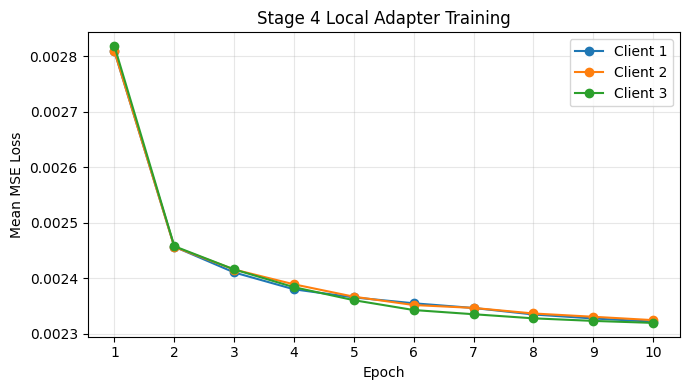

Local training-curve figures saved successfully.


In [94]:
# Stage 4 - Step 18E: Plot and save local training-loss curves

import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(7, 4))

for client_name in ["Client_1", "Client_2", "Client_3"]:
    plt.plot(
        epochs,
        clients[client_name]["training_history"],
        marker="o",
        label=client_name.replace("_", " ")
    )

plt.xlabel("Epoch")
plt.ylabel("Mean MSE Loss")
plt.title("Stage 4 Local Adapter Training")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    figure_dir / "stage4_local_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    figure_dir / "stage4_local_training_curves.pdf",
    bbox_inches="tight"
)

plt.show()

print("Local training-curve figures saved successfully.")

### Result Interpretation

All three local adapters showed a smooth and consistent decrease in reconstruction loss across the **10 training epochs**.

The three curves remain very close throughout training, with losses decreasing from approximately **0.00281 to 0.00232**.

This similar learning behaviour is consistent with the IID client split, identical initialization, and identical training settings.

The figure therefore confirms stable and comparable local self-supervised learning across all three clients.

### Stage 4 : Step 18F: Final Stage 4 Archive

All saved Stage 4 outputs are now collected into one final archive.

The archive includes the client split, image lists, adapter checkpoints, training histories, private memory banks, predictions, anomaly maps, AUROC results, configuration, comparison tables, and saved figures.

Creating one ZIP file keeps the complete Stage 4 experiment together for backup, thesis documentation, and later continuation.

No model training or evaluation occurs in this step.

In [95]:
# Stage 4 - Step 18F: Create final Stage 4 ZIP archive

import shutil
from pathlib import Path

archive_root = Path("/kaggle/working/stage4_final_archive")

# Remove an older copy if this cell is rerun
if archive_root.exists():
    shutil.rmtree(archive_root)

archive_root.mkdir(parents=True)

# Copy saved outputs
shutil.copytree(
    stage4_output_dir,
    archive_root / "outputs"
)

# Copy saved figures
shutil.copytree(
    figure_dir,
    archive_root / "figures"
)

# Create ZIP
zip_base = "/kaggle/working/Stage4_Federated_Client_Local_Baselines"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    root_dir=archive_root
)

# Count archived files
archived_files = [
    p for p in archive_root.rglob("*")
    if p.is_file()
]

print("Files included in archive:", len(archived_files))
print("Archive created:", Path(zip_path).name)
print("Archive exists:", Path(zip_path).exists())
print(
    "Archive size (MB):",
    round(Path(zip_path).stat().st_size / (1024**2), 2)
)

print("\nFinal Stage 4 ZIP archive created successfully.")

Files included in archive: 27
Archive created: Stage4_Federated_Client_Local_Baselines.zip
Archive exists: True
Archive size (MB): 25.49

Final Stage 4 ZIP archive created successfully.


### Result Interpretation

The final Stage 4 archive was created successfully.

The ZIP contains **27 saved files** and has a size of approximately **25.49 MB**. The archive includes the client split, local adapters, training histories, private memory banks, predictions, anomaly maps, AUROC results, configuration files, comparison tables, and figures.

The successful archive check confirms that the complete Stage 4 experiment has been preserved in one reproducible package.

Stage 4 is now technically complete and ready for final documentation and progression to the next federated-learning stage.

## Stage 4 : Final Conclusion

Stage 4 successfully established **three independent local anomaly-detection clients** using an IID image-level split of **70, 70, and 69 normal training images**.

All clients started from the same adapter initialization and trained only on their own local normal features. Their reconstruction losses decreased consistently by approximately **17%**, confirming successful local learning.

The local models achieved a mean **Image-level AUROC of 0.997619 (99.76%)** and mean **Pixel-level AUROC of 0.981931 (98.19%)**, remaining very close to the centralized Stage 3 results of **1.0000** and **0.982363**.

The three clients also produced consistent anomaly heatmaps, while raw images and local memory banks remained separate.

Therefore, Stage 4 confirms that the architecture works correctly in a multi-client local setting **before any federated aggregation**. No FedAvg or FedProx has been performed yet.


# Stage 5 : IID FedAvg

## Step 1 : Standardize Pixel-Level Evaluation

Before starting FedAvg, the Pixel-AUROC evaluation is standardized.

Stage 3 evaluated anomaly maps at the original \(900 \times 900\) resolution, while Stage 4 used \(224 \times 224\). These values should not be compared directly.

Therefore, from this stage onward, all Pixel-AUROC calculations will use:

\[
224 \times 224
\]

The same 83 test images and ground-truth masks are still used. Only the evaluation resolution is standardized.

For normal images, the ground-truth mask contains only zeros. For anomalous images, the original mask is resized to \(224 \times 224\) using nearest-neighbour interpolation.

Expected final label vector:

\[
83 \times 224 \times 224 = 4,164,608
\]

No model training or federated communication occurs in this step.

In [96]:
# Stage 5 - Step 1: Build the common 224 x 224 pixel-label vector

common_pixel_label_parts_224 = []

for _, row in test_metadata.iterrows():

    # Normal images contain no anomalous pixels
    if int(row["true_label"]) == 0:
        gt_mask_224 = np.zeros(
            (224, 224),
            dtype=np.uint8
        )

    # Anomalous images use their ground-truth segmentation mask
    else:
        mask = Image.open(row["mask_path"]).convert("L")

        mask = TF.resize(
            mask,
            [224, 224],
            interpolation=InterpolationMode.NEAREST
        )

        gt_mask_224 = (
            np.asarray(mask) > 0
        ).astype(np.uint8)

    common_pixel_label_parts_224.append(
        gt_mask_224.reshape(-1)
    )


# Combine all 83 images into one common pixel-label vector
common_pixel_labels_224 = np.concatenate(
    common_pixel_label_parts_224
)


print("Number of test images:", len(test_metadata))
print("Common pixel-label shape:", common_pixel_labels_224.shape)
print("Expected pixels:", 83 * 224 * 224)
print("Unique labels:", np.unique(common_pixel_labels_224))
print(
    "Defective pixels:",
    int(common_pixel_labels_224.sum())
)

assert common_pixel_labels_224.shape == (4164608,)
assert set(np.unique(common_pixel_labels_224)) == {0, 1}

print("\nCommon 224 x 224 pixel evaluation labels created successfully.")

Number of test images: 83
Common pixel-label shape: (4164608,)
Expected pixels: 4164608
Unique labels: [0 1]
Defective pixels: 240575

Common 224 x 224 pixel evaluation labels created successfully.


### Step 1 : Result Interpretation

The common Pixel-AUROC evaluation labels were created successfully.

All 83 test images produced a combined vector of **4,164,608 pixel labels**, exactly matching:

\[
83 \times 224 \times 224 = 4,164,608
\]

The labels contain only **0 (normal)** and **1 (defective)**, confirming that the resized ground-truth masks remain binary.

A total of **240,575 defective pixels** are present at the standardized \(224 \times 224\) resolution.

This common label vector can now be reused for consistent Pixel-AUROC evaluation of the centralized, local, and federated models.

questions: 

Why 4,164,608 pixels?
Because there are 83 test images and each has 224×224=50,176 pixels.
What does [0 1] mean?
Only two ground-truth classes exist: normal pixel and defective pixel.
Why is the defective-pixel count now 240,575?
Because the masks are being evaluated at 224×224 instead of the original 900×900 resolution.
Did this train the model?
No. This step only prepared standardized evaluation labels.
Did FedAvg start yet?
No. Federation has not started yet.

## Step 2 : Rebuild Local Training Features

Stage 4 removed the large local patch-feature tensors after evaluation to save memory.

For FedAvg, each client needs its own normal training features again. Therefore, the same existing client image assignments are reused and their frozen ResNet18 patch features are re-extracted.

Each image produces:

\[
784 \times 384
\]

patch features.

Expected local features:

- Client 1: \(54,880 \times 384\)
- Client 2: \(54,880 \times 384\)
- Client 3: \(54,096 \times 384\)

ResNet18 remains frozen. No adapter training or federated communication occurs yet.

In [97]:
# Stage 5 - Step 2: Rebuild local patch features

patch_feature_extractor.eval()

for client_name in clients:

    # Reuse the same Stage 4 client images
    client_dataset = NormalBottleDataset(
        image_paths=clients[client_name]["image_paths"],
        transform=patchcore_transform
    )

    client_loader = DataLoader(
        client_dataset,
        batch_size=MEMORY_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    feature_batches = []

    # NormalBottleDataset returns only the image batch
    for image_batch in client_loader:

        image_batch = image_batch.to(
            device,
            non_blocking=True
        )

        batch_features = extract_patch_embeddings_from_batch(
            image_batch
        )

        feature_batches.append(
            batch_features.cpu()
        )

    client_features_by_image = torch.cat(
        feature_batches,
        dim=0
    )

    clients[client_name]["patch_features"] = (
        client_features_by_image
        .reshape(-1, 384)
        .contiguous()
    )

    print(
        client_name,
        "->",
        clients[client_name]["patch_features"].shape
    )

    del feature_batches
    del client_features_by_image


print(
    "\nTrainable ResNet18 parameters:",
    sum(
        p.numel()
        for p in resnet18_backbone.parameters()
        if p.requires_grad
    )
)

print("\nStage 5 local training features rebuilt successfully.")

Client_1 -> torch.Size([54880, 384])
Client_2 -> torch.Size([54880, 384])
Client_3 -> torch.Size([54096, 384])

Trainable ResNet18 parameters: 0

Stage 5 local training features rebuilt successfully.


### Step 2 : Result Interpretation

The local training features were rebuilt successfully for all three clients.

- Client 1: 54,880 patches
- Client 2: 54,880 patches
- Client 3: 54,096 patches
- Feature dimension: 384

The ResNet18 backbone still has **0 trainable parameters**, confirming that it remains frozen.

These local features are now ready for federated adapter training.

## Step 3 : Prepare Local DataLoaders

Each client's rebuilt patch features are placed into its own local DataLoader.

The same batch size of **512** used in Stage 4 is reused.

Expected batches:

- Client 1: 108
- Client 2: 108
- Client 3: 106

The client datasets remain separate. ResNet18 stays frozen and no federated aggregation occurs yet.

In [98]:
# Stage 5 - Step 3: Recreate local DataLoaders

for i, client_name in enumerate(clients):

    features = clients[client_name]["patch_features"]

    # Reproducible local shuffling
    generator = torch.Generator()
    generator.manual_seed(42 + i)

    local_loader = DataLoader(
        features,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    clients[client_name]["train_loader"] = local_loader

    print(
        client_name,
        "-> patches:", len(features),
        "| batches:", len(local_loader)
    )


print("\nLocal DataLoaders ready for federated training.")

Client_1 -> patches: 54880 | batches: 108
Client_2 -> patches: 54880 | batches: 108
Client_3 -> patches: 54096 | batches: 106

Local DataLoaders ready for federated training.


### Step 3 : Result Interpretation

The local DataLoaders were created successfully.

- Client 1: 108 batches
- Client 2: 108 batches
- Client 3: 106 batches

Each client keeps its own local patch features and uses a batch size of 512.

No client data are mixed and FedAvg has not started yet.

questions:

1)Why does Client 3 have fewer batches?
Because Client 3 has 69 images instead of 70.
2)What is a DataLoader?
It divides the local training features into smaller batches for training.
3)Why batch size 512?
It is the same setting used previously and is manageable for GPU memory.
4)Are client features combined?
No. Each client has its own separate DataLoader.
5)Has federated learning started?
Not yet. We have only prepared the local training data.


## Step 4 : Initialize the Global Adapter

FedAvg requires one global adapter maintained by the server.

The global adapter uses the same \(384 \rightarrow 128 \rightarrow 384\) architecture and starts from the same saved initialization \(\theta^{(0)}\) used in Stage 4.

Only the adapter will later be communicated and aggregated. ResNet18 remains frozen.

No local training or FedAvg aggregation occurs in this step.

In [99]:
# Stage 5 : Step 4: Create the initial global adapter

global_adapter = ResidualAdapter().to(device)

global_adapter.load_state_dict(
    copy.deepcopy(common_initial_adapter_state)
)

global_param_count = sum(
    p.numel()
    for p in global_adapter.parameters()
    if p.requires_grad
)

matches_initial = state_matches_initial(
    global_adapter,
    common_initial_adapter_state
)

print("Global adapter parameters:", global_param_count)
print("Global adapter matches theta^(0):", matches_initial)

assert global_param_count == 98816
assert matches_initial

print("\nInitial global adapter created successfully.")

Global adapter parameters: 98816
Global adapter matches theta^(0): True

Initial global adapter created successfully.


### Step 4 : Result Interpretation

The global adapter was initialized successfully with **98,816 trainable parameters**.

The check `True` confirms that its parameters exactly match the common initialization \(\theta^{(0)}\) used for the Stage 4 clients.

This global adapter will now act as the server model for FedAvg.

questions:

1)What is θ 
(0)?
It is the initial set of adapter weights before any local training.
2)Why must the global adapter match it?
To ensure Stage 5 starts from the same point as Stage 4.
3)What does 98,816 represent?
The total number of trainable scalar parameters in the residual adapter.
4)What is the server model?
The global adapter whose parameters are sent to clients and later updated through FedAvg.
5)Has FedAvg happened yet?
No. We have only initialized the global model.

## Step 5 : Define FedAvg Training Settings

The IID FedAvg experiment will use:

- **10 communication rounds**
- **1 local epoch per client per round**

This gives each client 10 local training epochs in total, matching the 10 epochs used in the Stage 4 local baseline.

FedAvg uses weighted averaging:

\[
\theta_{global}=\sum_k \frac{n_k}{N}\theta_k
\]

where \(n_k\) is the number of local training patches.

Because every image produces 784 patches, weighting by patches is equivalent to weighting by the client image counts.

No training or parameter communication occurs in this step.

In [100]:
# Stage 5 - Step 5: Define FedAvg settings and client weights

NUM_ROUNDS = 10
LOCAL_EPOCHS = 1

client_patch_counts = {
    client_name: len(clients[client_name]["patch_features"])
    for client_name in clients
}

total_patch_count = sum(client_patch_counts.values())

client_weights = {
    client_name: client_patch_counts[client_name] / total_patch_count
    for client_name in clients
}

print("Communication rounds:", NUM_ROUNDS)
print("Local epochs per round:", LOCAL_EPOCHS)
print("Total training patches:", total_patch_count)

for client_name in clients:
    print(
        client_name,
        "-> patches:", client_patch_counts[client_name],
        "| FedAvg weight:", round(client_weights[client_name], 6)
    )

print(
    "Sum of FedAvg weights:",
    round(sum(client_weights.values()), 6)
)

Communication rounds: 10
Local epochs per round: 1
Total training patches: 163856
Client_1 -> patches: 54880 | FedAvg weight: 0.334928
Client_2 -> patches: 54880 | FedAvg weight: 0.334928
Client_3 -> patches: 54096 | FedAvg weight: 0.330144
Sum of FedAvg weights: 1.0


### Step 5 : Result Interpretation

The FedAvg training settings were defined successfully.

The experiment will use **10 communication rounds** with **1 local epoch per client per round**.

FedAvg weights are based on the amount of local training data:

- Client 1: 0.334928
- Client 2: 0.334928
- Client 3: 0.330144

The weights sum to 1, confirming that the aggregation weights are correctly normalized.

questions:

1)Why is Client 3's weight slightly smaller?
Because it has 69 images instead of 70.
2)Why do the weights sum to 1?
Because they represent each client's proportion of the total training data.
3)Why 10 rounds and 1 local epoch?
So each client performs 10 total local epochs, matching Stage 4.
4)Has FedAvg started yet?
Not yet. We have only defined the settings.

## Step 6 : Define Local Client Training

During each FedAvg round, every client receives the current global adapter and trains it for **1 local epoch** using only its own normal patch features.

The same Stage 4 training settings are reused:

- Gaussian noise: 0.05
- MSE reconstruction loss
- Adam optimizer
- Learning rate: 0.001

After local training, the client returns its updated adapter parameters and mean training loss.

No client data are sent to the server.

In [101]:
# Stage 5 - Step 6: Define one-client FedAvg training

def train_fedavg_client(global_state, train_loader, seed):

    # Create a fresh local adapter
    local_adapter = ResidualAdapter().to(device)

    # Start from the current global parameters
    local_adapter.load_state_dict(
        copy.deepcopy(global_state)
    )

    local_adapter.train()

    optimizer = torch.optim.Adam(
        local_adapter.parameters(),
        lr=LEARNING_RATE
    )

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    total_loss = 0.0
    total_samples = 0

    for clean_features in train_loader:

        clean_features = clean_features.to(
            device,
            non_blocking=True
        )

        noisy_features = (
            clean_features
            + NOISE_STD * torch.randn_like(clean_features)
        )

        optimizer.zero_grad()

        reconstructed = local_adapter(noisy_features)

        loss = F.mse_loss(
            reconstructed,
            clean_features
        )

        loss.backward()
        optimizer.step()

        batch_size = clean_features.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

    mean_loss = total_loss / total_samples

    local_state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in local_adapter.state_dict().items()
    }

    return local_state, mean_loss


print("FedAvg local-training function created successfully.")

FedAvg local-training function created successfully.


### Step 6 : Result Interpretation

The local FedAvg training function was created successfully.

The function will allow each client to:

- receive the current global adapter,
- train locally for one epoch,
- use only its own normal patch features,
- return updated adapter parameters and mean loss.

No aggregation or client training has occurred yet.

questions:

1)What does this function return?
The updated local adapter parameters and the client's mean training loss.
2)Does it return raw client data?
No. Only adapter parameters and loss.
3)Why create a fresh adapter for each client?
So every client starts each round from the same current global model.
4)Why use load_state_dict()?
To copy the current global parameters into the local adapter.
5)Why use MSE?
Because the adapter is trained to reconstruct the clean patch features from noisy versions.
6)Has FedAvg happened yet?
No. We only defined the local training function.

## Step 7 : Define Weighted FedAvg Aggregation

After local training, each client returns its updated adapter parameters.

The server combines them using:

\[
\theta_{global}=\sum_k \frac{n_k}{N}\theta_k
\]

Clients 1 and 2 contribute slightly more because they contain more training patches than Client 3.

Only adapter parameters are averaged. ResNet18 and local patch data are not aggregated.

In [102]:
# Stage 5 - Step 7: Define weighted FedAvg aggregation

def fedavg_aggregate(client_states, client_weights):

    aggregated_state = {}

    # Use parameter names from the first client
    first_client = next(iter(client_states))
    first_state = client_states[first_client]

    for param_name in first_state:

        # Start with a zero tensor of the same shape
        weighted_param = torch.zeros_like(
            first_state[param_name]
        )

        # Add each client's weighted parameter
        for client_name, local_state in client_states.items():

            weighted_param += (
                client_weights[client_name]
                * local_state[param_name]
            )

        aggregated_state[param_name] = weighted_param

    return aggregated_state


print("Weighted FedAvg aggregation function created successfully.")

Weighted FedAvg aggregation function created successfully.


### Step 7 : Result Interpretation

The weighted FedAvg aggregation function was created successfully.

This function will combine the three locally trained adapter parameter sets using their client data weights.

Only adapter parameters will be aggregated. No raw client data or ResNet18 parameters are involved.

The actual FedAvg communication rounds have not started yet.

1)What does this function average?
The adapter weights and biases returned by each client.
2)Why weighted averaging?
Because clients have slightly different amounts of training data.
3)What does torch.zeros_like() do?
It creates a zero tensor with the same shape as the parameter being averaged.
4)What does .items() do?
It gives both the client name and that client's parameter dictionary.
5)Has federated training started?
Not yet. We only created the aggregation function.

## Step 8 : Run the First FedAvg Round

The first federated communication round is now performed.

1. The same global adapter is sent to all three clients.
2. Each client trains locally for one epoch.
3. Only the updated adapter parameters are returned.
4. The server performs weighted FedAvg.
5. The aggregated parameters become the new global adapter.

Client images and patch features remain local.

In [103]:
# Stage 5 - Step 8: Run FedAvg communication round 1

# Save the same starting global state for all clients
round_start_state = {
    name: tensor.detach().cpu().clone()
    for name, tensor in global_adapter.state_dict().items()
}

round_client_states = {}
round_client_losses = {}

# Local training on each client
for i, client_name in enumerate(clients):

    local_state, mean_loss = train_fedavg_client(
        global_state=round_start_state,
        train_loader=clients[client_name]["train_loader"],
        seed=1000 + i
    )

    round_client_states[client_name] = local_state
    round_client_losses[client_name] = mean_loss

    print(
        client_name,
        "local loss:",
        f"{mean_loss:.8f}"
    )


# Server-side weighted FedAvg
aggregated_state = fedavg_aggregate(
    round_client_states,
    client_weights
)

global_adapter.load_state_dict(
    aggregated_state
)


# Measure how much the global adapter changed
change_squared = 0.0

for name, tensor in global_adapter.state_dict().items():

    difference = (
        tensor.detach().cpu()
        - round_start_state[name]
    )

    change_squared += torch.sum(
        difference ** 2
    ).item()

global_update_l2 = change_squared ** 0.5

print(
    "\nGlobal adapter update L2 norm:",
    f"{global_update_l2:.8f}"
)

assert global_update_l2 > 0

print("\nFedAvg Round 1 completed successfully.")

Client_1 local loss: 0.00280505
Client_2 local loss: 0.00280907
Client_3 local loss: 0.00281466

Global adapter update L2 norm: 3.41711916

FedAvg Round 1 completed successfully.


### Step 8 : Result Interpretation

FedAvg Round 1 completed successfully.

The three clients achieved similar local reconstruction losses:

- Client 1: 0.00280505
- Client 2: 0.00280907
- Client 3: 0.00281466

The global adapter update L2 norm was **3.4171**, confirming that the aggregated global parameters changed after the first federated round.

This is the first completed federated-learning update in the thesis.

questions:

1)Why are the client losses similar?
Because the clients were created using an IID split.
2)What does the L2 norm mean?
It measures the overall magnitude of the change in the global adapter parameters.
3)Why must it be greater than zero?
Because a zero value would mean the global model did not change.
4)What was sent to the server?
Only updated adapter parameters.
5)Was ResNet18 trained?
No, it remained frozen.
6)Is Round 1 now complete?
Yes.

## Step 9 : Complete the FedAvg Communication Rounds

FedAvg Round 1 has already been completed.

The remaining rounds, **2 to 10**, are now performed using the same process:

1. Send the current global adapter to all clients.
2. Train each client locally for one epoch.
3. Return updated adapter parameters.
4. Perform weighted FedAvg.
5. Update the global adapter.

Client losses and global parameter changes are recorded for later analysis.

In [104]:
# Stage 5 - Step 9: Run FedAvg rounds 2 to 10

fedavg_history = []

# Save the already completed Round 1 result
fedavg_history.append({
    "round": 1,
    "Client_1_loss": round_client_losses["Client_1"],
    "Client_2_loss": round_client_losses["Client_2"],
    "Client_3_loss": round_client_losses["Client_3"],
    "global_update_l2": global_update_l2
})


# Continue with Rounds 2 to 10
for round_number in range(2, NUM_ROUNDS + 1):

    # Same starting global model for all clients in this round
    round_start_state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in global_adapter.state_dict().items()
    }

    current_client_states = {}
    current_client_losses = {}

    # Local client training
    for i, client_name in enumerate(clients):

        local_state, mean_loss = train_fedavg_client(
            global_state=round_start_state,
            train_loader=clients[client_name]["train_loader"],
            seed=1000 + (round_number * 10) + i
        )

        current_client_states[client_name] = local_state
        current_client_losses[client_name] = mean_loss

    # Weighted FedAvg
    aggregated_state = fedavg_aggregate(
        current_client_states,
        client_weights
    )

    global_adapter.load_state_dict(aggregated_state)

    # Measure global model change
    change_squared = 0.0

    for name, tensor in global_adapter.state_dict().items():

        difference = (
            tensor.detach().cpu()
            - round_start_state[name]
        )

        change_squared += torch.sum(
            difference ** 2
        ).item()

    current_update_l2 = change_squared ** 0.5

    # Save this round
    fedavg_history.append({
        "round": round_number,
        "Client_1_loss": current_client_losses["Client_1"],
        "Client_2_loss": current_client_losses["Client_2"],
        "Client_3_loss": current_client_losses["Client_3"],
        "global_update_l2": current_update_l2
    })

    print(
        f"Round {round_number:02d} | "
        f"C1: {current_client_losses['Client_1']:.8f} | "
        f"C2: {current_client_losses['Client_2']:.8f} | "
        f"C3: {current_client_losses['Client_3']:.8f} | "
        f"L2 update: {current_update_l2:.6f}"
    )


print("\nAll 10 FedAvg communication rounds completed.")

Round 02 | C1: 0.00248117 | C2: 0.00247910 | C3: 0.00247791 | L2 update: 1.361628
Round 03 | C1: 0.00243281 | C2: 0.00243133 | C3: 0.00243229 | L2 update: 1.526016
Round 04 | C1: 0.00240552 | C2: 0.00240435 | C3: 0.00240525 | L2 update: 1.175951
Round 05 | C1: 0.00238475 | C2: 0.00238672 | C3: 0.00238306 | L2 update: 1.162786
Round 06 | C1: 0.00236178 | C2: 0.00235962 | C3: 0.00236377 | L2 update: 0.993784
Round 07 | C1: 0.00234756 | C2: 0.00234914 | C3: 0.00234913 | L2 update: 0.574145
Round 08 | C1: 0.00234615 | C2: 0.00234544 | C3: 0.00234523 | L2 update: 0.529097
Round 09 | C1: 0.00234144 | C2: 0.00233868 | C3: 0.00234025 | L2 update: 0.705533
Round 10 | C1: 0.00233581 | C2: 0.00233705 | C3: 0.00233611 | L2 update: 0.404363

All 10 FedAvg communication rounds completed.


### Step 9 : Result Interpretation

All 10 IID FedAvg communication rounds completed successfully.

The local reconstruction losses decreased gradually and remained very similar across the three clients, which is expected because the client split is IID.

The global adapter update also became smaller over time, indicating that the federated model was approaching a more stable parameter state.

The final local losses were approximately **0.00234** for all three clients.

questions:

1)Did the losses decrease?
Yes, from about 0.00280 to about 0.00234.
2)Why are the three client losses similar?
Because the data were split IID.
3)Why does the L2 update generally decrease?
Because the global adapter is gradually stabilizing.
4)Does the L2 value need to decrease every round?
No. Small fluctuations are normal during optimization.
5)What happened in every round?
Global adapter → local client training → updated adapter parameters → weighted FedAvg → new global adapter.
6)Is the final global adapter ready now?
Yes. After Round 10, global_adapter contains the final IID FedAvg parameters.1)

## Step 10 : Verify and Save the Final FedAvg Adapter

After 10 communication rounds, the final global adapter is verified and saved.

The checks confirm that:

- the adapter still contains **98,816 trainable parameters**,
- its parameters changed from the initial \(\theta^{(0)}\),
- ResNet18 remains completely frozen.

The final global adapter is then saved for later anomaly-detection evaluation.

In [105]:
# Stage 5 - Step 10: Verify and save final FedAvg adapter

final_matches_initial = state_matches_initial(
    global_adapter,
    common_initial_adapter_state
)

final_adapter_params = sum(
    p.numel()
    for p in global_adapter.parameters()
    if p.requires_grad
)

trainable_resnet_params = sum(
    p.numel()
    for p in resnet18_backbone.parameters()
    if p.requires_grad
)

save_path = "/kaggle/working/stage5_iid_fedavg_adapter.pth"

torch.save(
    global_adapter.state_dict(),
    save_path
)

print("Final adapter parameters:", final_adapter_params)
print("Final adapter matches theta^(0):", final_matches_initial)
print("Trainable ResNet18 parameters:", trainable_resnet_params)
print("Saved to:", save_path)

assert final_adapter_params == 98816
assert final_matches_initial is False
assert trainable_resnet_params == 0

print("\nFinal IID FedAvg adapter verified and saved successfully.")

Final adapter parameters: 98816
Final adapter matches theta^(0): False
Trainable ResNet18 parameters: 0
Saved to: /kaggle/working/stage5_iid_fedavg_adapter.pth

Final IID FedAvg adapter verified and saved successfully.


### Step 10 : Result Interpretation

The final IID FedAvg adapter was verified and saved successfully.

The adapter still contains **98,816 trainable parameters**, but it no longer matches the initial \(\theta^{(0)}\), confirming that federated training changed its parameters.

ResNet18 still has **0 trainable parameters**, confirming that only the residual adapter was trained.

The final global adapter is now ready for anomaly-detection evaluation.

questions:

1)Why is matches theta^(0) False?
Because FedAvg training updated the adapter parameters.
2)Why is 98,816 unchanged?
Training changes parameter values, not the architecture or number of parameters.
3)Why is ResNet18 still 0?
Because the backbone remained frozen throughout federation.
4)What was saved?
The final global adapter parameters after 10 FedAvg rounds.

## Step 11 : Build Local Memory Banks with the Global Adapter

The final FedAvg adapter is now used to transform each client's own normal patch features.

Each client then keeps its own reduced **10% PatchCore-style memory bank**.

Expected memory sizes:

- Client 1: 5,488 × 384
- Client 2: 5,488 × 384
- Client 3: 5,410 × 384

The global adapter is shared, but the normal memory banks remain separate and local.

In [106]:
# Stage 5 - Step 11: Build private memory banks using final FedAvg adapter

global_adapter.eval()

for client_name in clients:

    frozen_features = clients[client_name]["patch_features"]

    adapted_chunks = []

    with torch.inference_mode():

        for start in range(
            0,
            len(frozen_features),
            INFERENCE_BATCH_SIZE
        ):

            batch = frozen_features[
                start:start + INFERENCE_BATCH_SIZE
            ].to(device)

            adapted_batch = global_adapter(batch)

            adapted_chunks.append(
                adapted_batch.cpu()
            )

    # Combine all adapted local patches
    full_adapted_bank = torch.cat(
        adapted_chunks,
        dim=0
    )

    # Same reproducible 10% reduction used previously
    bank_size = round(
        len(full_adapted_bank)
        * LOCAL_MEMORY_FRACTION
    )

    generator = torch.Generator()
    generator.manual_seed(42)

    selected_indices = torch.randperm(
        len(full_adapted_bank),
        generator=generator
    )[:bank_size]

    fedavg_memory_bank = (
        full_adapted_bank[selected_indices]
        .contiguous()
    )

    # Keep Stage 5 memory separate from Stage 4 memory
    clients[client_name]["fedavg_memory_bank"] = (
        fedavg_memory_bank
    )

    clients[client_name]["fedavg_full_patch_count"] = (
        len(full_adapted_bank)
    )

    print(
        client_name,
        "->",
        full_adapted_bank.shape,
        "-> memory:",
        fedavg_memory_bank.shape
    )

    del adapted_chunks
    del full_adapted_bank


print("\nPrivate FedAvg memory banks created successfully.")

Client_1 -> torch.Size([54880, 384]) -> memory: torch.Size([5488, 384])
Client_2 -> torch.Size([54880, 384]) -> memory: torch.Size([5488, 384])
Client_3 -> torch.Size([54096, 384]) -> memory: torch.Size([5410, 384])

Private FedAvg memory banks created successfully.


### Step 11 : Result Interpretation

The private FedAvg memory banks were created successfully.

Each client retained approximately **10%** of its adapted normal patch features:

- Client 1: 5,488 patches
- Client 2: 5,488 patches
- Client 3: 5,410 patches

All memory-bank features remain 384-dimensional.

The same global FedAvg adapter is used by all clients, while each client's normal memory bank remains separate.

questions:

1)Why are the memory banks different sizes?
Client 3 has one fewer training image.
2)Are these memory banks federated?
No. They remain separate for each client.
3)What is shared globally?
Only the trained residual-adapter parameters.
4)Why is the feature dimension still 384?
The residual adapter maps 384→128→384, so its output dimension remains 384.
5)Does the memory bank detect anomalies?
It provides the normal reference features. Test patches are compared with this memory using nearest-neighbour distance.

## Step 12A : Evaluate FedAvg with Client 1 Memory

The final global FedAvg adapter is evaluated on all 83 test images using Client 1's private normal memory bank.

For each test image:

- patch features are extracted,
- the global adapter transforms them,
- nearest-normal-patch distance gives the anomaly score,
- maximum patch score gives the image score.

Pixel-AUROC uses the standardized \(224 \times 224\) resolution from Step 1.

No training occurs in this step.

In [107]:
# Stage 5 - Step 12A: Evaluate FedAvg using Client 1 memory

client_name = "Client_1"

fedavg_bank = clients[client_name]["fedavg_memory_bank"].to(device)

fedavg_image_labels = []
fedavg_image_scores = []
fedavg_pixel_scores = []
fedavg_anomaly_maps = []

global_adapter.eval()

with torch.inference_mode():

    for _, row in test_metadata.iterrows():

        image = Image.open(row["image_path"]).convert("RGB")

        image_tensor = (
            patchcore_transform(image)
            .unsqueeze(0)
            .to(device)
        )

        patches = extract_patch_embeddings_from_batch(
            image_tensor
        ).reshape(-1, 384)

        adapted_patches = global_adapter(patches)

        distances = torch.cdist(
            adapted_patches,
            fedavg_bank
        )

        patch_scores = distances.min(dim=1).values

        fedavg_image_labels.append(
            int(row["true_label"])
        )

        fedavg_image_scores.append(
            patch_scores.max().item()
        )

        anomaly_map_28 = (
            patch_scores.reshape(28, 28).cpu()
        )

        fedavg_anomaly_maps.append(
            anomaly_map_28
        )

        anomaly_map_224 = F.interpolate(
            anomaly_map_28.unsqueeze(0).unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze().numpy()

        fedavg_pixel_scores.append(
            anomaly_map_224.reshape(-1)
        )


fedavg_client1_image_auroc = roc_auc_score(
    fedavg_image_labels,
    fedavg_image_scores
)

fedavg_client1_pixel_auroc = roc_auc_score(
    common_pixel_labels_224,
    np.concatenate(fedavg_pixel_scores)
)

print("Client 1 FedAvg evaluation completed.")
print("Test images:", len(fedavg_image_scores))
print(
    "Image-level AUROC:",
    f"{fedavg_client1_image_auroc:.6f}"
)
print(
    "Pixel-level AUROC:",
    f"{fedavg_client1_pixel_auroc:.6f}"
)
print("Stored anomaly maps:", len(fedavg_anomaly_maps))

Client 1 FedAvg evaluation completed.
Test images: 83
Image-level AUROC: 0.996032
Pixel-level AUROC: 0.982052
Stored anomaly maps: 83


### Step 12A : Result Interpretation

The final IID FedAvg adapter was evaluated using Client 1's private normal memory bank.

Results:

- Image-level AUROC: **0.996032**
- Pixel-level AUROC: **0.982052**
- Test images: **83**

The high AUROC values show that the federated global adapter preserves strong anomaly-detection and localization performance.

The memory bank remains local to Client 1.

questions:

1)What does 0.996032 mean?
It is the Image-level AUROC. Higher values indicate better separation between normal and anomalous images.
2)Is AUROC the same as accuracy?
No. AUROC measures ranking/separation across different thresholds.
3)What gives the anomaly score?
Nearest-neighbour distance between adapted test patches and the normal memory bank.
4)Why is Pixel-AUROC slightly lower?
Pixel localization is a more detailed task than deciding whether a whole image is anomalous.
5)Is Client 1's memory shared with the server?
No.
5)Is this the final overall Stage 5 result?
Not yet. We still need to evaluate the same global adapter using Client 2 and Client 3 memory banks.

## Step 12B : Evaluate FedAvg with Client 2 Memory

The final global FedAvg adapter is evaluated using Client 2's private normal memory bank.

The same 83 test images and the same \(224 \times 224\) Pixel-AUROC protocol are used.

No training occurs. Only the local memory bank changes from Client 1 to Client 2.

In [108]:
# Stage 5 - Step 12B: Evaluate FedAvg using Client 2 memory

client_name = "Client_2"

fedavg_bank = clients[client_name]["fedavg_memory_bank"].to(device)

client2_image_labels = []
client2_image_scores = []
client2_pixel_scores = []

global_adapter.eval()

with torch.inference_mode():

    for _, row in test_metadata.iterrows():

        image = Image.open(row["image_path"]).convert("RGB")

        image_tensor = (
            patchcore_transform(image)
            .unsqueeze(0)
            .to(device)
        )

        patches = extract_patch_embeddings_from_batch(
            image_tensor
        ).reshape(-1, 384)

        adapted_patches = global_adapter(patches)

        distances = torch.cdist(
            adapted_patches,
            fedavg_bank
        )

        patch_scores = distances.min(dim=1).values

        client2_image_labels.append(
            int(row["true_label"])
        )

        client2_image_scores.append(
            patch_scores.max().item()
        )

        anomaly_map_28 = patch_scores.reshape(28, 28)

        anomaly_map_224 = F.interpolate(
            anomaly_map_28.unsqueeze(0).unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze().cpu().numpy()

        client2_pixel_scores.append(
            anomaly_map_224.reshape(-1)
        )


fedavg_client2_image_auroc = roc_auc_score(
    client2_image_labels,
    client2_image_scores
)

fedavg_client2_pixel_auroc = roc_auc_score(
    common_pixel_labels_224,
    np.concatenate(client2_pixel_scores)
)

print("Client 2 FedAvg evaluation completed.")
print("Test images:", len(client2_image_scores))
print(
    "Image-level AUROC:",
    f"{fedavg_client2_image_auroc:.6f}"
)
print(
    "Pixel-level AUROC:",
    f"{fedavg_client2_pixel_auroc:.6f}"
)

Client 2 FedAvg evaluation completed.
Test images: 83
Image-level AUROC: 0.997619
Pixel-level AUROC: 0.981888


### Step 12B : Result Interpretation

The final IID FedAvg adapter was evaluated using Client 2's private normal memory bank.

Results:

- Image-level AUROC: **0.997619**
- Pixel-level AUROC: **0.981888**

Performance remains very close to Client 1, showing consistent behaviour across the IID clients.

Client 2's memory bank remains local.

questions:

1)Is the global adapter different from Client 1 evaluation?
No. The exact same global FedAvg adapter is used.
2)What changed?
Only the local normal memory bank.
3)Why are the AUROCs slightly different?
Because each client has a different subset of normal reference patches.
4)Is this difference concerning?
No. The difference is very small.

## Step 12C : Evaluate FedAvg with Client 3 Memory

The final global FedAvg adapter is evaluated using Client 3's private normal memory bank.

The same 83 test images and the same \(224 \times 224\) Pixel-AUROC evaluation are used.

Only the local memory bank changes. No training occurs.

In [109]:
# Stage 5 - Step 12C: Evaluate FedAvg using Client 3 memory

client_name = "Client_3"

fedavg_bank = clients[client_name]["fedavg_memory_bank"].to(device)

client3_image_labels = []
client3_image_scores = []
client3_pixel_scores = []

global_adapter.eval()

with torch.inference_mode():

    for _, row in test_metadata.iterrows():

        image = Image.open(row["image_path"]).convert("RGB")

        image_tensor = (
            patchcore_transform(image)
            .unsqueeze(0)
            .to(device)
        )

        patches = extract_patch_embeddings_from_batch(
            image_tensor
        ).reshape(-1, 384)

        adapted_patches = global_adapter(patches)

        distances = torch.cdist(
            adapted_patches,
            fedavg_bank
        )

        patch_scores = distances.min(dim=1).values

        client3_image_labels.append(
            int(row["true_label"])
        )

        client3_image_scores.append(
            patch_scores.max().item()
        )

        anomaly_map_28 = patch_scores.reshape(28, 28)

        anomaly_map_224 = F.interpolate(
            anomaly_map_28.unsqueeze(0).unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze().cpu().numpy()

        client3_pixel_scores.append(
            anomaly_map_224.reshape(-1)
        )


fedavg_client3_image_auroc = roc_auc_score(
    client3_image_labels,
    client3_image_scores
)

fedavg_client3_pixel_auroc = roc_auc_score(
    common_pixel_labels_224,
    np.concatenate(client3_pixel_scores)
)

print("Client 3 FedAvg evaluation completed.")
print("Test images:", len(client3_image_scores))
print(
    "Image-level AUROC:",
    f"{fedavg_client3_image_auroc:.6f}"
)
print(
    "Pixel-level AUROC:",
    f"{fedavg_client3_pixel_auroc:.6f}"
)

Client 3 FedAvg evaluation completed.
Test images: 83
Image-level AUROC: 0.999206
Pixel-level AUROC: 0.982008


### Step 12C : Result Interpretation

The final IID FedAvg adapter was evaluated using Client 3's private memory bank.

Results:

- Image-level AUROC: **0.999206**
- Pixel-level AUROC: **0.982008**

The performance is consistent with Clients 1 and 2, showing stable behaviour across the three IID clients.

questions:

1)Why is Client 3 slightly better?
Because each client has a different subset of normal reference patches.
2)Is the adapter different?
No. The same global FedAvg adapter is used for all three clients.
3)What changes between clients?
Only the private normal memory bank.
4)Is this difference important?
No. The results are all very close.

## Step 12D : Final IID FedAvg Performance

The same global FedAvg adapter was evaluated using each client's private normal memory bank.

To summarize overall IID performance, the mean and standard deviation across the three clients are calculated for:

- Image-level AUROC
- Pixel-level AUROC

The mean represents average federated performance, while the standard deviation shows variation between clients.

In [110]:
# Stage 5 - Step 12D: Final IID FedAvg summary

fedavg_image_aurocs = np.array([
    fedavg_client1_image_auroc,
    fedavg_client2_image_auroc,
    fedavg_client3_image_auroc
])

fedavg_pixel_aurocs = np.array([
    fedavg_client1_pixel_auroc,
    fedavg_client2_pixel_auroc,
    fedavg_client3_pixel_auroc
])

fedavg_mean_image_auroc = fedavg_image_aurocs.mean()
fedavg_std_image_auroc = fedavg_image_aurocs.std()

fedavg_mean_pixel_auroc = fedavg_pixel_aurocs.mean()
fedavg_std_pixel_auroc = fedavg_pixel_aurocs.std()

print("IID FedAvg Final Results")
print("------------------------")

print(
    "Image AUROC mean ± std:",
    f"{fedavg_mean_image_auroc:.6f} ± {fedavg_std_image_auroc:.6f}"
)

print(
    "Pixel AUROC mean ± std:",
    f"{fedavg_mean_pixel_auroc:.6f} ± {fedavg_std_pixel_auroc:.6f}"
)

IID FedAvg Final Results
------------------------
Image AUROC mean ± std: 0.997619 ± 0.001296
Pixel AUROC mean ± std: 0.981983 ± 0.000069


### Step 12D : Result Interpretation

The final IID FedAvg performance across the three clients was:

- **Image AUROC:** 0.997619 ± 0.001296
- **Pixel AUROC:** 0.981983 ± 0.000069

The small standard deviations indicate consistent performance across the three IID clients.

Therefore, the federated global adapter achieved strong and stable anomaly-detection performance while the normal memory banks remained local.

questions:

1)What does ± 0.001296 mean?
It is the standard deviation across the three client evaluations.
2)Why is the Pixel-AUROC standard deviation so small?
All three local memory banks produced almost identical localization performance.
3)Is 0.997619 accuracy?
No. It is Image-level AUROC.
4)Are there three federated models?
No. There is one global FedAvg adapter evaluated with three separate local memory banks.
5)What is the main Stage 5 result?
The IID FedAvg global adapter achieved approximately 0.9976 Image AUROC and 0.9820 Pixel AUROC.

## Step 13 : FedAvg Training Behaviour

The local reconstruction loss of each client is plotted across the 10 communication rounds.

This helps show whether federated training remains stable and whether the three IID clients behave similarly.

A decreasing loss indicates that the adapter is learning the denoising representation over successive rounds.

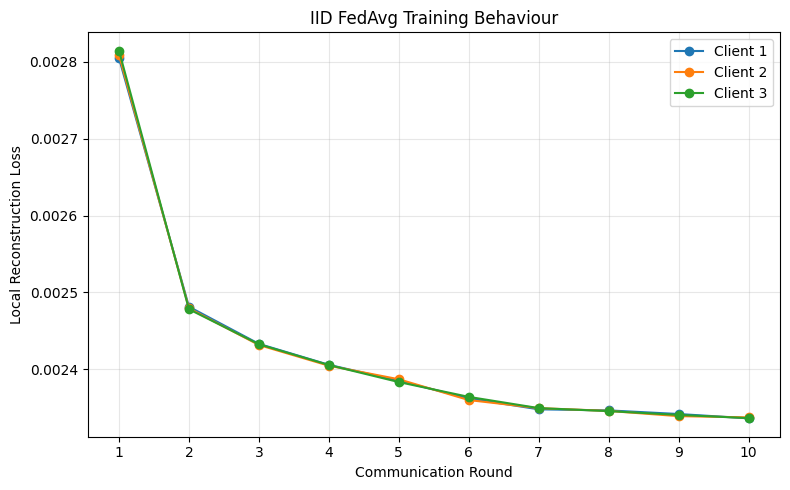

FedAvg training-loss figure saved successfully.


In [111]:
# Stage 5 - Step 13: Plot FedAvg client losses

fedavg_history_df = pd.DataFrame(fedavg_history)

plt.figure(figsize=(8, 5))

plt.plot(
    fedavg_history_df["round"],
    fedavg_history_df["Client_1_loss"],
    marker="o",
    label="Client 1"
)

plt.plot(
    fedavg_history_df["round"],
    fedavg_history_df["Client_2_loss"],
    marker="o",
    label="Client 2"
)

plt.plot(
    fedavg_history_df["round"],
    fedavg_history_df["Client_3_loss"],
    marker="o",
    label="Client 3"
)

plt.xlabel("Communication Round")
plt.ylabel("Local Reconstruction Loss")
plt.title("IID FedAvg Training Behaviour")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/kaggle/working/stage5_fedavg_training_loss.png",
    dpi=300
)

plt.show()

print("FedAvg training-loss figure saved successfully.")

### Step 13 : Result Interpretation

The FedAvg training-loss curves decreased across the 10 communication rounds.

All three clients followed almost identical loss trajectories, which is expected for the IID client split.

The reconstruction loss reduced from approximately **0.0028** to **0.00234**, showing stable federated adapter training.

questions:

1)Why do the three curves overlap?
Because the clients contain similarly distributed IID normal data.
2)What does the decreasing curve mean?
The adapter is improving on its self-supervised denoising objective.
3)Does lower reconstruction loss guarantee higher AUROC?
No. AUROC must be evaluated separately.
4)Why does the loss reduce more strongly at the beginning?
The model makes larger improvements during the early communication rounds and then gradually stabilizes.
5)Is this centralized training?
No. Each loss comes from local client training within FedAvg.

## Step 14 : FedAvg Communication Cost

Only the residual adapter parameters are communicated during FedAvg.

The adapter contains **98,816 parameters** stored as `float32`, where each value uses **4 bytes**.

For every communication round:

- server sends the global adapter to each client,
- each client returns its updated adapter.

Communication cost is calculated for all **3 clients across 10 rounds**.

ResNet18, images and local memory banks are not transmitted.

In [112]:
# Stage 5 - Step 14: Calculate FedAvg communication cost

adapter_bytes = sum(
    tensor.numel() * tensor.element_size()
    for tensor in global_adapter.state_dict().values()
)

bytes_per_client_per_round = adapter_bytes * 2   # download + upload

total_download_bytes = (
    adapter_bytes * len(clients) * NUM_ROUNDS
)

total_upload_bytes = (
    adapter_bytes * len(clients) * NUM_ROUNDS
)

total_communication_bytes = (
    total_download_bytes + total_upload_bytes
)

print("Adapter parameters:", final_adapter_params)
print("Datatype:", next(global_adapter.parameters()).dtype)
print("Adapter size:", adapter_bytes, "bytes")
print("Adapter size:", adapter_bytes / 1024, "KiB")
print(
    "Per client per round (upload + download):",
    bytes_per_client_per_round / (1024 ** 2),
    "MiB"
)
print(
    "Total download across 10 rounds:",
    total_download_bytes / (1024 ** 2),
    "MiB"
)
print(
    "Total upload across 10 rounds:",
    total_upload_bytes / (1024 ** 2),
    "MiB"
)
print(
    "Total FedAvg communication:",
    total_communication_bytes / (1024 ** 2),
    "MiB"
)


Adapter parameters: 98816
Datatype: torch.float32
Adapter size: 395264 bytes
Adapter size: 386.0 KiB
Per client per round (upload + download): 0.75390625 MiB
Total download across 10 rounds: 11.30859375 MiB
Total upload across 10 rounds: 11.30859375 MiB
Total FedAvg communication: 22.6171875 MiB


### Step 14 : Result Interpretation

The FedAvg adapter contains **98,816 float32 parameters**, requiring approximately **386 KiB** per transmission.

Across 3 clients and 10 communication rounds:

- Total download: **11.31 MiB**
- Total upload: **11.31 MiB**
- Total communication: **22.62 MiB**

Only adapter parameters are communicated. ResNet18, raw images and local memory banks are not transmitted.

questions:

1)Why is one adapter 395,264 bytes?
Because 98,816×4=395,264 bytes.
2)Why 4 bytes?
Each parameter uses float32.
3)Why multiply communication in both directions?
The server sends the global adapter and each client sends its updated adapter back.
4)What is the total communication?
Approximately 22.62 MiB across 10 rounds.
5)Does this include images or memory banks?
No. Only adapter parameters.


## Step 15 : Visualize FedAvg Anomaly Localization

A qualitative anomaly-localization example is created using the final IID FedAvg model.

The figure shows:

1. original test image,
2. ground-truth defect mask,
3. predicted anomaly map,
4. anomaly-map overlay.

The first anomalous test image is selected automatically for reproducibility.

No model training occurs.

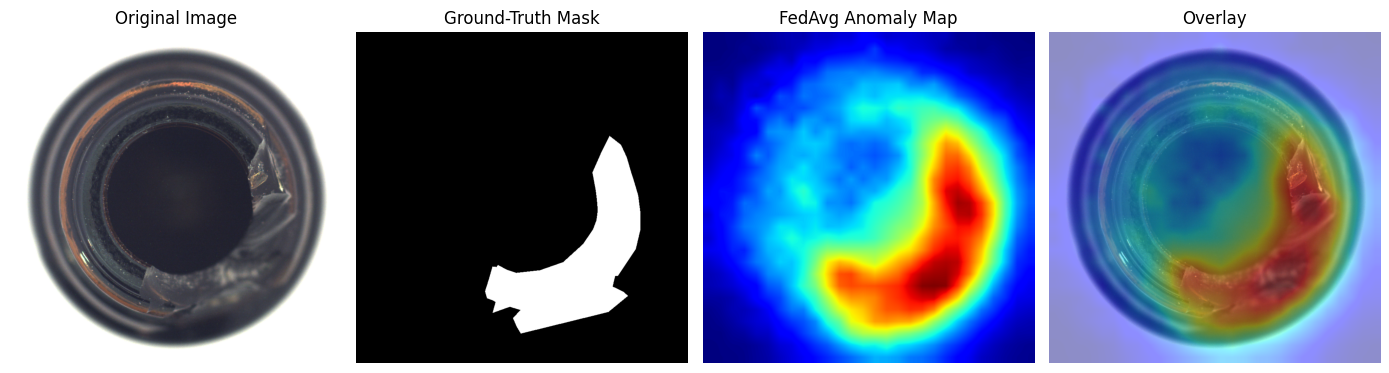

Example index: 0
Defect type: broken_large
FedAvg anomaly visualization saved successfully.


In [113]:
# Stage 5 - Step 15: Visualize one FedAvg anomaly example

# Select the first anomalous test image
example_index = np.where(
    np.array(fedavg_image_labels) == 1
)[0][0]

row = test_metadata.iloc[example_index]

# Load original image
original_image = Image.open(
    row["image_path"]
).convert("RGB")

# Load ground-truth mask
gt_mask = Image.open(
    row["mask_path"]
).convert("L")

# Get the stored 28 x 28 FedAvg anomaly map
anomaly_map_28 = fedavg_anomaly_maps[example_index]

# Resize anomaly map to original image size
anomaly_map_full = F.interpolate(
    anomaly_map_28.unsqueeze(0).unsqueeze(0),
    size=(original_image.height, original_image.width),
    mode="bilinear",
    align_corners=False
).squeeze().numpy()

# Create visualization
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground-Truth Mask")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(anomaly_map_full, cmap="jet")
plt.title("FedAvg Anomaly Map")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(original_image)
plt.imshow(anomaly_map_full, cmap="jet", alpha=0.45)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/stage5_fedavg_anomaly_example.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Example index:", example_index)
print("Defect type:", row["defect_type"])
print("FedAvg anomaly visualization saved successfully.")

### Step 15 : Result Interpretation

The qualitative FedAvg anomaly-localization example was generated successfully.

The selected anomalous test image was of defect type **broken_large**.

The predicted anomaly map assigns high scores to the defective region, and the overlay shows good alignment between the predicted anomaly region and the ground-truth mask.

This qualitative result supports the strong Pixel-level AUROC obtained for the IID FedAvg model.

questions:

1)Why is this image a good example?
It is the first anomalous test image, so the selection is reproducible.
2)What does the red region mean?
It indicates higher anomaly scores.
3)Does the anomaly map exactly equal the ground-truth mask?
No. It is a continuous score map, not a binary segmentation mask.
4)Why is the map smooth?
Because the raw anomaly scores come from a 28×28 patch grid and are resized for visualization.
5)What does this figure prove?
It shows that the FedAvg model can localize the anomalous region visually.


## Step 16A : Standardize Stage 3 Pixel-AUROC

Before comparing Stages 3, 4 and 5, Stage 3 Pixel-AUROC is recalculated at the common \(224 \times 224\) resolution.

The original Stage 3 anomaly maps are reused. No model is retrained and no anomaly scores are changed.

This ensures that all Pixel-AUROC values in the final comparison use the same evaluation resolution.

In [114]:
# Stage 5 - Step 16A: Recalculate Stage 3 Pixel-AUROC at 224 x 224

stage3_pixel_scores_224 = np.empty(
    common_pixel_labels_224.shape,
    dtype=np.float32
)

pixel_offset = 0

for anomaly_map_28 in stage3_test_anomaly_maps:

    anomaly_map_224 = F.interpolate(
        anomaly_map_28.float().unsqueeze(0).unsqueeze(0),
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    ).squeeze().numpy()

    next_offset = pixel_offset + (224 * 224)

    stage3_pixel_scores_224[
        pixel_offset:next_offset
    ] = anomaly_map_224.reshape(-1)

    pixel_offset = next_offset


stage3_pixel_auroc_224 = roc_auc_score(
    common_pixel_labels_224,
    stage3_pixel_scores_224
)

print("Stage 3 standardized Pixel-AUROC:", f"{stage3_pixel_auroc_224:.6f}")
print("Evaluated pixels:", pixel_offset)
print("Expected pixels:", len(common_pixel_labels_224))

assert pixel_offset == len(common_pixel_labels_224)

print("\nStage 3 Pixel-AUROC standardized successfully.")

Stage 3 standardized Pixel-AUROC: 0.982275
Evaluated pixels: 4164608
Expected pixels: 4164608

Stage 3 Pixel-AUROC standardized successfully.


### Step 16A : Result Interpretation

Stage 3 Pixel-AUROC was successfully recalculated at the common \(224 \times 224\) resolution.

The standardized result is:

- **Pixel-AUROC: 0.982275**
- Evaluated pixels: **4,164,608**

This allows Stage 3 to be compared fairly with Stage 4 and Stage 5 using the same pixel-level evaluation protocol.

questions:

1)Why did Stage 3 change slightly?
Because the original evaluation used a different spatial resolution.
2)Was Stage 3 retrained?
No. Only the stored anomaly maps were reevaluated.
3)Why exactly 4,164,608 pixels?
Because 83×224×224=4,164,608.
4)Can we now compare Stage 3 and Stage 5 Pixel-AUROC?
Yes. Both now use the same 224×224 protocol.

## Step 16B : Compare Centralized, Local and FedAvg Results

The standardized Stage 3 centralized adapter, Stage 4 independent local clients, and Stage 5 IID FedAvg are now compared.

All Pixel-AUROC values use the same \(224 \times 224\) evaluation protocol.

Stage 4 represents independent local training with no aggregation, while Stage 5 represents the first federated FedAvg experiment.

In [115]:
# Stage 5 - Step 16B: Compare Stage 3, Stage 4 and Stage 5

stage4_image_values = np.array([
    clients["Client_1"]["image_auroc"],
    clients["Client_2"]["image_auroc"],
    clients["Client_3"]["image_auroc"]
])

stage4_pixel_values = np.array([
    clients["Client_1"]["pixel_auroc"],
    clients["Client_2"]["pixel_auroc"],
    clients["Client_3"]["pixel_auroc"]
])

comparison_table = pd.DataFrame({
    "Experiment": [
        "Stage 3 Centralized",
        "Stage 4 Local Mean",
        "Stage 5 IID FedAvg Mean"
    ],
    "Image AUROC": [
        stage3_image_auroc,
        stage4_image_values.mean(),
        fedavg_mean_image_auroc
    ],
    "Pixel AUROC": [
        stage3_pixel_auroc_224,
        stage4_pixel_values.mean(),
        fedavg_mean_pixel_auroc
    ]
})

display(comparison_table.round(6))

print("\nStage 4 Image std:", f"{stage4_image_values.std():.6f}")
print("Stage 4 Pixel std:", f"{stage4_pixel_values.std():.6f}")

print("Stage 5 Image std:", f"{fedavg_std_image_auroc:.6f}")
print("Stage 5 Pixel std:", f"{fedavg_std_pixel_auroc:.6f}")

,Experiment,Image AUROC,Pixel AUROC
0,Stage 3 Centralized,1.000000,0.982275
1,Stage 4 Local Mean,0.997619,0.981931
2,Stage 5 IID FedAvg Mean,0.997619,0.981983



Stage 4 Image std: 0.001296
Stage 4 Pixel std: 0.000056
Stage 5 Image std: 0.001296
Stage 5 Pixel std: 0.000069


### Step 16B : Result Interpretation

The centralized, local and IID FedAvg experiments were compared using the same Pixel-AUROC resolution.

Results:

- **Stage 3 Centralized:** Image 1.000000, Pixel 0.982275
- **Stage 4 Local Mean:** Image 0.997619, Pixel 0.981931
- **Stage 5 IID FedAvg:** Image 0.997619, Pixel 0.981983

FedAvg maintained almost the same anomaly-detection performance as independent local training and remained very close to the centralized adapter.

The small standard deviations also show consistent performance across the three IID clients.

questions:

1)Did FedAvg improve over Stage 4?
Not meaningfully. Their results are essentially comparable.
2)Why are Stage 4 and Stage 5 Image-AUROC exactly the same?
The adapter parameters changed, but the ranking of test-image anomaly scores can remain unchanged.
3)Did federation reduce performance compared with centralized training?
Only slightly. Stage 3 achieved 1.0 Image-AUROC, while Stage 5 achieved about 0.9976.
4)What is the important finding?
IID FedAvg maintained strong centralized/local performance while federating only the small residual adapter and keeping normal memory banks local.


## Step 17 —: Stage 5 Final Summary

IID FedAvg was successfully implemented using three clients.

The final results were:

- **10 communication rounds**
- **98,816 federated adapter parameters**
- **Image AUROC:** 0.997619 ± 0.001296
- **Pixel AUROC:** 0.981983 ± 0.000069
- **Total communication:** 22.62 MiB

FedAvg maintained performance close to centralized and independent local training while only the residual adapter parameters were federated.

ResNet18 remained frozen and the normal memory banks remained local

In [116]:
# Stage 5 - Step 17: Save final Stage 5 results

stage5_summary = pd.DataFrame({
    "Metric": [
        "Communication Rounds",
        "Adapter Parameters",
        "Image AUROC Mean",
        "Image AUROC Std",
        "Pixel AUROC Mean",
        "Pixel AUROC Std",
        "Communication MiB"
    ],
    "Value": [
        NUM_ROUNDS,
        final_adapter_params,
        fedavg_mean_image_auroc,
        fedavg_std_image_auroc,
        fedavg_mean_pixel_auroc,
        fedavg_std_pixel_auroc,
        total_communication_bytes / (1024 ** 2)
    ]
})

stage5_summary.to_csv(
    "/kaggle/working/stage5_iid_fedavg_summary.csv",
    index=False
)

fedavg_history_df.to_csv(
    "/kaggle/working/stage5_fedavg_history.csv",
    index=False
)

display(stage5_summary)

print("\nStage 5 results saved successfully.")

,Metric,Value
0,Communication Rounds,10.000000
1,Adapter Parameters,98816.000000
2,Image AUROC Mean,0.997619
3,Image AUROC Std,0.001296
4,Pixel AUROC Mean,0.981983
5,Pixel AUROC Std,0.000069
6,Communication MiB,22.617188



Stage 5 results saved successfully.


### Step 17 : Result Interpretation

Stage 5 results were saved successfully.

The IID FedAvg experiment achieved:

- **Image AUROC:** 0.997619 ± 0.001296
- **Pixel AUROC:** 0.981983 ± 0.000069
- **Communication cost:** 22.62 MiB across 10 rounds

The results confirm that federating only the residual adapter maintained strong anomaly-detection performance while ResNet18 remained frozen and local memory banks stayed separate.

### Stage 6 — Step 1: Verify Existing Client Data Structure

Stage 6 reuses the same three clients created in Stages 4 and 5. Before introducing domain shift, the existing client dictionary is inspected to identify the exact locally stored training-image variables and confirm that no previous federated components are unnecessarily recreated.

No data or model is modified in this step.

In [117]:
# Stage 6 - Step 1: Inspect the existing Stage 5 client structure

print("Type of clients:", type(clients))
print("Client names:", list(clients.keys()))

for client_name, client_data in clients.items():
    print(f"\n--- {client_name} ---")
    print("Type:", type(client_data))

    if isinstance(client_data, dict):
        print("Stored keys:", list(client_data.keys()))

        for key, value in client_data.items():
            if hasattr(value, "shape"):
                print(f"{key}: shape = {value.shape}")
            elif hasattr(value, "__len__") and not isinstance(value, str):
                print(f"{key}: length = {len(value)}")
            else:
                print(f"{key}: {type(value)}")

Type of clients: <class 'dict'>
Client names: ['Client_1', 'Client_2', 'Client_3']

--- Client_1 ---
Type: <class 'dict'>
Stored keys: ['target_images', 'image_indices', 'image_paths', 'adapter', 'training_history', 'local_memory_bank', 'full_adapted_patch_count', 'image_scores', 'image_labels', 'anomaly_maps', 'image_auroc', 'pixel_auroc', 'patch_features', 'train_loader', 'fedavg_memory_bank', 'fedavg_full_patch_count']
target_images: <class 'int'>
image_indices: length = 70
image_paths: length = 70
adapter: <class '__main__.ResidualAdapter'>
training_history: length = 10
local_memory_bank: shape = torch.Size([5488, 384])
full_adapted_patch_count: <class 'int'>
image_scores: length = 83
image_labels: length = 83
anomaly_maps: length = 83
image_auroc: shape = ()
pixel_auroc: shape = ()
patch_features: shape = torch.Size([54880, 384])
train_loader: length = 108
fedavg_memory_bank: shape = torch.Size([5488, 384])
fedavg_full_patch_count: <class 'int'>

--- Client_2 ---
Type: <class 'dic

### Step 1 : Result Interpretation

The existing Stage 5 client structure was successfully verified. The three clients contain **70, 70, and 69 normal training images**, preserving the original IID partition.

Each client stores its own image paths, patch features, adapter, training history and local memory bank. Stage 6 will therefore reuse these same client assignments and apply domain shift to the normal training images before extracting new patch features. No Stage 5 data or model is modified in this step.

### Stage 6 : Step 2: Define Non-IID Client Domains

To simulate differences between factory imaging environments, each client is assigned one fixed acquisition condition. Client 1 keeps the original appearance, Client 2 receives a mild brightness and contrast shift, and Client 3 receives mild Gaussian blur.

These transformations will later be applied only to each client's normal training images. The client assignments and shared test set remain unchanged.

In [118]:
# Stage 6 - Step 2: Define deterministic client domain shifts

from torchvision.transforms import functional as TF

NONIID_DOMAIN_CONFIG = {
    "Client_1": "Original",
    "Client_2": "Brightness + Contrast",
    "Client_3": "Mild Gaussian Blur"
}

def apply_domain_shift(image, client_name):
    if client_name == "Client_1":
        return image

    elif client_name == "Client_2":
        image = TF.adjust_brightness(image, brightness_factor=1.15)
        image = TF.adjust_contrast(image, contrast_factor=1.10)
        return image

    elif client_name == "Client_3":
        return TF.gaussian_blur(
            image,
            kernel_size=[5, 5],
            sigma=[1.0, 1.0]
        )

    else:
        raise ValueError(f"Unknown client: {client_name}")

assert set(NONIID_DOMAIN_CONFIG.keys()) == set(clients.keys())

for client_name, domain in NONIID_DOMAIN_CONFIG.items():
    print(f"{client_name}: {domain}")

Client_1: Original
Client_2: Brightness + Contrast
Client_3: Mild Gaussian Blur


### Stage 6: Step 2 : Result Interpretation

Three deterministic client domains were successfully defined for the Non-IID experiment. Client 1 retains the original image appearance, Client 2 represents a mild lighting variation through brightness and contrast changes, and Client 3 represents mild acquisition degradation through Gaussian blur.

These transformations create controlled client heterogeneity while keeping the original 70/70/69 client split unchanged. No test images or anomaly labels are modified at this stage.

### Stage 6 : Step 3: Visual Verification of Client Domains

One normal training image from each client is inspected before and after applying its assigned domain transformation. This verifies that the simulated Non-IID differences are mild, visible and consistent with different factory imaging conditions.

The original client assignments remain unchanged, and no anomalous test data is used.

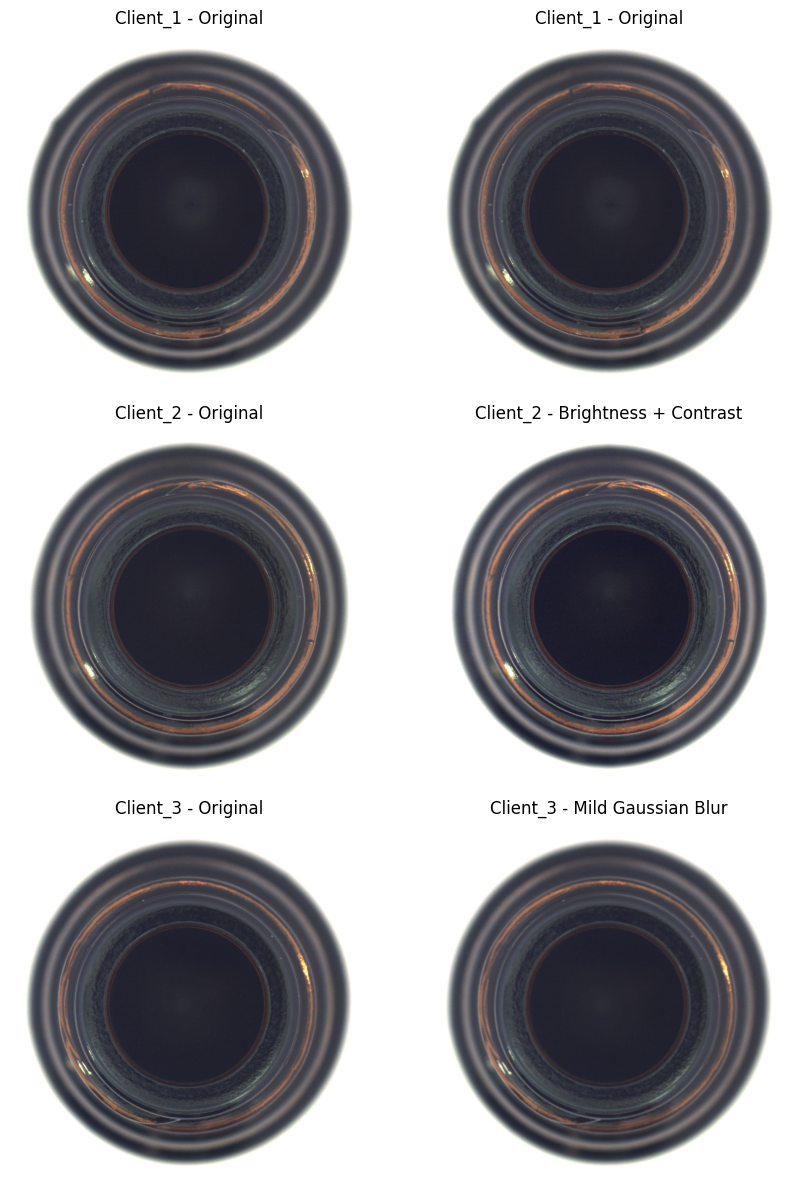

Client image counts:
Client_1 : 70
Client_2 : 70
Client_3 : 69


In [119]:
# Stage 6 - Step 3: Visual verification of Non-IID client domains

from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(9, 12))

for row, client_name in enumerate(["Client_1", "Client_2", "Client_3"]):

    image_path = clients[client_name]["image_paths"][0]

    original_image = Image.open(image_path).convert("RGB")
    shifted_image = apply_domain_shift(original_image, client_name)

    axes[row, 0].imshow(original_image)
    axes[row, 0].set_title(f"{client_name} - Original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(shifted_image)
    axes[row, 1].set_title(
        f"{client_name} - {NONIID_DOMAIN_CONFIG[client_name]}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

print("Client image counts:")
for client_name in ["Client_1", "Client_2", "Client_3"]:
    print(client_name, ":", len(clients[client_name]["image_paths"]))

### Stage 6: Step 3 — Result Interpretation

The client-domain transformations were visually verified and were found to be mild and realistic. Client 1 retained the original appearance, Client 2 showed a small brightness/contrast change, and Client 3 showed slight image blur.

The client sizes remained unchanged at 70, 70 and 69 images, confirming that the Non-IID domain simulation changed only image appearance and did not alter the original client partition.

### Stage 6 : Step 4: Verify Existing Feature-Extraction Objects

Before extracting Non-IID training features, the existing notebook objects used for ResNet18 preprocessing and patch-feature extraction are identified.

This ensures Stage 6 reuses the exact Stage 2–5 feature pipeline instead of creating a new or inconsistent extractor.

In [120]:
# Stage 6 - Step 4: Find existing feature-extraction objects

import inspect
import torch

keywords = ["patch", "feature", "transform", "resnet"]

candidate_names = [
    name for name in globals()
    if any(word in name.lower() for word in keywords)
]

print("Relevant existing notebook objects:")
print("-" * 50)

for name in sorted(candidate_names):
    obj = globals()[name]

    if (
        inspect.isfunction(obj)
        or isinstance(obj, torch.nn.Module)
        or "transform" in name.lower()
    ):
        print(f"{name:<35} -> {type(obj)}")

Relevant existing notebook objects:
--------------------------------------------------
create_feature_extractor            -> <class 'function'>
extract_feature                     -> <class 'function'>
extract_patch_embeddings_from_batch -> <class 'function'>
feature_extractor                   -> <class 'torch.nn.modules.container.Sequential'>
image_transform                     -> <class 'torchvision.transforms.transforms.Compose'>
patch_feature_extractor             -> <class 'torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl'>
patchcore_transform                 -> <class 'torchvision.transforms.transforms.Compose'>
resnet18                            -> <class 'function'>
resnet18_backbone                   -> <class 'torchvision.models.resnet.ResNet'>
transforms                          -> <class 'module'>


### Stage 6 : Step 4  Result Interpretation

The existing Stage 2–5 feature-extraction objects were successfully identified. The notebook already contains the PatchCore-style `patch_feature_extractor`, its preprocessing transform, and the helper function used to construct patch embeddings.

Therefore, Stage 6 can reuse the same frozen ResNet18 patch pipeline without introducing a new backbone or changing the feature representation. This keeps the methodology consistent with the previous stages.

### Stage 6 : Step 5: Extract Non-IID Client Patch Features

The fixed domain transformation assigned to each client is now applied to its normal training images before feature extraction. The transformed images are processed using the same frozen ResNet18 PatchCore-style feature pipeline used in the previous stages.

The original Stage 5 patch features are preserved. Stage 6 stores the new domain-shifted representations separately so that the IID and Non-IID experiments remain independent and directly comparable.

In [121]:
# Stage 6 - Step 5: Extract Non-IID patch features

NONIID_BATCH_SIZE = 8

# Use the same device as the existing patch feature extractor
extractor_device = next(patch_feature_extractor.parameters()).device

print("Patch extractor device:", extractor_device)

for client_name in ["Client_1", "Client_2", "Client_3"]:

    all_patch_features = []
    image_paths = clients[client_name]["image_paths"]

    for start in range(0, len(image_paths), NONIID_BATCH_SIZE):

        batch_paths = image_paths[start:start + NONIID_BATCH_SIZE]
        batch_images = []

        for image_path in batch_paths:
            image = Image.open(image_path).convert("RGB")

            # Apply client's fixed domain shift
            image = apply_domain_shift(image, client_name)

            # Reuse existing PatchCore preprocessing
            image = patchcore_transform(image)

            batch_images.append(image)

        # Stack images and move them to the SAME device as ResNet18
        batch_tensor = torch.stack(batch_images).to(extractor_device)

        # Existing Stage 2-5 patch extraction function
        patch_features = extract_patch_embeddings_from_batch(batch_tensor)

        if patch_features.ndim == 3:
            patch_features = patch_features.reshape(
                -1,
                patch_features.shape[-1]
            )

        all_patch_features.append(
            patch_features.detach().cpu()
        )

    clients[client_name]["noniid_patch_features"] = torch.cat(
        all_patch_features,
        dim=0
    )

    expected_patches = len(image_paths) * 784
    actual_shape = clients[client_name]["noniid_patch_features"].shape

    assert actual_shape == (expected_patches, 384)

    print(
        f"{client_name}: "
        f"{len(image_paths)} images -> {actual_shape}"
    )

Patch extractor device: cuda:0
Client_1: 70 images -> torch.Size([54880, 384])
Client_2: 70 images -> torch.Size([54880, 384])
Client_3: 69 images -> torch.Size([54096, 384])


### Stage 6: Step 5 — Result Interpretation

The Non-IID patch features were successfully extracted for all three clients using the existing frozen ResNet18 PatchCore-style feature pipeline.

The resulting feature sizes were 54,880 patches for Client 1, 54,880 for Client 2, and 54,096 for Client 3, with each patch represented by 384 features. These dimensions exactly match the original 70/70/69 client split, confirming that the domain shifts changed only the image appearance and did not alter the client data sizes or patch structure.

### Stage 6 : Step 6: Create Non-IID Client Training Loaders

The newly extracted Non-IID patch features are now placed into separate client DataLoaders for local adapter training.

The same batch size and training structure used in Stage 5 are preserved, so the main experimental change remains the client data distribution rather than the optimization setup.

In [122]:
# Stage 6 - Step 6: Create Non-IID client training loaders

from torch.utils.data import TensorDataset, DataLoader

NONIID_BATCH_SIZE = clients["Client_1"]["train_loader"].batch_size

for client_name in ["Client_1", "Client_2", "Client_3"]:

    noniid_features = clients[client_name]["noniid_patch_features"]

    noniid_dataset = TensorDataset(noniid_features)

    clients[client_name]["noniid_train_loader"] = DataLoader(
        noniid_dataset,
        batch_size=NONIID_BATCH_SIZE,
        shuffle=True
    )

    loader = clients[client_name]["noniid_train_loader"]
    first_batch = next(iter(loader))[0]

    print(
        f"{client_name}: "
        f"patches={len(noniid_dataset)}, "
        f"batches={len(loader)}, "
        f"batch_size={loader.batch_size}, "
        f"first_batch={first_batch.shape}"
    )

Client_1: patches=54880, batches=108, batch_size=512, first_batch=torch.Size([512, 384])
Client_2: patches=54880, batches=108, batch_size=512, first_batch=torch.Size([512, 384])
Client_3: patches=54096, batches=106, batch_size=512, first_batch=torch.Size([512, 384])


### Stage 6: Step 6 : Result Interpretation

The Non-IID client training loaders were created successfully using the same batch size of 512 patches as Stage 5.

Clients 1 and 2 each contain 54,880 patch features across 108 batches, while Client 3 contains 54,096 patch features across 106 batches. The feature dimension remains 384 for all clients. This confirms that the local training structure is unchanged and only the client-domain distributions differ from the IID experiment.

### Stage 6 : Step 7: Verify Existing FedAvg Components

Stage 6 will reuse the existing Stage 5 federated-learning framework. Therefore, the current notebook is inspected to identify the exact local-training function, FedAvg aggregation function, and federated-training settings.

No training occurs in this step and no Stage 5 object is modified.

In [123]:
# Stage 6 - Step 7: Inspect existing Stage 5 FedAvg components

import inspect

keywords = [
    "fedavg",
    "aggregate",
    "local",
    "train",
    "round",
    "epoch",
    "noise",
    "learning",
    "lr"
]

print("Existing Stage 5 FedAvg-related objects:")
print("-" * 55)

for name in sorted(globals()):

    if any(word in name.lower() for word in keywords):

        obj = globals()[name]

        if inspect.isfunction(obj):
            print(f"{name:<35} -> function")

        elif isinstance(obj, (int, float)):
            print(f"{name:<35} -> {obj}")

Existing Stage 5 FedAvg-related objects:
-------------------------------------------------------
LEARNING_RATE                       -> 0.001
LOCAL_EPOCHS                        -> 1
LOCAL_MEMORY_FRACTION               -> 0.1
NOISE_STD                           -> 0.05
NUM_EPOCHS                          -> 10
NUM_ROUNDS                          -> 10
adapter_trainable                   -> 98816
bytes_per_client_per_round          -> 790528
epoch                               -> 9
epoch_loss                          -> 0.0022856461201777984
fedavg_aggregate                    -> function
fedavg_client1_image_auroc          -> 0.996031746031746
fedavg_client1_pixel_auroc          -> 0.9820517237381564
fedavg_client2_image_auroc          -> 0.9976190476190476
fedavg_client2_pixel_auroc          -> 0.9818882808119794
fedavg_client3_image_auroc          -> 0.9992063492063492
fedavg_client3_pixel_auroc          -> 0.982007778009554
fedavg_mean_image_auroc             -> 0.9976190476190476
f

### Stage 6: Step 7 : Result Interpretation

The existing Stage 5 federated-learning components were successfully identified. Stage 6 can therefore reuse the same `train_fedavg_client` local-training function, `fedavg_aggregate` aggregation function, learning rate, noise level, local epochs and communication-round settings.

The residual adapter remains the only trainable and federated component with 98,816 parameters, while ResNet18 remains fully frozen with zero trainable parameters. This ensures that the main experimental change in Stage 6 is the Non-IID client data distribution.

### Stage 6 : Step 8: Verify FedAvg Function Inputs and Initialization

The exact interfaces of the existing Stage 5 local-training and aggregation functions are inspected before running the Non-IID experiment.

The available saved adapter states are also checked so that Non-IID FedAvg can use the same appropriate initialization rather than unintentionally continuing from the completed IID FedAvg model.

In [124]:
# Stage 6 - Step 8: Inspect exact FedAvg signatures and saved adapter states

import inspect

print("train_fedavg_client signature:")
print(inspect.signature(train_fedavg_client))

print("\nfedavg_aggregate signature:")
print(inspect.signature(fedavg_aggregate))

print("\nPossible saved adapter/state objects:")
print("-" * 50)

for name in sorted(globals()):
    lower_name = name.lower()

    if any(word in lower_name for word in [
        "initial", "state", "adapter_state",
        "stage3", "centralized_adapter"
    ]):
        obj = globals()[name]

        if isinstance(obj, dict):
            keys = list(obj.keys())

            if any(
                key in keys
                for key in ["fc1.weight", "fc2.weight", "fc1.bias", "fc2.bias"]
            ):
                print(name, "-> adapter state_dict")

        elif isinstance(obj, torch.nn.Module):
            print(name, "->", type(obj))

train_fedavg_client signature:
(global_state, train_loader, seed)

fedavg_aggregate signature:
(client_states, client_weights)

Possible saved adapter/state objects:
--------------------------------------------------
adapter_initial_state -> adapter state_dict
common_initial_adapter -> <class '__main__.ResidualAdapter'>
current_adapter_state -> adapter state_dict
initial_adapter_cpu_state -> adapter state_dict
trained_adapter_cpu_state -> adapter state_dict


### Stage 6: Step 8 : Result Interpretation

The exact Stage 5 FedAvg function interfaces were successfully identified. Local training uses `train_fedavg_client(global_state, train_loader, seed)`, while server aggregation uses `fedavg_aggregate(client_states, client_weights)`.

Several saved adapter states are available in the notebook. These will be checked before Stage 6 training so that Non-IID FedAvg starts from the same appropriate common initialization as the previous federated experiment rather than from an already-trained final adapter.

### Stage 6 : Step 9: Verify Federated Initialization

A fair comparison requires Stage 5 IID FedAvg, Stage 6 Non-IID FedAvg, and later FedProx to start from the same adapter parameters.

The available saved adapter states are therefore compared directly. No training or parameter update occurs in this step.

In [125]:
# Stage 6 - Step 9: Check saved adapter states

states_to_check = {
    "adapter_initial_state": adapter_initial_state,
    "common_initial_adapter": common_initial_adapter.state_dict(),
    "initial_adapter_cpu_state": initial_adapter_cpu_state,
    "current_adapter_state": current_adapter_state,
    "trained_adapter_cpu_state": trained_adapter_cpu_state,
}

for name, state in states_to_check.items():
    print(f"\n{name}")
    for key, value in state.items():
        if torch.is_tensor(value):
            print(key, tuple(value.shape))


adapter_initial_state
fc1.weight (128, 384)
fc1.bias (128,)
fc2.weight (384, 128)
fc2.bias (384,)

common_initial_adapter
adapter.0.weight (128, 384)
adapter.0.bias (128,)
adapter.2.weight (384, 128)
adapter.2.bias (384,)

initial_adapter_cpu_state
fc1.weight (128, 384)
fc1.bias (128,)
fc2.weight (384, 128)
fc2.bias (384,)

current_adapter_state
fc1.weight (128, 384)
fc1.bias (128,)
fc2.weight (384, 128)
fc2.bias (384,)

trained_adapter_cpu_state
fc1.weight (128, 384)
fc1.bias (128,)
fc2.weight (384, 128)
fc2.bias (384,)


### Step 9 : Result Interpretation

The saved adapter states were inspected successfully. They represent the same 384→128→384 residual-adapter structure, although some objects use different internal parameter names.

For the Stage 6 experiments, `adapter_initial_state` will be reused as the common starting point. This avoids continuing from an already-trained Stage 5 adapter and keeps the Non-IID FedAvg and FedProx comparison fair.

### Stage 6 : Step 10: Confirm FedAvg Function Outputs

The existing Stage 5 FedAvg functions will be reused directly for the Non-IID experiment. Their return statements are inspected so that the first federated round can use the exact existing outputs without rewriting the training logic.

In [126]:
# Stage 6 - Step 10: Check existing FedAvg return values

import inspect

for func in [train_fedavg_client, fedavg_aggregate]:

    print(f"\n{func.__name__}")
    print("-" * 40)

    source = inspect.getsource(func)

    for line in source.splitlines():
        if "return" in line:
            print(line.strip())


train_fedavg_client
----------------------------------------
return local_state, mean_loss

fedavg_aggregate
----------------------------------------
return aggregated_state


### Step 10 : Result Interpretation

The existing Stage 5 FedAvg functions were verified successfully. Local client training returns the updated adapter state together with the mean reconstruction loss, while the server aggregation function returns the new weighted global adapter state.

These outputs are sufficient to reuse the same Stage 5 federated loop for the Non-IID experiment without changing the training methodology.

1. What does local_state contain?
The locally trained adapter parameters.
2. What does mean_loss represent?
The average local self-supervised reconstruction loss for that client.
3. What does aggregated_state contain?
The new global adapter parameters after FedAvg.
4. Are raw images returned to the server?
No.
5. Are memory banks aggregated here?
No. Only adapter parameters are aggregated.

### Stage 6 : Step 11: First Non-IID FedAvg Communication Round

The first Non-IID FedAvg round is now performed using the same residual adapter, local denoising objective, optimizer settings and weighted aggregation procedure as Stage 5.

Each client trains for one local epoch using only its own domain-shifted normal patch features. The resulting adapter parameters are then combined by weighted FedAvg. No raw images, patch features or memory banks are communicated.

In [129]:
# Stage 6 - Step 6: Correct Non-IID client training loaders

NONIID_BATCH_SIZE = clients["Client_1"]["train_loader"].batch_size

for client_name in ["Client_1", "Client_2", "Client_3"]:

    noniid_features = clients[client_name]["noniid_patch_features"]

    clients[client_name]["noniid_train_loader"] = DataLoader(
        noniid_features,
        batch_size=NONIID_BATCH_SIZE,
        shuffle=True
    )

    first_batch = next(
        iter(clients[client_name]["noniid_train_loader"])
    )

    print(
        f"{client_name}: "
        f"patches={len(noniid_features)}, "
        f"batches={len(clients[client_name]['noniid_train_loader'])}, "
        f"first_batch={first_batch.shape}"
    )

Client_1: patches=54880, batches=108, first_batch=torch.Size([512, 384])
Client_2: patches=54880, batches=108, first_batch=torch.Size([512, 384])
Client_3: patches=54096, batches=106, first_batch=torch.Size([512, 384])


### Step 6 : Result Interpretation

The Non-IID training loaders were successfully corrected to return patch-feature tensors directly. Each training batch now has shape `[512, 384]`, which matches the input expected by the existing Stage 5 local-training function.

The client data sizes remain unchanged at 54,880, 54,880 and 54,096 patches, so the 70/70/69 client partition is preserved.

### Stage 6 : Step 11: First Non-IID FedAvg Round

The first Non-IID FedAvg communication round is performed using the same Stage 5 local-training and weighted-aggregation functions.

Each client trains the residual adapter for one local epoch using only its own domain-shifted normal patch features. Only adapter parameters are aggregated; ResNet18 remains frozen and local memory banks are not communicated.

In [131]:
# Stage 6 - Step 11: First Non-IID FedAvg round

import copy

client_names = ["Client_1", "Client_2", "Client_3"]

patch_counts = {
    name: len(clients[name]["noniid_patch_features"])
    for name in client_names
}

total_patches = sum(patch_counts.values())

noniid_client_weights = {
    name: patch_counts[name] / total_patches
    for name in client_names
}

noniid_fedavg_global_state = copy.deepcopy(
    common_initial_adapter_state
)

round1_states = {}
noniid_fedavg_losses = {name: [] for name in client_names}

for i, client_name in enumerate(client_names):

    local_state, mean_loss = train_fedavg_client(
        noniid_fedavg_global_state,
        clients[client_name]["noniid_train_loader"],
        seed=1000 + i
    )

    round1_states[client_name] = local_state
    noniid_fedavg_losses[client_name].append(mean_loss)

    print(
        f"{client_name}: "
        f"weight={noniid_client_weights[client_name]:.6f}, "
        f"loss={mean_loss:.8f}"
    )

noniid_fedavg_global_state = fedavg_aggregate(
    round1_states,
    noniid_client_weights
)

print("\nNon-IID FedAvg Round 1 completed successfully.")

Client_1: weight=0.334928, loss=0.00281126
Client_2: weight=0.334928, loss=0.00281390
Client_3: weight=0.330144, loss=0.00281438

Non-IID FedAvg Round 1 completed successfully.


### Step 11 —: Result Interpretation

The first Non-IID FedAvg communication round completed successfully. Each client performed one local epoch of self-supervised adapter training on its own domain-shifted normal patch features, after which the updated adapter parameters were combined using weighted FedAvg.

The three local reconstruction losses were very similar, indicating stable training under the mild simulated domain shifts. This is expected because the client domains differ only moderately, while the residual adapter architecture and optimization settings remain unchanged.

1. Did Non-IID training fail because the losses are similar?
No. Similar losses simply mean the mild domain shifts did not create extreme optimization differences.
2. Was the server averaging successful?
Yes.
3. Was ResNet18 updated?
No. It remained frozen.
4. Were memory banks communicated?
No.
5. What is the main difference from Stage 5?
The clients now train on different visual domains.

### Stage 6 : Step 12: Complete Non-IID FedAvg Training

The remaining Non-IID FedAvg communication rounds are now completed using the global adapter obtained after Round 1.

For every round, each client receives the current global adapter, performs one local epoch using its own domain-shifted normal features, and returns only its updated adapter parameters for weighted aggregation. Client losses are stored for later convergence analysis.

In [132]:
# Stage 6 - Step 12: Complete Non-IID FedAvg rounds 2-10

for round_number in range(2, NUM_ROUNDS + 1):

    round_states = {}

    print(f"\nRound {round_number}/{NUM_ROUNDS}")

    for i, client_name in enumerate(client_names):

        local_state, mean_loss = train_fedavg_client(
            noniid_fedavg_global_state,
            clients[client_name]["noniid_train_loader"],
            seed=1000 * round_number + i
        )

        round_states[client_name] = local_state
        noniid_fedavg_losses[client_name].append(mean_loss)

        print(
            f"{client_name}: loss={mean_loss:.8f}"
        )

    noniid_fedavg_global_state = fedavg_aggregate(
        round_states,
        noniid_client_weights
    )

print("\nNon-IID FedAvg training completed.")
print("Rounds completed:", NUM_ROUNDS)


Round 2/10
Client_1: loss=0.00247244
Client_2: loss=0.00246802
Client_3: loss=0.00246864

Round 3/10
Client_1: loss=0.00242940
Client_2: loss=0.00242561
Client_3: loss=0.00242554

Round 4/10
Client_1: loss=0.00237999
Client_2: loss=0.00238952
Client_3: loss=0.00238313

Round 5/10
Client_1: loss=0.00236180
Client_2: loss=0.00236352
Client_3: loss=0.00236022

Round 6/10
Client_1: loss=0.00235239
Client_2: loss=0.00235343
Client_3: loss=0.00235039

Round 7/10
Client_1: loss=0.00234714
Client_2: loss=0.00234754
Client_3: loss=0.00234657

Round 8/10
Client_1: loss=0.00234437
Client_2: loss=0.00234591
Client_3: loss=0.00234193

Round 9/10
Client_1: loss=0.00234095
Client_2: loss=0.00234343
Client_3: loss=0.00234122

Round 10/10
Client_1: loss=0.00234003
Client_2: loss=0.00234018
Client_3: loss=0.00233724

Non-IID FedAvg training completed.
Rounds completed: 10


### Step 12 : Result Interpretation

The Non-IID FedAvg training completed successfully over 10 communication rounds. Local reconstruction loss decreased steadily for all three clients, showing stable convergence under the simulated domain shift.

The final losses remained very similar across clients, indicating that the mild brightness/contrast and blur shifts introduced heterogeneity without causing unstable local optimization. The residual adapter remained the only trainable federated component, while ResNet18 stayed frozen.

1. Did the losses converge?
Yes. They decreased consistently across the 10 rounds.
2. Why are the client losses still similar?
Because the simulated domain shifts are intentionally mild.
3. Does lower reconstruction loss automatically mean better AUROC?
No. We still need to evaluate anomaly detection performance separately.
4. Did FedAvg remove the domain shift?
Not necessarily. It learned one shared adapter from heterogeneous clients.
5. What should we do next?
Build each client's local normal memory bank using the final Non-IID FedAvg adapter, then evaluate Image AUROC and Pixel AUROC.

### Stage 6 : Step 13: Build Local Non-IID FedAvg Memory Banks

The final Non-IID FedAvg adapter is now applied to each client's own normal patch features. Each client then creates a private memory bank using the same fixed-seed 10% random reduction used in the previous stages.

The memory banks are not federated. Only the global adapter parameters were aggregated during FedAvg.

In [133]:
# Stage 6 - Step 13: Build local Non-IID FedAvg memory banks

import copy

noniid_fedavg_adapter = copy.deepcopy(common_initial_adapter).to(device)
noniid_fedavg_adapter.load_state_dict(noniid_fedavg_global_state)
noniid_fedavg_adapter.eval()

INFERENCE_BATCH_SIZE = 2048

for client_name in client_names:

    frozen_features = clients[client_name]["noniid_patch_features"]
    adapted_chunks = []

    with torch.inference_mode():

        for start in range(
            0,
            len(frozen_features),
            INFERENCE_BATCH_SIZE
        ):

            batch = frozen_features[
                start:start + INFERENCE_BATCH_SIZE
            ].to(device)

            adapted_chunks.append(
                noniid_fedavg_adapter(batch).cpu()
            )

    full_bank = torch.cat(adapted_chunks, dim=0)

    bank_size = round(
        len(full_bank) * LOCAL_MEMORY_FRACTION
    )

    generator = torch.Generator()
    generator.manual_seed(42)

    indices = torch.randperm(
        len(full_bank),
        generator=generator
    )[:bank_size]

    clients[client_name]["noniid_fedavg_memory_bank"] = (
        full_bank[indices].contiguous()
    )

    print(
        f"{client_name}: "
        f"{len(full_bank)} -> "
        f"{bank_size} patches | "
        f"dim={full_bank.shape[1]}"
    )

Client_1: 54880 -> 5488 patches | dim=384
Client_2: 54880 -> 5488 patches | dim=384
Client_3: 54096 -> 5410 patches | dim=384


### Step 13 : Result Interpretation

The local Non-IID FedAvg memory banks were created successfully using the final global adapter. Clients 1 and 2 retained 5,488 normal adapted patches each, while Client 3 retained 5,410.

The memory banks remain private to each client and are not federated. The same fixed-seed 10% random PatchCore-style reduction used in the previous stages was preserved.

1. Why are the memory-bank sizes different?
Client 3 has 69 images instead of 70.
2. Are these raw image patches?
No. They are 384-dimensional adapted feature vectors.
3. Are memory banks sent to the server?
No.
4. Is this original PatchCore coreset selection?
No. It is fixed-seed random 10% reduction.
5. What happens next?
We evaluate the final Non-IID FedAvg adapter with each client’s own local memory bank.


### Stage 6 : Step 14: Verify Existing Evaluation Function

The existing Stage 5 evaluation function is identified before evaluating Non-IID FedAvg. This ensures that Image AUROC, Pixel AUROC and anomaly maps are computed using the same evaluation procedure as the previous stages.

No evaluation result is changed in this step.

In [135]:
# Stage 6 - Step 14: Find existing evaluation functions

import inspect

for name in sorted(globals()):

    if any(word in name.lower() for word in [
        "evaluate", "auroc", "anomaly", "score"
    ]):

        obj = globals()[name]

        if inspect.isfunction(obj):
            print(
                f"{name:<35} "
                f"{inspect.signature(obj)}"
            )

roc_auc_score                       (y_true, y_score, *, average='macro', sample_weight=None, max_fpr=None, multi_class='raise', labels=None)


### Step 14 : Result Interpretation

No custom Stage 5 evaluation function was found. The notebook uses `roc_auc_score` directly within the existing client-evaluation code cells.

Therefore, Stage 6 will reuse the same Stage 5 evaluation logic for the unchanged test set, ensuring that Non-IID FedAvg and later FedProx are evaluated consistently with the IID FedAvg experiment.

### Stage 6 : Step 15: Evaluate Non-IID FedAvg

The final Non-IID FedAvg adapter is evaluated using the same unchanged 83-image test set and the same nearest-neighbour procedure used in the previous stages.

The global adapter is shared across clients, while each client retains its own private normal memory bank. Image-level AUROC and Pixel-level AUROC are calculated separately for all three clients.

In [136]:
# Stage 6 - Step 15: Evaluate Non-IID FedAvg

import numpy as np
import gc
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF

for client_name in client_names:

    local_bank = clients[client_name][
        "noniid_fedavg_memory_bank"
    ].to(device)

    image_labels = []
    image_scores = []
    pixel_labels_all = []
    pixel_scores_all = []
    anomaly_maps = []

    with torch.inference_mode():

        for _, row in test_metadata.iterrows():

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            image_tensor = (
                patchcore_transform(image)
                .unsqueeze(0)
                .to(device)
            )

            patches = extract_patch_embeddings_from_batch(
                image_tensor
            ).reshape(-1, 384)

            adapted_patches = noniid_fedavg_adapter(patches)

            distances = torch.cdist(
                adapted_patches,
                local_bank
            )

            patch_scores = distances.min(dim=1).values

            image_labels.append(
                int(row["true_label"])
            )

            image_scores.append(
                patch_scores.max().item()
            )

            anomaly_28 = patch_scores.reshape(
                28, 28
            ).cpu()

            anomaly_maps.append(anomaly_28)

            anomaly_224 = F.interpolate(
                anomaly_28.unsqueeze(0).unsqueeze(0),
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            ).squeeze().numpy()

            if row["true_label"] == 0:
                gt_mask = np.zeros(
                    (224, 224),
                    dtype=np.uint8
                )

            else:
                mask = Image.open(
                    row["mask_path"]
                ).convert("L")

                mask = TF.resize(
                    mask,
                    [224, 224],
                    interpolation=InterpolationMode.NEAREST
                )

                gt_mask = (
                    np.asarray(mask) > 0
                ).astype(np.uint8)

            pixel_labels_all.append(
                gt_mask.reshape(-1)
            )

            pixel_scores_all.append(
                anomaly_224.reshape(-1)
            )

    image_auroc = roc_auc_score(
        image_labels,
        image_scores
    )

    pixel_auroc = roc_auc_score(
        np.concatenate(pixel_labels_all),
        np.concatenate(pixel_scores_all)
    )

    clients[client_name]["noniid_fedavg_image_scores"] = image_scores
    clients[client_name]["noniid_fedavg_anomaly_maps"] = anomaly_maps
    clients[client_name]["noniid_fedavg_image_auroc"] = image_auroc
    clients[client_name]["noniid_fedavg_pixel_auroc"] = pixel_auroc

    print(
        f"{client_name}: "
        f"Image AUROC={image_auroc:.6f} | "
        f"Pixel AUROC={pixel_auroc:.6f}"
    )

    del pixel_labels_all, pixel_scores_all
    gc.collect()
    torch.cuda.empty_cache()

Client_1: Image AUROC=0.996032 | Pixel AUROC=0.982048
Client_2: Image AUROC=0.998413 | Pixel AUROC=0.981615
Client_3: Image AUROC=0.999206 | Pixel AUROC=0.982010


### Step 15 : Result Interpretation

The final Non-IID FedAvg model achieved consistently high anomaly-detection performance across all three client memory banks. The mean Image AUROC was approximately **0.997884 ± 0.001349**, while the mean Pixel AUROC was approximately **0.981891 ± 0.000196**.

Performance remained very close to the Stage 5 IID FedAvg result, indicating that the mild simulated client-domain shifts did not substantially degrade the shared adapter. This should be interpreted as robustness under the tested Bottle-domain simulation, not as evidence of general robustness to all industrial domain shifts.

### Stage 6 : Step 16: Prepare FedProx Local Training

FedProx will reuse the same local self-supervised denoising training used by FedAvg. The only methodological change will be an additional proximal penalty that discourages the local adapter from moving too far from the current global adapter.

The existing FedAvg local-training function is inspected first so that no other optimizer, noise, batch or reconstruction-loss setting is changed.

In [137]:
# Stage 6 - Step 16: Inspect existing FedAvg local training

import inspect

print(inspect.getsource(train_fedavg_client))

def train_fedavg_client(global_state, train_loader, seed):

    # Create a fresh local adapter
    local_adapter = ResidualAdapter().to(device)

    # Start from the current global parameters
    local_adapter.load_state_dict(
        copy.deepcopy(global_state)
    )

    local_adapter.train()

    optimizer = torch.optim.Adam(
        local_adapter.parameters(),
        lr=LEARNING_RATE
    )

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    total_loss = 0.0
    total_samples = 0

    for clean_features in train_loader:

        clean_features = clean_features.to(
            device,
            non_blocking=True
        )

        noisy_features = (
            clean_features
            + NOISE_STD * torch.randn_like(clean_features)
        )

        optimizer.zero_grad()

        reconstructed = local_adapter(noisy_features)

        loss = F.mse_loss(
            reconstructed,
            clean_features
        )

     

### Step 16 : Result Interpretation

The existing FedAvg local-training function was verified successfully. Each client starts from the current global adapter, applies the same self-supervised denoising task using Gaussian feature noise, and minimizes reconstruction MSE with the same Adam optimizer and learning rate.

For FedProx, this training procedure will remain unchanged except for adding the proximal penalty that discourages the local adapter from drifting too far from the current global adapter.

### Stage 6 :Step 17: Define FedProx Local Training

FedProx uses the same residual adapter, self-supervised denoising task, Adam optimizer, learning rate and local training data as FedAvg.

The only change is an additional proximal penalty that discourages each local adapter from moving too far from the global adapter received at the start of the round. A fixed value of **μ = 0.01** is used as a simple experimental hyperparameter and is not claimed to be optimal.

In [154]:
# Stage 6 - Step 17: Define FedProx local training

FEDPROX_MU = 0.01

def train_fedprox_client(global_state, train_loader, seed):

    local_adapter = ResidualAdapter().to(device)
    local_adapter.load_state_dict(copy.deepcopy(global_state))
    local_adapter.train()

    optimizer = torch.optim.Adam(
        local_adapter.parameters(),
        lr=LEARNING_RATE
    )

    global_reference = {
        name: tensor.detach().to(device)
        for name, tensor in global_state.items()
    }

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    total_loss = 0.0
    total_samples = 0

    for clean_features in train_loader:

        clean_features = clean_features.to(device)

        noisy_features = (
            clean_features
            + NOISE_STD * torch.randn_like(clean_features)
        )

        optimizer.zero_grad()

        reconstructed = local_adapter(noisy_features)

        reconstruction_loss = F.mse_loss(
            reconstructed,
            clean_features
        )

        proximal_term = sum(
            torch.sum(
                (param - global_reference[name]) ** 2
            )
            for name, param in local_adapter.named_parameters()
        )

        loss = (
            reconstruction_loss
            + (FEDPROX_MU / 2.0) * proximal_term
        )

        loss.backward()
        optimizer.step()

        batch_size = clean_features.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    mean_loss = total_loss / total_samples

    local_state = {
        name: tensor.detach().cpu().clone()
        for name, tensor in local_adapter.state_dict().items()
    }

    return local_state, mean_loss
    print("FedProx function created:", callable(train_fedprox_client))
print("FedProx mu:", FEDPROX_MU)

FedProx mu: 0.01


### Step 17 : Result Interpretation

The FedProx local-training function was successfully defined with **μ = 0.01**. It preserves the same residual adapter, denoising objective, optimizer and training settings as FedAvg, while adding only the proximal penalty that limits local adapter drift from the current global model.

### Stage 6 : Step 18: First Non-IID FedProx Round

The first FedProx communication round is performed using the same three Non-IID clients, common adapter initialization, one local epoch and weighted server aggregation used for FedAvg.

The only change is the FedProx local objective, which adds a proximal penalty with **μ = 0.01** to discourage excessive local adapter drift from the current global adapter.

In [155]:
# Stage 6 - Step 18: First Non-IID FedProx round

import copy

fedprox_global_state = copy.deepcopy(
    common_initial_adapter_state
)

fedprox_round1_states = {}
fedprox_losses = {name: [] for name in client_names}

for i, client_name in enumerate(client_names):

    local_state, mean_loss = train_fedprox_client(
        fedprox_global_state,
        clients[client_name]["noniid_train_loader"],
        seed=1000 + i
    )

    fedprox_round1_states[client_name] = local_state
    fedprox_losses[client_name].append(mean_loss)

    print(
        f"{client_name}: "
        f"weight={noniid_client_weights[client_name]:.6f}, "
        f"FedProx loss={mean_loss:.8f}"
    )

fedprox_global_state = fedavg_aggregate(
    fedprox_round1_states,
    noniid_client_weights
)

print("\nFedProx Round 1 completed successfully.")

Client_1: weight=0.334928, FedProx loss=0.00505263
Client_2: weight=0.334928, FedProx loss=0.00505846
Client_3: weight=0.330144, FedProx loss=0.00505530

FedProx Round 1 completed successfully.


### Step 18 : Result Interpretation

The first Non-IID FedProx round completed successfully for all three clients using μ = 0.01. The local FedProx losses were very similar across clients, indicating stable optimization under the mild simulated domain shifts.

The FedProx losses are numerically higher than the FedAvg reconstruction losses because the FedProx objective includes an additional proximal penalty. Therefore, the raw FedAvg and FedProx loss values should not be interpreted as directly comparable performance measures. Final performance will be assessed using Image AUROC and Pixel AUROC.

### Stage 6 : Step 19: Complete Non-IID FedProx Training

FedProx training is continued for the remaining communication rounds using the global adapter obtained after Round 1.

Each client performs one local epoch using its own Non-IID normal features. The locally updated adapters are then combined using the same weighted aggregation as FedAvg. The only difference remains the FedProx proximal term with μ = 0.01.

In [156]:
# Stage 6 - Step 19: Complete FedProx rounds 2-10

for round_number in range(2, NUM_ROUNDS + 1):

    round_states = {}

    print(f"\nFedProx Round {round_number}/{NUM_ROUNDS}")

    for i, client_name in enumerate(client_names):

        local_state, mean_loss = train_fedprox_client(
            fedprox_global_state,
            clients[client_name]["noniid_train_loader"],
            seed=1000 * round_number + i
        )

        round_states[client_name] = local_state
        fedprox_losses[client_name].append(mean_loss)

        print(
            f"{client_name}: loss={mean_loss:.8f}"
        )

    fedprox_global_state = fedavg_aggregate(
        round_states,
        noniid_client_weights
    )

print("\nNon-IID FedProx training completed.")
print("Rounds completed:", NUM_ROUNDS)


FedProx Round 2/10
Client_1: loss=0.00344927
Client_2: loss=0.00345146
Client_3: loss=0.00344661

FedProx Round 3/10
Client_1: loss=0.00296849
Client_2: loss=0.00297171
Client_3: loss=0.00296856

FedProx Round 4/10
Client_1: loss=0.00276995
Client_2: loss=0.00277537
Client_3: loss=0.00277013

FedProx Round 5/10
Client_1: loss=0.00267820
Client_2: loss=0.00268003
Client_3: loss=0.00267748

FedProx Round 6/10
Client_1: loss=0.00263224
Client_2: loss=0.00263241
Client_3: loss=0.00263046

FedProx Round 7/10
Client_1: loss=0.00260453
Client_2: loss=0.00260488
Client_3: loss=0.00260498

FedProx Round 8/10
Client_1: loss=0.00258706
Client_2: loss=0.00258956
Client_3: loss=0.00258678

FedProx Round 9/10
Client_1: loss=0.00257643
Client_2: loss=0.00257902
Client_3: loss=0.00257789

FedProx Round 10/10
Client_1: loss=0.00257036
Client_2: loss=0.00257046
Client_3: loss=0.00256832

Non-IID FedProx training completed.
Rounds completed: 10


### Step 19 : Result Interpretation

The Non-IID FedProx training completed successfully over 10 communication rounds. The local FedProx objective decreased steadily for all three clients, showing stable convergence under the simulated domain shift.

The three client losses remained very similar throughout training. Because the FedProx objective includes both reconstruction loss and the proximal penalty, these loss values should not be directly compared with the FedAvg reconstruction losses. Final performance must be assessed using Image AUROC and Pixel AUROC.

### Stage 6 : Step 20: Build Local FedProx Memory Banks

The final FedProx adapter is applied to each client's own Non-IID normal patch features. Each client then creates a private memory bank using the same fixed-seed 10% random reduction used for FedAvg.

The memory banks remain local and are not communicated to the server.

In [157]:
# Stage 6 - Step 20: Build local FedProx memory banks

import copy

fedprox_adapter = copy.deepcopy(
    common_initial_adapter
).to(device)

fedprox_adapter.load_state_dict(
    fedprox_global_state
)

fedprox_adapter.eval()

for client_name in client_names:

    features = clients[client_name]["noniid_patch_features"]
    adapted_chunks = []

    with torch.inference_mode():

        for start in range(0, len(features), 2048):

            batch = features[
                start:start + 2048
            ].to(device)

            adapted_chunks.append(
                fedprox_adapter(batch).cpu()
            )

    full_bank = torch.cat(adapted_chunks, dim=0)

    bank_size = round(
        len(full_bank) * LOCAL_MEMORY_FRACTION
    )

    generator = torch.Generator()
    generator.manual_seed(42)

    indices = torch.randperm(
        len(full_bank),
        generator=generator
    )[:bank_size]

    clients[client_name]["fedprox_memory_bank"] = (
        full_bank[indices].contiguous()
    )

    print(
        f"{client_name}: "
        f"{len(full_bank)} -> "
        f"{bank_size} patches | "
        f"dim={full_bank.shape[1]}"
    )

Client_1: 54880 -> 5488 patches | dim=384
Client_2: 54880 -> 5488 patches | dim=384
Client_3: 54096 -> 5410 patches | dim=384


### Step 20 : Result Interpretation

The local FedProx memory banks were created successfully using the final FedProx adapter. Clients 1 and 2 retained 5,488 adapted normal patches each, while Client 3 retained 5,410.

The same fixed-seed 10% random reduction used for Non-IID FedAvg was preserved, ensuring that the FedAvg and FedProx evaluations differ only in the trained adapter parameters rather than in memory-bank size or selection procedure.

### Stage 6 : Step 21: Evaluate Non-IID FedProx

The final FedProx adapter is evaluated using the same unchanged test set and nearest-neighbour anomaly-scoring procedure used for FedAvg.

Each client is evaluated against its own private FedProx normal memory bank. Image-level AUROC and Pixel-level AUROC are calculated separately for all three clients to enable a fair FedAvg versus FedProx comparison.

In [159]:
# Stage 6 - Step 21: Evaluate Non-IID FedProx

for client_name in client_names:

    local_bank = clients[client_name][
        "fedprox_memory_bank"
    ].to(device)

    image_labels = []
    image_scores = []
    pixel_labels_all = []
    pixel_scores_all = []
    anomaly_maps = []

    with torch.inference_mode():

        for _, row in test_metadata.iterrows():

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            image_tensor = (
                patchcore_transform(image)
                .unsqueeze(0)
                .to(device)
            )

            patches = extract_patch_embeddings_from_batch(
                image_tensor
            ).reshape(-1, 384)

            adapted_patches = fedprox_adapter(patches)

            distances = torch.cdist(
                adapted_patches,
                local_bank
            )

            patch_scores = distances.min(dim=1).values

            image_labels.append(
                int(row["true_label"])
            )

            image_scores.append(
                patch_scores.max().item()
            )

            anomaly_28 = patch_scores.reshape(
                28, 28
            ).cpu()

            anomaly_maps.append(anomaly_28)

            anomaly_224 = F.interpolate(
                anomaly_28.unsqueeze(0).unsqueeze(0),
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            ).squeeze().numpy()

            if row["true_label"] == 0:

                gt_mask = np.zeros(
                    (224, 224),
                    dtype=np.uint8
                )

            else:

                mask = Image.open(
                    row["mask_path"]
                ).convert("L")

                mask = TF.resize(
                    mask,
                    [224, 224],
                    interpolation=InterpolationMode.NEAREST
                )

                gt_mask = (
                    np.asarray(mask) > 0
                ).astype(np.uint8)

            pixel_labels_all.append(
                gt_mask.reshape(-1)
            )

            pixel_scores_all.append(
                anomaly_224.reshape(-1)
            )

    image_auroc = roc_auc_score(
        image_labels,
        image_scores
    )

    pixel_auroc = roc_auc_score(
        np.concatenate(pixel_labels_all),
        np.concatenate(pixel_scores_all)
    )

    clients[client_name]["fedprox_image_scores"] = image_scores
    clients[client_name]["fedprox_anomaly_maps"] = anomaly_maps
    clients[client_name]["fedprox_image_auroc"] = image_auroc
    clients[client_name]["fedprox_pixel_auroc"] = pixel_auroc

    print(
        f"{client_name}: "
        f"Image AUROC={image_auroc:.6f} | "
        f"Pixel AUROC={pixel_auroc:.6f}"
    )

    del pixel_labels_all, pixel_scores_all
    gc.collect()
    torch.cuda.empty_cache()

Client_1: Image AUROC=0.995238 | Pixel AUROC=0.982046
Client_2: Image AUROC=0.998413 | Pixel AUROC=0.981622
Client_3: Image AUROC=0.999206 | Pixel AUROC=0.982009


### Step 21 : Result Interpretation

Non-IID FedProx achieved a mean Image AUROC of **0.997619 ± 0.001714** and a mean Pixel AUROC of **0.981892 ± 0.000192** across the three client memory banks.

Performance was essentially identical to Non-IID FedAvg at the pixel level, while FedAvg showed a slightly higher mean Image AUROC. Therefore, under the mild simulated Bottle-domain shift used in this experiment, FedProx with μ = 0.01 did not provide a clear performance advantage over FedAvg. This result should not be generalized beyond the tested setting.

### Stage 6 : Step 22: Final FedAvg vs FedProx Comparison

The final Stage 6 results compare IID FedAvg with Non-IID FedAvg and FedProx under the same 3-client, 10-round federated setup.

The comparison evaluates whether the simulated domain shift affected performance and whether the FedProx proximal term provided a measurable advantage over standard FedAvg.

In [160]:
# Stage 6 - Step 22: Final FedAvg vs FedProx comparison

import pandas as pd
import numpy as np

# Non-IID FedAvg results
noniid_fedavg_img = [
    clients[c]["noniid_fedavg_image_auroc"]
    for c in client_names
]

noniid_fedavg_pix = [
    clients[c]["noniid_fedavg_pixel_auroc"]
    for c in client_names
]

# FedProx results
fedprox_img = [
    clients[c]["fedprox_image_auroc"]
    for c in client_names
]

fedprox_pix = [
    clients[c]["fedprox_pixel_auroc"]
    for c in client_names
]

stage6_comparison = pd.DataFrame({
    "Method": [
        "Stage 5 - IID FedAvg",
        "Stage 6 - Non-IID FedAvg",
        "Stage 6 - Non-IID FedProx"
    ],

    "Image AUROC": [
        f"{fedavg_mean_image_auroc:.6f} ± {fedavg_std_image_auroc:.6f}",
        f"{np.mean(noniid_fedavg_img):.6f} ± {np.std(noniid_fedavg_img):.6f}",
        f"{np.mean(fedprox_img):.6f} ± {np.std(fedprox_img):.6f}"
    ],

    "Pixel AUROC": [
        f"{fedavg_mean_pixel_auroc:.6f} ± {fedavg_std_pixel_auroc:.6f}",
        f"{np.mean(noniid_fedavg_pix):.6f} ± {np.std(noniid_fedavg_pix):.6f}",
        f"{np.mean(fedprox_pix):.6f} ± {np.std(fedprox_pix):.6f}"
    ],

    "Rounds": [10, 10, 10],

    "Communication": [
        "22.62 MiB",
        "22.62 MiB",
        "22.62 MiB"
    ]
})

display(stage6_comparison)

,Method,Image AUROC,Pixel AUROC,Rounds,Communication
0,Stage 5 - IID FedAvg,0.997619 ± 0.001296,0.981983 ± 0.000069,10,22.62 MiB
1,Stage 6 - Non-IID FedAvg,0.997884 ± 0.001349,0.981891 ± 0.000196,10,22.62 MiB
2,Stage 6 - Non-IID FedProx,0.997619 ± 0.001714,0.981892 ± 0.000192,10,22.62 MiB


### Step 22 : Result Interpretation

The final Stage 6 comparison shows that both FedAvg and FedProx maintained very high anomaly-detection performance under the simulated Non-IID client domains.

Non-IID FedAvg achieved a slightly higher mean Image AUROC than FedProx, while Pixel AUROC was essentially identical. Therefore, FedProx with μ = 0.01 did not provide a clear advantage in this experiment. The result applies only to the tested MVTec AD Bottle setting and the mild simulated domain shifts used here.

1. Did domain shift significantly damage FedAvg?
No. Performance remained very close to the IID result under this mild simulated shift.
2. Was FedProx better?
No clear advantage was observed.
3. Why is communication cost identical?
Both algorithms transmit the same adapter for 3 clients across 10 rounds.
4. What changed between FedAvg and FedProx?
Only the local FedProx objective added the proximal term.
5. Can this prove FedAvg handles every factory domain shift?
No. The conclusion applies only to this controlled Bottle experiment.

### Stage 7 : Step 1: Final Quantitative Evaluation

The completed experiments are consolidated into one final comparison. This includes the centralized baselines, centralized residual adapter, independent IID clients, IID FedAvg, Non-IID FedAvg and Non-IID FedProx.

No model is trained in Stage 7. The purpose is only to summarize the final Image AUROC, Pixel AUROC, federated communication requirements and training behaviour in a consistent form.

,Method,Image AUROC,Pixel AUROC,Rounds,Communication
0,Stage 1 - Global ResNet18,0.993651,N/A,0,N/A
1,Stage 2 - PatchCore-style,1.000000,0.982266,0,N/A
2,Stage 3 - Residual Adapter,1.000000,0.982275,0,N/A
3,Stage 4 - Independent IID Clients,0.997619 ± 0.001296,0.981931 ± 0.000056,0,N/A
4,Stage 5 - IID FedAvg,0.997619 ± 0.001296,0.981983 ± 0.000069,10,22.62 MiB
5,Stage 6 - Non-IID FedAvg,0.997884 ± 0.001349,0.981891 ± 0.000196,10,22.62 MiB
6,Stage 6 - Non-IID FedProx,0.997619 ± 0.001714,0.981892 ± 0.000192,10,22.62 MiB


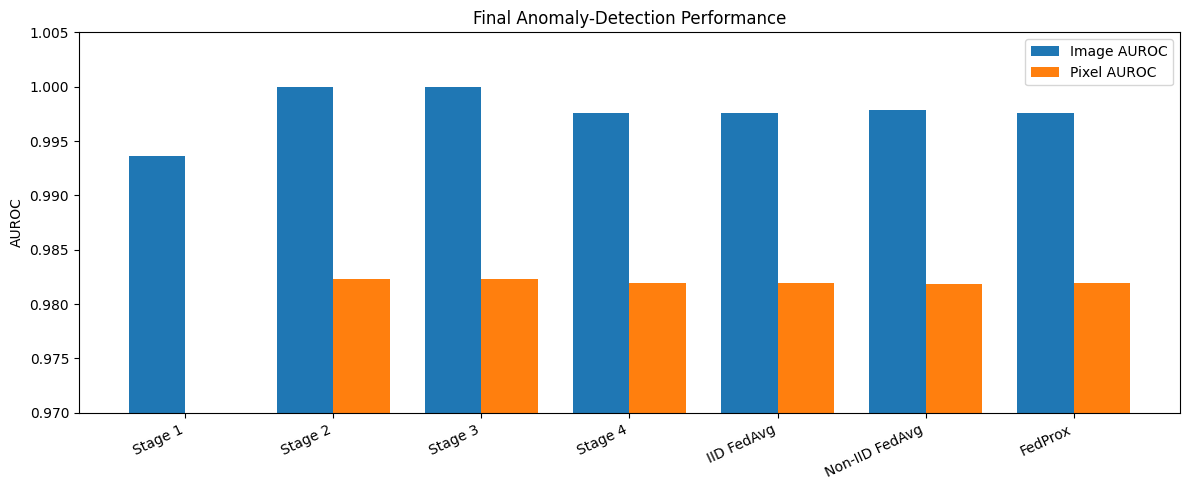

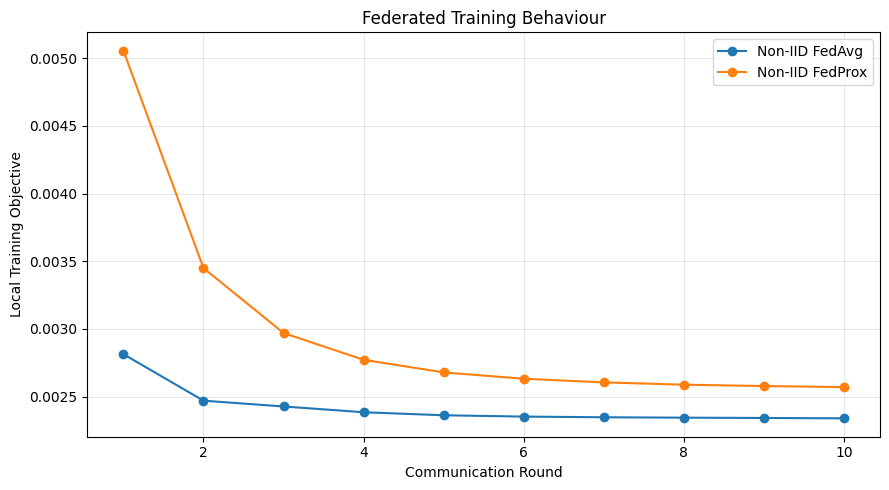

Stage 7 Step 1 completed successfully.


In [161]:
# Stage 7 - Step 1: Final thesis results and figures

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Final quantitative summary
# --------------------------------------------------

final_results = pd.DataFrame({
    "Method": [
        "Stage 1 - Global ResNet18",
        "Stage 2 - PatchCore-style",
        "Stage 3 - Residual Adapter",
        "Stage 4 - Independent IID Clients",
        "Stage 5 - IID FedAvg",
        "Stage 6 - Non-IID FedAvg",
        "Stage 6 - Non-IID FedProx"
    ],

    "Image AUROC": [
        "0.993651",
        "1.000000",
        "1.000000",
        f"{local_mean_image:.6f} ± {local_std_image:.6f}",
        f"{fedavg_mean_image_auroc:.6f} ± {fedavg_std_image_auroc:.6f}",
        f"{np.mean(noniid_fedavg_img):.6f} ± {np.std(noniid_fedavg_img):.6f}",
        f"{np.mean(fedprox_img):.6f} ± {np.std(fedprox_img):.6f}"
    ],

    "Pixel AUROC": [
        "N/A",
        "0.982266",
        "0.982275",
        f"{local_mean_pixel:.6f} ± {local_std_pixel:.6f}",
        f"{fedavg_mean_pixel_auroc:.6f} ± {fedavg_std_pixel_auroc:.6f}",
        f"{np.mean(noniid_fedavg_pix):.6f} ± {np.std(noniid_fedavg_pix):.6f}",
        f"{np.mean(fedprox_pix):.6f} ± {np.std(fedprox_pix):.6f}"
    ],

    "Rounds": [
        0, 0, 0, 0, 10, 10, 10
    ],

    "Communication": [
        "N/A", "N/A", "N/A", "N/A",
        "22.62 MiB", "22.62 MiB", "22.62 MiB"
    ]
})

display(final_results)


# --------------------------------------------------
# 2. Final AUROC comparison figure
# --------------------------------------------------

methods = [
    "Stage 1",
    "Stage 2",
    "Stage 3",
    "Stage 4",
    "IID FedAvg",
    "Non-IID FedAvg",
    "FedProx"
]

image_values = [
    0.993651,
    1.000000,
    1.000000,
    local_mean_image,
    fedavg_mean_image_auroc,
    np.mean(noniid_fedavg_img),
    np.mean(fedprox_img)
]

pixel_values = [
    np.nan,
    0.982266,
    0.982275,
    local_mean_pixel,
    fedavg_mean_pixel_auroc,
    np.mean(noniid_fedavg_pix),
    np.mean(fedprox_pix)
]

x = np.arange(len(methods))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, image_values, width, label="Image AUROC")
plt.bar(x + width/2, pixel_values, width, label="Pixel AUROC")
plt.xticks(x, methods, rotation=25, ha="right")
plt.ylim(0.97, 1.005)
plt.ylabel("AUROC")
plt.title("Final Anomaly-Detection Performance")
plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/final_auroc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# 3. Federated training-loss comparison
# --------------------------------------------------

rounds = range(1, NUM_ROUNDS + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    rounds,
    np.mean(
        [noniid_fedavg_losses[c] for c in client_names],
        axis=0
    ),
    marker="o",
    label="Non-IID FedAvg"
)

plt.plot(
    rounds,
    np.mean(
        [fedprox_losses[c] for c in client_names],
        axis=0
    ),
    marker="o",
    label="Non-IID FedProx"
)

plt.xlabel("Communication Round")
plt.ylabel("Local Training Objective")
plt.title("Federated Training Behaviour")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/kaggle/working/final_federated_loss_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Stage 7 Step 1 completed successfully.")

### Stage 7 Step 1 : Result Interpretation

The final quantitative comparison shows consistently high anomaly-detection performance across the centralized, independent-client and federated experiments.

Under the mild simulated domain shift, Non-IID FedAvg preserved performance close to the IID setting. FedProx with μ = 0.01 also converged stably but did not provide a clear AUROC advantage over FedAvg. The FedProx training objective is numerically higher because it includes the additional proximal penalty and should therefore not be directly compared with the FedAvg reconstruction loss magnitude.

Overall, the results show that the lightweight federated residual-adapter approach preserved strong Bottle-category anomaly detection performance while communicating only the adapter parameters.

1. Why is Stage 1 Pixel AUROC N/A?
Stage 1 uses one global feature per image and does not produce a spatial anomaly map.
2. Why do Stages 1–4 have no communication cost?
They are not federated communication experiments.
3. Did Non-IID FedAvg degrade significantly?
No. Performance remained very close to IID FedAvg under the mild tested shift.
4. Did FedProx outperform FedAvg?
No clear advantage was observed with μ = 0.01.
5. Is Stage 7 another experiment?
No. It only consolidates and saves the completed experimental results.

### Stage 7 : Step 2: Save Final Thesis Artifacts

The completed experimental results are now saved for thesis reporting and reproducibility. This includes the final quantitative tables, federated adapter states, training-loss histories, comparison figures and one qualitative anomaly-localization example.

No further model training is performed. After this step, the Kaggle implementation is complete and the saved outputs can be used directly for the thesis write-up.

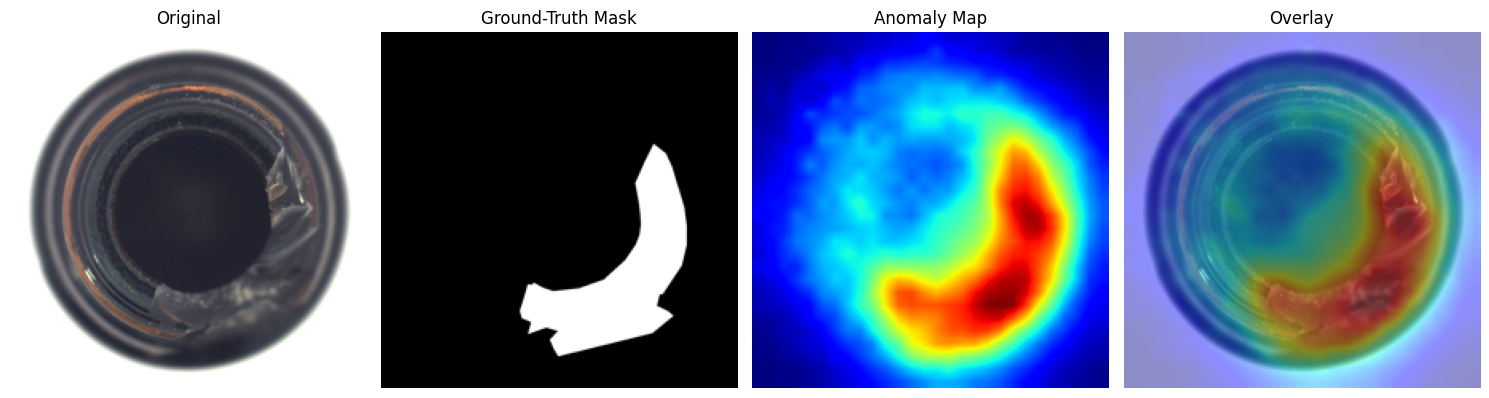

FINAL THESIS OUTPUTS SAVED
---------------------------------------------
federated_training_losses.csv
final_anomaly_localization.png
final_auroc_comparison.png
final_federated_loss_comparison.png
final_results.csv
noniid_fedavg_final_adapter.pt
noniid_fedprox_final_adapter.pt
stage6_fedavg_vs_fedprox.csv

ZIP package:
/kaggle/working/thesis_final_outputs.zip

Kaggle implementation complete.


In [162]:
# Stage 7 - Step 2: Save all final thesis outputs

import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

OUTPUT_DIR = "/kaggle/working/thesis_final_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --------------------------------------------------
# 1. Save final result tables
# --------------------------------------------------

final_results.to_csv(
    f"{OUTPUT_DIR}/final_results.csv",
    index=False
)

stage6_comparison.to_csv(
    f"{OUTPUT_DIR}/stage6_fedavg_vs_fedprox.csv",
    index=False
)

# --------------------------------------------------
# 2. Save training-loss histories
# --------------------------------------------------

loss_rows = []

for round_idx in range(NUM_ROUNDS):
    loss_rows.append({
        "round": round_idx + 1,
        "noniid_fedavg_mean_loss": np.mean([
            noniid_fedavg_losses[c][round_idx]
            for c in client_names
        ]),
        "fedprox_mean_objective": np.mean([
            fedprox_losses[c][round_idx]
            for c in client_names
        ])
    })

pd.DataFrame(loss_rows).to_csv(
    f"{OUTPUT_DIR}/federated_training_losses.csv",
    index=False
)

# --------------------------------------------------
# 3. Save final adapter states
# --------------------------------------------------

torch.save(
    noniid_fedavg_global_state,
    f"{OUTPUT_DIR}/noniid_fedavg_final_adapter.pt"
)

torch.save(
    fedprox_global_state,
    f"{OUTPUT_DIR}/noniid_fedprox_final_adapter.pt"
)

# --------------------------------------------------
# 4. Copy final comparison figures
# --------------------------------------------------

for filename in [
    "final_auroc_comparison.png",
    "final_federated_loss_comparison.png"
]:
    source = f"/kaggle/working/{filename}"

    if os.path.exists(source):
        shutil.copy(
            source,
            f"{OUTPUT_DIR}/{filename}"
        )

# --------------------------------------------------
# 5. Create qualitative anomaly-localization figure
#    using Non-IID FedAvg + Client 1 memory bank result
# --------------------------------------------------

test_view = test_metadata.reset_index(drop=True)

anomalous_idx = test_view.index[
    test_view["true_label"] == 1
][0]

row = test_view.iloc[anomalous_idx]

original = Image.open(
    row["image_path"]
).convert("RGB").resize((224, 224))

mask = Image.open(
    row["mask_path"]
).convert("L").resize((224, 224))

anomaly_28 = clients["Client_1"][
    "noniid_fedavg_anomaly_maps"
][anomalous_idx]

anomaly_224 = F.interpolate(
    anomaly_28.unsqueeze(0).unsqueeze(0),
    size=(224, 224),
    mode="bilinear",
    align_corners=False
).squeeze().numpy()

original_np = np.asarray(original)
mask_np = np.asarray(mask)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(original_np)
axes[0].set_title("Original")

axes[1].imshow(mask_np, cmap="gray")
axes[1].set_title("Ground-Truth Mask")

axes[2].imshow(anomaly_224, cmap="jet")
axes[2].set_title("Anomaly Map")

axes[3].imshow(original_np)
axes[3].imshow(
    anomaly_224,
    cmap="jet",
    alpha=0.45
)
axes[3].set_title("Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/final_anomaly_localization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------
# 6. Create one downloadable ZIP package
# --------------------------------------------------

shutil.make_archive(
    "/kaggle/working/thesis_final_outputs",
    "zip",
    OUTPUT_DIR
)

print("FINAL THESIS OUTPUTS SAVED")
print("-" * 45)

for filename in sorted(os.listdir(OUTPUT_DIR)):
    print(filename)

print("\nZIP package:")
print("/kaggle/working/thesis_final_outputs.zip")
print("\nKaggle implementation complete.")

## Final Implementation Conclusion

This implementation developed and evaluated a federated self-supervised industrial anomaly-detection pipeline using the MVTec AD Bottle category.

A frozen ImageNet-pretrained ResNet18 was used throughout as the feature extractor, while a lightweight 98,816-parameter residual adapter provided the trainable representation component. Anomaly scores were produced using nearest-neighbour distances between adapted test patch features and private normal client memory banks.

The experiments progressed from centralized global and PatchCore-style baselines to centralized adapter training, independent IID clients, IID FedAvg, and finally simulated Non-IID FedAvg and FedProx. Under the tested mild brightness/contrast and blur domain shifts, both federated methods preserved strong anomaly-detection performance.

Non-IID FedAvg achieved an Image AUROC of approximately **0.997884 ± 0.001349** and Pixel AUROC of **0.981891 ± 0.000196**. FedProx with μ = 0.01 achieved approximately **0.997619 ± 0.001714** Image AUROC and **0.981892 ± 0.000192** Pixel AUROC.

FedProx therefore did not provide a clear performance advantage over FedAvg in this controlled Bottle-category experiment. The results demonstrate stable federated adapter training under the tested mild domain heterogeneity, but they should not be generalized to all industrial datasets or domain-shift conditions.

Only residual-adapter parameters were federated. ResNet18 remained frozen, raw client images were never communicated, and client normal memory banks remained local.

1. Why save adapter states instead of the complete ResNet18?
Because ResNet18 was never trained. The experiment-specific learned parameters are the residual adapters.
2. What does the qualitative figure show?
Original test image, ground-truth defect mask, nearest-neighbour anomaly map and its overlay.
3. Is the anomaly map produced by Grad-CAM?
No. It comes from patch-level nearest-neighbour distances to the normal memory bank.
4. Does Stage 7 train another model?
No. It only consolidates and saves completed results.